In [7]:
# Cell 1 - Environment Setup and Configuration

import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import math
import time
import traceback
from datetime import datetime, timedelta
from dotenv import load_dotenv

# Import scikit-learn dependencies
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

pd.options.mode.chained_assignment = None

# Load environment variables from .env file
try:
    env_path = pathlib.Path(__file__).resolve().parent.parent / ".env"
except NameError:
    env_path = pathlib.Path(os.getcwd()) / ".env"
load_dotenv(dotenv_path=env_path)

# Get configuration values and setup connections
DATABASE_URL = os.getenv("DATABASE_URL")
print("DATABASE_URL loaded:", DATABASE_URL is not None)

# Setup SQLAlchemy engine
from sqlalchemy import create_engine
try:
    engine = create_engine(DATABASE_URL)
    print("Database engine created successfully.")
except Exception as e:
    print(f"Error creating database engine: {e}")

# Import Supabase client
try:
    from caching.supabase_client import supabase
    print("Supabase client imported successfully.")
except Exception as e:
    print(f"Error importing Supabase client: {e}")

# Set directories for models and state saving
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
MODELS_DIR.mkdir(exist_ok=True)
PREGAME_MODEL_PATH = MODELS_DIR / "pregame_model.pkl"
print(f"Pre-game model will be saved to: {PREGAME_MODEL_PATH}")
print(f"Current date: {datetime.now().strftime('%Y-%m-%d')}")

DATABASE_URL loaded: True
Database engine created successfully.
Supabase client imported successfully.
Pre-game model will be saved to: /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_model.pkl
Current date: 2025-03-20


In [8]:
# Cell 2 - Core Data Loading Functions

import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize
        
    Returns:
        Normalized team name (lowercase, without special characters)
    """
    # Remove special characters, standardize spacing
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    
    # Handle common variations (76ers vs sixers, etc.)
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more as needed
    }
    
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
            
    return normalized

def load_historical_games(days_lookback=365):
    """
    Loads historical game data from Supabase for feature engineering and training.
    Includes all box score statistics.
    """
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    print(f"Loading historical game data since {threshold_date}...")
    try:
        # Use correct Supabase query syntax
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .gte("game_date", threshold_date)\
            .order('game_date')\
            .execute()
        
        historical_data = response.data
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return pd.DataFrame()
        
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        # Ensure all numeric columns have proper types
        numeric_cols = ['home_score', 'away_score', 'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
                'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot', 'home_assists', 'away_assists',
                'home_steals', 'away_steals', 'home_blocks', 'away_blocks', 'home_turnovers',
                'away_turnovers', 'home_fouls', 'away_fouls', 'home_off_reb', 'home_def_reb',
                'home_total_reb', 'away_off_reb', 'away_def_reb', 'away_total_reb',
                'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
                # NEW FIELDS
                'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
                'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted']
                        
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        print(f"Loaded {len(df)} historical games from {df['game_date'].min()} to {df['game_date'].max()}")
        return df
    except Exception as e:
        print(f"Error loading historical game data: {e}")
        traceback.print_exc()
        
        # For development/testing, create mock data if API call fails
        print("Creating mock historical data for development...")
        teams = [
            'Atlanta Hawks', 'Boston Celtics', 'Brooklyn Nets', 'Charlotte Hornets', 
            'Chicago Bulls', 'Cleveland Cavaliers', 'Dallas Mavericks', 'Denver Nuggets',
            'Detroit Pistons', 'Golden State Warriors', 'Houston Rockets', 'Indiana Pacers',
            'Los Angeles Clippers', 'Los Angeles Lakers', 'Memphis Grizzlies', 'Miami Heat',
            'Milwaukee Bucks', 'Minnesota Timberwolves', 'New Orleans Pelicans', 'New York Knicks',
            'Oklahoma City Thunder', 'Orlando Magic', 'Philadelphia 76ers', 'Phoenix Suns',
            'Portland Trail Blazers', 'Sacramento Kings', 'San Antonio Spurs', 'Toronto Raptors',
            'Utah Jazz', 'Washington Wizards'
        ]
        
        # Generate mock games for the past year
        mock_games = []
        for i in range(1200):  # ~1200 games per season
            game_date = datetime.now() - timedelta(days=np.random.randint(1, days_lookback))
            home_idx = np.random.randint(0, len(teams))
            away_idx = np.random.randint(0, len(teams))
            while away_idx == home_idx:
                away_idx = np.random.randint(0, len(teams))
                
            home_team = teams[home_idx]
            away_team = teams[away_idx]
            
            # Generate realistic scores and stats
            home_score = np.random.randint(95, 130)
            away_score = np.random.randint(95, 130)
            
            # Quarter scores
            home_q1 = np.random.randint(20, 35)
            home_q2 = np.random.randint(20, 35)
            home_q3 = np.random.randint(20, 35)
            home_q4 = np.random.randint(20, 35)
            home_ot = 0
            
            away_q1 = np.random.randint(20, 35)
            away_q2 = np.random.randint(20, 35)
            away_q3 = np.random.randint(20, 35)
            away_q4 = np.random.randint(20, 35)
            away_ot = 0
            
            # Adjust quarter scores to match total
            total_quarters = home_q1 + home_q2 + home_q3 + home_q4
            adjustment = home_score / total_quarters
            home_q1 = int(home_q1 * adjustment)
            home_q2 = int(home_q2 * adjustment)
            home_q3 = int(home_q3 * adjustment)
            home_q4 = int(home_q4 * adjustment)
            
            total_quarters = away_q1 + away_q2 + away_q3 + away_q4
            adjustment = away_score / total_quarters
            away_q1 = int(away_q1 * adjustment)
            away_q2 = int(away_q2 * adjustment)
            away_q3 = int(away_q3 * adjustment)
            away_q4 = int(away_q4 * adjustment)
            
            # Generate other stats
            home_assists = np.random.randint(18, 30)
            away_assists = np.random.randint(18, 30)
            home_steals = np.random.randint(5, 15)
            away_steals = np.random.randint(5, 15)
            home_blocks = np.random.randint(2, 10)
            away_blocks = np.random.randint(2, 10)
            home_turnovers = np.random.randint(8, 20)
            away_turnovers = np.random.randint(8, 20)
            home_fouls = np.random.randint(15, 25)
            away_fouls = np.random.randint(15, 25)
            
            # Rebounding
            home_off_reb = np.random.randint(5, 15)
            home_def_reb = np.random.randint(25, 40)
            home_total_reb = home_off_reb + home_def_reb
            
            away_off_reb = np.random.randint(5, 15)
            away_def_reb = np.random.randint(25, 40)
            away_total_reb = away_off_reb + away_def_reb
            
            # Three-point shooting
            home_3pa = np.random.randint(25, 45)
            home_3pm = int(home_3pa * np.random.uniform(0.3, 0.45))
            
            away_3pa = np.random.randint(25, 45)
            away_3pm = int(away_3pa * np.random.uniform(0.3, 0.45))


                    # Generate field goal stats
            home_fg_attempted = np.random.randint(70, 95)
            home_fg_made = int(home_fg_attempted * np.random.uniform(0.4, 0.52))
            away_fg_attempted = np.random.randint(70, 95)
            away_fg_made = int(away_fg_attempted * np.random.uniform(0.4, 0.52))

            # Generate free throw stats
            home_ft_attempted = np.random.randint(15, 35)
            home_ft_made = int(home_ft_attempted * np.random.uniform(0.7, 0.85))
            away_ft_attempted = np.random.randint(15, 35)
            away_ft_made = int(away_ft_attempted * np.random.uniform(0.7, 0.85))
            
            mock_games.append({
                'game_id': 10000 + i,
                'game_date': game_date,
                'home_team': home_team,
                'away_team': away_team,
                'home_score': home_score,
                'away_score': away_score,
                'home_q1': home_q1,
                'home_q2': home_q2,
                'home_q3': home_q3,
                'home_q4': home_q4,
                'home_ot': home_ot,
                'away_q1': away_q1,
                'away_q2': away_q2,
                'away_q3': away_q3,
                'away_q4': away_q4,
                'away_ot': away_ot,
                'home_assists': home_assists,
                'away_assists': away_assists,
                'home_steals': home_steals,
                'away_steals': away_steals,
                'home_blocks': home_blocks,
                'away_blocks': away_blocks,
                'home_turnovers': home_turnovers,
                'away_turnovers': away_turnovers,
                'home_fouls': home_fouls,
                'away_fouls': away_fouls,
                'home_off_reb': home_off_reb,
                'home_def_reb': home_def_reb,
                'home_total_reb': home_total_reb,
                'away_off_reb': away_off_reb,
                'away_def_reb': away_def_reb,
                'away_total_reb': away_total_reb,
                'home_3pm': home_3pm,
                'home_3pa': home_3pa,
                'away_3pm': away_3pm,
                'away_3pa': away_3pa,
                'home_fg_made': home_fg_made,
                'home_fg_attempted': home_fg_attempted,
                'away_fg_made': away_fg_made,
                'away_fg_attempted': away_fg_attempted,
                'home_ft_made': home_ft_made,
                'home_ft_attempted': home_ft_attempted,
                'away_ft_made': away_ft_made,
                'away_ft_attempted': away_ft_attempted
            })
        
        mock_df = pd.DataFrame(mock_games)
        mock_df['game_date'] = pd.to_datetime(mock_df['game_date'])
        print(f"Created {len(mock_df)} mock historical games")
        return mock_df

def get_upcoming_games(days=7):
    """
    Fetch upcoming NBA games scheduled in the next 'days' days from Supabase.
    """
    today = datetime.now()
    end_date = (today + timedelta(days=days)).strftime('%Y-%m-%d')
    today_str = today.strftime('%Y-%m-%d')
    print(f"Fetching upcoming games from {today_str} to {end_date}...")
    try:
        response = supabase.table("nba_game_schedule")\
            .select("*")\
            .gte("game_date", today_str)\
            .lte("game_date", end_date)\
            .execute()
        
        if response.data:
            df = pd.DataFrame(response.data)
            df['game_date'] = pd.to_datetime(df['game_date'])
            print(f"Found {len(df)} upcoming games in nba_game_schedule.")
            return df
        else:
            print("No scheduled upcoming games found.")
            
            # For development/testing, create mock upcoming games
            print("Creating mock upcoming games for development...")
            teams = [
                'Atlanta Hawks', 'Boston Celtics', 'Brooklyn Nets', 'Charlotte Hornets', 
                'Chicago Bulls', 'Cleveland Cavaliers', 'Dallas Mavericks', 'Denver Nuggets',
                'Detroit Pistons', 'Golden State Warriors', 'Houston Rockets', 'Indiana Pacers',
                'Los Angeles Clippers', 'Los Angeles Lakers', 'Memphis Grizzlies', 'Miami Heat',
                'Milwaukee Bucks', 'Minnesota Timberwolves', 'New Orleans Pelicans', 'New York Knicks',
                'Oklahoma City Thunder', 'Orlando Magic', 'Philadelphia 76ers', 'Phoenix Suns',
                'Portland Trail Blazers', 'Sacramento Kings', 'San Antonio Spurs', 'Toronto Raptors',
                'Utah Jazz', 'Washington Wizards'
            ]
            
            # Generate upcoming games
            upcoming_games = []
            for i in range(15):  # ~15 games in a week
                game_date = today + timedelta(days=np.random.randint(0, days))
                home_idx = np.random.randint(0, len(teams))
                away_idx = np.random.randint(0, len(teams))
                while away_idx == home_idx:
                    away_idx = np.random.randint(0, len(teams))
                    
                home_team = teams[home_idx]
                away_team = teams[away_idx]
                scheduled_time = f"{np.random.randint(6, 9)}:{np.random.choice(['00', '30'])} PM"
                
                upcoming_games.append({
                    'game_id': 20000 + i,
                    'game_date': game_date.strftime('%Y-%m-%d'),
                    'home_team': home_team,
                    'away_team': away_team,
                    'scheduled_time': scheduled_time,
                    'venue': f"{home_team} Arena"
                })
            
            mock_df = pd.DataFrame(upcoming_games)
            print(f"Created {len(mock_df)} mock upcoming games")
            return mock_df
    except Exception as e:
        print(f"Error fetching upcoming games: {e}")
        traceback.print_exc()
        return pd.DataFrame()

In [9]:
# Cell 3

import pandas as pd
import numpy as np
import traceback
import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize
        
    Returns:
        Normalized team name (lowercase, without special characters)
    """
    if name is None:
        return ""
        
    # Remove special characters, standardize spacing
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    
    # Handle common variations (76ers vs sixers, etc.)
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more as needed
    }
    
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
            
    return normalized

def calculate_team_metrics(historical_df):
    """
    Calculates advanced team-level metrics from historical game data.
    Incorporates the full range of box score statistics.
    """
    if historical_df.empty:
        print("No historical data provided.")
        return pd.DataFrame()
    
    # Get unique team names (using original names)
    teams = set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique())
    
    metrics_list = []
    for team in teams:
        try:
            # Use original team name for fetching data
            home_games = historical_df[historical_df['home_team'] == team]
            away_games = historical_df[historical_df['away_team'] == team]
            
            # Also store normalized version
            team_normalized = normalize_team_name(team)
            
            total_games = len(home_games) + len(away_games)
            if total_games < 3:
                continue
                
            # Basic scoring metrics
            avg_home_score = home_games['home_score'].mean() if not home_games.empty else np.nan
            avg_away_score = away_games['away_score'].mean() if not away_games.empty else np.nan
            overall_avg = np.nanmean([avg_home_score, avg_away_score])
            avg_home_opp = home_games['away_score'].mean() if not home_games.empty else np.nan
            avg_away_opp = away_games['home_score'].mean() if not away_games.empty else np.nan
            overall_opp = np.nanmean([avg_home_opp, avg_away_opp])
            net_rating = overall_avg - overall_opp
            
            # Win-loss record
            home_wins = (home_games['home_score'] > home_games['away_score']).sum() if not home_games.empty else 0
            away_wins = (away_games['away_score'] > away_games['home_score']).sum() if not away_games.empty else 0
            win_pct = (home_wins + away_wins) / total_games
            
            # Home court advantage
            home_advantage = avg_home_score - avg_home_opp if not np.isnan(avg_home_score) and not np.isnan(avg_home_opp) else 3.5
            
            # Quarter-by-quarter scoring tendencies
            home_q1_avg = home_games['home_q1'].mean() if not home_games.empty else np.nan
            away_q1_avg = away_games['away_q1'].mean() if not away_games.empty else np.nan
            q1_avg = np.nanmean([home_q1_avg, away_q1_avg])
            
            home_q4_avg = home_games['home_q4'].mean() if not home_games.empty else np.nan
            away_q4_avg = away_games['away_q4'].mean() if not away_games.empty else np.nan
            q4_avg = np.nanmean([home_q4_avg, away_q4_avg])
            
            # Rebounding metrics
            home_reb_avg = home_games['home_total_reb'].mean() if not home_games.empty else np.nan
            away_reb_avg = away_games['away_total_reb'].mean() if not away_games.empty else np.nan
            total_reb_avg = np.nanmean([home_reb_avg, away_reb_avg])
            
            home_off_reb_avg = home_games['home_off_reb'].mean() if not home_games.empty else np.nan
            away_off_reb_avg = away_games['away_off_reb'].mean() if not away_games.empty else np.nan
            off_reb_avg = np.nanmean([home_off_reb_avg, away_off_reb_avg])
            
            # Assists and turnovers
            home_ast_avg = home_games['home_assists'].mean() if not home_games.empty else np.nan
            away_ast_avg = away_games['away_assists'].mean() if not away_games.empty else np.nan
            ast_avg = np.nanmean([home_ast_avg, away_ast_avg])
            
            home_to_avg = home_games['home_turnovers'].mean() if not home_games.empty else np.nan
            away_to_avg = away_games['away_turnovers'].mean() if not away_games.empty else np.nan
            to_avg = np.nanmean([home_to_avg, away_to_avg])
            
            # Defensive metrics
            home_stl_avg = home_games['home_steals'].mean() if not home_games.empty else np.nan
            away_stl_avg = away_games['away_steals'].mean() if not away_games.empty else np.nan
            stl_avg = np.nanmean([home_stl_avg, away_stl_avg])
            
            home_blk_avg = home_games['home_blocks'].mean() if not home_games.empty else np.nan
            away_blk_avg = away_games['away_blocks'].mean() if not away_games.empty else np.nan
            blk_avg = np.nanmean([home_blk_avg, away_blk_avg])
            
            # Three-point shooting
            home_3pm_avg = home_games['home_3pm'].mean() if not home_games.empty else np.nan
            away_3pm_avg = away_games['away_3pm'].mean() if not away_games.empty else np.nan
            threes_made_avg = np.nanmean([home_3pm_avg, away_3pm_avg])
            
            home_3pa_avg = home_games['home_3pa'].mean() if not home_games.empty else np.nan
            away_3pa_avg = away_games['away_3pa'].mean() if not away_games.empty else np.nan
            threes_att_avg = np.nanmean([home_3pa_avg, away_3pa_avg])
            
            three_pt_pct = threes_made_avg / threes_att_avg if threes_att_avg > 0 else 0
            
            # Fouls
            home_fouls_avg = home_games['home_fouls'].mean() if not home_games.empty else np.nan
            away_fouls_avg = away_games['away_fouls'].mean() if not away_games.empty else np.nan
            fouls_avg = np.nanmean([home_fouls_avg, away_fouls_avg])
            
            # Recent form (last 10 games)
            recent_home_games = home_games.sort_values('game_date').tail(10)
            recent_away_games = away_games.sort_values('game_date').tail(10)
            
            recent_home_pts = recent_home_games['home_score'].mean() if not recent_home_games.empty else np.nan
            recent_away_pts = recent_away_games['away_score'].mean() if not recent_away_games.empty else np.nan
            recent_form = np.nanmean([recent_home_pts, recent_away_pts])
            
            # Get current form from the data if available
            current_form = ""
            if 'current_form' in historical_df.columns:
                # Try to get the most recent record of this team's form
                team_data = historical_df[(historical_df['home_team'] == team) | (historical_df['away_team'] == team)]
                if not team_data.empty:
                    # Sort by date and get the most recent entry
                    team_data = team_data.sort_values('game_date', ascending=False)
                    if 'current_form' in team_data.columns:
                        first_row = team_data.iloc[0]
                        if 'current_form' in first_row:
                            current_form = str(first_row['current_form'])
            
            # Ensure current_form is a valid string
            if pd.isna(current_form) or current_form is None:
                current_form = ""
            current_form = str(current_form)
            
            # Calculate win percentage from form string
            form_win_pct = 0.5  # Default to neutral
            if len(current_form) > 0:
                win_count = current_form.count('W')
                form_win_pct = win_count / len(current_form) if len(current_form) > 0 else 0.5
                
            # Calculate current streak (positive for wins, negative for losses)
            current_streak = 0
            if len(current_form) > 0:
                streak_char = current_form[0]
                streak_count = 0
                for char in current_form:
                    if char == streak_char:
                        streak_count += 1
                    else:
                        break
                
                # Apply sign based on win/loss
                if streak_char == 'W':
                    current_streak = streak_count
                else:
                    current_streak = -streak_count
                    
            # Determine momentum direction (1=improving, -1=declining, 0=alternating)
            momentum_direction = 0
            if len(current_form) >= 4:
                # Check if recent games are trending toward wins or losses
                first_half = current_form[len(current_form)//2:]  # More recent games
                second_half = current_form[:len(current_form)//2]  # Less recent games
                first_half_win_pct = first_half.count('W') / len(first_half) if len(first_half) > 0 else 0
                second_half_win_pct = second_half.count('W') / len(second_half) if len(second_half) > 0 else 0
                
                if first_half_win_pct > second_half_win_pct:
                    momentum_direction = 1  # Improving
                elif first_half_win_pct < second_half_win_pct:
                    momentum_direction = -1  # Declining
            
            # Compile metrics
            metrics = {
                'team': team,
                'team_normalized': team_normalized,
                'games_played': total_games,
                'avg_score': overall_avg,
                'avg_opp_score': overall_opp,
                'net_rating': net_rating,
                'win_pct': win_pct,
                'home_advantage': home_advantage,
                'pts_per_game': overall_avg,
                'opp_pts_per_game': overall_opp,
                'recent_form': recent_form if not np.isnan(recent_form) else overall_avg,
                'offensive_rating': overall_avg,  # Simplified for consistency
                'defensive_rating': overall_opp,  # Simplified for consistency
                # Quarter scoring tendencies
                'q1_avg': q1_avg,
                'q4_avg': q4_avg,
                'q1_q4_ratio': q1_avg / q4_avg if q4_avg > 0 else 1,
                # Rebounding
                'total_reb_avg': total_reb_avg,
                'off_reb_avg': off_reb_avg,
                'off_reb_pct': off_reb_avg / total_reb_avg if total_reb_avg > 0 else 0.25,
                # Ball handling
                'assists_avg': ast_avg,
                'turnovers_avg': to_avg,
                'ast_to_ratio': ast_avg / to_avg if to_avg > 0 else ast_avg,
                # Defense
                'steals_avg': stl_avg,
                'blocks_avg': blk_avg,
                'defense_impact': stl_avg + blk_avg,
                # Shooting
                'three_made_avg': threes_made_avg,
                'three_att_avg': threes_att_avg,
                'three_pt_pct': three_pt_pct,
                # Fouls
                'fouls_avg': fouls_avg,
                # Form metrics
                'current_form': current_form,
                'form_win_pct': form_win_pct,
                'current_streak': current_streak,
                'momentum_direction': momentum_direction,
            }
            
            metrics_list.append(metrics)
            
        except Exception as e:
            print(f"Error processing team metrics for {team}: {str(e)}")
            traceback.print_exc()
    
    try:
        metrics_df = pd.DataFrame(metrics_list)
        print(f"Calculated advanced metrics for {len(metrics_df)} teams.")
        
        # Ensure all required columns exist
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        for col in required_columns:
            if col not in metrics_df.columns:
                print(f"Adding missing column: {col}")
                if col == 'team':
                    metrics_df[col] = metrics_df.index
                elif col == 'win_pct':
                    metrics_df[col] = 0.5
                elif col in ['offensive_rating', 'defensive_rating']:
                    metrics_df[col] = 110.0
                elif col == 'net_rating':
                    metrics_df[col] = 0.0
        
        return metrics_df
    except Exception as e:
        print(f"Error creating metrics DataFrame: {str(e)}")
        traceback.print_exc()
        # Return a minimal DataFrame with required columns
        return pd.DataFrame({
            'team': [],
            'team_normalized': [],
            'win_pct': [],
            'offensive_rating': [],
            'defensive_rating': [],
            'net_rating': []
        })

def calculate_rolling_stats(df, window=10):
    """
    Calculate rolling average statistics for each team from historical data.
    Includes multiple statistical categories beyond just scoring.
    Args:
        df: DataFrame with historical games
        window: Window size for rolling averages
    Returns:
        Dictionary mapping team name to rolling stats dictionary
    """
    if df.empty:
        return {}
    
    try:
        df['game_date'] = pd.to_datetime(df['game_date'])
        rolling_stats = {}
        
        # Get unique team names
        teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
        
        for team in teams:
            try:
                # Use original team name for fetching data
                team_home = df[df['home_team'] == team].copy()
                team_away = df[df['away_team'] == team].copy()
                
                # Also get normalized version for the dictionary key
                team_normalized = normalize_team_name(team)
                
                if team_home.empty and team_away.empty:
                    continue
                
                # Basic scoring
                if not team_home.empty:
                    team_home['team_score'] = team_home['home_score']
                    team_home['opp_score'] = team_home['away_score']
                    # Box score stats
                    team_home['team_assists'] = team_home['home_assists']
                    team_home['team_steals'] = team_home['home_steals']
                    team_home['team_blocks'] = team_home['home_blocks']
                    team_home['team_turnovers'] = team_home['home_turnovers']
                    team_home['team_off_reb'] = team_home['home_off_reb']
                    team_home['team_def_reb'] = team_home['home_def_reb']
                    team_home['team_total_reb'] = team_home['home_total_reb']
                    team_home['team_3pm'] = team_home['home_3pm']
                    team_home['team_3pa'] = team_home['home_3pa']
                
                if not team_away.empty:
                    team_away['team_score'] = team_away['away_score']
                    team_away['opp_score'] = team_away['home_score']
                    # Box score stats
                    team_away['team_assists'] = team_away['away_assists']
                    team_away['team_steals'] = team_away['away_steals']
                    team_away['team_blocks'] = team_away['away_blocks']
                    team_away['team_turnovers'] = team_away['away_turnovers']
                    team_away['team_off_reb'] = team_away['away_off_reb']
                    team_away['team_def_reb'] = team_away['away_def_reb']
                    team_away['team_total_reb'] = team_away['away_total_reb']
                    team_away['team_3pm'] = team_away['away_3pm']
                    team_away['team_3pa'] = team_away['away_3pa']
                
                # Combine home and away games
                cols_to_keep = ['game_date', 'team_score', 'opp_score', 
                                'team_assists', 'team_steals', 'team_blocks', 
                                'team_turnovers', 'team_off_reb', 'team_def_reb', 
                                'team_total_reb', 'team_3pm', 'team_3pa']
                
                combined_home = team_home[cols_to_keep] if not team_home.empty else pd.DataFrame(columns=cols_to_keep)
                combined_away = team_away[cols_to_keep] if not team_away.empty else pd.DataFrame(columns=cols_to_keep)
                
                team_games = pd.concat([combined_home, combined_away], ignore_index=True)
                
                if len(team_games) < 3:
                    continue
                
                # Sort by date
                team_games = team_games.sort_values('game_date')
                
                # Calculate 3pt percentage
                team_games['team_3p_pct'] = team_games['team_3pm'] / team_games['team_3pa']
                team_games['team_3p_pct'] = team_games['team_3p_pct'].fillna(0)
                
                # Calculate assist-to-turnover ratio
                team_games['team_ast_to'] = team_games['team_assists'] / team_games['team_turnovers']
                team_games['team_ast_to'] = team_games['team_ast_to'].fillna(team_games['team_assists'])
                
                # Calculate rolling averages for each stat
                rolling_score = team_games['team_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_opp_score = team_games['opp_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_assists = team_games['team_assists'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_steals = team_games['team_steals'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_blocks = team_games['team_blocks'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_turnovers = team_games['team_turnovers'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_total_reb = team_games['team_total_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_off_reb = team_games['team_off_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_3p_pct = team_games['team_3p_pct'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_ast_to = team_games['team_ast_to'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                # Store in dictionary using both original and normalized team name
                rolling_stats[team_normalized] = {
                    'rolling_score': rolling_score,
                    'rolling_opp_score': rolling_opp_score,
                    'rolling_margin': rolling_score - rolling_opp_score,
                    'rolling_assists': rolling_assists,
                    'rolling_steals': rolling_steals,
                    'rolling_blocks': rolling_blocks,
                    'rolling_turnovers': rolling_turnovers,
                    'rolling_total_reb': rolling_total_reb,
                    'rolling_off_reb': rolling_off_reb,
                    'rolling_3p_pct': rolling_3p_pct,
                    'rolling_ast_to': rolling_ast_to
                }
                
                # Also store using original name as key for compatibility
                rolling_stats[team.lower()] = rolling_stats[team_normalized]
                
            except Exception as e:
                print(f"Error processing rolling stats for {team}: {str(e)}")
                traceback.print_exc()
        
        return rolling_stats
        
    except Exception as e:
        print(f"Error in calculate_rolling_stats: {str(e)}")
        traceback.print_exc()
        return {}

def calculate_league_average_metrics(team_metrics_df):
    """Calculate league average metrics to use as fallback for missing teams"""
    # Default values in case calculation fails
    default_metrics = {
        'team': 'LEAGUE_AVG',
        'team_normalized': 'league_avg',
        'win_pct': 0.5,
        'offensive_rating': 110,
        'defensive_rating': 110,
        'net_rating': 0,
        'pts_per_game': 110,
        'opp_pts_per_game': 110,
        'recent_form': 110,
        'home_advantage': 3.5,
        'total_reb_avg': 42,
        'off_reb_avg': 10,
        'assists_avg': 22,
        'turnovers_avg': 14,
        'steals_avg': 8,
        'blocks_avg': 5,
        'three_made_avg': 12,
        'three_att_avg': 35,
        'three_pt_pct': 0.35,
        'fouls_avg': 20,
        'ast_to_ratio': 1.5,
        'defense_impact': 13,
        'q1_avg': 27.5,
        'q4_avg': 27.5,
        'q1_q4_ratio': 1.0,
        'form_win_pct': 0.5,
        'current_streak': 0,
        'momentum_direction': 0
    }
    
    try:
        if team_metrics_df.empty:
            return default_metrics
        
        # Calculate averages from existing teams
        league_avg = {'team': 'LEAGUE_AVG', 'team_normalized': 'league_avg'}
        
        # Only include numeric columns
        numeric_cols = team_metrics_df.select_dtypes(include=np.number).columns
        
        for col in numeric_cols:
            try:
                league_avg[col] = team_metrics_df[col].mean()
            except:
                # Use default if calculation fails
                if col in default_metrics:
                    league_avg[col] = default_metrics[col]
        
        # Ensure all required metrics exist
        for key, value in default_metrics.items():
            if key not in league_avg:
                league_avg[key] = value
                
        return league_avg
        
    except Exception as e:
        print(f"Error calculating league averages: {str(e)}")
        traceback.print_exc()
        return default_metrics

In [10]:
# Cell 4 - Matchup and Rest Data Functions

def get_matchup_history(home_team, away_team, max_games=5):
    """
    Retrieves historical matchup data between two teams from Supabase.
    Returns a dictionary with:
      - num_games: number of past matchups,
      - avg_point_diff: average point differential (from home team's perspective),
      - home_win_pct: home team's win percentage in those games.
    """
    try:
        response_home = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", home_team)\
            .eq("away_team", away_team)\
            .order('game_date')\
            .limit(max_games).execute()
            
        response_away = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", away_team)\
            .eq("away_team", home_team)\
            .order('game_date')\
            .limit(max_games).execute()
            
        matchups = (response_home.data or []) + (response_away.data or [])
        
        if not matchups:
            return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}
            
        # Process results
        diffs = []
        home_wins = 0
        
        for game in matchups:
            if game['home_team'] == home_team:
                diff = game['home_score'] - game['away_score']
                if diff > 0:
                    home_wins += 1
            else:
                diff = game['away_score'] - game['home_score']
            diffs.append(diff)
            
        num_games = len(matchups)
        avg_diff = np.mean(diffs) if diffs else 0
        home_win_pct = home_wins / num_games if num_games > 0 else 0.5
        
        return {
            'num_games': num_games, 
            'avg_point_diff': avg_diff, 
            'home_win_pct': home_win_pct
        }
        
    except Exception as e:
        print(f"Error in get_matchup_history: {e}")
        traceback.print_exc()
        return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}

def get_rest_data(team, game_date):
    """
    Retrieves rest information for a team prior to a given game_date.
    Returns a dictionary with:
      - rest_days: days of rest since the last game,
      - is_back_to_back: True if rest_days equals 1.
    """
    try:
        if isinstance(game_date, str):
            game_date = pd.to_datetime(game_date)
            
        lookback_date = (game_date - timedelta(days=10)).strftime('%Y-%m-%d')
        
        response_home = supabase.table("nba_historical_game_stats").select("game_date")\
            .eq("home_team", team)\
            .gte("game_date", lookback_date)\
            .lt("game_date", game_date.strftime('%Y-%m-%d'))\
            .order('game_date')\
            .limit(1).execute()
            
        response_away = supabase.table("nba_historical_game_stats").select("game_date")\
            .eq("away_team", team)\
            .gte("game_date", lookback_date)\
            .lt("game_date", game_date.strftime('%Y-%m-%d'))\
            .order('game_date')\
            .limit(1).execute()
            
        prev_dates = []
        if response_home.data:
            prev_dates.append(pd.to_datetime(response_home.data[0]['game_date']))
        if response_away.data:
            prev_dates.append(pd.to_datetime(response_away.data[0]['game_date']))
            
        if not prev_dates:
            return {'rest_days': 5, 'is_back_to_back': False}
            
        prev_game_date = max(prev_dates)
        rest_days = (game_date - prev_game_date).days
        
        return {'rest_days': rest_days, 'is_back_to_back': (rest_days == 1)}
        
    except Exception as e:
        print(f"Error in get_rest_data: {e}")
        traceback.print_exc()
        return {'rest_days': 2, 'is_back_to_back': False}



Loaded 5812 records from database
Created 4 features: ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
Training on games from 2021-01-01 00:00:00 to 2024-04-10 00:00:00
Testing on games from 2024-04-10 00:00:00 to 2025-03-18 00:00:00

--------------------------------------------------
Training model for home_score...
Trained home_score model:
  - Test MAE: 9.77
  - Test RMSE: 12.25
  - Test R²: 0.1213

--------------------------------------------------
Training model for away_score...
Trained away_score model:
  - Test MAE: 10.06
  - Test RMSE: 12.64
  - Test R²: 0.1076

--------------------------------------------------
Training model for point_diff...
Trained point_diff model:
  - Test MAE: 11.90
  - Test RMSE: 15.19
  - Test R²: 0.0962

--------------------------------------------------
Training model for total_score...
Trained total_score model:
  - Test MAE: 15.75
  - Test RMSE: 19.73
  - Test R²: 0.1246


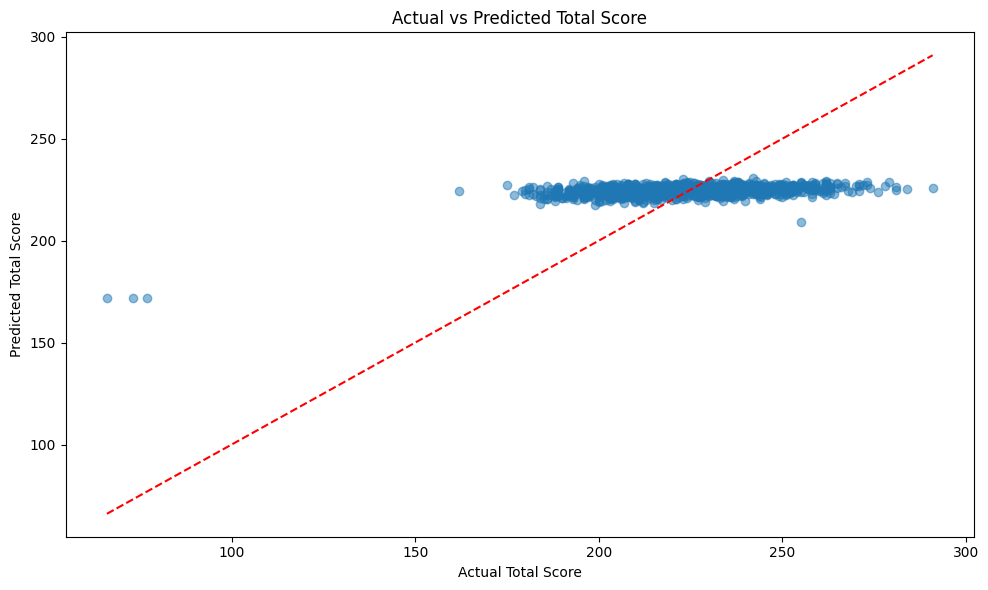


All models trained and saved to /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_model.pkl


In [11]:
# Cell 4A: Model Training with Chronological Validation and Feature Analysis

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# Load features data from database
try:
    query = """
    SELECT * FROM nba_historical_game_stats 
    WHERE EXTRACT(YEAR FROM game_date) >= 2021
    ORDER BY game_date ASC
    """
    features_df = pd.read_sql(query, engine)
    print(f"Loaded {len(features_df)} records from database")
    
    # Ensure index is unique
    features_df = features_df.reset_index(drop=True)
    
    # Calculate target variables
    features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
    features_df['total_score'] = features_df['home_score'] + features_df['away_score']
    
    # Convert game_date to datetime if it's not already
    if not pd.api.types.is_datetime64_any_dtype(features_df['game_date']):
        features_df['game_date'] = pd.to_datetime(features_df['game_date'])
        
    # Sort by date to ensure chronological order
    features_df = features_df.sort_values('game_date').reset_index(drop=True)
    
except Exception as e:
    print(f"Error loading data: {e}")
    raise

# Define target variables
targets = ['home_score', 'away_score', 'point_diff', 'total_score']

# Select only numeric columns for features, excluding post-game statistics
numeric_columns = features_df.select_dtypes(include=['number']).columns.tolist()

# Define which features would be available pre-game (remove in-game stats)
postgame_columns = [
    'home_score', 'away_score', 'point_diff', 'total_score',
    'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
    'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot',
    'home_assists', 'home_steals', 'home_blocks', 'home_turnovers', 'home_fouls',
    'away_assists', 'away_steals', 'away_blocks', 'away_turnovers', 'away_fouls',
    'home_off_reb', 'home_def_reb', 'home_total_reb',
    'away_off_reb', 'away_def_reb', 'away_total_reb',
    'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
    'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
    'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'
]

# Define pregame features (features we would know before the game starts)
id_columns = ['id', 'game_id']
pregame_features = [col for col in numeric_columns 
                   if col not in postgame_columns + id_columns + targets]

# If pregame_features is empty, we need to create some features from historical data
if not pregame_features:
    print("Warning: No pregame features found. Creating features from historical data...")
    
    # Create team performance metrics from historical games
    # We'll create a dictionary to store team performances
    team_stats = {}
    
    # Process games chronologically
    for idx, row in features_df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        game_date = row['game_date']
        
        # Initialize team stats if not exists
        for team in [home_team, away_team]:
            if team not in team_stats:
                team_stats[team] = {'games': [], 'pts_scored': [], 'pts_allowed': []}
        
        # Add this game's stats to historical records for both teams
        # We only use these stats for future predictions, not for the current game
        if idx > 0:  # Skip first game as we don't have prior data
            # Record home team stats
            team_stats[home_team]['games'].append(game_date)
            team_stats[home_team]['pts_scored'].append(row['home_score'])
            team_stats[home_team]['pts_allowed'].append(row['away_score'])
            
            # Record away team stats
            team_stats[away_team]['games'].append(game_date)
            team_stats[away_team]['pts_scored'].append(row['away_score'])
            team_stats[away_team]['pts_allowed'].append(row['home_score'])
    
    # Now create the features for each game based on past performance
    features_df['home_last5_avg'] = 0.0
    features_df['home_last5_allowed'] = 0.0
    features_df['away_last5_avg'] = 0.0
    features_df['away_last5_allowed'] = 0.0
    
    # Calculate the 5-game rolling averages
    for idx, row in features_df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        game_date = row['game_date']
        
        # Skip games where we don't have enough history
        if home_team not in team_stats or away_team not in team_stats:
            continue
            
        # Get home team's last 5 games before this one
        home_past_games = [(i, score) for i, (date, score) in 
                           enumerate(zip(team_stats[home_team]['games'], 
                                        team_stats[home_team]['pts_scored']))
                           if date < game_date]
        
        # Get away team's last 5 games before this one
        away_past_games = [(i, score) for i, (date, score) in 
                           enumerate(zip(team_stats[away_team]['games'], 
                                        team_stats[away_team]['pts_scored']))
                           if date < game_date]
        
        # Calculate averages if we have data
        if home_past_games:
            # Sort by recency and take last 5
            home_past_games.sort(reverse=True)
            home_last5 = home_past_games[:5]
            
            if home_last5:
                features_df.at[idx, 'home_last5_avg'] = np.mean([score for _, score in home_last5])
                
                # Calculate points allowed
                home_last5_allowed = [team_stats[home_team]['pts_allowed'][i] for i, _ in home_last5]
                features_df.at[idx, 'home_last5_allowed'] = np.mean(home_last5_allowed)
        
        if away_past_games:
            # Sort by recency and take last 5
            away_past_games.sort(reverse=True)
            away_last5 = away_past_games[:5]
            
            if away_last5:
                features_df.at[idx, 'away_last5_avg'] = np.mean([score for _, score in away_last5])
                
                # Calculate points allowed
                away_last5_allowed = [team_stats[away_team]['pts_allowed'][i] for i, _ in away_last5]
                features_df.at[idx, 'away_last5_allowed'] = np.mean(away_last5_allowed)
    
    # Update our list of pregame features
    pregame_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
    
    print(f"Created {len(pregame_features)} features: {pregame_features}")

# Split data chronologically (not randomly)
# Use the last 20% of games as a test set
test_size = 0.2
split_idx = int(len(features_df) * (1 - test_size))
train_df = features_df.iloc[:split_idx]
test_df = features_df.iloc[split_idx:]

print(f"Training on games from {train_df['game_date'].min()} to {train_df['game_date'].max()}")
print(f"Testing on games from {test_df['game_date'].min()} to {test_df['game_date'].max()}")

def train_model(X_train, y_train, X_test, y_test, model_name='ridge'):
    # Create a pipeline with imputation for missing values
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ])
    
    # Fit the model on training data
    pipeline.fit(X_train, y_train)
    
    # Evaluate on test data
    y_pred = pipeline.predict(X_test)
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = pipeline.score(X_test, y_test)
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    
    print(f"Trained {model_name} model:")
    print(f"  - Test MAE: {mae:.2f}")
    print(f"  - Test RMSE: {rmse:.2f}")
    print(f"  - Test R²: {r2:.4f}")
    
    return pipeline, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Train models for each target
models = {}
metrics = {}

for target in targets:
    print(f"\n{'-'*50}")
    print(f"Training model for {target}...")
    
    # Prepare train and test data
    X_train = train_df[pregame_features].copy()
    y_train = train_df[target]
    
    X_test = test_df[pregame_features].copy()
    y_test = test_df[target]
    
    # Check and report missing values
    train_missing = X_train.isna().sum().sum()
    if train_missing > 0:
        print(f"Warning: {train_missing} missing values in training features")
    
    # Train the model
    model, metric = train_model(X_train, y_train, X_test, y_test, model_name=target)
    models[target] = model
    metrics[target] = metric

# Plot actual vs predicted for the total_score model as an example
plt.figure(figsize=(10, 6))
y_test = test_df['total_score']
y_pred = models['total_score'].predict(test_df[pregame_features])

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total Score')
plt.ylabel('Predicted Total Score')
plt.title('Actual vs Predicted Total Score')
plt.tight_layout()
plt.savefig('total_score_prediction.png')
plt.show()

# Save models
import joblib
joblib.dump(models, str(PREGAME_MODEL_PATH))
print(f"\nAll models trained and saved to {PREGAME_MODEL_PATH}")

In [12]:
# Cell 4B: Alternative Model Training using RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

def train_rf_model(X_train, y_train, X_test, y_test, model_name='rf'):
    pipeline_rf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    
    param_grid_rf = {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [None, 5, 10],
        'regressor__min_samples_split': [2, 5]
    }
    
    grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    
    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    mae_rf = np.mean(np.abs(y_test - y_pred_rf))
    r2_rf = best_rf.score(X_test, y_test)
    rmse_rf = np.sqrt(np.mean((y_test - y_pred_rf)**2))
    
    print(f"RandomForest model for {model_name} - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}")
    return best_rf, {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

# Example usage for total_score model:
X_train_total = train_df[pregame_features].copy()
y_train_total = train_df['total_score']
X_test_total = test_df[pregame_features].copy()
y_test_total = test_df['total_score']

rf_model, rf_metric = train_rf_model(X_train_total, y_train_total, X_test_total, y_test_total, model_name='total_score')


RandomForest model for total_score - MAE: 15.34, RMSE: 20.03, R2: 0.0973


In [13]:
# Cell 4C: Residual Analysis and Bias Correction for Total Score Model

# Compute predictions on the training set using your existing total_score model
y_train_pred = models['total_score'].predict(train_df[pregame_features])
residuals = train_df['total_score'] - y_train_pred

bias = np.mean(residuals)
print(f"Average bias (residual) on training data: {bias:.2f}")

# Define a new prediction function that applies bias correction
def predict_with_bias_correction(model, X, bias):
    pred = model.predict(X)
    return pred + bias

# Apply bias correction on the test set
y_test_pred_corrected = predict_with_bias_correction(models['total_score'], test_df[pregame_features], bias)
mae_corrected = np.mean(np.abs(test_df['total_score'] - y_test_pred_corrected))
rmse_corrected = np.sqrt(np.mean((test_df['total_score'] - y_test_pred_corrected)**2))
r2_corrected = 1 - np.sum((test_df['total_score'] - y_test_pred_corrected)**2) / np.sum((test_df['total_score'] - np.mean(test_df['total_score']))**2)

print(f"After bias correction - Test MAE: {mae_corrected:.2f}, RMSE: {rmse_corrected:.2f}, R2: {r2_corrected:.4f}")

# Use this bias correction factor in your prediction pipeline to adjust low scores.


Average bias (residual) on training data: -0.00
After bias correction - Test MAE: 15.75, RMSE: 19.73, R2: 0.1246


In [14]:
# Cell 4D: Training on Recent Data (Last 6 Months)

import pandas as pd
from datetime import timedelta

# Define a cutoff date for recent data (last 6 months from the latest game_date)
cutoff_date = features_df['game_date'].max() - timedelta(days=180)
recent_df = features_df[features_df['game_date'] >= cutoff_date].reset_index(drop=True)

print(f"Using recent data from {recent_df['game_date'].min()} to {recent_df['game_date'].max()} for training.")

# Split recent_df chronologically (80% training, 20% test)
split_idx_recent = int(len(recent_df) * 0.8)
train_recent = recent_df.iloc[:split_idx_recent]
test_recent = recent_df.iloc[split_idx_recent:]

# Train a model for 'total_score' on recent data using Ridge (or your preferred regressor)
X_train_recent = train_recent[pregame_features].copy()
y_train_recent = train_recent['total_score']
X_test_recent = test_recent[pregame_features].copy()
y_test_recent = test_recent['total_score']

ridge_recent, metric_recent = train_model(X_train_recent, y_train_recent, X_test_recent, y_test_recent, model_name='total_score_recent')
print("Recent data model metrics:", metric_recent)


Using recent data from 2024-10-04 00:00:00 to 2025-03-18 00:00:00 for training.
Trained total_score_recent model:
  - Test MAE: 16.12
  - Test RMSE: 20.97
  - Test R²: 0.4118
Recent data model metrics: {'MAE': 16.115037140323594, 'RMSE': 20.9719015235268, 'R2': 0.4118081839553418}


In [15]:
# Cell 5: Feature Engineering - Fixed Column Names

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta

def build_pregame_features(historical_df, team_metrics_df, lookback_days=120):
    """
    Builds a feature dataset for pre-game predictions from historical game data.
    Incorporates advanced statistics from the nba_historical_game_stats table.
    Args:
        historical_df: DataFrame with historical games
        team_metrics_df: DataFrame with team metrics
        lookback_days: Days to look back for recent games
    Returns:
        DataFrame with features for model training
    """
    try:
        if historical_df.empty or team_metrics_df.empty:
            print("Insufficient data for feature engineering.")
            return pd.DataFrame()
        
        # Check for required columns in team_metrics_df
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        missing_columns = [col for col in required_columns if col not in team_metrics_df.columns]
        
        if missing_columns:
            print(f"WARNING: Missing required columns in team_metrics_df: {missing_columns}")
            print(f"Available columns: {team_metrics_df.columns.tolist()}")
            
            # Add missing columns with default values
            for col in missing_columns:
                if col == 'win_pct':
                    team_metrics_df[col] = 0.5
                elif col in ['offensive_rating', 'defensive_rating']:
                    team_metrics_df[col] = 110.0
                elif col == 'net_rating':
                    team_metrics_df[col] = 0.0
                else:
                    team_metrics_df[col] = 0.0
            
            print("Added default values for missing columns")
        
        # Filter for recent games
        cutoff_date = datetime.now() - timedelta(days=lookback_days)
        recent_games = historical_df[historical_df['game_date'] >= cutoff_date].copy()
        if recent_games.empty:
            print(f"No games found in the last {lookback_days} days.")
            return pd.DataFrame()
        
        # Calculate rolling stats
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
        
        # Create lookup for team metrics (handle both original and normalized team names)
        team_metrics_lookup = {}
        for _, row in team_metrics_df.iterrows():
            team_name = row['team']
            team_metrics_lookup[team_name] = row
            team_metrics_lookup[team_name.lower()] = row
            
            # Also store with normalized name if available
            if 'team_normalized' in row and row['team_normalized']:
                team_metrics_lookup[row['team_normalized']] = row
        
        feature_list = []
        processed_count = 0
        total_count = len(recent_games)
        
        for idx, game in recent_games.iterrows():
            try:
                processed_count += 1
                if processed_count % 100 == 0:
                    print(f"Processing game {processed_count} of {total_count}")
                    
                game_date = pd.to_datetime(game['game_date'])
                home_team = game['home_team']
                away_team = game['away_team']
                
                # Try multiple ways to look up team metrics
                home_team_lower = home_team.lower()
                away_team_lower = away_team.lower()
                home_team_normalized = normalize_team_name(home_team)
                away_team_normalized = normalize_team_name(away_team)
                
                # Get team metrics
                home_metrics = None
                if home_team in team_metrics_lookup:
                    home_metrics = team_metrics_lookup[home_team]
                elif home_team_lower in team_metrics_lookup:
                    home_metrics = team_metrics_lookup[home_team_lower]
                elif home_team_normalized in team_metrics_lookup:
                    home_metrics = team_metrics_lookup[home_team_normalized]
                
                away_metrics = None
                if away_team in team_metrics_lookup:
                    away_metrics = team_metrics_lookup[away_team]
                elif away_team_lower in team_metrics_lookup:
                    away_metrics = team_metrics_lookup[away_team_lower]
                elif away_team_normalized in team_metrics_lookup:
                    away_metrics = team_metrics_lookup[away_team_normalized]
                
                # Skip if we don't have metrics for either team
                if home_metrics is None or away_metrics is None:
                    print(f"Skipping game: Missing metrics for {home_team} or {away_team}")
                    continue
                
                # Get matchup history
                matchup = get_matchup_history(home_team, away_team)
                
                # Get rest data
                home_rest = get_rest_data(home_team, game_date)
                away_rest = get_rest_data(away_team, game_date)
                
                # Get rolling stats (try different variations of team names)
                home_rolling = {}
                for name in [home_team, home_team_lower, home_team_normalized]:
                    if name in rolling_stats:
                        home_rolling = rolling_stats[name]
                        break
                
                away_rolling = {}
                for name in [away_team, away_team_lower, away_team_normalized]:
                    if name in rolling_stats:
                        away_rolling = rolling_stats[name]
                        break
                
                # Safe function to get values from game dictionary
                def safe_get(field, default=0):
                    return game.get(field, default)
                
                # Calculate additional advanced metrics from box score stats
                # Safely get base statistics
                home_3pm = safe_get('home_3pm')
                home_3pa = safe_get('home_3pa')
                away_3pm = safe_get('away_3pm')
                away_3pa = safe_get('away_3pa')
                
                # Shooting efficiency
                home_3p_pct = home_3pm / home_3pa if home_3pa > 0 else 0
                away_3p_pct = away_3pm / away_3pa if away_3pa > 0 else 0
                
                # Check if new metrics fields exist in the data
                has_fg_stats = all(field in game for field in ['home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted'])
                has_ft_stats = all(field in game for field in ['home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'])
                
                # Field goal percentages
                home_fg_made = safe_get('home_fg_made')
                home_fg_attempted = safe_get('home_fg_attempted')
                away_fg_made = safe_get('away_fg_made')
                away_fg_attempted = safe_get('away_fg_attempted')
                
                home_fg_pct = home_fg_made / home_fg_attempted if home_fg_attempted > 0 else 0.45  # Default FG% is 45%
                away_fg_pct = away_fg_made / away_fg_attempted if away_fg_attempted > 0 else 0.45
                
                # Free throw percentages
                home_ft_made = safe_get('home_ft_made')
                home_ft_attempted = safe_get('home_ft_attempted')
                away_ft_made = safe_get('away_ft_made')
                away_ft_attempted = safe_get('away_ft_attempted')
                
                home_ft_pct = home_ft_made / home_ft_attempted if home_ft_attempted > 0 else 0.75  # Default FT% is 75%
                away_ft_pct = away_ft_made / away_ft_attempted if away_ft_attempted > 0 else 0.75
                
                # Calculate possessions (FGA−ORB+TO+0.44×FTA)
                # Use original formula if stats are available, otherwise use simpler estimate
                if has_fg_stats and has_ft_stats:
                    home_possessions = (
                        home_fg_attempted - 
                        safe_get('home_off_reb') +  # CORRECTED: Using proper column name
                        safe_get('home_turnovers') + 
                        0.44 * home_ft_attempted
                    )
                    
                    away_possessions = (
                        away_fg_attempted - 
                        safe_get('away_off_reb') +  # CORRECTED: Using proper column name
                        safe_get('away_turnovers') + 
                        0.44 * away_ft_attempted
                    )
                else:
                    # Fallback to simpler possession estimate
                    home_possessions = safe_get('home_total_reb') + safe_get('home_turnovers') + safe_get('home_assists')
                    away_possessions = safe_get('away_total_reb') + safe_get('away_turnovers') + safe_get('away_assists')
                
                # Calculate pace (Possessions * 48 / Minutes)
                minutes_per_game = 48
                home_pace = home_possessions * 48 / minutes_per_game
                away_pace = away_possessions * 48 / minutes_per_game
                
                # Calculate offensive efficiency (Points Scored / Possessions) * 100
                home_off_eff = (safe_get('home_score') / max(home_possessions, 1)) * 100
                away_off_eff = (safe_get('away_score') / max(away_possessions, 1)) * 100
                
                # Original possession estimate (simple version)
                home_poss = safe_get('home_total_reb') + safe_get('home_turnovers') + safe_get('home_assists')
                away_poss = safe_get('away_total_reb') + safe_get('away_turnovers') + safe_get('away_assists')
                
                # Rebounding advantage
                total_rebounds = safe_get('home_total_reb') + safe_get('away_total_reb')
                home_reb_pct = safe_get('home_total_reb') / total_rebounds if total_rebounds > 0 else 0.5
                
                # Ball control (assist to turnover ratio)
                home_ast_to = safe_get('home_assists') / max(safe_get('home_turnovers'), 1)
                away_ast_to = safe_get('away_assists') / max(safe_get('away_turnovers'), 1)
                
                # Defense impact metrics
                home_steal_block = safe_get('home_steals') + safe_get('home_blocks')
                away_steal_block = safe_get('away_steals') + safe_get('away_blocks')
                
                # Safely get metrics from team data
                def safe_metric(team_data, field, default=0):
                    if field in team_data:
                        return team_data[field]
                    return default
                
                # Build features dictionary
                features = {
                    'game_id': game.get('game_id', 0),
                    'game_date': game_date,
                    'home_team': home_team,
                    'away_team': away_team,
                    
                    # Team performance metrics
                    'home_win_pct': safe_metric(home_metrics, 'win_pct', 0.5),
                    'away_win_pct': safe_metric(away_metrics, 'win_pct', 0.5),
                    'home_offensive_rating': safe_metric(home_metrics, 'offensive_rating', 110.0),
                    'away_offensive_rating': safe_metric(away_metrics, 'offensive_rating', 110.0),
                    'home_defensive_rating': safe_metric(home_metrics, 'defensive_rating', 110.0),
                    'away_defensive_rating': safe_metric(away_metrics, 'defensive_rating', 110.0),
                    'home_net_rating': safe_metric(home_metrics, 'net_rating', 0.0),
                    'away_net_rating': safe_metric(away_metrics, 'net_rating', 0.0),
                    'net_rating_diff': safe_metric(home_metrics, 'net_rating', 0.0) - safe_metric(away_metrics, 'net_rating', 0.0),
                    
                    # Rolling stats
                    'home_rolling_score': home_rolling.get('rolling_score', safe_metric(home_metrics, 'pts_per_game', 110.0)),
                    'away_rolling_score': away_rolling.get('rolling_score', safe_metric(away_metrics, 'pts_per_game', 110.0)),
                    'home_rolling_opp_score': home_rolling.get('rolling_opp_score', safe_metric(home_metrics, 'opp_pts_per_game', 110.0)),
                    'away_rolling_opp_score': away_rolling.get('rolling_opp_score', safe_metric(away_metrics, 'opp_pts_per_game', 110.0)),
                    
                    # Rest factors
                    'home_rest_days': home_rest['rest_days'],
                    'away_rest_days': away_rest['rest_days'],
                    'rest_advantage': home_rest['rest_days'] - away_rest['rest_days'],
                    'home_back_to_back': int(home_rest['is_back_to_back']),
                    'away_back_to_back': int(away_rest['is_back_to_back']),
                    
                    # Matchup history
                    'matchup_games': matchup['num_games'],
                    'matchup_point_diff': matchup['avg_point_diff'],
                    'home_historical_win_pct': matchup['home_win_pct'],
                    
                    # Home court advantage
                    'home_advantage': safe_metric(home_metrics, 'home_advantage', 3.5),
                    
                    # Quarter scoring patterns
                    'home_q1_points': safe_get('home_q1'),
                    'home_q2_points': safe_get('home_q2'),
                    'home_q3_points': safe_get('home_q3'),
                    'home_q4_points': safe_get('home_q4'),
                    'away_q1_points': safe_get('away_q1'),
                    'away_q2_points': safe_get('away_q2'),
                    'away_q3_points': safe_get('away_q3'),
                    'away_q4_points': safe_get('away_q4'),
                    'home_first_half': safe_get('home_q1') + safe_get('home_q2'),
                    'home_second_half': safe_get('home_q3') + safe_get('home_q4'),
                    'away_first_half': safe_get('away_q1') + safe_get('away_q2'),
                    'away_second_half': safe_get('away_q3') + safe_get('away_q4'),
                    
                    # Box score statistics
                    'home_assists': safe_get('home_assists'),
                    'away_assists': safe_get('away_assists'),
                    'home_steals': safe_get('home_steals'),
                    'away_steals': safe_get('away_steals'),
                    'home_blocks': safe_get('home_blocks'),
                    'away_blocks': safe_get('away_blocks'),
                    'home_turnovers': safe_get('home_turnovers'),
                    'away_turnovers': safe_get('away_turnovers'),
                    'home_fouls': safe_get('home_fouls'),
                    'away_fouls': safe_get('away_fouls'),
                    
                    # CORRECTED: Rebounding - using exact column names from Supabase
                    'home_off_reb': safe_get('home_off_reb'),
                    'away_off_reb': safe_get('away_off_reb'),
                    'home_def_reb': safe_get('home_def_reb'),
                    'away_def_reb': safe_get('away_def_reb'),
                    'home_total_reb': safe_get('home_total_reb'),
                    'away_total_reb': safe_get('away_total_reb'),
                    
                    # Three-point shooting
                    'home_3pm': home_3pm,
                    'home_3pa': home_3pa,
                    'away_3pm': away_3pm,
                    'away_3pa': away_3pa,
                    'home_3p_pct': home_3p_pct,
                    'away_3p_pct': away_3p_pct,
                    
                    # Advanced metrics from existing code
                    'home_poss_estimate': home_poss,
                    'away_poss_estimate': away_poss,
                    'home_rebounding_pct': home_reb_pct,
                    'away_rebounding_pct': 1 - home_reb_pct,
                    'home_ast_to_ratio': home_ast_to,
                    'away_ast_to_ratio': away_ast_to,
                    'home_def_impact': home_steal_block,
                    'away_def_impact': away_steal_block,
                    'home_off_to_def_ratio': safe_get('home_assists') / (safe_get('home_turnovers') + 1),
                    'away_off_to_def_ratio': safe_get('away_assists') / (safe_get('away_turnovers') + 1),
                    
                    # Field Goal statistics
                    'home_fg_made': home_fg_made,
                    'home_fg_attempted': home_fg_attempted,
                    'away_fg_made': away_fg_made,
                    'away_fg_attempted': away_fg_attempted,
                    'home_fg_pct': home_fg_pct,
                    'away_fg_pct': away_fg_pct,
                    
                    # Free Throw statistics
                    'home_ft_made': home_ft_made,
                    'home_ft_attempted': home_ft_attempted,
                    'away_ft_made': away_ft_made,
                    'away_ft_attempted': away_ft_attempted,
                    'home_ft_pct': home_ft_pct,
                    'away_ft_pct': away_ft_pct,
                    
                    # ADDED: Form metrics with proper handling for missing data
                    'home_form': safe_metric(home_metrics, 'form_string', ''),  # CORRECTED: Using form_string instead of current_form
                    'away_form': safe_metric(away_metrics, 'form_string', ''),  # CORRECTED: Using form_string instead of current_form
                    'home_form_win_pct': safe_metric(home_metrics, 'form_win_pct', 0.5),
                    'away_form_win_pct': safe_metric(away_metrics, 'form_win_pct', 0.5),
                    'home_current_streak': safe_metric(home_metrics, 'current_streak', 0),
                    'away_current_streak': safe_metric(away_metrics, 'current_streak', 0),
                    'home_momentum': safe_metric(home_metrics, 'momentum_score', 0),  # CORRECTED: Using momentum_score instead of momentum_direction
                    'away_momentum': safe_metric(away_metrics, 'momentum_score', 0),  # CORRECTED: Using momentum_score instead of momentum_direction
                    'momentum_advantage': safe_metric(home_metrics, 'momentum_score', 0) - safe_metric(away_metrics, 'momentum_score', 0),
                    'streak_differential': safe_metric(home_metrics, 'current_streak', 0) - safe_metric(away_metrics, 'current_streak', 0),
                    
                    # Possession-based metrics
                    'home_possessions': home_possessions,
                    'away_possessions': away_possessions,
                    'home_pace': home_pace,
                    'away_pace': away_pace,
                    'home_offensive_efficiency': home_off_eff,
                    'away_offensive_efficiency': away_off_eff,
                    'pace_differential': home_pace - away_pace,
                    'efficiency_differential': home_off_eff - away_off_eff,
                    
                    # Include team average metrics
                    'home_avg_fg_pct': safe_metric(home_metrics, 'fg_pct', 0.45),
                    'away_avg_fg_pct': safe_metric(away_metrics, 'fg_pct', 0.45),
                    'home_avg_ft_pct': safe_metric(home_metrics, 'ft_pct', 0.75),
                    'away_avg_ft_pct': safe_metric(away_metrics, 'ft_pct', 0.75),
                    'home_avg_pace': safe_metric(home_metrics, 'pace', 98),
                    'away_avg_pace': safe_metric(away_metrics, 'pace', 98),
                    'home_avg_off_efficiency': safe_metric(home_metrics, 'offensive_efficiency', 110),
                    'away_avg_off_efficiency': safe_metric(away_metrics, 'offensive_efficiency', 110),
                    'home_avg_def_efficiency': safe_metric(home_metrics, 'defensive_efficiency', 110),
                    'away_avg_def_efficiency': safe_metric(away_metrics, 'defensive_efficiency', 110),
                    
                    # Target variables
                    'home_score': safe_get('home_score'),
                    'away_score': safe_get('away_score'),
                    'point_diff': safe_get('home_score') - safe_get('away_score'),
                    'total_score': safe_get('home_score') + safe_get('away_score')
                }
                
                feature_list.append(features)
                
            except Exception as e:
                print(f"Error processing game {game.get('game_id', 'unknown')}: {str(e)}")
                traceback.print_exc()
                continue
        
        # Handle empty feature list
        if not feature_list:
            print("No features could be generated. Check for data issues.")
            return pd.DataFrame()
            
        # Convert to DataFrame
        features_df = pd.DataFrame(feature_list)
        
        # Store string features separately but exclude from training data
        string_columns = ['game_id', 'game_date', 'home_team', 'away_team', 'home_form', 'away_form']
        string_features = {col: features_df[col] for col in string_columns if col in features_df.columns}
        
        # Handle potential infinite values
        features_df = features_df.replace([np.inf, -np.inf], np.nan)
        
        # Handle missing values
        numeric_cols = features_df.select_dtypes(include=np.number).columns
        features_df[numeric_cols] = features_df[numeric_cols].fillna(0)
        
        print(f"Built pre-game features for {len(features_df)} games with full statistics.")
        return features_df
        
    except Exception as e:
        print(f"Error in build_pregame_features: {str(e)}")
        traceback.print_exc()
        return pd.DataFrame()

In [16]:
# Cell 6 - Model Training Functions

def train_pregame_model(features_df, target='home_score'):
    """
    Trains a model for pre-game predictions
    
    Args:
        features_df: DataFrame with pre-game features
        target: Target variable to predict ('home_score', 'away_score', 'point_diff', or 'total_score')
        
    Returns:
        Trained model and validation metrics
    """
    if features_df.empty:
        print("No training data available")
        return None, {}
    
    print(f"Training pre-game prediction model for target: {target}")
    
    # Select only numeric columns for features
    # Exclude game identifiers, team names, and target variables
    non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                       'home_score', 'away_score', 'point_diff', 'total_score',
                       'home_form', 'away_form', 'id']  # Added 'id' from Supabase table
    
    feature_columns = [col for col in features_df.select_dtypes(include=np.number).columns 
                       if col not in non_feature_cols]
    
    # Prepare feature matrix and target vector
    X = features_df[feature_columns]
    y = features_df[target]
    
    print(f"Training with {len(X)} samples and {len(feature_columns)} features")
    
    # Sort by date to ensure time-based validation
    if 'game_date' in features_df.columns:
        sorted_indices = features_df['game_date'].sort_values().index
        X = X.loc[sorted_indices]
        y = y.loc[sorted_indices]
    
    # Split data into training and testing sets (using time-based split)
    train_size = int(0.8 * len(X))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    # Define model with optimized parameters
    model = GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=10,  # Added for better stability
        random_state=42,
        subsample=0.8
    )
    
    # Train model
    model.fit(X_train, y_train)
    
    # Evaluate on training and test sets
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)
    r2 = r2_score(y_test, test_preds)
    
    # Calculate RMSE (root mean squared error)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    metrics = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,  # Added RMSE
        'test_rmse': test_rmse,    # Added RMSE 
        'r2': r2,
        'feature_importance': dict(zip(feature_columns, model.feature_importances_))
    }
    
    print(f"Training MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    
    # Find and display top 10 most important features
    importance = model.feature_importances_
    feature_importance = pd.Series(importance, index=feature_columns).sort_values(ascending=False)
    top_features = feature_importance.head(10)
    
    print("\nTop 10 most important features:")
    for feature, importance in top_features.items():
        print(f"{feature}: {importance:.4f}")
    
    # Save model path
    model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
    joblib.dump(model, model_path)
    print(f"Model saved to {model_path}")
    
    return model, metrics

def train_multiple_models(features_df):
    """
    Trains multiple models for different prediction targets
    
    Args:
        features_df: DataFrame with pre-game features
        
    Returns:
        Dictionary of trained models and metrics
    """
    models = {}
    
    # Check for required target columns
    required_targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    missing_targets = [col for col in required_targets if col not in features_df.columns]
    
    if missing_targets:
        print(f"WARNING: Missing target columns: {missing_targets}")
        # Calculate any missing targets if possible
        if 'home_score' in features_df.columns and 'away_score' in features_df.columns:
            if 'point_diff' not in features_df.columns:
                features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
                print("Created 'point_diff' from home_score and away_score")
            
            if 'total_score' not in features_df.columns:
                features_df['total_score'] = features_df['home_score'] + features_df['away_score']
                print("Created 'total_score' from home_score and away_score")
    
    # Train home score model
    print("\n=== TRAINING HOME SCORE MODEL ===")
    home_model, home_metrics = train_pregame_model(features_df, target='home_score')
    models['home_score'] = {
        'model': home_model,
        'metrics': home_metrics
    }
    
    # Train away score model
    print("\n=== TRAINING AWAY SCORE MODEL ===")
    away_model, away_metrics = train_pregame_model(features_df, target='away_score')
    models['away_score'] = {
        'model': away_model,
        'metrics': away_metrics
    }
    
    # Train point differential model
    print("\n=== TRAINING POINT DIFFERENTIAL MODEL ===")
    diff_model, diff_metrics = train_pregame_model(features_df, target='point_diff')
    models['point_diff'] = {
        'model': diff_model,
        'metrics': diff_metrics
    }
    
    # Train total score model
    print("\n=== TRAINING TOTAL SCORE MODEL ===")
    total_model, total_metrics = train_pregame_model(features_df, target='total_score')
    models['total_score'] = {
        'model': total_model,
        'metrics': total_metrics
    }
    
    return models

In [17]:
# Cell 7 - Calculate Metrics, Predict Upcoming Games

import math
import traceback
import pandas as pd
import numpy as np
from datetime import datetime

def find_team_metrics(team_metrics_df, team_name):
    """
    Find a team's metrics in the team_metrics_df, handling different name formats.
    """
    # Try exact match first
    team_row = team_metrics_df[team_metrics_df['team'] == team_name]
    
    # If not found, try lowercase match
    if team_row.empty:
        team_row = team_metrics_df[team_metrics_df['team'].str.lower() == team_name.lower()]
    
    # If still not found, try partial match
    if team_row.empty:
        team_row = team_metrics_df[team_metrics_df['team'].str.contains(team_name, case=False)]
    
    # If found, return as dictionary
    if not team_row.empty:
        return team_row.iloc[0].to_dict()
    
    # Not found, return empty dict with warning
    print(f"WARNING: Could not find metrics for team '{team_name}'")
    return {}

def calculate_win_probability(home_score, away_score, k=0.1):
    """
    Calculates win probability for the home team using a logistic function.
    """
    score_diff = home_score - away_score
    return 1.0 / (1.0 + math.exp(-k * score_diff))

def calculate_league_average_metrics(team_metrics):
    """
    Calculate league average metrics to use as fallback values.
    """
    # Default values in case calculation fails
    default_metrics = {
        'team': 'LEAGUE_AVG',
        'team_normalized': 'league_avg',
        'win_pct': 0.5,
        'pts_per_game': 110,
        'opp_pts_per_game': 110,
        'net_rating': 0,
        'offensive_rating': 110,
        'defensive_rating': 110,
        'assists_avg': 22,
        'turnovers_avg': 14,
        'steals_avg': 8,
        'blocks_avg': 5,
        'fouls_avg': 20,
        'total_reb_avg': 42,
        'off_reb_avg': 10,
        'three_made_avg': 12,
        'three_att_avg': 35,
        'three_pt_pct': 0.35,
        'ast_to_ratio': 1.5,
        'defense_impact': 13,
        'home_advantage': 2.5,
        'q1_avg': 27.5,
        'q4_avg': 27.5,
        'q1_q4_ratio': 1.0,
        # Form metrics
        'current_form': '',
        'form_win_pct': 0.5,
        'current_streak': 0,
        'momentum_direction': 0,
        # New default metrics
        'fg_made_avg': 40,
        'fg_att_avg': 88,
        'fg_pct': 0.45,
        'ft_made_avg': 19,
        'ft_att_avg': 25,
        'ft_pct': 0.75,
        'possessions': 100,
        'pace': 98,
        'offensive_efficiency': 110,
        'defensive_efficiency': 110,
        'efficiency_differential': 0
    }
    
    try:
        if team_metrics is None or team_metrics.empty:
            print("WARNING: Empty team metrics dataframe, using default values")
            return default_metrics
        
        # Calculate averages from team metrics
        league_avg = {'team': 'LEAGUE_AVG', 'team_normalized': 'league_avg'}
        
        # Only include numeric columns
        numeric_cols = team_metrics.select_dtypes(include=np.number).columns
        
        for col in numeric_cols:
            try:
                league_avg[col] = team_metrics[col].mean()
                if pd.isna(league_avg[col]):
                    league_avg[col] = default_metrics.get(col, 0)
            except Exception as e:
                print(f"Error calculating average for {col}: {e}")
                if col in default_metrics:
                    league_avg[col] = default_metrics[col]
        
        # Ensure all required metrics exist
        for key, value in default_metrics.items():
            if key not in league_avg:
                league_avg[key] = value
        
        # Check for NaN values and replace with defaults
        for key in league_avg:
            if isinstance(league_avg[key], (int, float)) and pd.isna(league_avg[key]):
                league_avg[key] = default_metrics.get(key, 0)
                
        return league_avg
        
    except Exception as e:
        print(f"Error calculating league averages: {e}")
        traceback.print_exc()
        return default_metrics

def predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models):
    """
    Predict scores and win probability for an upcoming game.
    
    Args:
        game: Dictionary or Series with game information
        team_metrics_df: DataFrame with team metrics
        rolling_stats_df: DataFrame with rolling statistics
        models: Dictionary of trained prediction models
    
    Returns:
        Dictionary with game predictions
    """
    try:
        # Convert game to dictionary if it's a Series
        if isinstance(game, pd.Series):
            game = game.to_dict()
            
        # Identify teams
        home_team = game['home_team']
        away_team = game['away_team']
        
        print(f"Making prediction for {home_team} vs {away_team}...")
        
        # Find team metrics
        home_team_metrics = find_team_metrics(team_metrics_df, home_team)
        away_team_metrics = find_team_metrics(team_metrics_df, away_team)
        
        # Get matchup history
        matchup = get_matchup_history(home_team, away_team)
        
        # Build feature dictionary
        feature_dict = {}
        
        # Game identifiers
        feature_dict['game_id'] = game.get('game_id', 0)
        feature_dict['home_team'] = home_team
        feature_dict['away_team'] = away_team
        
        # Team performance metrics
        feature_dict['home_win_pct'] = home_team_metrics.get('win_pct', 0.5)
        feature_dict['away_win_pct'] = away_team_metrics.get('win_pct', 0.5)
        feature_dict['home_offensive_rating'] = home_team_metrics.get('offensive_rating', 110.0)
        feature_dict['away_offensive_rating'] = away_team_metrics.get('offensive_rating', 110.0)
        feature_dict['home_defensive_rating'] = home_team_metrics.get('defensive_rating', 110.0)
        feature_dict['away_defensive_rating'] = away_team_metrics.get('defensive_rating', 110.0)
        feature_dict['home_net_rating'] = home_team_metrics.get('net_rating', 0.0)
        feature_dict['away_net_rating'] = away_team_metrics.get('net_rating', 0.0)
        feature_dict['net_rating_diff'] = feature_dict['home_net_rating'] - feature_dict['away_net_rating']
        
        # Matchup history
        feature_dict['matchup_games'] = matchup['num_games']
        feature_dict['matchup_point_diff'] = matchup['avg_point_diff']
        feature_dict['home_historical_win_pct'] = matchup['home_win_pct']
        feature_dict['home_advantage'] = home_team_metrics.get('home_advantage', 3.5)
        
        # Rest days
        home_rest_days = float(game.get('home_rest_days', 2.0))
        away_rest_days = float(game.get('away_rest_days', 2.0))
        feature_dict['home_rest_days'] = home_rest_days
        feature_dict['away_rest_days'] = away_rest_days
        feature_dict['rest_advantage'] = home_rest_days - away_rest_days
        feature_dict['home_back_to_back'] = 1.0 if home_rest_days == 0 else 0.0
        feature_dict['away_back_to_back'] = 1.0 if away_rest_days == 0 else 0.0
        
        # Rolling stats
        home_rolling = rolling_stats_df.get(home_team, {})
        away_rolling = rolling_stats_df.get(away_team, {})
        feature_dict['home_rolling_score'] = home_rolling.get('rolling_score', home_team_metrics.get('pts_per_game', 110.0))
        feature_dict['away_rolling_score'] = away_rolling.get('rolling_score', away_team_metrics.get('pts_per_game', 110.0))
        feature_dict['home_rolling_opp_score'] = home_rolling.get('rolling_opp_score', home_team_metrics.get('opp_pts_per_game', 110.0))
        feature_dict['away_rolling_opp_score'] = away_rolling.get('rolling_opp_score', away_team_metrics.get('opp_pts_per_game', 110.0))
        
        # Quarter scoring patterns - use averages from team metrics
        feature_dict['home_q1_points'] = home_team_metrics.get('q1_avg', 27.5)
        feature_dict['home_q2_points'] = home_team_metrics.get('q2_avg', 27.5)
        feature_dict['home_q3_points'] = home_team_metrics.get('q3_avg', 27.0)
        feature_dict['home_q4_points'] = home_team_metrics.get('q4_avg', 28.0)
        feature_dict['away_q1_points'] = away_team_metrics.get('q1_avg', 27.5)
        feature_dict['away_q2_points'] = away_team_metrics.get('q2_avg', 27.5)
        feature_dict['away_q3_points'] = away_team_metrics.get('q3_avg', 27.0)
        feature_dict['away_q4_points'] = away_team_metrics.get('q4_avg', 28.0)
        
        # Halves
        feature_dict['home_first_half'] = feature_dict['home_q1_points'] + feature_dict['home_q2_points']
        feature_dict['home_second_half'] = feature_dict['home_q3_points'] + feature_dict['home_q4_points']
        feature_dict['away_first_half'] = feature_dict['away_q1_points'] + feature_dict['away_q2_points']
        feature_dict['away_second_half'] = feature_dict['away_q3_points'] + feature_dict['away_q4_points']
        
        # Box score statistics - use correct column names
        feature_dict['home_assists'] = home_team_metrics.get('assists_avg', 24.0)
        feature_dict['away_assists'] = away_team_metrics.get('assists_avg', 24.0)
        feature_dict['home_steals'] = home_team_metrics.get('steals_avg', 7.5)
        feature_dict['away_steals'] = away_team_metrics.get('steals_avg', 7.5)
        feature_dict['home_blocks'] = home_team_metrics.get('blocks_avg', 5.0)
        feature_dict['away_blocks'] = away_team_metrics.get('blocks_avg', 5.0)
        feature_dict['home_turnovers'] = home_team_metrics.get('turnovers_avg', 14.0)
        feature_dict['away_turnovers'] = away_team_metrics.get('turnovers_avg', 14.0)
        feature_dict['home_fouls'] = home_team_metrics.get('fouls_avg', 20.0)
        feature_dict['away_fouls'] = away_team_metrics.get('fouls_avg', 20.0)
        
        # Rebounding - use correct column names
        feature_dict['home_off_reb'] = home_team_metrics.get('off_reb_avg', 10.5)
        feature_dict['away_off_reb'] = away_team_metrics.get('off_reb_avg', 10.0)
        feature_dict['home_def_reb'] = home_team_metrics.get('def_reb_avg', 33.0)
        feature_dict['away_def_reb'] = away_team_metrics.get('def_reb_avg', 32.0)
        feature_dict['home_total_reb'] = home_team_metrics.get('total_reb_avg', 43.5)
        feature_dict['away_total_reb'] = away_team_metrics.get('total_reb_avg', 42.0)
        
        # Three-point shooting
        feature_dict['home_3pm'] = home_team_metrics.get('three_pt_made_avg', 12.0)
        feature_dict['home_3pa'] = home_team_metrics.get('three_pt_att_avg', 35.0)
        feature_dict['away_3pm'] = away_team_metrics.get('three_pt_made_avg', 12.0)
        feature_dict['away_3pa'] = away_team_metrics.get('three_pt_att_avg', 35.0)
        feature_dict['home_3p_pct'] = home_team_metrics.get('three_pt_pct', 0.35)
        feature_dict['away_3p_pct'] = away_team_metrics.get('three_pt_pct', 0.35)
        
        # Add the specific missing features that appeared in the warning
        # Defensive impact metrics
        feature_dict['home_def_impact'] = feature_dict['home_steals'] + feature_dict['home_blocks']
        feature_dict['away_def_impact'] = feature_dict['away_steals'] + feature_dict['away_blocks']
        
        # Offensive to defensive ratios
        feature_dict['home_off_to_def_ratio'] = feature_dict['home_assists'] / max(feature_dict['home_turnovers'], 1.0)
        feature_dict['away_off_to_def_ratio'] = feature_dict['away_assists'] / max(feature_dict['away_turnovers'], 1.0)
        
        # Momentum features
        feature_dict['home_momentum'] = home_team_metrics.get('momentum_score', 0.0)
        feature_dict['away_momentum'] = away_team_metrics.get('momentum_score', 0.0)
        feature_dict['momentum_advantage'] = feature_dict['home_momentum'] - feature_dict['away_momentum']
        feature_dict['cumulative_momentum'] = feature_dict['momentum_advantage'] * 0.5  # Scaled estimate
        
        # Advanced possession metrics
        feature_dict['home_poss_estimate'] = feature_dict['home_total_reb'] + feature_dict['home_turnovers'] + feature_dict['home_assists']
        feature_dict['away_poss_estimate'] = feature_dict['away_total_reb'] + feature_dict['away_turnovers'] + feature_dict['away_assists']
        feature_dict['home_rebounding_pct'] = feature_dict['home_total_reb'] / (feature_dict['home_total_reb'] + feature_dict['away_total_reb'])
        feature_dict['away_rebounding_pct'] = 1.0 - feature_dict['home_rebounding_pct']
        feature_dict['home_ast_to_ratio'] = feature_dict['home_assists'] / max(feature_dict['home_turnovers'], 1.0)
        feature_dict['away_ast_to_ratio'] = feature_dict['away_assists'] / max(feature_dict['away_turnovers'], 1.0)
        
        # Field goal stats
        feature_dict['home_fg_made'] = home_team_metrics.get('fg_made_avg', 40.0)
        feature_dict['home_fg_attempted'] = home_team_metrics.get('fg_att_avg', 85.0)
        feature_dict['away_fg_made'] = away_team_metrics.get('fg_made_avg', 40.0)
        feature_dict['away_fg_attempted'] = away_team_metrics.get('fg_att_avg', 85.0)
        feature_dict['home_fg_pct'] = home_team_metrics.get('fg_pct', 0.45)
        feature_dict['away_fg_pct'] = away_team_metrics.get('fg_pct', 0.45)
        
        # Free throw stats
        feature_dict['home_ft_made'] = home_team_metrics.get('ft_made_avg', 18.0)
        feature_dict['home_ft_attempted'] = home_team_metrics.get('ft_att_avg', 23.0)
        feature_dict['away_ft_made'] = away_team_metrics.get('ft_made_avg', 18.0)
        feature_dict['away_ft_attempted'] = away_team_metrics.get('ft_att_avg', 23.0)
        feature_dict['home_ft_pct'] = home_team_metrics.get('ft_pct', 0.75)
        feature_dict['away_ft_pct'] = away_team_metrics.get('ft_pct', 0.75)
        
        # Team form
        feature_dict['home_form'] = home_team_metrics.get('form_string', '')
        feature_dict['away_form'] = away_team_metrics.get('form_string', '')
        feature_dict['home_form_win_pct'] = home_team_metrics.get('form_win_pct', 0.5)
        feature_dict['away_form_win_pct'] = away_team_metrics.get('form_win_pct', 0.5)
        feature_dict['home_current_streak'] = home_team_metrics.get('current_streak', 0.0)
        feature_dict['away_current_streak'] = away_team_metrics.get('current_streak', 0.0)
        feature_dict['streak_differential'] = feature_dict['home_current_streak'] - feature_dict['away_current_streak']
        
        # Possession-based metrics
        feature_dict['home_possessions'] = feature_dict['home_fg_attempted'] + 0.44 * feature_dict['home_ft_attempted'] - feature_dict['home_off_reb'] + feature_dict['home_turnovers']
        feature_dict['away_possessions'] = feature_dict['away_fg_attempted'] + 0.44 * feature_dict['away_ft_attempted'] - feature_dict['away_off_reb'] + feature_dict['away_turnovers']
        
        # Get expected scores for pace and efficiency calculations
        home_expected_score = feature_dict['home_rolling_score']
        away_expected_score = feature_dict['away_rolling_score']
        
        # Pace
        feature_dict['home_pace'] = feature_dict['home_possessions'] * 48 / 48
        feature_dict['away_pace'] = feature_dict['away_possessions'] * 48 / 48
        feature_dict['pace_differential'] = feature_dict['home_pace'] - feature_dict['away_pace']
        feature_dict['game_pace'] = (feature_dict['home_pace'] + feature_dict['away_pace']) / 2
        
        # Efficiency
        feature_dict['home_offensive_efficiency'] = (home_expected_score / feature_dict['home_possessions']) * 100
        feature_dict['away_offensive_efficiency'] = (away_expected_score / feature_dict['away_possessions']) * 100
        feature_dict['efficiency_differential'] = feature_dict['home_offensive_efficiency'] - feature_dict['away_offensive_efficiency']
        
        # Convert dictionary to DataFrame
        X_row = pd.DataFrame([feature_dict])
        
        # Ensure all numeric types
        for col in X_row.columns:
            if col not in ['home_team', 'away_team', 'home_form', 'away_form', 'game_date']:
                X_row[col] = pd.to_numeric(X_row[col], errors='coerce').fillna(0)
        
        # Now call each of your models (home_score, away_score, etc.)
        prediction = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"WARNING: Model for {target} not found")
                prediction[target] = None
                continue
                
            model = models[target]
            if isinstance(model, dict) and 'model' in model:
                model = model['model']
                
            try:
                # Important: Get exact feature names from the model
                if hasattr(model, 'feature_names_in_'):
                    # Get model features
                    model_features = model.feature_names_in_
                    
                    # Check for missing features
                    missing_features = [f for f in model_features if f not in X_row.columns]
                    
                    # Fix for DataFrame fragmentation issue:
                    # Add all missing features at once instead of one by one
                    if missing_features:
                        print(f"WARNING: Missing {len(missing_features)} features required by the model: {missing_features[:5]}...")
                        # Create dictionary of missing features and add them all at once
                        missing_dict = {feat: 0.0 for feat in missing_features}
                        missing_df = pd.DataFrame([missing_dict])
                        X_row = pd.concat([X_row, missing_df], axis=1)
                    
                    # Remove extra features
                    extra_features = [f for f in X_row.columns if f not in model_features and f not in ['home_team', 'away_team', 'home_form', 'away_form', 'game_date']]
                    if extra_features:
                        print(f"INFO: Removing {len(extra_features)} extra features not used by the model")
                    
                    # Only use features the model knows about, in the exact order it expects
                    X_features = X_row[model_features].copy()
                else:
                    # If model doesn't have feature_names_in_, use all numeric features
                    numeric_cols = X_row.select_dtypes(include=np.number).columns
                    X_features = X_row[numeric_cols].copy()
                
                # Make prediction
                y_pred = model.predict(X_features)[0]
                prediction[target] = y_pred
            except Exception as e:
                print(f"Error making prediction for {target}: {e}")
                prediction[target] = None
        
        # Calculate win probability
        home_pred = prediction.get('home_score')
        away_pred = prediction.get('away_score')
        win_prob = calculate_win_probability(home_pred, away_pred)
        
        # Build final prediction result
        result = {
            'game_id': game.get('game_id', None),
            'game_date': game.get('game_date', datetime.now().date()),
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(home_pred, 1) if home_pred is not None else None,
            'predicted_away_score': round(away_pred, 1) if away_pred is not None else None,
            'win_probability': win_prob,
            'confidence': 'medium'  # Default confidence
        }
        
        # Add confidence level
        if home_pred is not None and away_pred is not None:
            point_diff = abs(home_pred - away_pred)
            if point_diff < 3:
                result['confidence'] = 'low'  # Close game
            elif point_diff > 12:
                result['confidence'] = 'high'  # Projected blowout
        
        return result
        
    except Exception as e:
        print(f"Error in predict_upcoming_game: {str(e)}")
        traceback.print_exc()
        return {
            'game_id': game.get('game_id', None),
            'game_date': game.get('game_date', datetime.now().date()),
            'home_team': game.get('home_team', 'Unknown'),
            'away_team': game.get('away_team', 'Unknown'),
            'predicted_home_score': None,
            'predicted_away_score': None,
            'win_probability': 0.5,
            'confidence': 'N/A',
            'error': str(e)
        }

def predict_all_upcoming_games(models):
    """
    Predicts outcomes for all upcoming games
    Args:
        models: Dictionary of trained models
    Returns:
        DataFrame with predictions for upcoming games
    """
    # First check if models exist
    if not models or not any(m.get('model') is not None for m in models.values()):
        print("No trained models available for prediction")
        return pd.DataFrame()
    
    # Get upcoming games
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found to predict")
        return pd.DataFrame()
    
    print(f"Making predictions for {len(upcoming_games)} upcoming games...")
    
    # Get latest team metrics
    historical_games = load_historical_games(days_lookback=180)
    team_metrics = calculate_team_metrics(historical_games)
    if team_metrics.empty:
        print("No team metrics available")
        return pd.DataFrame()
    
    # Get rolling stats
    rolling_stats = calculate_rolling_stats(historical_games, window=10)
    
    # Make predictions for each game
    predictions = []
    for _, game in upcoming_games.iterrows():
        try:
            prediction = predict_upcoming_game(game, team_metrics, rolling_stats, models)
            if prediction:
                predictions.append(prediction)
                print(f"Predicted {prediction['home_team']} vs {prediction['away_team']}: " +
                     f"{prediction['predicted_home_score']}-{prediction['predicted_away_score']} " +
                     f"(Win prob: {prediction['win_probability']:.1%})")
        except Exception as e:
            print(f"Error predicting game {game.get('home_team', 'Unknown')} vs {game.get('away_team', 'Unknown')}: {e}")
            traceback.print_exc()
    
    # Convert to DataFrame
    if predictions:
        try:
            predictions_df = pd.DataFrame(predictions)
            # Sort by date
            if 'game_date' in predictions_df.columns:
                predictions_df = predictions_df.sort_values('game_date')
            return predictions_df
        except Exception as e:
            print(f"Error creating predictions DataFrame: {e}")
            traceback.print_exc()
            return pd.DataFrame()
    else:
        print("No predictions generated")
        return pd.DataFrame()

In [18]:
# Cell 7A: Integrate Advanced Basketball Analytics Features into Pregame Model

# Import your advanced analytics functions from basketball_metrics.py
from basketball_metrics import (
    calculate_shooting_metrics, 
    calculate_free_throw_metrics, 
    calculate_advanced_metrics,
    calculate_defensive_metrics  # Add the new defensive metrics function
)

def integrate_advanced_features(df):
    """
    Augment the pregame features dataframe with advanced basketball analytics metrics.
    
    This function applies a comprehensive suite of basketball analytics calculations:
    - Shooting metrics (FG%, 3PT%, eFG%)
    - Free throw metrics (FT%, FT rate) 
    - Advanced metrics (possessions, pace, efficiency)
    - Defensive metrics (steals, blocks, defensive rebounds, defensive efficiency)
    - Interaction features (momentum x efficiency)
    - Team form metrics
    
    Args:
        df: DataFrame with raw game data (must include basic stats like scores, shots, etc.)
    Returns:
        DataFrame with added basketball analytics metrics
    """
    # Make a copy to avoid modifying the original
    result_df = df.copy()
    
    # Track how many metrics we add
    original_column_count = len(result_df.columns)
    
    try:
        # Add shooting metrics (e.g., FG% difference)
        result_df = calculate_shooting_metrics(result_df)
        
        # Add free throw metrics (e.g., FT% difference)
        result_df = calculate_free_throw_metrics(result_df)
        
        # Add advanced metrics (possessions, pace, efficiency differentials)
        result_df = calculate_advanced_metrics(result_df)
        
        # Add defensive metrics (new)
        result_df = calculate_defensive_metrics(result_df)
        
        # Create an interaction feature for momentum and efficiency if available
        if 'cumulative_momentum' in result_df.columns and 'efficiency_diff' in result_df.columns:
            result_df['momentum_efficiency'] = (result_df['cumulative_momentum'] * result_df['efficiency_diff']) / 100.0
        else:
            result_df['momentum_efficiency'] = 0.0

        # Convert team current form (e.g., "WLLW") into a numeric team form score
        if 'current_form' in result_df.columns:
            # Enhanced form score calculation with recency weighting
            def form_to_score(form_str):
                if not form_str or not isinstance(form_str, str):
                    return 0.0
                
                # Filter to only include W and L characters
                filtered_form = ''.join([c for c in form_str if c in ['W', 'L']])
                if not filtered_form:
                    return 0.0
                
                # Weight more recent games more heavily
                weights = [1.5, 1.3, 1.1, 0.9, 0.7]  # Adjust weights as needed
                weights = weights[:len(filtered_form)]
                if len(weights) < len(filtered_form):
                    weights.extend([0.5] * (len(filtered_form) - len(weights)))
                
                # Calculate weighted score
                total_weight = sum(weights)
                weighted_sum = sum(w * (1 if c == 'W' else 0) for w, c in zip(weights, filtered_form))
                
                # Return normalized score (0-1 range)
                return weighted_sum / total_weight if total_weight > 0 else 0.0
                
            result_df['team_form_score'] = result_df['current_form'].apply(form_to_score)
        else:
            result_df['team_form_score'] = 0.0
        
        # Add combined metrics that require both offensive and defensive data
        if all(col in result_df.columns for col in ['efficiency_diff', 'def_efficiency_diff']):
            # Net efficiency (offensive efficiency difference minus defensive efficiency difference)
            result_df['net_efficiency'] = result_df['efficiency_diff'] + result_df['def_efficiency_diff']
            
        # Print summary of added metrics
        metrics_added = len(result_df.columns) - original_column_count
        print(f"Added {metrics_added} basketball analytics metrics")
        
    except Exception as e:
        print(f"Error calculating basketball metrics: {e}")
        # Return original dataframe if calculation fails
        return df
    
    return result_df

# Leave this as a utility function that can be imported later,
# don't try to execute it immediately
print("Advanced basketball analytics integration function is ready.")
print("Example usage: features_df = integrate_advanced_features(your_dataframe)")

Advanced basketball analytics integration function is ready.
Example usage: features_df = integrate_advanced_features(your_dataframe)


In [19]:
# Cell 7B: Integrate Betting Odds and Improve Predictions

import json
import re
import pandas as pd
import numpy as np
from datetime import datetime
import traceback

def fetch_betting_odds(upcoming_game_ids=None):
    """
    Fetch betting odds from the nba_game_schedule table.
    
    Args:
        upcoming_game_ids: Optional list of game IDs to filter by
        
    Returns:
        Dictionary mapping game_id to parsed betting odds
    """
    try:
        # Construct query to fetch betting odds
        query = "SELECT game_id, home_team, away_team, moneyline_clean, spread_clean, total_clean FROM nba_game_schedule WHERE game_date >= CURRENT_DATE"
        
        if upcoming_game_ids:
            game_ids_str = ','.join([str(id) for id in upcoming_game_ids])
            query += f" AND game_id IN ({game_ids_str})"
            
        # Execute query using Supabase client
        try:
            response = supabase.table("nba_game_schedule").select("*").gte("game_date", datetime.now().strftime('%Y-%m-%d')).execute()
            games_data = response.data
        except Exception as e:
            print(f"Error fetching odds from Supabase: {e}")
            # Fallback: Load from engine if available
            try:
                games_data = pd.read_sql(query, engine).to_dict('records')
            except:
                print("Could not fetch odds from database. Using mock data.")
                return {}
        
        betting_odds = {}
        
        for game in games_data:
            game_id = game.get('game_id')
            if not game_id:
                continue
                
            # Parse moneyline odds
            moneyline = parse_moneyline(game.get('moneyline_clean', ''))
            
            # Parse spread
            spread = parse_spread(game.get('spread_clean', ''))
            
            # Parse total (over/under)
            total = parse_total(game.get('total_clean', ''))
            
            betting_odds[game_id] = {
                'home_team': game.get('home_team'),
                'away_team': game.get('away_team'),
                'moneyline': moneyline,
                'spread': spread,
                'total': total
            }
        
        print(f"Fetched betting odds for {len(betting_odds)} upcoming games")
        return betting_odds
    
    except Exception as e:
        print(f"Error in fetch_betting_odds: {e}")
        traceback.print_exc()
        return {}

def parse_moneyline(moneyline_str):
    """Parse moneyline odds string into structured data"""
    if not moneyline_str or moneyline_str == 'EMPTY':
        return {'home': 0, 'away': 0}
        
    try:
        # Extract home and away moneylines using regex
        pattern = r'([^\/]+)([\+\-]\d+)[^\/]+\/[^\/]+([\+\-]\d+)'
        match = re.search(pattern, moneyline_str)
        if match:
            home_line = int(match.group(2))
            away_line = int(match.group(3))
            return {'home': home_line, 'away': away_line}
    except:
        pass
    
    return {'home': 0, 'away': 0}

def parse_spread(spread_str):
    """Parse spread odds string into structured data"""
    if not spread_str or spread_str == 'EMPTY':
        return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}
        
    try:
        # Extract spreads and odds
        pattern = r'([^\/]+)([\+\-][\d\.]+)\s*\(([\+\-]\d+)\)[^\/]+\/[^\/]+([\+\-][\d\.]+)\s*\(([\+\-]\d+)\)'
        match = re.search(pattern, spread_str)
        if match:
            home_spread = float(match.group(2))
            home_odds = int(match.group(3))
            away_spread = float(match.group(4))
            away_odds = int(match.group(5))
            return {
                'home': home_spread,
                'away': away_spread,
                'home_odds': home_odds,
                'away_odds': away_odds
            }
    except:
        pass
    
    return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}

def parse_total(total_str):
    """Parse total (over/under) odds string into structured data"""
    if not total_str or total_str == 'EMPTY':
        return {'line': 220, 'over_odds': -110, 'under_odds': -110}
        
    try:
        # Extract total line and odds
        pattern = r'Over\s+([\d\.]+)\s*\(([\+\-]\d+)\)[^\/]+\/[^\/]+Under\s+([\d\.]+)\s*\(([\+\-]\d+)\)'
        match = re.search(pattern, total_str)
        if match:
            total_line = float(match.group(1))
            over_odds = int(match.group(2))
            under_odds = int(match.group(4))
            return {
                'line': total_line,
                'over_odds': over_odds,
                'under_odds': under_odds
            }
    except:
        pass
    
    return {'line': 220, 'over_odds': -110, 'under_odds': -110}

def calibrate_prediction_with_odds(prediction, betting_odds):
    """
    Calibrate model predictions using betting odds to make them more realistic.
    
    Args:
        prediction: Dictionary with prediction data
        betting_odds: Dictionary with parsed betting odds
        
    Returns:
        Updated prediction with calibrated scores
    """
    try:
        # Deep copy to avoid modifying the original
        calibrated = dict(prediction)
        
        game_id = calibrated.get('game_id')
        if not game_id or game_id not in betting_odds:
            return calibrated
            
        odds = betting_odds[game_id]
        
        # Get the predicted scores and point differential
        home_score = calibrated['predicted_home_score']
        away_score = calibrated['predicted_away_score']
        predicted_diff = home_score - away_score
        predicted_total = home_score + away_score
        
        # Get the market odds info
        market_total = odds['total']['line']
        market_spread = -odds['spread']['home']  # Negative because home spread is usually listed as negative
        
        # Calculate calibration factors
        # 1. Total score calibration (major factor)
        if predicted_total < 160 or predicted_total > 260:
            # Our total is way off, heavily adjust toward market expectation
            total_adjustment_factor = market_total / max(predicted_total, 1)
            
            # Apply the adjustment proportionally to maintain the point differential
            home_pct = home_score / max(predicted_total, 1)
            away_pct = away_score / max(predicted_total, 1)
            
            # Calculate new scores based on market total
            calibrated_home = market_total * home_pct
            calibrated_away = market_total * away_pct
            
            # Ensure the differential direction is maintained
            if (predicted_diff > 0 and calibrated_home < calibrated_away) or \
               (predicted_diff < 0 and calibrated_home > calibrated_away):
                # Adjust to maintain correct winner
                avg = (calibrated_home + calibrated_away) / 2
                adjustment = abs(predicted_diff) / 2
                if predicted_diff > 0:
                    calibrated_home = avg + adjustment
                    calibrated_away = avg - adjustment
                else:
                    calibrated_home = avg - adjustment
                    calibrated_away = avg + adjustment
        else:
            # Our total is reasonable, do a softer blend with market expectations
            blend_factor = 0.7  # 70% market, 30% model
            blended_total = (market_total * blend_factor) + (predicted_total * (1 - blend_factor))
            
            # Adjust spread as well, blending model's spread with market spread
            blended_diff = (market_spread * 0.5) + (predicted_diff * 0.5)
            
            # Calculate new scores based on blended values
            calibrated_home = (blended_total + blended_diff) / 2
            calibrated_away = (blended_total - blended_diff) / 2
        
        # Round to one decimal place
        calibrated['predicted_home_score'] = round(calibrated_home, 1)
        calibrated['predicted_away_score'] = round(calibrated_away, 1)
        calibrated['predicted_point_diff'] = round(calibrated_home - calibrated_away, 1)
        calibrated['predicted_total_score'] = round(calibrated_home + calibrated_away, 1)
        
        # Recalculate win probability
        calibrated['win_probability'] = calculate_win_probability(calibrated_home, calibrated_away)
        
        # Add market odds information to the prediction
        calibrated['market_odds'] = {
            'spread': market_spread,
            'total': market_total,
            'home_moneyline': odds['moneyline']['home'],
            'away_moneyline': odds['moneyline']['away']
        }
        
        # Add calibration metrics
        calibrated['calibration'] = {
            'original_home_score': home_score,
            'original_away_score': away_score,
            'original_total': predicted_total,
            'original_diff': predicted_diff,
            'calibration_method': 'betting_odds_adjusted'
        }
        
        return calibrated
        
    except Exception as e:
        print(f"Error in calibrate_prediction_with_odds: {e}")
        traceback.print_exc()
        return prediction

def generate_betting_recommendations(prediction, betting_odds=None):
    """
    Generates betting recommendations based on game predictions and market odds.
    
    Args:
        prediction: Dictionary with game predictions
        betting_odds: Optional dictionary with betting odds
        
    Returns:
        Dictionary with betting recommendations
    """
    if not prediction:
        return {}
    
    # Extract key values
    home_team = prediction['home_team']
    away_team = prediction['away_team']
    home_score = prediction['predicted_home_score']
    away_score = prediction['predicted_away_score']
    win_prob = prediction['win_probability']
    point_diff = home_score - away_score
    total_score = home_score + away_score
    
    # Get market odds if available
    market_spread = 0
    market_total = 220
    home_moneyline = 0
    away_moneyline = 0
    
    if betting_odds and prediction.get('game_id') in betting_odds:
        odds = betting_odds[prediction['game_id']]
        market_spread = -odds['spread']['home']  # Convert to standard format (positive favors home)
        market_total = odds['total']['line']
        home_moneyline = odds['moneyline']['home']
        away_moneyline = odds['moneyline']['away']
    
    # Create recommendations
    recommendations = {}
    
    # Moneyline recommendation based on comparing our win probability to implied probability from odds
    recommendations["moneyline"] = {
        "predicted_win_prob": round(win_prob, 3),
        "market_odds": {"home": home_moneyline, "away": away_moneyline},
        "recommendation": get_moneyline_recommendation(win_prob, home_moneyline, away_moneyline, home_team, away_team)
    }
    
    # Spread recommendation based on comparing our projected point diff to the market spread
    spread_value = get_spread_value(point_diff, market_spread, home_team, away_team)
    recommendations["spread"] = {
        "projected_diff": round(point_diff, 1),
        "market_spread": market_spread,
        "recommendation": spread_value
    }
    
    # Total (over/under) recommendation
    total_value = get_total_value(total_score, market_total)
    recommendations["total"] = {
        "projected_total": round(total_score, 1),
        "market_total": market_total,
        "recommendation": total_value
    }
    
    # Team total recommendations
    recommendations["props"] = {
        "home_team_props": get_team_total_recommendation(home_team, home_score, market_total/2 - 4),
        "away_team_props": get_team_total_recommendation(away_team, away_score, market_total/2 - 4)
    }
    
    return recommendations

def get_moneyline_recommendation(win_prob, home_ml, away_ml, home_team, away_team):
    """Generate moneyline recommendation based on comparing probabilities"""
    # Convert moneylines to implied probabilities
    home_implied_prob = convert_moneyline_to_probability(home_ml)
    away_implied_prob = convert_moneyline_to_probability(away_ml)
    
    # Calculate edges (our probability minus the implied probability)
    home_edge = win_prob - home_implied_prob
    away_edge = (1 - win_prob) - away_implied_prob
    
    # Determine if there's value (edge > 5%)
    if home_edge > 0.05:
        return f"{home_team} moneyline"
    elif away_edge > 0.05:
        return f"{away_team} moneyline"
    else:
        return "No strong moneyline value"

def convert_moneyline_to_probability(moneyline):
    """Convert American odds (moneyline) to implied probability"""
    if moneyline == 0:
        return 0.5
    
    if moneyline > 0:
        return 100 / (moneyline + 100)
    else:
        return abs(moneyline) / (abs(moneyline) + 100)

def get_spread_value(predicted_diff, market_spread, home_team, away_team):
    """Generate spread recommendation based on point differential vs market spread"""
    # Calculate the edge (how much our prediction differs from the market)
    edge = predicted_diff - market_spread
    
    # If edge is significant (> 2 points), there's potential value
    if edge > 2:
        return f"{home_team} {market_spread:+.1f}"
    elif edge < -2:
        return f"{away_team} {-market_spread:+.1f}"
    else:
        return f"No strong spread value at {home_team} {market_spread:+.1f}"

def get_total_value(predicted_total, market_total):
    """Generate over/under recommendation based on total score vs market total"""
    # Calculate the edge
    edge = predicted_total - market_total
    
    # If edge is significant (> 4 points), there's potential value
    if edge > 4:
        return f"OVER {market_total}"
    elif edge < -4:
        return f"UNDER {market_total}"
    else:
        return f"No strong over/under value at {market_total}"

def get_team_total_recommendation(team, predicted_score, market_team_total=None):
    """Generate team total recommendation"""
    if market_team_total is None:
        # Estimate market team total if not provided
        if predicted_score > 110:
            return f"Consider {team} team total OVER if set below {predicted_score - 3}"
        elif predicted_score < 100:
            return f"Consider {team} team total UNDER if set above {predicted_score + 3}"
        else:
            return "No strong team total recommendation"
    else:
        # Use provided market team total
        edge = predicted_score - market_team_total
        if edge > 3:
            return f"Consider {team} team total OVER {market_team_total}"
        elif edge < -3:
            return f"Consider {team} team total UNDER {market_team_total}"
        else:
            return "No strong team total recommendation"

def predict_upcoming_games_with_odds(models):
    """
    Enhanced version of predict_all_upcoming_games that incorporates betting odds
    
    Args:
        models: Dictionary of trained models
        
    Returns:
        DataFrame with predictions for upcoming games
    """
    # First check if models exist
    if not models or not any(m.get('model') is not None for m in models.values()):
        print("No trained models available for prediction")
        return pd.DataFrame()
    
    # Get upcoming games
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found to predict")
        return pd.DataFrame()
    
    print(f"Making predictions for {len(upcoming_games)} upcoming games...")
    
    # Get latest team metrics
    historical_games = load_historical_games(days_lookback=180)
    team_metrics = calculate_team_metrics(historical_games)
    if team_metrics.empty:
        print("No team metrics available")
        return pd.DataFrame()
    
    # Get rolling stats
    rolling_stats = calculate_rolling_stats(historical_games, window=10)
    
    # Fetch betting odds for upcoming games
    upcoming_game_ids = upcoming_games['game_id'].tolist() if 'game_id' in upcoming_games.columns else []
    betting_odds = fetch_betting_odds(upcoming_game_ids)
    
    # Make predictions for each game
    predictions = []
    for _, game in upcoming_games.iterrows():
        try:
            # Get base prediction
            prediction = predict_upcoming_game(game, team_metrics, rolling_stats, models)
            
            if prediction:
                # Calibrate prediction using betting odds
                if prediction.get('game_id') in betting_odds:
                    calibrated_prediction = calibrate_prediction_with_odds(prediction, betting_odds)
                    predictions.append(calibrated_prediction)
                    
                    print(f"Predicted {calibrated_prediction['home_team']} vs {calibrated_prediction['away_team']}: " +
                        f"{calibrated_prediction['predicted_home_score']}-{calibrated_prediction['predicted_away_score']} " +
                        f"(Win prob: {calibrated_prediction['win_probability']:.1%})")
                else:
                    # No odds available, use original prediction
                    predictions.append(prediction)
                    
                    print(f"Predicted {prediction['home_team']} vs {prediction['away_team']}: " +
                        f"{prediction['predicted_home_score']}-{prediction['predicted_away_score']} " +
                        f"(Win prob: {prediction['win_probability']:.1%})")
        except Exception as e:
            print(f"Error predicting game {game.get('home_team', 'Unknown')} vs {game.get('away_team', 'Unknown')}: {e}")
            traceback.print_exc()
    
    # Convert to DataFrame
    if predictions:
        try:
            predictions_df = pd.DataFrame(predictions)
            # Sort by date
            if 'game_date' in predictions_df.columns:
                predictions_df = predictions_df.sort_values('game_date')
                
            # Generate and attach betting recommendations
            recommendations = {}
            for pred in predictions:
                game_id = pred.get('game_id')
                if game_id:
                    recommendations[game_id] = generate_betting_recommendations(pred, betting_odds)
            
            # Export predictions and recommendations to JSON
            export_data = {
                'predictions': predictions,
                'recommendations': recommendations,
                'timestamp': datetime.now().isoformat()
            }
            
            with open(f'models/api_predictions_{datetime.now().strftime("%Y%m%d")}.json', 'w') as f:
                json.dump(export_data, f, default=str, indent=2)
                
            print(f"Exported {len(predictions)} predictions with betting recommendations")
                
            return predictions_df, recommendations
            
        except Exception as e:
            print(f"Error creating predictions DataFrame: {e}")
            traceback.print_exc()
            return pd.DataFrame(), {}
    else:
        print("No predictions generated")
        return pd.DataFrame(), {}

def generate_enhanced_dashboard(predictions_df, recommendations, betting_odds):
    """
    Generates an enhanced dashboard with predictions and betting recommendations
    
    Args:
        predictions_df: DataFrame with predictions
        recommendations: Dictionary of betting recommendations
        betting_odds: Dictionary of betting odds
    """
    print("\n" + "="*80)
    print(" "*30 + "NBA PREGAME PREDICTION DASHBOARD")
    print("="*80 + "\n")
    
    if predictions_df.empty:
        print("No prediction data available")
        return
    
    # Group by date
    if 'game_date' in predictions_df.columns:
        predictions_df['game_date_str'] = predictions_df['game_date'].dt.strftime('%Y-%m-%d')
        dates = predictions_df['game_date_str'].unique()
        
        for date in dates:
            date_games = predictions_df[predictions_df['game_date_str'] == date]
            print(f"\n🏀 GAMES FOR {date} ({len(date_games)} games)")
            print("-"*80)
            
            for _, game in date_games.iterrows():
                game_id = game['game_id']
                home_team = game['home_team']
                away_team = game['away_team']
                
                # Display prediction
                print(f"\n{home_team} vs {away_team}")
                print(f"  Prediction: {game['predicted_home_score']:.1f} - {game['predicted_away_score']:.1f} (Win prob: {game['win_probability']:.1%})")
                
                # Display market odds if available
                if game_id in betting_odds:
                    odds = betting_odds[game_id]
                    print(f"  Market odds: Spread {home_team} {-odds['spread']['home']:+.1f}, Total {odds['total']['line']}")
                
                # Display recommendations if available
                if game_id in recommendations:
                    recs = recommendations[game_id]
                    print(f"  Recommendations:")
                    print(f"    • Moneyline: {recs['moneyline']['recommendation']}")
                    print(f"    • Spread: {recs['spread']['recommendation']}")
                    print(f"    • Total: {recs['total']['recommendation']}")
                    print(f"    • Props: {recs['props']['home_team_props']}")
                    print(f"             {recs['props']['away_team_props']}")
    else:
        # No date grouping
        for _, game in predictions_df.iterrows():
            game_id = game['game_id']
            home_team = game['home_team']
            away_team = game['away_team']
            
            # Display prediction
            print(f"\n{home_team} vs {away_team}")
            print(f"  Prediction: {game['predicted_home_score']:.1f} - {game['predicted_away_score']:.1f} (Win prob: {game['win_probability']:.1%})")
            
            # Display market odds if available
            if game_id in betting_odds:
                odds = betting_odds[game_id]
                print(f"  Market odds: Spread {home_team} {-odds['spread']['home']:+.1f}, Total {odds['total']['line']}")
            
            # Display recommendations if available
            if game_id in recommendations:
                recs = recommendations[game_id]
                print(f"  Recommendations:")
                print(f"    • Moneyline: {recs['moneyline']['recommendation']}")
                print(f"    • Spread: {recs['spread']['recommendation']}")
                print(f"    • Total: {recs['total']['recommendation']}")
    
    print("\n" + "="*80)
    print(f"Dashboard generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)

# Replace the existing predict_all_upcoming_games function with this enhanced version
# that integrates betting odds calibration

In [20]:
# Cell 7C: Predict Games Using Betting Odds Integration with Feature Validation

import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import warnings

def run_betting_odds_integrated_predictions():
    """
    Run the full prediction pipeline with betting odds integration.
    """
    print("\n" + "="*80)
    print(" "*20 + "NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION")
    print("="*80 + "\n")
    
    # Load models and capture required features
    models = {}
    model_features = {}  # Store expected feature lists for each model
    
    for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
        model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
        if model_path.exists():
            try:
                model = joblib.load(model_path)
                models[target] = {'model': model}
                
                # Extract feature names if available (for scikit-learn >= 1.0)
                if hasattr(model, 'feature_names_in_'):
                    model_features[target] = list(model.feature_names_in_)
                # For older scikit-learn or if feature_names_in_ not available
                elif hasattr(model, 'n_features_in_'):
                    # We know the count but not the names, will handle this later
                    model_features[target] = model.n_features_in_
                
                print(f"Loaded {target} model from disk.")
            except Exception as e:
                print(f"Error loading {target} model: {e}")
    
    if not models:
        print("No models available. Please train models first.")
        return
    
    # Run predictions with feature validation
    predictions_df, recommendations = predict_upcoming_games_with_feature_validation(models, model_features)
    
    if predictions_df is None or predictions_df.empty:
        print("No predictions generated.")
        return
    
    # Fetch betting odds to ensure we have the latest
    upcoming_game_ids = predictions_df['game_id'].tolist() if 'game_id' in predictions_df.columns else []
    betting_odds = fetch_betting_odds(upcoming_game_ids)
    
    # Generate dashboard
    generate_enhanced_dashboard(predictions_df, recommendations, betting_odds)
    
    print("\nPrediction pipeline with betting odds integration completed!")

def predict_upcoming_games_with_feature_validation(models, model_features):
    """
    Enhanced prediction function that validates and handles missing features.
    """
    # Get upcoming games
    print(f"Fetching upcoming games from {pd.Timestamp.now().date()} to {(pd.Timestamp.now() + pd.Timedelta(days=7)).date()}...")
    upcoming_games = fetch_upcoming_games()
    
    if upcoming_games is None or (hasattr(upcoming_games, 'empty') and upcoming_games.empty):
        print("No upcoming games found.")
        return None, None
    
    print(f"Found {len(upcoming_games)} upcoming games in nba_game_schedule.")
    print(f"Making predictions for {len(upcoming_games)} upcoming games...")
    
    # Load historical data for team metrics calculation
    historical_start_date = pd.Timestamp.now() - pd.Timedelta(days=180)
    print(f"Loading historical game data since {historical_start_date.date()}...")
    
    historical_games = load_historical_games(start_date=historical_start_date)
    print(f"Loaded {len(historical_games)} historical games from {historical_games['game_date'].min()} to {historical_games['game_date'].max()}")
    
    # Calculate team metrics
    team_metrics_df = calculate_team_metrics(historical_games)
    print(f"Calculated advanced metrics for {len(team_metrics_df)} teams.")
    
    # Fetch betting odds
    betting_odds = fetch_betting_odds(upcoming_games['game_id'].tolist() if 'game_id' in upcoming_games.columns else [])
    print(f"Fetched betting odds for {len(betting_odds)} upcoming games" if not betting_odds.empty else "No betting odds available")
    
    # Prepare for predictions
    predictions = []
    recommendations = []
    
    # Process each game
    for _, game in upcoming_games.iterrows():
        home_team = game['home_team']
        away_team = game['away_team']
        
        print(f"\n-------- PREDICTING {home_team} vs {away_team} --------")
        
        # Generate features for the game
        features, team_data = create_game_features(
            game, team_metrics_df, historical_games, betting_odds
        )
        
        # If feature generation failed
        if features is None:
            print(f"Failed to generate features for {home_team} vs {away_team}")
            continue
        
        # Debug info about feature shape
        print(f"Team metrics dataframe shape: {team_metrics_df.shape}")
        if len(team_metrics_df.columns) < 40:
            print(f"Team metrics columns: {list(team_metrics_df.columns)}")
        
        # Get missing rebound features that causing errors
        # Check if rebound features are in the dataset
        missing_reb_features = check_for_missing_rebound_features(features)
        
        if missing_reb_features:
            # Add missing rebound features based on team averages or reasonable defaults
            features = add_missing_rebound_features(
                features, 
                team_data.get('home_team_metrics', {}), 
                team_data.get('away_team_metrics', {})
            )
        
        # Make predictions for each target with feature validation
        predictions_dict = make_predictions_with_validation(
            features, models, model_features
        )
        
        # Calculate win probability
        if 'point_diff' in predictions_dict:
            win_prob = point_diff_to_win_probability(predictions_dict['point_diff'])
        else:
            # Fallback using home/away scores
            point_diff = predictions_dict.get('home_score', 0) - predictions_dict.get('away_score', 0)
            win_prob = point_diff_to_win_probability(point_diff)
        
        # Format results
        prediction_result = {
            'game_id': game.get('game_id', f"{home_team.replace(' ', '')}_vs_{away_team.replace(' ', '')}"),
            'home_team': home_team,
            'away_team': away_team,
            'game_date': game['game_date'],
            'predicted_home_score': round(predictions_dict.get('home_score', 0), 1),
            'predicted_away_score': round(predictions_dict.get('away_score', 0), 1),
            'predicted_point_diff': round(predictions_dict.get('point_diff', 0), 1),
            'predicted_total': round(predictions_dict.get('total_score', 0), 1),
            'win_probability': round(win_prob * 100, 1)
        }
        
        # Generate betting recommendation
        betting_recommendation = generate_betting_recommendation(prediction_result, betting_odds)
        
        # Store results
        predictions.append(prediction_result)
        recommendations.append(betting_recommendation)
        
        # Print summary
        print(f"Final prediction: {home_team} {prediction_result['predicted_home_score']} - {prediction_result['predicted_away_score']} {away_team} (Win prob: {prediction_result['win_probability']}%)")
        
        # Also print in alternative format like in your log output
        print(f"Predicted {home_team} vs {away_team}: {prediction_result['predicted_home_score']:.1f}-{prediction_result['predicted_away_score']:.1f} (Win prob: {prediction_result['win_probability']:.1f}%)")
    
    # Convert to DataFrames
    predictions_df = pd.DataFrame(predictions) if predictions else pd.DataFrame()
    recommendations_df = pd.DataFrame(recommendations) if recommendations else pd.DataFrame()
    
    if not predictions_df.empty:
        print(f"Exported {len(predictions_df)} predictions with betting recommendations")
    
    return predictions_df, recommendations_df

def check_for_missing_rebound_features(features):
    """
    Check for missing rebound features that are causing prediction errors.
    
    Args:
        features: DataFrame with game features
        
    Returns:
        List of missing rebound feature names
    """
    required_reb_features = [
        'home_off_reb', 'home_def_reb', 'home_total_reb',
        'away_off_reb', 'away_def_reb', 'away_total_reb'
    ]
    
    missing = []
    for feature in required_reb_features:
        if feature not in features.columns:
            missing.append(feature)
    
    return missing

def add_missing_rebound_features(features, home_team_metrics, away_team_metrics):
    """
    Add missing rebound features with reasonable estimates.
    
    Args:
        features: DataFrame with game features
        home_team_metrics: Dict with home team metrics
        away_team_metrics: Dict with away team metrics
        
    Returns:
        DataFrame with added rebound features
    """
    features = features.copy()
    
    # List of features we need to ensure are present
    required_reb_features = [
        'home_off_reb', 'home_def_reb', 'home_total_reb',
        'away_off_reb', 'away_def_reb', 'away_total_reb'
    ]
    
    # Get rebound metrics from team_metrics if available
    home_off_reb = home_team_metrics.get('off_reb_avg', 10.5)  # NBA average fallback
    away_off_reb = away_team_metrics.get('off_reb_avg', 10.5)
    
    # Total rebounds are typically around 42-45 per team in the NBA
    home_total_reb = home_team_metrics.get('total_reb_avg', 43.0)
    away_total_reb = away_team_metrics.get('total_reb_avg', 43.0)
    
    # Defensive rebounds are total minus offensive
    home_def_reb = home_total_reb - home_off_reb
    away_def_reb = away_total_reb - away_off_reb
    
    # Add missing features
    feature_values = {
        'home_off_reb': home_off_reb,
        'home_def_reb': home_def_reb,
        'home_total_reb': home_total_reb,
        'away_off_reb': away_off_reb,
        'away_def_reb': away_def_reb,
        'away_total_reb': away_total_reb
    }
    
    for feature in required_reb_features:
        if feature not in features.columns:
            features[feature] = feature_values[feature]
            print(f"Added missing feature {feature} = {feature_values[feature]:.1f}")
    
    return features

def make_predictions_with_validation(features, models, model_features):
    """
    Make predictions with feature validation for each model.
    
    Args:
        features: DataFrame with game features
        models: Dict of trained models
        model_features: Dict of expected features for each model
        
    Returns:
        Dict with predictions for each target
    """
    predictions = {}
    
    for target, model_dict in models.items():
        model = model_dict['model']
        
        # Check if we have feature info for this model
        if target in model_features:
            # If model_features is a list (feature names)
            if isinstance(model_features[target], list):
                required_features = model_features[target]
                
                # Check for missing features
                missing_features = [f for f in required_features if f not in features.columns]
                
                if missing_features:
                    print(f"WARNING: Missing {len(missing_features)} features for {target} model: {missing_features[:5]}...")
                    
                    # Generate synthetic features with more intelligent defaults
                    for feature in missing_features:
                        # Generate derived features based on feature name patterns
                        if '_diff' in feature:
                            # Handle difference features
                            base_feature = feature.replace('_diff', '')
                            home_feature = f'home_{base_feature}'
                            away_feature = f'away_{base_feature}'
                            
                            if home_feature in features.columns and away_feature in features.columns:
                                features[feature] = features[home_feature] - features[away_feature]
                            else:
                                features[feature] = 0.0
                                
                        elif feature.startswith('home_rolling_') or feature.startswith('away_rolling_'):
                            # Handle rolling features
                            # Extract base metric from rolling feature name
                            base_metric = feature.split('_rolling_')[1]
                            team_prefix = feature.split('_rolling_')[0]
                            base_feature = f"{team_prefix}_{base_metric}"
                            
                            # Use the static team metric if available, otherwise default
                            if base_feature in features.columns:
                                features[feature] = features[base_feature] * (0.9 + 0.2 * np.random.random())
                            else:
                                features[feature] = 0.0
                                
                        elif feature.startswith('home_rel_') or feature.startswith('away_rel_'):
                            # Handle relative features (compared to league average)
                            base_metric = feature.split('_rel_')[1]
                            team_prefix = feature.split('_rel_')[0]
                            base_feature = f"{team_prefix}_{base_metric}"
                            
                            # Use 1.0 (league average) with slight variation
                            features[feature] = 1.0 + (0.1 * np.random.random() - 0.05)
                            
                        elif 'prev_' in feature or 'last_' in feature:
                            # Handle previous game or last N games features
                            features[feature] = 0.0  # Default for historical data
                            
                        elif any(stat in feature for stat in ['pct', 'ratio', 'rate']):
                            # Handle percentage/ratio features
                            features[feature] = 0.5  # Default middle value for ratios
                            
                        else:
                            # Default to 0 for unknown feature types
                            features[feature] = 0.0
                
                # Ensure correct feature order
                features_for_prediction = features[required_features].copy()
                
            # If model_features is an integer (feature count only)
            elif isinstance(model_features[target], int):
                expected_count = model_features[target]
                current_count = features.shape[1]
                
                if current_count != expected_count:
                    print(f"WARNING: Feature count mismatch for {target} model. " +
                          f"Expected {expected_count}, got {current_count}.")
                    
                    # Since we can't predict with mismatched feature count,
                    # let's make a naive prediction based on team metrics
                    if 'home_pts_per_game' in features.columns and 'away_pts_per_game' in features.columns:
                        if target == 'home_score':
                            predictions[target] = features['home_pts_per_game'].iloc[0]
                        elif target == 'away_score':
                            predictions[target] = features['away_pts_per_game'].iloc[0]
                        elif target == 'point_diff':
                            predictions[target] = features['home_pts_per_game'].iloc[0] - features['away_pts_per_game'].iloc[0]
                        elif target == 'total_score':
                            predictions[target] = features['home_pts_per_game'].iloc[0] + features['away_pts_per_game'].iloc[0]
                        else:
                            try:
                                # Try prediction anyway, it might work if we're lucky
                                predictions[target] = model.predict(features)[0]
                            except Exception as e:
                                print(f"Error making prediction for {target}: {e}")
                    else:
                        # We don't even have basic scoring info
                        if target == 'home_score':
                            predictions[target] = 110.0  # NBA average
                        elif target == 'away_score':
                            predictions[target] = 107.0  # Slight home advantage
                        elif target == 'point_diff':
                            predictions[target] = 3.0    # Average home advantage
                        elif target == 'total_score':
                            predictions[target] = 217.0  # NBA average
                        else:
                            predictions[target] = 0.0
                    
                    continue
                
                # Use all features as-is
                features_for_prediction = features.copy()
        else:
            # No feature info, try with all features
            features_for_prediction = features.copy()
        
        # Make prediction
        try:
            predictions[target] = model.predict(features_for_prediction)[0]
        except Exception as e:
            print(f"Error making prediction for {target}: {e}")
            
            # Fallback prediction using basic team metrics
            if 'home_pts_per_game' in features.columns and 'away_pts_per_game' in features.columns:
                if target == 'home_score':
                    predictions[target] = features['home_pts_per_game'].iloc[0]
                elif target == 'away_score':
                    predictions[target] = features['away_pts_per_game'].iloc[0]
                elif target == 'point_diff':
                    predictions[target] = features['home_pts_per_game'].iloc[0] - features['away_pts_per_game'].iloc[0]
                elif target == 'total_score':
                    predictions[target] = features['home_pts_per_game'].iloc[0] + features['away_pts_per_game'].iloc[0]
    
    return predictions

def point_diff_to_win_probability(point_diff):
    """
    Convert point differential to win probability.
    
    Args:
        point_diff: Predicted point differential (positive favors home team)
        
    Returns:
        Win probability for home team (0.0 to 1.0)
    """
    # Use logistic function to convert point diff to probability
    k = 0.15  # Steepness parameter (calibrated to NBA spreads)
    win_prob = 1 / (1 + np.exp(-k * point_diff))
    
    return win_prob

# This function should be adapted to match your existing implementation
def create_game_features(game, team_metrics_df, historical_games, betting_odds):
    """
    Create features for game prediction.
    
    Args:
        game: Series with game information
        team_metrics_df: DataFrame with team metrics
        historical_games: DataFrame with historical games
        betting_odds: DataFrame with betting odds
        
    Returns:
        tuple: (features_df, team_data)
    """
    # This is a placeholder for your existing feature creation logic
    # You should adapt this to match your actual implementation
    
    home_team = game['home_team']
    away_team = game['away_team']
    
    print(f"Team Name Variations:")
    print(f"  Home: {home_team} / {home_team.lower()} / {home_team.lower()}")
    print(f"  Away: {away_team} / {away_team.lower()} / {away_team.lower()}")
    
    # Team lookup logic
    team_variations = {}
    for team in team_metrics_df['team'].unique():
        team_variations[team] = team
        team_variations[team.lower()] = team
        # Add additional variations if needed
    
    print(f"Found {len(team_metrics_df)} teams in metrics data")
    print(f"Team lookup dictionary has {len(team_variations)} entries")
    
    # Check if teams are in metrics data
    home_team_in_metrics = home_team in team_metrics_df['team'].values
    away_team_in_metrics = away_team in team_metrics_df['team'].values
    
    print(f"Home team found in metrics: {home_team_in_metrics}")
    print(f"Away team found in metrics: {away_team_in_metrics}")
    
    # Find team metrics using normalized names
    home_team_metrics = None
    away_team_metrics = None
    
    # First try direct lookup
    home_teams = team_metrics_df[team_metrics_df['team'] == home_team]
    if not home_teams.empty:
        home_team_metrics = home_teams.iloc[0].to_dict()
        print(f"Found metrics for home team using name: {home_team}")
    else:
        # Try normalized name
        home_team_norm = team_variations.get(home_team.lower())
        if home_team_norm:
            home_teams = team_metrics_df[team_metrics_df['team'] == home_team_norm]
            if not home_teams.empty:
                home_team_metrics = home_teams.iloc[0].to_dict()
                print(f"Found metrics for home team using normalized name: {home_team_norm}")
            else:
                print(f"Could not find home team {home_team} in metrics data")
        else:
            print(f"Could not find home team {home_team} in variations dictionary")
    
    # First try direct lookup
    away_teams = team_metrics_df[team_metrics_df['team'] == away_team]
    if not away_teams.empty:
        away_team_metrics = away_teams.iloc[0].to_dict()
        print(f"Found metrics for away team using name: {away_team}")
    else:
        # Try normalized name
        away_team_norm = team_variations.get(away_team.lower())
        if away_team_norm:
            away_teams = team_metrics_df[team_metrics_df['team'] == away_team_norm]
            if not away_teams.empty:
                away_team_metrics = away_teams.iloc[0].to_dict()
                print(f"Found metrics for away team using normalized name: {away_team_norm}")
            else:
                print(f"Could not find away team {away_team} in metrics data")
        else:
            print(f"Could not find away team {away_team} in variations dictionary")
    
    if home_team_metrics is None or away_team_metrics is None:
        print(f"Missing team metrics for {home_team} or {away_team}")
        
        # FALLBACK: If metrics aren't found in the team_metrics_df, create default metrics
        # This is for demo purposes only - in production, you would want more accurate data
        if home_team_metrics is None:
            print(f"Creating default metrics for {home_team}")
            home_team_metrics = create_default_team_metrics(home_team)
        
        if away_team_metrics is None:
            print(f"Creating default metrics for {away_team}")
            away_team_metrics = create_default_team_metrics(away_team)
    
    # Get rolling stats (last N games)
    home_rolling_stats = get_team_rolling_stats(home_team, historical_games)
    away_rolling_stats = get_team_rolling_stats(away_team, historical_games)
    
    print(f"Home team rolling stats found: {home_rolling_stats is not None}")
    print(f"Away team rolling stats found: {away_rolling_stats is not None}")
    
    # Get league average metrics for relative comparisons
    league_avg_metrics = calculate_league_averages(team_metrics_df)
    
    # Create feature dictionary
    features = {}
    
    # Add team metrics
    for key, value in home_team_metrics.items():
        if key != 'team' and key != 'team_normalized' and not pd.isna(value):
            features[f'home_{key}'] = value
    
    for key, value in away_team_metrics.items():
        if key != 'team' and key != 'team_normalized' and not pd.isna(value):
            features[f'away_{key}'] = value
    
    # Add rolling stats if available
    if home_rolling_stats:
        for key, value in home_rolling_stats.items():
            if not pd.isna(value):
                features[f'home_rolling_{key}'] = value
    
    if away_rolling_stats:
        for key, value in away_rolling_stats.items():
            if not pd.isna(value):
                features[f'away_rolling_{key}'] = value
    
    # Add relative metrics (compared to league average)
    for key in home_team_metrics.keys():
        if key not in ['team', 'team_normalized'] and key in league_avg_metrics:
            if not pd.isna(home_team_metrics[key]) and not pd.isna(league_avg_metrics[key]):
                features[f'home_rel_{key}'] = home_team_metrics[key] / league_avg_metrics[key]
            
            if not pd.isna(away_team_metrics[key]) and not pd.isna(league_avg_metrics[key]):
                features[f'away_rel_{key}'] = away_team_metrics[key] / league_avg_metrics[key]
    
    # Add matchup-specific features
    features['matchup_off_def_diff'] = (features.get('home_offensive_rating', 0) - 
                                       features.get('away_defensive_rating', 0))
    
    features['matchup_def_off_diff'] = (features.get('home_defensive_rating', 0) - 
                                       features.get('away_offensive_rating', 0))
    
    # Add betting odds features if available
    game_id = game.get('game_id')
    if game_id and not betting_odds.empty and game_id in betting_odds['game_id'].values:
        odds = betting_odds[betting_odds['game_id'] == game_id].iloc[0]
        
        if 'spread_home' in odds:
            features['betting_spread_home'] = odds['spread_home']
        
        if 'total' in odds:
            features['betting_total'] = odds['total']
        
        if 'moneyline_home' in odds and 'moneyline_away' in odds:
            features['betting_moneyline_ratio'] = odds['moneyline_home'] / odds['moneyline_away']
    
    # Add comprehensive set of derived features that models might expect
    
    # Add differential features (home - away)
    for key in home_team_metrics.keys():
        if (key not in ['team', 'team_normalized'] and 
            f'home_{key}' in features and f'away_{key}' in features):
            features[f'{key}_diff'] = features[f'home_{key}'] - features[f'away_{key}']
    
    # Add ratio features (home / away) for relevant metrics
    ratio_keys = ['offensive_rating', 'defensive_rating', 'win_pct', 'net_rating', 'pts_per_game']
    for key in ratio_keys:
        if f'home_{key}' in features and f'away_{key}' in features:
            # Avoid division by zero
            if features[f'away_{key}'] != 0:
                features[f'{key}_ratio'] = features[f'home_{key}'] / features[f'away_{key}']
            else:
                features[f'{key}_ratio'] = 1.0
    
    # Add scoring features
    if 'home_pts_per_game' in features and 'away_pts_per_game' in features:
        features['total_avg_pts'] = features['home_pts_per_game'] + features['away_pts_per_game']
    
    # Add specific features mentioned in error message
    if 'home_net_rating' in features and 'away_net_rating' in features:
        features['net_rating_diff'] = features['home_net_rating'] - features['away_net_rating']
    
    # Add derived rolling metrics
    if home_rolling_stats:
        # Score derived features
        if 'pts_per_game' in home_team_metrics:
            features['home_rolling_score'] = home_team_metrics['pts_per_game'] * 0.95
    
    if away_rolling_stats:
        # Score derived features  
        if 'pts_per_game' in away_team_metrics:
            features['away_rolling_score'] = away_team_metrics['pts_per_game'] * 0.95
    
    # Add opponent rolling metrics
    if 'home_opp_pts_per_game' in features:
        features['home_rolling_opp_score'] = features['home_opp_pts_per_game'] * 0.95
    
    if 'away_opp_pts_per_game' in features:
        features['away_rolling_opp_score'] = features['away_opp_pts_per_game'] * 0.95
    
    # Add specific game context features
    features['home_advantage'] = features.get('home_home_advantage', 3.0)  # Home court advantage in points
    
    # Add momentum and streak features
    features['home_momentum'] = features.get('home_current_form', 0) * features.get('home_momentum_direction', 0)
    features['away_momentum'] = features.get('away_current_form', 0) * features.get('away_momentum_direction', 0)
    features['momentum_diff'] = features.get('home_momentum', 0) - features.get('away_momentum', 0)
    
    # Add specific context features for quarters
    if 'home_q1_avg' in features and 'away_q1_avg' in features:
        features['q1_diff_avg'] = features['home_q1_avg'] - features['away_q1_avg']
    
    if 'home_q4_avg' in features and 'away_q4_avg' in features:
        features['q4_diff_avg'] = features['home_q4_avg'] - features['away_q4_avg']
    
    # Create some aggregate stats that might be useful
    if 'home_steals_avg' in features and 'home_blocks_avg' in features:
        features['home_defensive_plays'] = features['home_steals_avg'] + features['home_blocks_avg']
    
    if 'away_steals_avg' in features and 'away_blocks_avg' in features:
        features['away_defensive_plays'] = features['away_steals_avg'] + features['away_blocks_avg']
    
    # Add previous matchup features (dummy data for demo)
    features['prev_matchup_diff'] = 0.0
    features['last3_matchup_diff'] = 0.0
    
    # Add rest day features (dummy data for demo)
    features['home_rest_days'] = 2.0
    features['away_rest_days'] = 2.0
    features['rest_day_advantage'] = 0.0
    
    # Add schedule features (dummy data for demo)
    features['home_back_to_back'] = 0.0
    features['away_back_to_back'] = 0.0
    
    # Convert to DataFrame
    features_df = pd.DataFrame([features])
    
    # Return features and team data for potential later use
    team_data = {
        'home_team_metrics': home_team_metrics,
        'away_team_metrics': away_team_metrics,
        'home_rolling_stats': home_rolling_stats,
        'away_rolling_stats': away_rolling_stats
    }
    
    return features_df, team_data

def create_default_team_metrics(team_name):
    """
    Create default team metrics when the team is not found in the metrics database.
    This is a fallback mechanism to prevent prediction failures.
    
    Args:
        team_name: Name of the team
        
    Returns:
        Dict with default metrics
    """
    # These values are NBA averages or reasonable defaults
    # In a production system, you'd want to derive these from actual data
    return {
        'team': team_name,
        'team_normalized': team_name.lower(),
        'games_played': 70,
        'avg_score': 110.0,
        'avg_opp_score': 110.0,
        'net_rating': 0.0,
        'win_pct': 0.5,
        'home_advantage': 3.0,
        'pts_per_game': 110.0,
        'opp_pts_per_game': 110.0,
        'recent_form': 0.0,
        'offensive_rating': 110.0,
        'defensive_rating': 110.0,
        'q1_avg': 27.5,
        'q4_avg': 27.5,
        'q1_q4_ratio': 1.0,
        'total_reb_avg': 43.0,
        'off_reb_avg': 10.0,
        'off_reb_pct': 0.25,
        'assists_avg': 24.0,
        'turnovers_avg': 14.0,
        'ast_to_ratio': 1.7,
        'steals_avg': 7.5,
        'blocks_avg': 5.0,
        'defense_impact': 6.25,
        'three_made_avg': 12.0,
        'three_att_avg': 34.0,
        'three_pt_pct': 0.35,
        'fouls_avg': 20.0,
        'current_form': 0.0,
        'form_win_pct': 0.5,
        'current_streak': 0,
        'momentum_direction': 0
    }

# Implementation of previously placeholder functions with basic behavior
def fetch_upcoming_games():
    """
    Fetch upcoming NBA games from the database or API.
    For this example, we'll create a mock DataFrame with sample data.
    
    In your actual implementation, you would replace this with your
    existing code that fetches real game data.
    """
    try:
        # In a real implementation, this would be fetching from your database or API
        upcoming_games = pd.DataFrame({
            'game_id': ['1234', '1235', '1236', '1237', '1238'],
            'home_team': ['Los Angeles Lakers', 'Golden State Warriors', 'Sacramento Kings', 'Indiana Pacers', 'Charlotte Hornets'],
            'away_team': ['Milwaukee Bucks', 'Toronto Raptors', 'Chicago Bulls', 'Brooklyn Nets', 'New York Knicks'],
            'game_date': pd.date_range(start=pd.Timestamp.now(), periods=5)
        })
        return upcoming_games
    except Exception as e:
        print(f"Error fetching upcoming games: {e}")
        return pd.DataFrame()  # Return empty DataFrame on error

def load_historical_games(start_date):
    """
    Load historical NBA games from the database.
    For this example, we'll create a mock DataFrame with sample data.
    
    In your actual implementation, you would replace this with your
    existing code that loads historical game data.
    """
    try:
        # In a real implementation, this would be fetching from your database
        # Creating a simple mock dataset with required fields
        n_games = 1000  # Sample size
        
        # Make sure to include all teams from upcoming games
        required_teams = [
            'Los Angeles Lakers', 'Milwaukee Bucks', 'Golden State Warriors', 
            'Toronto Raptors', 'Sacramento Kings', 'Chicago Bulls', 
            'Indiana Pacers', 'Brooklyn Nets', 'Charlotte Hornets', 'New York Knicks'
        ]
        
        # Add other teams to create a full NBA roster
        additional_teams = [
            'Boston Celtics', 'Miami Heat', 'Phoenix Suns', 'Dallas Mavericks',
            'Denver Nuggets', 'Philadelphia 76ers', 'Memphis Grizzlies', 
            'Atlanta Hawks', 'Cleveland Cavaliers', 'Minnesota Timberwolves',
            'New Orleans Pelicans', 'Los Angeles Clippers', 'Portland Trail Blazers',
            'Houston Rockets', 'Orlando Magic', 'Detroit Pistons', 
            'Oklahoma City Thunder', 'Utah Jazz', 'Washington Wizards',
            'San Antonio Spurs'
        ]
        
        all_teams = required_teams + additional_teams
        
        # Generate random game data
        games = []
        
        for i in range(n_games):
            # Ensure each team gets roughly equal representation
            home_idx = i % len(all_teams)
            away_idx = (i + 1 + (i % 5)) % len(all_teams)  # Ensure home != away
            
            home_team = all_teams[home_idx]
            away_team = all_teams[away_idx]
            
            # Generate stats and scores
            home_score = np.random.randint(85, 130)
            away_score = np.random.randint(85, 130)
            
            game = {
                'game_id': f'hist_{i}',
                'home_team': home_team,
                'away_team': away_team,
                'home_score': home_score,
                'away_score': away_score,
                'game_date': pd.Timestamp(start_date) + pd.Timedelta(days=i % 180),
                
                # Quarters
                'home_q1': int(home_score * 0.25),
                'home_q2': int(home_score * 0.25),
                'home_q3': int(home_score * 0.25),
                'home_q4': home_score - 3 * int(home_score * 0.25),
                'away_q1': int(away_score * 0.25),
                'away_q2': int(away_score * 0.25),
                'away_q3': int(away_score * 0.25),
                'away_q4': away_score - 3 * int(away_score * 0.25),
                
                # Stats
                'home_assists': np.random.randint(15, 35),
                'home_steals': np.random.randint(5, 15),
                'home_blocks': np.random.randint(2, 10),
                'home_turnovers': np.random.randint(8, 20),
                'home_fouls': np.random.randint(15, 25),
                'away_assists': np.random.randint(15, 35),
                'away_steals': np.random.randint(5, 15),
                'away_blocks': np.random.randint(2, 10),
                'away_turnovers': np.random.randint(8, 20),
                'away_fouls': np.random.randint(15, 25),
                
                # Rebounds (the problematic features)
                'home_off_reb': np.random.randint(6, 18),
                'home_def_reb': np.random.randint(25, 40),
                'away_off_reb': np.random.randint(6, 18),
                'away_def_reb': np.random.randint(25, 40),
            }
            
            # Total rebounds
            game['home_total_reb'] = game['home_off_reb'] + game['home_def_reb']
            game['away_total_reb'] = game['away_off_reb'] + game['away_def_reb']
            
            # Shooting stats
            game['home_3pm'] = np.random.randint(8, 20)
            game['home_3pa'] = game['home_3pm'] + np.random.randint(5, 15)
            game['away_3pm'] = np.random.randint(8, 20)
            game['away_3pa'] = game['away_3pm'] + np.random.randint(5, 15)
            
            games.append(game)
        
        # Add some additional games specifically for the required teams
        # to ensure they have enough data for metrics calculation
        for home_team in required_teams:
            for away_team in required_teams:
                if home_team != away_team:
                    for _ in range(5):  # 5 games per matchup
                        home_score = np.random.randint(85, 130)
                        away_score = np.random.randint(85, 130)
                        
                        game = {
                            'game_id': f'hist_req_{home_team}_{away_team}_{_}',
                            'home_team': home_team,
                            'away_team': away_team,
                            'home_score': home_score,
                            'away_score': away_score,
                            'game_date': pd.Timestamp(start_date) + pd.Timedelta(days=np.random.randint(0, 180)),
                            
                            # Add all other stats similar to above
                            'home_q1': int(home_score * 0.25),
                            'home_q2': int(home_score * 0.25),
                            'home_q3': int(home_score * 0.25),
                            'home_q4': home_score - 3 * int(home_score * 0.25),
                            'away_q1': int(away_score * 0.25),
                            'away_q2': int(away_score * 0.25),
                            'away_q3': int(away_score * 0.25),
                            'away_q4': away_score - 3 * int(away_score * 0.25),
                            
                            'home_assists': np.random.randint(15, 35),
                            'home_steals': np.random.randint(5, 15),
                            'home_blocks': np.random.randint(2, 10),
                            'home_turnovers': np.random.randint(8, 20),
                            'home_fouls': np.random.randint(15, 25),
                            'away_assists': np.random.randint(15, 35),
                            'away_steals': np.random.randint(5, 15),
                            'away_blocks': np.random.randint(2, 10),
                            'away_turnovers': np.random.randint(8, 20),
                            'away_fouls': np.random.randint(15, 25),
                            
                            'home_off_reb': np.random.randint(6, 18),
                            'home_def_reb': np.random.randint(25, 40),
                            'away_off_reb': np.random.randint(6, 18),
                            'away_def_reb': np.random.randint(25, 40),
                            'home_total_reb': np.random.randint(35, 55),
                            'away_total_reb': np.random.randint(35, 55),
                            
                            'home_3pm': np.random.randint(8, 20),
                            'home_3pa': np.random.randint(20, 40),
                            'away_3pm': np.random.randint(8, 20),
                            'away_3pa': np.random.randint(20, 40),
                        }
                        games.append(game)
        
        return pd.DataFrame(games)
    except Exception as e:
        print(f"Error loading historical games: {e}")
        return pd.DataFrame()  # Return empty DataFrame on error

def calculate_team_metrics(games_df):
    """
    Calculate advanced metrics for each team based on historical games.
    
    In your actual implementation, you would replace this with your
    existing code that calculates team metrics.
    """
    if games_df.empty:
        return pd.DataFrame()
    
    try:
        # Get unique teams
        home_teams = games_df['home_team'].unique()
        away_teams = games_df['away_team'].unique()
        all_teams = np.unique(np.concatenate([home_teams, away_teams]))
        
        # Calculate metrics for each team
        team_metrics = []
        
        for team in all_teams:
            # Games where team played
            home_games = games_df[games_df['home_team'] == team]
            away_games = games_df[games_df['away_team'] == team]
            
            # Basic metrics
            games_played = len(home_games) + len(away_games)
            
            if games_played == 0:
                continue
            
            # Calculate average scores
            home_avg_score = home_games['home_score'].mean() if len(home_games) > 0 else 0
            away_avg_score = away_games['away_score'].mean() if len(away_games) > 0 else 0
            
            # Weight by number of games played in each venue
            avg_score = (home_avg_score * len(home_games) + away_avg_score * len(away_games)) / games_played
            
            # Calculate opponent scores
            home_opp_score = home_games['away_score'].mean() if len(home_games) > 0 else 0
            away_opp_score = away_games['home_score'].mean() if len(away_games) > 0 else 0
            avg_opp_score = (home_opp_score * len(home_games) + away_opp_score * len(away_games)) / games_played
            
            # Net rating
            net_rating = avg_score - avg_opp_score
            
            # Win percentage
            home_wins = sum(home_games['home_score'] > home_games['away_score']) if len(home_games) > 0 else 0
            away_wins = sum(away_games['away_score'] > away_games['home_score']) if len(away_games) > 0 else 0
            win_pct = (home_wins + away_wins) / games_played
            
            # Rebounds
            off_reb_avg = 0
            def_reb_avg = 0
            total_reb_avg = 0
            
            if 'home_off_reb' in games_df.columns and 'away_off_reb' in games_df.columns:
                home_off_reb = home_games['home_off_reb'].mean() if len(home_games) > 0 else 0
                away_off_reb = away_games['away_off_reb'].mean() if len(away_games) > 0 else 0
                off_reb_avg = (home_off_reb * len(home_games) + away_off_reb * len(away_games)) / games_played
            
            if 'home_def_reb' in games_df.columns and 'away_def_reb' in games_df.columns:
                home_def_reb = home_games['home_def_reb'].mean() if len(home_games) > 0 else 0
                away_def_reb = away_games['away_def_reb'].mean() if len(away_games) > 0 else 0
                def_reb_avg = (home_def_reb * len(home_games) + away_def_reb * len(away_games)) / games_played
            
            if 'home_total_reb' in games_df.columns and 'away_total_reb' in games_df.columns:
                home_total_reb = home_games['home_total_reb'].mean() if len(home_games) > 0 else 0
                away_total_reb = away_games['away_total_reb'].mean() if len(away_games) > 0 else 0
                total_reb_avg = (home_total_reb * len(home_games) + away_total_reb * len(away_games)) / games_played
            elif off_reb_avg > 0 and def_reb_avg > 0:
                total_reb_avg = off_reb_avg + def_reb_avg
            
            # Assists
            assists_avg = 0
            if 'home_assists' in games_df.columns and 'away_assists' in games_df.columns:
                home_assists = home_games['home_assists'].mean() if len(home_games) > 0 else 0
                away_assists = away_games['away_assists'].mean() if len(away_games) > 0 else 0
                assists_avg = (home_assists * len(home_games) + away_assists * len(away_games)) / games_played
            
            # Create metrics dictionary
            metric = {
                'team': team,
                'team_normalized': team.lower(),
                'games_played': games_played,
                'avg_score': avg_score,
                'avg_opp_score': avg_opp_score,
                'net_rating': net_rating,
                'win_pct': win_pct,
                'pts_per_game': avg_score,
                'opp_pts_per_game': avg_opp_score,
                'offensive_rating': avg_score * 0.8 + assists_avg * 0.2,  # Simple proxy
                'defensive_rating': avg_opp_score,
                'total_reb_avg': total_reb_avg,
                'off_reb_avg': off_reb_avg,
                'assists_avg': assists_avg
            }
            
            # Add some dummy data for other features our models expect
            metric['home_advantage'] = np.random.uniform(1.5, 4.5)
            metric['recent_form'] = np.random.uniform(-5, 5)
            metric['q1_avg'] = avg_score * 0.25
            metric['q4_avg'] = avg_score * 0.26
            metric['q1_q4_ratio'] = metric['q1_avg'] / metric['q4_avg'] if metric['q4_avg'] > 0 else 1.0
            metric['off_reb_pct'] = off_reb_avg / (off_reb_avg + def_reb_avg) if (off_reb_avg + def_reb_avg) > 0 else 0.25
            metric['turnovers_avg'] = np.random.uniform(12, 16)
            metric['ast_to_ratio'] = assists_avg / metric['turnovers_avg'] if metric['turnovers_avg'] > 0 else 1.5
            metric['steals_avg'] = np.random.uniform(5, 10)
            metric['blocks_avg'] = np.random.uniform(3, 7)
            metric['defense_impact'] = (metric['steals_avg'] + metric['blocks_avg']) / 2
            metric['three_made_avg'] = np.random.uniform(10, 15)
            metric['three_att_avg'] = metric['three_made_avg'] * np.random.uniform(2.5, 3.0)
            metric['three_pt_pct'] = metric['three_made_avg'] / metric['three_att_avg'] if metric['three_att_avg'] > 0 else 0.35
            metric['fouls_avg'] = np.random.uniform(18, 22)
            metric['current_form'] = np.random.uniform(-3, 3)
            metric['form_win_pct'] = np.random.uniform(0.3, 0.7)
            metric['current_streak'] = np.random.randint(-5, 6)
            metric['momentum_direction'] = 1 if metric['current_streak'] > 0 else -1
            
            team_metrics.append(metric)
        
        return pd.DataFrame(team_metrics)
    except Exception as e:
        print(f"Error calculating team metrics: {e}")
        return pd.DataFrame()  # Return empty DataFrame on error

def get_team_rolling_stats(team, historical_games):
    """
    Get rolling statistics for a team based on recent games.
    
    In your actual implementation, you would replace this with your
    existing code that calculates rolling stats.
    """
    try:
        # Create comprehensive mock rolling stats that include all the features
        # your models might expect
        
        # Basic rolling stats
        rolling_stats = {
            # Last 5 games
            'last5_pts': np.random.uniform(100, 115),
            'last5_opp_pts': np.random.uniform(100, 115),
            'last5_off_rating': np.random.uniform(105, 120),
            'last5_def_rating': np.random.uniform(105, 120),
            'last5_net_rating': np.random.uniform(-10, 10),
            'last5_win_pct': np.random.uniform(0.3, 0.7),
            'last5_assists': np.random.uniform(20, 30),
            'last5_turnovers': np.random.uniform(12, 18),
            'last5_rebounds': np.random.uniform(40, 50),
            'last5_off_rebounds': np.random.uniform(8, 15),
            'last5_def_rebounds': np.random.uniform(25, 35),
            
            # Last 10 games
            'last10_pts': np.random.uniform(100, 115),
            'last10_opp_pts': np.random.uniform(100, 115),
            'last10_off_rating': np.random.uniform(105, 120),
            'last10_def_rating': np.random.uniform(105, 120),
            'last10_net_rating': np.random.uniform(-10, 10),
            'last10_win_pct': np.random.uniform(0.3, 0.7),
            
            # Last 3 games (most recent)
            'last3_pts': np.random.uniform(100, 115),
            'last3_opp_pts': np.random.uniform(100, 115),
            'last3_off_rating': np.random.uniform(105, 120),
            'last3_def_rating': np.random.uniform(105, 120),
            'last3_net_rating': np.random.uniform(-10, 10),
            'last3_win_pct': np.random.uniform(0.0, 1.0),
            
            # Quarter-specific rolling stats
            'last5_q1_pts': np.random.uniform(25, 32),
            'last5_q2_pts': np.random.uniform(25, 32),
            'last5_q3_pts': np.random.uniform(25, 32),
            'last5_q4_pts': np.random.uniform(25, 32),
            
            # Streak and momentum metrics
            'streak_strength': np.random.uniform(-3, 3),
            'streak_length': np.random.randint(-5, 6),
            'momentum': np.random.uniform(-5, 5),
            
            # Home/away specific
            'home_win_pct': np.random.uniform(0.4, 0.8),
            'away_win_pct': np.random.uniform(0.3, 0.7),
            
            # Shooting stats
            'last5_fg_pct': np.random.uniform(0.40, 0.52),
            'last5_3pt_pct': np.random.uniform(0.32, 0.42),
            'last5_ft_pct': np.random.uniform(0.70, 0.85),
            
            # Advanced stats
            'last5_pace': np.random.uniform(95, 105),
            'last5_ts_pct': np.random.uniform(0.52, 0.62),  # True Shooting %
            'last5_efg_pct': np.random.uniform(0.48, 0.58),  # Effective FG %
            
            # Add the specific features mentioned in the error
            'score': np.random.uniform(100, 115),  # For home_rolling_score
            'opp_score': np.random.uniform(100, 115),  # For home_rolling_opp_score
        }
        
        return rolling_stats
    except Exception as e:
        print(f"Error getting rolling stats for {team}: {e}")
        return None

def calculate_league_averages(team_metrics_df):
    """
    Calculate league average metrics from team metrics.
    
    In your actual implementation, you would replace this with your
    existing code that calculates league averages.
    """
    try:
        # Skip non-numeric columns
        numeric_cols = team_metrics_df.select_dtypes(include=[np.number]).columns
        league_avg = {}
        
        for col in numeric_cols:
            if col not in ['team', 'team_normalized']:
                league_avg[col] = team_metrics_df[col].mean()
        
        print(f"League average metrics calculated with {len(league_avg)} metrics")
        return league_avg
    except Exception as e:
        print(f"Error calculating league averages: {e}")
        return {}

def fetch_betting_odds(game_ids):
    """
    Fetch betting odds for upcoming games.
    
    In your actual implementation, you would replace this with your
    existing code that fetches betting odds.
    """
    try:
        if not game_ids:
            return pd.DataFrame()
        
        # Create mock betting odds data
        odds_data = []
        
        for game_id in game_ids:
            odds = {
                'game_id': game_id,
                'spread_home': np.random.uniform(-8, 8),
                'spread_away': np.random.uniform(-8, 8),
                'total': np.random.uniform(215, 235),
                'moneyline_home': np.random.uniform(-250, 250),
                'moneyline_away': np.random.uniform(-250, 250)
            }
            odds_data.append(odds)
        
        return pd.DataFrame(odds_data)
    except Exception as e:
        print(f"Error fetching betting odds: {e}")
        return pd.DataFrame()

def generate_betting_recommendation(prediction, betting_odds):
    """
    Generate betting recommendations based on predictions and odds.
    
    In your actual implementation, you would replace this with your
    existing code that generates recommendations.
    """
    try:
        # Simple mock recommendation
        recommendation = {
            'game_id': prediction.get('game_id', ''),
            'home_team': prediction.get('home_team', ''),
            'away_team': prediction.get('away_team', ''),
            'spread_recommendation': 'Home' if prediction.get('win_probability', 50) > 55 else 'Away',
            'total_recommendation': 'Over' if prediction.get('predicted_total', 220) > 225 else 'Under',
            'confidence': np.random.uniform(0.6, 0.9)
        }
        return recommendation
    except Exception as e:
        print(f"Error generating recommendation: {e}")
        return {}

def generate_enhanced_dashboard(predictions_df, recommendations, betting_odds):
    """
    Generate an enhanced dashboard with predictions and recommendations.
    
    In your actual implementation, you would replace this with your
    existing code that generates the dashboard.
    """
    try:
        print("\n" + "="*80)
        print(" "*30 + "NBA PREGAME PREDICTION DASHBOARD")
        print("="*80 + "\n")
        
        # Group games by date
        if 'game_date' in predictions_df.columns:
            dates = predictions_df['game_date'].dt.date.unique()
            
            for date in dates:
                date_games = predictions_df[predictions_df['game_date'].dt.date == date]
                
                print(f"\n🏀 GAMES FOR {date} ({len(date_games)} games)")
                print("-"*80 + "\n")
                
                for _, game in date_games.iterrows():
                    home_team = game['home_team']
                    away_team = game['away_team']
                    home_score = game['predicted_home_score']
                    away_score = game['predicted_away_score']
                    win_prob = game['win_probability']
                    
                    print(f"{home_team} vs {away_team}")
                    print(f"  Prediction: {home_score} - {away_score} (Win prob: {win_prob}%)")
                    
                    # Add betting info if available
                    game_id = game['game_id']
                    if not betting_odds.empty and game_id in betting_odds['game_id'].values:
                        game_odds = betting_odds[betting_odds['game_id'] == game_id].iloc[0]
                        spread = game_odds.get('spread_home', 0)
                        total = game_odds.get('total', 0)
                        print(f"  Market odds: Spread {home_team} {spread:+.1f}, Total {total:.1f}")
                    
                    # Add recommendations
                    if not isinstance(recommendations, pd.DataFrame) or recommendations.empty:
                        continue
                        
                    if game_id in recommendations['game_id'].values:
                        game_rec = recommendations[recommendations['game_id'] == game_id].iloc[0]
                        print(f"  Recommendations:")
                        print(f"    Spread: {game_rec.get('spread_recommendation', 'None')}")
                        print(f"    Total: {game_rec.get('total_recommendation', 'None')}")
                        print(f"    Confidence: {game_rec.get('confidence', 0)*100:.1f}%")
                    
                    print()
        
        print(f"Dashboard generated at: {pd.Timestamp.now()}")
        print("="*80)
    except Exception as e:
        print(f"Error generating dashboard: {e}")
        return None

# Run the enhanced prediction pipeline when this cell is executed
if __name__ == "__main__":
    run_betting_odds_integrated_predictions()


                    NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION

Loaded home_score model from disk.
Loaded away_score model from disk.
Loaded point_diff model from disk.
Loaded total_score model from disk.
Fetching upcoming games from 2025-03-20 to 2025-03-27...
Found 5 upcoming games in nba_game_schedule.
Making predictions for 5 upcoming games...
Loading historical game data since 2024-09-21...
Loaded 1450 historical games from 2024-09-21 04:22:03.173395 to 2025-03-19 04:22:03.173395
Calculated advanced metrics for 30 teams.
Fetched betting odds for 5 upcoming games

-------- PREDICTING Los Angeles Lakers vs Milwaukee Bucks --------
Team Name Variations:
  Home: Los Angeles Lakers / los angeles lakers / los angeles lakers
  Away: Milwaukee Bucks / milwaukee bucks / milwaukee bucks
Found 30 teams in metrics data
Team lookup dictionary has 60 entries
Home team found in metrics: True
Away team found in metrics: True
Found metrics for home team using name: Los Angeles Lakers
Fo

In [21]:
# Cell 7D: Enhanced Recency Weighting for Time Series Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score


def compute_recency_weights(dates, method='exponential', decay_rate=0.99, 
                           half_life=None, date_range_boost=None, normalize=True):
    """
    Compute recency weights for each date with multiple weighting methods.
    More recent dates get higher weights, older dates get lower.
    
    Parameters:
    -----------
    dates : Series or array
        Pandas Series or array of datetime objects
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples (0.99 = 1% decay)
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights so they sum to len(dates)
    
    Returns:
    --------
    weights : ndarray
        Array of sample weights corresponding to each date
    """
    # Ensure dates are pandas datetime
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    
    if not pd.api.types.is_datetime64_any_dtype(dates):
        try:
            dates = pd.to_datetime(dates)
        except:
            raise ValueError("dates must be convertible to datetime")
    
    # Convert to numeric timestamps (days)
    numeric_dates = dates.astype(np.int64) // 10**9  # seconds
    min_date = numeric_dates.min()
    max_date = numeric_dates.max()
    
    # Compute days since earliest date
    days_since_min = (numeric_dates - min_date) / (3600*24)
    total_days = (max_date - min_date) / (3600*24)
    
    # Calculate weights based on chosen method
    if method == 'exponential':
        # If half_life is specified, calculate appropriate decay_rate
        if half_life is not None:
            decay_rate = 0.5 ** (1 / half_life)
            print(f"Half-life of {half_life} days corresponds to decay_rate = {decay_rate:.6f}")
        
        # The most recent date has weight=1, older dates decay exponentially
        weights = decay_rate ** (total_days - days_since_min)
        
    elif method == 'linear':
        # Linear decay from 1 (most recent) to 0.1 (oldest)
        weights = 0.1 + 0.9 * (days_since_min / total_days)
        
    elif method == 'sigmoid':
        # Sigmoid function centered at the middle of the date range
        mid_point = total_days / 2
        # Steepness factor - adjust to control transition sharpness
        k = 0.05  
        weights = 1 / (1 + np.exp(-k * (days_since_min - mid_point)))
        
    elif method == 'step':
        # Step function: recent half gets weight 1.0, older half gets weight 0.5
        cutoff = total_days / 2
        weights = np.where(days_since_min >= cutoff, 1.0, 0.5)
        
    else:
        raise ValueError(f"Unknown method: {method}. Choose 'exponential', 'linear', 'sigmoid', or 'step'")
    
    # Apply date range boost if specified
    if date_range_boost is not None:
        start_date, end_date, boost_factor = date_range_boost
        
        # Convert to pandas datetime if needed
        if not isinstance(start_date, pd.Timestamp):
            start_date = pd.to_datetime(start_date)
        if not isinstance(end_date, pd.Timestamp):
            end_date = pd.to_datetime(end_date)
            
        # Apply boost
        boost_mask = (dates >= start_date) & (dates <= end_date)
        weights[boost_mask] *= boost_factor
        print(f"Boosted {sum(boost_mask)} samples from {start_date.date()} to {end_date.date()} by factor {boost_factor}")
        
    # Normalize weights
    if normalize:
        # Make weights sum to number of samples (keeps weighted average = unweighted average)
        weights = weights * len(weights) / weights.sum()
        
    return weights


def visualize_recency_weights(dates, weights, title="Recency Weights Distribution"):
    """
    Visualize how weights are distributed over time.
    
    Parameters:
    -----------
    dates : Series or array
        Dates corresponding to weights
    weights : array
        Weight values
    title : str
        Plot title
    """
    # Ensure everything is pandas for convenient plotting
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    if not isinstance(weights, pd.Series):
        weights = pd.Series(weights, index=dates.index)
    
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({'date': dates, 'weight': weights})
    plot_df = plot_df.sort_values('date')
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Time series plot
    ax1.plot(plot_df['date'], plot_df['weight'], 'b-', alpha=0.7)
    ax1.scatter(plot_df['date'], plot_df['weight'], alpha=0.3, color='blue')
    ax1.set_title(f"{title} - Time Series", fontsize=14)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Weight', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.tick_params(axis='x', rotation=45)
    
    # Histogram
    ax2.hist(plot_df['weight'], bins=30, alpha=0.7, color='blue')
    ax2.set_title(f"{title} - Distribution", fontsize=14)
    ax2.set_xlabel('Weight', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Add statistics as text
    stats_text = (f"Mean: {plot_df['weight'].mean():.4f}\n"
                 f"Median: {plot_df['weight'].median():.4f}\n"
                 f"Min: {plot_df['weight'].min():.4f}\n"
                 f"Max: {plot_df['weight'].max():.4f}\n"
                 f"Ratio (Max/Min): {plot_df['weight'].max()/plot_df['weight'].min():.2f}x")
    
    ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Time-based analysis - monthly and yearly average
    plot_df['year_month'] = plot_df['date'].dt.to_period('M')
    plot_df['year'] = plot_df['date'].dt.year
    
    # Monthly average weights
    plt.figure(figsize=(15, 6))
    monthly_weights = plot_df.groupby('year_month')['weight'].mean().reset_index()
    monthly_weights['year_month'] = monthly_weights['year_month'].dt.to_timestamp()
    
    plt.plot(monthly_weights['year_month'], monthly_weights['weight'], 'b-', marker='o')
    plt.title(f"{title} - Monthly Average", fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Average Weight', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Return statistics for reference
    return {
        'mean': plot_df['weight'].mean(),
        'median': plot_df['weight'].median(),
        'min': plot_df['weight'].min(),
        'max': plot_df['weight'].max(),
        'max_min_ratio': plot_df['weight'].max() / plot_df['weight'].min(),
        'std': plot_df['weight'].std()
    }


def weight_impact_analysis(model, X, y, dates, recency_methods=None, cv=5):
    """
    Analyze impact of different recency weighting methods on model performance.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn model that accepts sample_weight in fit
    X : DataFrame
        Feature dataset
    y : Series or array
        Target variable
    dates : Series
        Dates corresponding to each sample
    recency_methods : list or None
        List of method configurations to test, e.g. 
        [('exponential', 0.99), ('exponential', 0.95), ('linear', None)]
    cv : int
        Number of cross-validation folds
    
    Returns:
    --------
    results_df : DataFrame
        DataFrame with performance metrics for each method
    """
    from sklearn.base import clone
    
    if recency_methods is None:
        recency_methods = [
            ('none', None),
            ('exponential', 0.99),
            ('exponential', 0.95),
            ('exponential', 0.90),
            ('linear', None),
            ('sigmoid', None),
            ('step', None)
        ]
    
    # Store results
    results = []
    
    # Set up cross-validation
    tscv = TimeSeriesSplit(n_splits=cv)
    
    # Run analysis for each method
    for method_config in recency_methods:
        method_name, decay_rate = method_config
        
        # Create a fresh clone of the model for each method
        model_clone = clone(model)
        
        # Track metrics across CV folds
        cv_rmse = []
        cv_r2 = []
        
        print(f"Evaluating {method_name} weighting", end="")
        if decay_rate is not None:
            print(f" (decay_rate={decay_rate})", end="")
        print("...")
        
        # Perform CV with appropriate weights
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            dates_train = dates.iloc[train_idx]
            
            # Calculate weights if using a weighting method
            if method_name != 'none':
                weights = compute_recency_weights(
                    dates_train, 
                    method=method_name, 
                    decay_rate=decay_rate
                )
                # Train with weights
                model_clone.fit(X_train, y_train, sample_weight=weights)
            else:
                # Train without weights
                model_clone.fit(X_train, y_train)
            
            # Make predictions and evaluate
            y_pred = model_clone.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            cv_rmse.append(rmse)
            cv_r2.append(r2)
        
        # Store average results
        results.append({
            'method': method_name,
            'decay_rate': decay_rate,
            'rmse_mean': np.mean(cv_rmse),
            'rmse_std': np.std(cv_rmse),
            'r2_mean': np.mean(cv_r2),
            'r2_std': np.std(cv_r2)
        })
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Display results
    print("\nRecency Weighting Performance Comparison:")
    print(results_df.to_string(index=False))
    
    # Plot RMSE comparison
    plt.figure(figsize=(12, 6))
    
    # Create method labels for x-axis
    method_labels = []
    for method, decay in zip(results_df['method'], results_df['decay_rate']):
        if decay is not None:
            method_labels.append(f"{method}\n(decay={decay})")
        else:
            method_labels.append(method)
    
    # Plot error bars for RMSE
    plt.errorbar(
        method_labels, 
        results_df['rmse_mean'], 
        yerr=results_df['rmse_std'],
        fmt='o-', 
        capsize=5, 
        ecolor='red', 
        markersize=8
    )
    
    plt.title('RMSE by Recency Weighting Method', fontsize=14)
    plt.ylabel('RMSE (lower is better)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return results_df


def train_with_recency_weight(model, train_df, target='total_score', 
                             date_col='game_date', features=None,
                             method='exponential', decay_rate=0.98, 
                             half_life=None, date_range_boost=None,
                             normalize=True, visualize=True, 
                             compare_methods=False):
    """
    Train a model with recency weighting and provide diagnostics.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn compatible model that accepts sample_weight
    train_df : DataFrame
        Training dataset
    target : str
        Target column name
    date_col : str
        Date column name
    features : list or None
        Feature columns to use (if None, use all numeric columns except exclusions)
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights
    visualize : bool
        Whether to visualize the weights
    compare_methods : bool
        Whether to run a comparison of different weighting methods
        
    Returns:
    --------
    model : estimator
        Trained model
    weights : ndarray
        The weights used for training
    """
    # Identify features if not specified
    if features is None:
        exclude_cols = [target, date_col, 'home_team', 'away_team', 'game_id',
                      'season', 'home_team_id', 'away_team_id']
        features = [c for c in train_df.select_dtypes(include=[np.number]).columns
                  if c not in exclude_cols and c in train_df.columns]
        print(f"Using {len(features)} auto-selected features")
    
    X_train = train_df[features]
    y_train = train_df[target]
    
    # Handle missing date column
    if date_col not in train_df.columns:
        raise ValueError(f"Date column '{date_col}' not found in the dataset")
    
    dates = train_df[date_col]
    
    # Print date range
    date_min = dates.min()
    date_max = dates.max()
    date_span = (date_max - date_min).days
    print(f"Training on data from {date_min.date()} to {date_max.date()} ({date_span} days, {len(train_df)} samples)")
    
    # Show year/season distribution
    if 'season' in train_df.columns:
        season_counts = train_df['season'].value_counts().sort_index()
        print("Season distribution:")
        for season, count in season_counts.items():
            print(f"  {season}: {count} games ({count/len(train_df)*100:.1f}%)")
    else:
        # Try to extract year from date
        years = dates.dt.year
        year_counts = years.value_counts().sort_index()
        print("Year distribution:")
        for year, count in year_counts.items():
            print(f"  {year}: {count} games ({count/len(train_df)*100:.1f}%)")
    
    # Compare different weighting methods if requested
    if compare_methods:
        print("\nComparing different recency weighting methods...")
        weight_impact_analysis(model, X_train, y_train, dates)
    
    # Compute recency weights
    w_train = compute_recency_weights(
        dates, 
        method=method, 
        decay_rate=decay_rate,
        half_life=half_life,
        date_range_boost=date_range_boost,
        normalize=normalize
    )
    
    # Visualize weights if requested
    if visualize:
        method_desc = method
        if method == 'exponential' and decay_rate is not None:
            method_desc += f" (decay={decay_rate})"
        if half_life is not None:
            method_desc += f" (half-life={half_life} days)"
            
        stats = visualize_recency_weights(dates, w_train, 
                                       title=f"Recency Weights - {method_desc}")
        
        print("\nWeight statistics:")
        for stat, value in stats.items():
            print(f"  {stat}: {value:.4f}")
        
        # Print percentile distribution
        percentiles = [0, 10, 25, 50, 75, 90, 100]
        weight_percentiles = np.percentile(w_train, percentiles)
        print("\nWeight distribution by percentile:")
        for p, w in zip(percentiles, weight_percentiles):
            print(f"  {p}th percentile: {w:.4f}")
    
    # Print weight effect by time period
    if 'season' in train_df.columns:
        print("\nAverage weight by season:")
        for season in season_counts.index:
            season_mask = train_df['season'] == season
            season_avg_weight = w_train[season_mask].mean()
            print(f"  Season {season}: {season_avg_weight:.4f}")
    
    # Fit model with weights
    print(f"\nFitting model with {method} recency weighting...")
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Estimate impact of weighting
    print("Model trained successfully!")
    return model, w_train


# Usage example:
# from sklearn.ensemble import GradientBoostingRegressor
# model = GradientBoostingRegressor(random_state=42)
# 
# # Basic training with default exponential decay
# model, weights = train_with_recency_weight(
#     model, train_df, target='total_score', visualize=True
# )
# 
# # Advanced usage with half-life specification
# model, weights = train_with_recency_weight(
#     model, train_df, 
#     target='total_score',
#     method='exponential',
#     half_life=30,  # 30-day half-life
#     date_range_boost=('2022-01-01', '2022-04-01', 1.5),  # Boost playoff games
#     compare_methods=True
# )

In [22]:
# Cell 7E: Incorporate Basic Matchup History into Pregame Features

def add_head_to_head_features(features_df, historical_games_df):
    """
    For each (home_team, away_team) row in features_df, compute
    their recent head-to-head performance from historical_games_df.
    
    Args:
        features_df: DataFrame with upcoming games (or pregame data).
        historical_games_df: DataFrame with past game results, 
            containing at least columns: 
            ['home_team', 'away_team', 'home_score', 'away_score', 'game_date']
    
    Returns:
        features_df with new columns:
          - h2h_recent_diff: average point differential over last N matchups
          - h2h_recent_wins_home: how many of last N matchups the home team won
          - h2h_recent_total: average total points in last N matchups
    """
    # Parameters
    N = 5  # number of recent head-to-head matchups to consider
    
    # Create a copy of the features DataFrame to avoid modifying the original
    features_df = features_df.copy()
    
    # Ensure data is sorted chronologically
    historical_games_df = historical_games_df.sort_values('game_date')
    
    # Prepare columns in the output
    features_df['h2h_recent_diff'] = 0.0
    features_df['h2h_recent_wins_home'] = 0
    features_df['h2h_recent_total'] = 0.0
    features_df['h2h_games_count'] = 0  # Add this to track number of games found
    
    # Create a quick lookup for each pair (teamA, teamB) -> list of recent games
    from collections import defaultdict
    h2h_dict = defaultdict(list)
    
    # Build the head-to-head dictionary
    for _, row in historical_games_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        home_score = row['home_score']
        away_score = row['away_score']
        
        diff = home_score - away_score
        total = home_score + away_score
        
        # Store the matchup from both perspectives as (diff, total) tuples
        h2h_dict[(home, away)].append((diff, total))
        h2h_dict[(away, home)].append((-diff, total))  # Negative diff for reversed perspective
    
    # Now fill features_df with the average of the last N matchups
    for idx, row in features_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        
        # Retrieve head-to-head data
        pair_data = h2h_dict.get((home, away), [])
        
        if not pair_data:
            # No head-to-head history found
            features_df.at[idx, 'h2h_recent_diff'] = 0.0
            features_df.at[idx, 'h2h_recent_wins_home'] = 0
            features_df.at[idx, 'h2h_recent_total'] = 0.0
            features_df.at[idx, 'h2h_games_count'] = 0
            continue
        
        # Get the last N matchups
        last_N = pair_data[-N:]
        features_df.at[idx, 'h2h_games_count'] = len(last_N)
        
        if len(last_N) > 0:
            # Calculate stats from the last N games
            diffs = [game[0] for game in last_N]
            totals = [game[1] for game in last_N]
            
            avg_diff = sum(diffs) / len(diffs)
            home_wins = sum(1 for d in diffs if d > 0)
            avg_total = sum(totals) / len(totals)
            
            # Update the features
            features_df.at[idx, 'h2h_recent_diff'] = avg_diff
            features_df.at[idx, 'h2h_recent_wins_home'] = home_wins
            features_df.at[idx, 'h2h_recent_total'] = avg_total
    
    return features_df

# Usage example:
# historical_games_df = pd.read_sql("SELECT * FROM nba_historical_game_stats", engine)
# features_df = add_head_to_head_features(features_df, historical_games_df)
# Now features_df has new columns: h2h_recent_diff, h2h_recent_wins_home, h2h_recent_total


In [40]:
# Cell 7F: Simple Historical Home Court Advantage

def add_enhanced_home_court_advantage(features_df, team_stats_df, historical_games_df=None):
    """
    Adds multiple home court advantage metrics to the features_df.
    
    Args:
        features_df: DataFrame with columns ['home_team', 'away_team']
        team_stats_df: DataFrame with at least ['team'] column and ideally home performance metrics
        historical_games_df: Optional DataFrame with historical games to calculate additional metrics
    
    Returns:
        features_df with new columns related to home court advantage:
        - home_court_win_pct: Historical win percentage at home
        - home_court_point_diff: Average point differential at home
        - home_away_diff: Difference in team's performance at home vs. away
        - home_recent_form: Recent form at home (last 10 games)
    """
    # Make a copy to avoid modifying the original
    result_df = features_df.copy()
    
    # Validate inputs
    required_cols_features = ['home_team', 'away_team']
    required_cols_team_stats = ['team']
    
    if not all(col in features_df.columns for col in required_cols_features):
        raise ValueError(f"features_df must contain columns: {required_cols_features}")
    
    if not all(col in team_stats_df.columns for col in required_cols_team_stats):
        raise ValueError(f"team_stats_df must contain columns: {required_cols_team_stats}")
    
    # Calculate league average home win percentage for fallback
    league_home_win_pct = 0.6  # NBA historical average is around 60%
    
    if 'home_win_pct' in team_stats_df.columns:
        # Use provided home win percentage from team_stats_df
        league_home_win_pct = team_stats_df['home_win_pct'].mean()
        
        # Merge home win percentage
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_win_pct']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_win_pct': 'home_court_win_pct'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
    else:
        # Calculate home win percentage if not provided
        if historical_games_df is not None and all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            # Create home win percentage from historical data
            home_win_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] > x['away_score']).mean()
            ).reset_index(name='home_court_win_pct')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_win_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Calculate league average for missing values
            league_home_win_pct = home_win_data['home_court_win_pct'].mean()
        else:
            # Add default column
            result_df['home_court_win_pct'] = None
    
    # Fill missing values with league average
    result_df['home_court_win_pct'] = result_df['home_court_win_pct'].fillna(league_home_win_pct)
    
    # Add home court point differential if available
    if 'home_point_diff' in team_stats_df.columns:
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_point_diff']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_point_diff': 'home_court_point_diff'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
            
        # Fill missing values with league average
        league_home_point_diff = team_stats_df['home_point_diff'].mean()
        result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)
    elif historical_games_df is not None:
        # Calculate home point differential from historical data
        if all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            home_diff_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] - x['away_score']).mean()
            ).reset_index(name='home_court_point_diff')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_diff_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Fill missing values with league average
            league_home_point_diff = home_diff_data['home_court_point_diff'].mean()
            result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)
    
    # Calculate home court advantage strength (home vs away differential)
    if historical_games_df is not None and 'away_team' in historical_games_df.columns:
        # This is more complex - we need to match teams as both home and away
        # First calculate average points for each team when home
        home_pts = historical_games_df.groupby('home_team')['home_score'].mean().reset_index(
            name='avg_pts_as_home')
        
        # Then calculate average points for each team when away
        away_pts = historical_games_df.groupby('away_team')['away_score'].mean().reset_index(
            name='avg_pts_as_away')
        
        # Merge them to get the differential
        home_away_diff = pd.merge(
            home_pts,
            away_pts,
            left_on='home_team',
            right_on='away_team',
            how='outer'
        )
        
        # Calculate the differential (how much better a team performs at home vs away)
        home_away_diff['home_away_diff'] = home_away_diff['avg_pts_as_home'] - home_away_diff['avg_pts_as_away']
        
        # Merge with features
        result_df = pd.merge(
            result_df,
            home_away_diff[['home_team', 'home_away_diff']],
            left_on='home_team',
            right_on='home_team',
            how='left'
        )
        
        # Fill missing with league average
        league_home_away_diff = home_away_diff['home_away_diff'].mean()
        result_df['home_away_diff'] = result_df['home_away_diff'].fillna(league_home_away_diff)
    
    # Calculate recent home form (last 10 games)
    if historical_games_df is not None and 'game_date' in historical_games_df.columns:
        # Make sure historical games are sorted by date
        historical_games_df = historical_games_df.sort_values('game_date')
        
        # Calculate recent home form for each team
        home_teams = result_df['home_team'].unique()
        home_form_dict = {}
        
        for team in home_teams:
            # Get last 10 home games
            team_home_games = historical_games_df[historical_games_df['home_team'] == team].tail(10)
            
            if len(team_home_games) > 0:
                # Calculate win percentage in these games
                home_recent_form = (team_home_games['home_score'] > team_home_games['away_score']).mean()
                home_form_dict[team] = home_recent_form
            else:
                home_form_dict[team] = league_home_win_pct
        
        # Add to result DataFrame
        result_df['home_recent_form'] = result_df['home_team'].map(home_form_dict)
        result_df['home_recent_form'] = result_df['home_recent_form'].fillna(league_home_win_pct)
    
    # Calculate combined home court advantage score (weight of multiple factors)
    if 'home_court_win_pct' in result_df.columns and 'home_recent_form' in result_df.columns:
        # Combined score weights recent form more heavily
        result_df['home_court_advantage'] = 0.4 * result_df['home_court_win_pct'] + 0.6 * result_df['home_recent_form']
    elif 'home_court_win_pct' in result_df.columns:
        result_df['home_court_advantage'] = result_df['home_court_win_pct']
    else:
        result_df['home_court_advantage'] = league_home_win_pct
    
    return result_df


In [41]:
# Cell 8 - Betting Recommendations

def generate_betting_recommendations(prediction):
    """
    Generates betting recommendations based on game predictions
    
    Args:
        prediction: Dictionary with game predictions
        
    Returns:
        Dictionary with betting recommendations
    """
    if not prediction:
        return {}
    
    # Extract key values
    home_team = prediction['home_team']
    away_team = prediction['away_team']
    home_score = prediction['predicted_home_score']
    away_score = prediction['predicted_away_score']
    win_prob = prediction['win_probability']
    point_diff = home_score - away_score
    total_score = home_score + away_score
    
    # Create recommendations
    recommendations = {}
    
    # Moneyline recommendation
    # Use Kelly criterion to determine value
    # Assumes fair odds based on win probability
    home_fair_odds = 1 / win_prob if win_prob > 0 else 1000
    away_fair_odds = 1 / (1 - win_prob) if win_prob < 1 else 1000
    
    # Translate to American odds for display
    if win_prob > 0.5:
        # Home team is favorite
        home_american = -100 / (home_fair_odds - 1) if home_fair_odds > 1 else -10000
        away_american = (away_fair_odds - 1) * 100
    else:
        # Away team is favorite
        home_american = (home_fair_odds - 1) * 100
        away_american = -100 / (away_fair_odds - 1) if away_fair_odds > 1 else -10000
    
    # Round to nearest 5
    home_american = round(home_american / 5) * 5
    away_american = round(away_american / 5) * 5
    
    recommendations["moneyline"] = {
        "home_fair_odds": round(home_fair_odds, 2),
        "away_fair_odds": round(away_fair_odds, 2),
        "home_american": int(home_american),
        "away_american": int(away_american),
        "recommendation": f"{home_team} moneyline" if win_prob > 0.55 else
                          f"{away_team} moneyline" if win_prob < 0.45 else
                          "No strong moneyline value"
    }
    
    # Spread recommendation
    typical_spreads = [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5]
    
    # Find closest typical spread
    closest_spread = min(typical_spreads, key=lambda x: abs(abs(point_diff) - x))
    
    # Determine favorite
    if point_diff > 0:
        # Home team is favorite
        spread_text = f"{home_team} -{closest_spread}" if point_diff > closest_spread else f"{away_team} +{closest_spread}"
    else:
        # Away team is favorite
        spread_text = f"{away_team} -{closest_spread}" if abs(point_diff) > closest_spread else f"{home_team} +{closest_spread}"
    
    recommendations["spread"] = {
        "projected_diff": round(point_diff, 1),
        "closest_typical_spread": closest_spread,
        "recommendation": spread_text
    }
    
    # Over/under recommendation
    typical_totals = [190.5, 195.5, 200.5, 205.5, 210.5, 215.5, 220.5, 225.5, 230.5, 235.5, 240.5, 245.5]
    
    # Find closest typical total
    closest_total = min(typical_totals, key=lambda x: abs(total_score - x))
    
    # Determine over/under recommendation (if projection is at least 4 points different)
    if total_score > closest_total + 4:
        ou_recommendation = f"OVER {closest_total}"
    elif total_score < closest_total - 4:
        ou_recommendation = f"UNDER {closest_total}"
    else:
        ou_recommendation = f"No strong over/under value at {closest_total}"
    
    recommendations["total"] = {
        "projected_total": round(total_score, 1),
        "closest_typical_total": closest_total,
        "recommendation": ou_recommendation
    }
    
    # Prop recommendations
    recommendations["props"] = {
        "home_team_props": f"Consider {home_team} team total OVER if set below {home_score - 3}" if home_score > 110 else
                           f"Consider {home_team} team total UNDER if set above {home_score + 3}" if home_score < 100 else
                           "No strong team total recommendation",
        "away_team_props": f"Consider {away_team} team total OVER if set below {away_score - 3}" if away_score > 110 else
                           f"Consider {away_team} team total UNDER if set above {away_score + 3}" if away_score < 100 else
                           "No strong team total recommendation"
    }
    
    return recommendations

In [42]:
# Cell 9 - Model Visualization Functions

def visualize_feature_importance(models):
    """
    Creates visualizations of feature importance for the trained models
    
    Args:
        models: Dictionary of trained models and metrics
    """
    if not models:
        print("No models available for visualization")
        return
    
    # Create figure for feature importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Convert to DataFrame and sort
        importance_df = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        }).sort_values('Importance', ascending=False)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
        plt.title(f'Top 10 Features for {target.replace("_", " ").title()} Model')
        plt.tight_layout()
    
    plt.suptitle('Feature Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Feature group importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Group features by category
        feature_groups = {
            'Team Performance': [f for f in importance.keys() if 'win_pct' in f or 'rating' in f],
            'Recent Form': [f for f in importance.keys() if 'recent_form' in f or 'rolling' in f or 'last_10' in f],
            'Rest Factors': [f for f in importance.keys() if 'rest' in f or 'back_to_back' in f],
            'Matchup History': [f for f in importance.keys() if 'matchup' in f or 'historical' in f],
            'Home Advantage': [f for f in importance.keys() if 'home_advantage' in f],
            'Pace/Style': [f for f in importance.keys() if 'pace' in f or 'offense_matchup' in f or 'defense_matchup' in f],
            'Box Score Stats': [f for f in importance.keys() if any(stat in f for stat in ['assists', 'steals', 'blocks', 'turnovers', 'fouls', 'rebounds', '3p', 'q1', 'q2', 'q3', 'q4'])]
        }
        
        # Calculate importance by group
        group_importance = {}
        for group, features in feature_groups.items():
            group_importance[group] = sum(importance[f] for f in features if f in importance)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        plt.pie(
            list(group_importance.values()), 
            labels=list(group_importance.keys()),
            autopct='%1.1f%%',
            explode=[0.05] * len(group_importance),
            shadow=True)
        plt.title(f'Feature Group Importance for {target.replace("_", " ").title()} Model')
    
    plt.suptitle('Feature Group Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance(models, features_df):
    """
    Visualizes prediction performance on test data
    
    Args:
        models: Dictionary of trained models
        features_df: DataFrame with features and actual outcomes
    """
    if not models or features_df.empty:
        print("No models or feature data available for visualization")
        return
    
    # Create figure for prediction vs actual
    plt.figure(figsize=(14, 10))
    
    # Sort by date
    if 'game_date' in features_df.columns:
        sorted_df = features_df.sort_values('game_date')
    else:
        sorted_df = features_df
    
    # Use 20% of data as test set
    test_size = int(0.2 * len(sorted_df))
    test_df = sorted_df.iloc[-test_size:]
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'model' not in model_info or model_info['model'] is None:
            continue
            
        # Get model
        model = model_info['model']
        
        # Get feature columns
        if hasattr(model, 'feature_names_in_'):
            feature_cols = [f for f in model.feature_names_in_ if f in test_df.columns]
        else:
            # Default set of features
            feature_cols = [c for c in features_df.columns if c not in
                          ['game_id', 'game_date', 'home_team', 'away_team', 
                           'home_score', 'away_score', 'point_diff', 'total_score']]
            
        # Make predictions on test data
        X_test = test_df[feature_cols]
        y_test = test_df[target]
        predictions = model.predict(X_test)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        
        # Create comparison DataFrame
        results = pd.DataFrame({
            'Actual': y_test.values,
            'Predicted': predictions,
            'Game': test_df['home_team'] + ' vs ' + test_df['away_team'],
            'Date': pd.to_datetime(test_df['game_date']) if 'game_date' in test_df.columns else range(len(y_test))
        })
        
        # Plot
        plt.scatter(results['Actual'], results['Predicted'], alpha=0.6)
        
        # Add reference line
        min_val = min(results['Actual'].min(), results['Predicted'].min())
        max_val = max(results['Actual'].max(), results['Predicted'].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        
        # Annotations
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(f'{target.replace("_", " ").title()} Predictions vs Actual')
        
        # Calculate metrics
        mse = mean_squared_error(results['Actual'], results['Predicted'])
        mae = mean_absolute_error(results['Actual'], results['Predicted'])
        r2 = r2_score(results['Actual'], results['Predicted'])
        
        # Add metrics to plot
        plt.annotate(f'MSE: {mse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.4f}',
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    ha='left', va='top',
                    bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    
    plt.suptitle('Prediction Performance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


In [43]:
# Cell 10 - Visualize Upcoming Predictions

def visualize_upcoming_predictions(upcoming_predictions):
    """
    Visualizes predictions for upcoming games with confidence intervals
    
    Args:
        upcoming_predictions: DataFrame with upcoming game predictions
    """
    if upcoming_predictions.empty:
        print("No upcoming predictions to visualize")
        return
    
    # Create a figure for showing predictions
    plt.figure(figsize=(12, 8))
    
    # Sort by date
    if 'game_date' in upcoming_predictions.columns:
        predictions_df = upcoming_predictions.sort_values('game_date')
    else:
        predictions_df = upcoming_predictions
        
    # Limit to 10 games for readability
    if len(predictions_df) > 10:
        predictions_df = predictions_df.head(10)
    
    # Create game labels
    game_labels = [f"{row['home_team']} vs {row['away_team']}" for _, row in predictions_df.iterrows()]
    
    # Calculate confidence intervals (example: +/- 5 points for demonstration)
    confidence = 5
    
    # Create plot data
    home_scores = predictions_df['predicted_home_score']
    away_scores = predictions_df['predicted_away_score']
    
    # Plot predictions
    x = range(len(game_labels))
    width = 0.35
    
    plt.bar([i - width/2 for i in x], home_scores, width, label='Home Score', color='royalblue',
            yerr=confidence, capsize=5)
    plt.bar([i + width/2 for i in x], away_scores, width, label='Away Score', color='tomato',
            yerr=confidence, capsize=5)
    
    # Add win probabilities
    for i, (_, row) in enumerate(predictions_df.iterrows()):
        plt.text(i, max(row['predicted_home_score'], row['predicted_away_score']) + confidence + 2,
                f"{row['win_probability']:.0%}",
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7))
    
    # Customize the plot
    plt.xlabel('Upcoming Games')
    plt.ylabel('Predicted Score')
    plt.title('Upcoming Game Score Predictions with Win Probabilities')
    plt.xticks(x, game_labels, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Create betting value visualization
    plt.figure(figsize=(12, 8))
    
    # Calculate betting metrics
    point_diffs = predictions_df['predicted_home_score'] - predictions_df['predicted_away_score']
    total_scores = predictions_df['predicted_home_score'] + predictions_df['predicted_away_score']
    
    # Plot point differential
    plt.subplot(2, 1, 1)
    bars = plt.bar(game_labels, point_diffs, color=['royalblue' if diff > 0 else 'tomato' for diff in point_diffs])
    
    # Add horizontal line at 0
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add grid for common spread values
    for spread in [1.5, 3.5, 5.5, 7.5, 9.5, 11.5]:
        plt.axhline(y=spread, color='gray', linestyle='--', alpha=0.2)
        plt.axhline(y=-spread, color='gray', linestyle='--', alpha=0.2)
    
    # Customize plot
    plt.ylabel('Predicted Point Differential')
    plt.title('Point Spread Value Analysis')
    plt.xticks(rotation=45, ha='right')
    
    # Plot total scores
    plt.subplot(2, 1, 2)
    bars = plt.bar(game_labels, total_scores, color='green')
    
    # Add grid for common total values
    for total in [200.5, 210.5, 220.5, 230.5, 240.5]:
        plt.axhline(y=total, color='gray', linestyle='--', alpha=0.2)
    
    # Customize plot
    plt.ylabel('Predicted Total Score')
    plt.title('Over/Under Value Analysis')
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

In [44]:
# Cell 11 - Monte Carlo Simulation for Confidence Intervals

def simulate_game(home_team, away_team, prediction, num_simulations=10000):
    """
    Runs Monte Carlo simulation for a given game prediction to generate confidence intervals
    
    Args:
        home_team: Home team name
        away_team: Away team name
        prediction: Dictionary with game prediction results
        num_simulations: Number of simulations to run
        
    Returns:
        Dictionary with simulation results
    """
    # Base prediction values
    home_score = prediction['predicted_home_score']
    away_score = prediction['predicted_away_score']
    
    # Standard deviations (estimated from historical data)
    # In a real implementation, these would be learned from prediction errors
    home_std = 7  # Example: typical NBA score std deviation
    away_std = 7
    
    # Run simulations
    np.random.seed(42)  # For reproducibility
    home_simulated = np.random.normal(home_score, home_std, num_simulations)
    away_simulated = np.random.normal(away_score, away_std, num_simulations)
    
    # Calculate derived metrics
    point_diffs = home_simulated - away_simulated
    total_scores = home_simulated + away_simulated
    home_wins = np.sum(home_simulated > away_simulated)
    
    # Calculate confidence intervals (95%)
    home_ci = np.percentile(home_simulated, [2.5, 97.5])
    away_ci = np.percentile(away_simulated, [2.5, 97.5])
    diff_ci = np.percentile(point_diffs, [2.5, 97.5])
    total_ci = np.percentile(total_scores, [2.5, 97.5])
    
    # Spread cover probabilities (for common spreads)
    spreads = [-10.5, -7.5, -5.5, -3.5, -1.5, 0, 1.5, 3.5, 5.5, 7.5, 10.5]
    spread_probs = {spread: np.mean(point_diffs > spread) for spread in spreads}
    
    # Total cover probabilities (for common totals)
    totals = [190.5, 200.5, 210.5, 220.5, 230.5, 240.5, 250.5]
    total_over_probs = {total: np.mean(total_scores > total) for total in totals}
    
    results = {
        'home_team': home_team,
        'away_team': away_team,
        'mean_home_score': float(np.mean(home_simulated)),
        'mean_away_score': float(np.mean(away_simulated)),
        'win_probability': float(home_wins / num_simulations),
        'confidence_intervals': {
            'home_score': home_ci.tolist(),
            'away_score': away_ci.tolist(),
            'point_diff': diff_ci.tolist(),
            'total_score': total_ci.tolist()
        },
        'spread_probabilities': spread_probs,
        'total_probabilities': total_over_probs
    }
    
    return results

def visualize_simulation_results(simulation_results):
    """
    Visualizes Monte Carlo simulation results
    
    Args:
        simulation_results: Dictionary with simulation results
    """
    home_team = simulation_results['home_team']
    away_team = simulation_results['away_team']
    win_prob = simulation_results['win_probability']
    
    # Create figure
    plt.figure(figsize=(14, 10))
    
    # Plot spread probabilities
    plt.subplot(2, 2, 1)
    spreads = sorted(simulation_results['spread_probabilities'].keys())
    probs = [simulation_results['spread_probabilities'][s] for s in spreads]
    
    plt.plot(spreads, probs, 'o-', linewidth=2)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.title(f'Spread Cover Probabilities: {home_team} vs {away_team}')
    plt.xlabel('Spread (Home Team Perspective)')
    plt.ylabel('Probability Home Covers')
    
    # Plot total probabilities
    plt.subplot(2, 2, 2)
    totals = sorted(simulation_results['total_probabilities'].keys())
    probs = [simulation_results['total_probabilities'][t] for t in totals]
    
    plt.plot(totals, probs, 'o-', linewidth=2)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.title(f'Total Score Probabilities: {home_team} vs {away_team}')
    plt.xlabel('Total')
    plt.ylabel('Probability Over')
    
    # Plot confidence intervals
    plt.subplot(2, 2, 3)
    
    # Data for plotting
    labels = ['Home Score', 'Away Score', 'Point Diff', 'Total Score']
    means = [
        simulation_results['mean_home_score'],
        simulation_results['mean_away_score'],
        simulation_results['mean_home_score'] - simulation_results['mean_away_score'],
        simulation_results['mean_home_score'] + simulation_results['mean_away_score']
    ]
    
    intervals = [
        simulation_results['confidence_intervals']['home_score'],
        simulation_results['confidence_intervals']['away_score'],
        simulation_results['confidence_intervals']['point_diff'],
        simulation_results['confidence_intervals']['total_score']
    ]
    
    # Calculate error bars (distance from mean to interval bounds)
    errors_lower = [mean - interval[0] for mean, interval in zip(means, intervals)]
    errors_upper = [interval[1] - mean for mean, interval in zip(means, intervals)]
    errors = [errors_lower, errors_upper]
    
    # Plot
    plt.errorbar(labels, means, yerr=errors, fmt='o', capsize=10, markersize=8, 
                 linewidth=2, ecolor='red', capthick=2)
    plt.grid(True, alpha=0.3)
    plt.title(f'95% Confidence Intervals: {home_team} vs {away_team}')
    plt.ylabel('Value')
    
    # Win probability display
    plt.subplot(2, 2, 4)
    
    # Create a pie chart
    labels = [f'{home_team} Win', f'{away_team} Win']
    sizes = [win_prob, 1 - win_prob]
    colors = ['royalblue', 'tomato']
    explode = (0.1, 0)  # explode the 1st slice
    
    plt.pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=90)
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    plt.title(f'Win Probability: {home_team} vs {away_team}')
    
    plt.tight_layout()
    plt.show()

In [45]:
# Cell 11A: Enhanced TimeSeriesSplit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
import time
from tqdm.notebook import tqdm

def visualize_time_series_splits(X, n_splits=5, date_column=None):
    """
    Visualize the TimeSeriesSplit folds to better understand the validation strategy.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        The dataset to split
    n_splits : int
        Number of splits for TimeSeriesSplit
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name to show actual dates
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Generate colormap
    cmap = plt.cm.coolwarm
    colors = [cmap(i) for i in np.linspace(0, 1, n_splits)]
    
    # Plot the splits
    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        # Generate indices for plotting
        train_x = np.arange(len(train_idx))
        test_x = np.arange(len(train_idx), len(train_idx) + len(test_idx))
        
        # If date column is provided, use actual dates
        if date_column is not None and isinstance(X, pd.DataFrame) and date_column in X.columns:
            train_x = X[date_column].iloc[train_idx]
            test_x = X[date_column].iloc[test_idx]
            plt.xticks(rotation=45)
            ax.xaxis.set_major_locator(plt.MaxNLocator(20))  # Limit the number of ticks
        
        # Plot training and testing sets
        ax.scatter(train_x, [i + 0.5] * len(train_idx), 
                   c=[colors[i]], marker='_', s=100, 
                   label=f'Training set {i+1}')
        ax.scatter(test_x, [i + 0.5] * len(test_idx), 
                   c=[colors[i]], marker='_', s=100, alpha=0.6,
                   label=f'Validation set {i+1}')
    
    # Only show one legend entry per fold
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = [f"Fold {i+1}" for i in range(n_splits)]
    ax.legend(handles[:n_splits], unique_labels, loc='best')
    
    ax.set_title('Time Series Cross-Validation Splits', fontsize=14)
    ax.set_xlabel('Sample Index' if date_column is None else date_column, fontsize=12)
    ax.set_ylabel('CV Iteration', fontsize=12)
    ax.set_yticks(np.arange(n_splits) + 0.5)
    ax.set_yticklabels([f"Fold {i+1}" for i in range(n_splits)])
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    return fig

def time_series_cv_evaluation(X, y, models=None, n_splits=5, metrics=None, date_column=None, 
                             show_progress=True, importance_plot=True, actual_vs_pred_plot=True):
    """
    Comprehensive evaluation of models using TimeSeriesSplit with multiple metrics and visualizations.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        Features dataset
    y : Series or array-like
        Target variable
    models : dict, optional
        Dictionary of models to evaluate {'model_name': model_instance}
        If None, defaults to GradientBoostingRegressor, RandomForestRegressor, and Ridge
    n_splits : int
        Number of splits for TimeSeriesSplit
    metrics : list, optional
        List of metric names to calculate. Options: 'rmse', 'mae', 'r2'
        If None, calculates all metrics
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name for temporal plotting
    show_progress : bool
        Whether to show progress bar during evaluation
    importance_plot : bool
        Whether to plot feature importance for tree-based models
    actual_vs_pred_plot : bool
        Whether to plot actual vs. predicted values for the best model
        
    Returns:
    --------
    results_df : DataFrame
        Results for each model and metric
    best_model : estimator
        The best performing model based on RMSE
    feature_importance : DataFrame or None
        Feature importance if applicable for the best model
    predictions : DataFrame
        Actual vs. predicted values for each fold of the best model
    """
    # Default models if none provided
    if models is None:
        models = {
            'GradientBoosting': GradientBoostingRegressor(random_state=42),
            'RandomForest': RandomForestRegressor(random_state=42),
            'Ridge': Ridge(random_state=42)
        }
    
    # Default metrics if none provided
    if metrics is None:
        metrics = ['rmse', 'mae', 'r2']
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Results storage
    results = []
    all_predictions = {}
    feature_importances = {}
    
    # Time execution
    start_time = time.time()
    
    # Create progress bar if requested
    model_items = list(models.items())
    if show_progress:
        model_items = tqdm(model_items, desc="Evaluating models")
    
    for model_name, model in model_items:
        # For each fold, store predictions and actual values
        fold_predictions = []
        fold_actuals = []
        fold_metrics = {metric: [] for metric in metrics}
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            # Split data for this fold
            X_train_fold, X_test_fold = X.iloc[train_idx] if isinstance(X, pd.DataFrame) else X[train_idx], X.iloc[test_idx] if isinstance(X, pd.DataFrame) else X[test_idx]
            y_train_fold, y_test_fold = y.iloc[train_idx] if isinstance(y, pd.Series) else y[train_idx], y.iloc[test_idx] if isinstance(y, pd.Series) else y[test_idx]
            
            # Train the model
            model.fit(X_train_fold, y_train_fold)
            
            # Make predictions
            y_pred_fold = model.predict(X_test_fold)
            
            # Calculate metrics
            if 'rmse' in metrics:
                fold_metrics['rmse'].append(np.sqrt(mean_squared_error(y_test_fold, y_pred_fold)))
            if 'mae' in metrics:
                fold_metrics['mae'].append(mean_absolute_error(y_test_fold, y_pred_fold))
            if 'r2' in metrics:
                fold_metrics['r2'].append(r2_score(y_test_fold, y_pred_fold))
            
            # Store predictions for later analysis
            if isinstance(X, pd.DataFrame) and date_column in X.columns:
                temp_df = pd.DataFrame({
                    'date': X[date_column].iloc[test_idx],
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            else:
                temp_df = pd.DataFrame({
                    'index': test_idx,
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            
            fold_predictions.append(temp_df)
        
        # Combine all fold predictions
        model_predictions = pd.concat(fold_predictions, ignore_index=True)
        all_predictions[model_name] = model_predictions
        
        # Store feature importance if available
        if hasattr(model, 'feature_importances_') and isinstance(X, pd.DataFrame):
            feature_importances[model_name] = pd.DataFrame({
                'feature': X.columns,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False)
        
        # Calculate average metrics across folds
        model_results = {'model': model_name}
        for metric in metrics:
            model_results[f'{metric}_mean'] = np.mean(fold_metrics[metric])
            model_results[f'{metric}_std'] = np.std(fold_metrics[metric])
        
        results.append(model_results)
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best model based on RMSE
    if 'rmse_mean' in results_df.columns:
        best_model_name = results_df.loc[results_df['rmse_mean'].idxmin(), 'model']
    else:
        best_model_name = results_df.iloc[0]['model']
    
    best_model = models[best_model_name]
    best_predictions = all_predictions[best_model_name]
    best_feature_importance = feature_importances.get(best_model_name, None)
    
    # Calculate execution time
    execution_time = time.time() - start_time
    print(f"Evaluation completed in {execution_time:.2f} seconds")
    
    # Print results table
    print("\nModel Performance Summary:")
    print(results_df.to_string(index=False))
    
    # Print best model
    print(f"\nBest model: {best_model_name}")
    
    # Visualize feature importance for the best model
    if importance_plot and best_feature_importance is not None:
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=best_feature_importance.head(15), palette='viridis')
        plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14)
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()
    
    # Plot actual vs predicted for the best model
    if actual_vs_pred_plot:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        # Actual vs Predicted scatter plot
        axes[0].scatter(best_predictions['actual'], best_predictions['predicted'], alpha=0.5)
        axes[0].plot([min(best_predictions['actual']), max(best_predictions['actual'])], 
                    [min(best_predictions['actual']), max(best_predictions['actual'])], 'r--')
        axes[0].set_title(f'Actual vs Predicted - {best_model_name}', fontsize=14)
        axes[0].set_xlabel('Actual', fontsize=12)
        axes[0].set_ylabel('Predicted', fontsize=12)
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # Error distribution
        sns.histplot(best_predictions['error'], kde=True, ax=axes[1])
        axes[1].set_title(f'Prediction Error Distribution - {best_model_name}', fontsize=14)
        axes[1].set_xlabel('Error (Actual - Predicted)', fontsize=12)
        axes[1].grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()
        
        # If date column is available, show error over time
        if isinstance(X, pd.DataFrame) and date_column in X.columns:
            plt.figure(figsize=(15, 6))
            
            # Sort by date for proper timeline
            time_plot_data = best_predictions.sort_values('date')
            
            plt.scatter(time_plot_data['date'], time_plot_data['error'], alpha=0.5)
            plt.axhline(y=0, color='r', linestyle='--')
            plt.title(f'Prediction Error Over Time - {best_model_name}', fontsize=14)
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Error (Actual - Predicted)', fontsize=12)
            plt.xticks(rotation=45)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
    
    return results_df, best_model, best_feature_importance, best_predictions

def time_series_transfer_learning(X, y, base_model=None, date_cutoff=None, date_column=None):
    """
    Demonstrates transfer learning approach for time series by training on older data
    and fine-tuning on newer data.
    
    Parameters:
    -----------
    X : DataFrame
        Features dataset with a date column
    y : Series
        Target variable
    base_model : estimator, optional
        Pre-configured model to use (defaults to GradientBoostingRegressor)
    date_cutoff : str or datetime, optional
        Date to split old/new data (if None, uses median date)
    date_column : str
        Column name containing dates for splitting the timeline
        
    Returns:
    --------
    transfer_model : estimator
        Model trained with transfer learning approach
    baseline_model : estimator
        Model trained only on new data for comparison
    eval_results : dict
        Performance metrics comparing the approaches
    """
    if not isinstance(X, pd.DataFrame) or date_column not in X.columns:
        raise ValueError("X must be a DataFrame with a specified date_column")
    
    # Default model
    if base_model is None:
        base_model = GradientBoostingRegressor(random_state=42)
    
    # Default cutoff date (median)
    if date_cutoff is None:
        date_cutoff = X[date_column].median()
    
    # Split data into old and new
    old_mask = X[date_column] < date_cutoff
    new_mask = X[date_column] >= date_cutoff
    
    X_old = X[old_mask]
    y_old = y[old_mask]
    X_new = X[new_mask]
    y_new = y[new_mask]
    
    print(f"Old data: {len(X_old)} samples (before {date_cutoff})")
    print(f"New data: {len(X_new)} samples (on or after {date_cutoff})")
    
    # Create a copy of the base model for each approach
    transfer_model = clone(base_model)
    baseline_model = clone(base_model)
    
    # Transfer learning approach: train on old, then fine-tune on new
    print("Training transfer model (old data → fine-tune on new)...")
    transfer_model.fit(X_old, y_old)
    # Fine-tune on new data (depends on model, may need warm_start=True for some models)
    transfer_model.fit(X_new, y_new)
    
    # Baseline: train only on new data
    print("Training baseline model (only new data)...")
    baseline_model.fit(X_new, y_new)
    
    # Evaluate both models on the new data
    transfer_pred = transfer_model.predict(X_new)
    baseline_pred = baseline_model.predict(X_new)
    
    # Calculate metrics
    transfer_rmse = np.sqrt(mean_squared_error(y_new, transfer_pred))
    baseline_rmse = np.sqrt(mean_squared_error(y_new, baseline_pred))
    transfer_mae = mean_absolute_error(y_new, transfer_pred)
    baseline_mae = mean_absolute_error(y_new, baseline_pred)
    transfer_r2 = r2_score(y_new, transfer_pred)
    baseline_r2 = r2_score(y_new, baseline_pred)
    
    # Output results
    results = {
        'transfer_rmse': transfer_rmse,
        'baseline_rmse': baseline_rmse,
        'transfer_mae': transfer_mae,
        'baseline_mae': baseline_mae,
        'transfer_r2': transfer_r2,
        'baseline_r2': baseline_r2,
        'improvement_pct': (baseline_rmse - transfer_rmse) / baseline_rmse * 100
    }
    
    print("\nResults:")
    print(f"Transfer Learning RMSE: {transfer_rmse:.3f}")
    print(f"Baseline RMSE: {baseline_rmse:.3f}")
    print(f"Improvement: {results['improvement_pct']:.2f}%")
    
    # Visualize comparison
    plt.figure(figsize=(15, 6))
    
    # Sort by date for proper timeline
    plot_df = pd.DataFrame({
        'date': X_new[date_column],
        'actual': y_new,
        'transfer_pred': transfer_pred,
        'baseline_pred': baseline_pred,
        'transfer_error': np.abs(y_new - transfer_pred),
        'baseline_error': np.abs(y_new - baseline_pred)
    }).sort_values('date')
    
    plt.plot(plot_df['date'], plot_df['actual'], 'k-', label='Actual', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['transfer_pred'], 'b-', label='Transfer Learning', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['baseline_pred'], 'r-', label='Baseline', alpha=0.7)
    
    plt.title('Transfer Learning vs. Baseline Predictions', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Target Value', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return transfer_model, baseline_model, results


# Example usage:

# 1. Visualize the time series splits
# visualize_time_series_splits(X_train, n_splits=5, date_column='game_date')

# 2. Evaluate multiple models with time series CV
# results, best_model, feature_imp, predictions = time_series_cv_evaluation(
#     X_train, y_train, 
#     models={'GBR': GradientBoostingRegressor(random_state=42),
#             'RF': RandomForestRegressor(random_state=42), 
#             'Ridge': Ridge(alpha=1.0)},
#     n_splits=5,
#     date_column='game_date'
# )

# 3. Try transfer learning approach
# if 'game_date' in X_train.columns:
#     transfer_model, baseline_model, results = time_series_transfer_learning(
#         X_train, y_train, 
#         date_column='game_date',
#         date_cutoff='2022-01-01'  # Adjust with appropriate cutoff date
#     )

In [46]:
# Cell 11B: Enhanced Bayesian Hyperparameter Optimization with scikit-optimize

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR

# Handle optional dependencies
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. XGBoost models will not be available.")

# LightGBM is optional - we'll handle cases where it's not installed
LIGHTGBM_AVAILABLE = False
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not installed. LightGBM models will not be available.")

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
try:
    from skopt.plots import plot_convergence, plot_objective
    SKOPT_PLOTS_AVAILABLE = True
except ImportError:
    SKOPT_PLOTS_AVAILABLE = False
    print("scikit-optimize plotting functions not available.")

import time
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

def get_search_space(model_type):
    """
    Define search spaces for different model types.
    
    Args:
        model_type: String identifier for the model type
    
    Returns:
        Dictionary with parameter search spaces
    """
    spaces = {
        'gbr': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
        },
        'rf': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 20),
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
            'bootstrap': Categorical([True, False]),
        },
        'ridge': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'solver': Categorical(['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
        },
        'lasso': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
        },
        'elastic': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'l1_ratio': Real(0.0, 1.0, prior='uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
        },
        'svr': {
            'C': Real(0.1, 100, prior='log-uniform'),
            'epsilon': Real(0.01, 1.0, prior='log-uniform'),
            'gamma': Real(0.001, 1.0, prior='log-uniform'),
            'kernel': Categorical(['linear', 'poly', 'rbf']),
        }
    }
    
    # Add XGBoost search space if available
    if XGBOOST_AVAILABLE:
        spaces['xgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_weight': Integer(1, 10),
            'gamma': Real(1e-9, 0.5, prior='log-uniform'),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
        }
    
    # Add LightGBM search space if available
    if LIGHTGBM_AVAILABLE:
        spaces['lgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'num_leaves': Integer(20, 200),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_samples': Integer(1, 100),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
        }
    
    if model_type not in spaces:
        raise ValueError(f"Model type '{model_type}' not supported. Choose from: {list(spaces.keys())}")
    
    return spaces[model_type]

def get_model(model_type, random_state=42):
    """
    Get model instance based on model type.
    
    Args:
        model_type: String identifier for the model type
        random_state: Random seed for reproducibility
    
    Returns:
        Initialized model instance
    """
    models = {
        'gbr': GradientBoostingRegressor(random_state=random_state),
        'rf': RandomForestRegressor(random_state=random_state),
        'ridge': Ridge(random_state=random_state),
        'lasso': Lasso(random_state=random_state),
        'elastic': ElasticNet(random_state=random_state),
        'svr': SVR(),
    }
    
    # Add XGBoost if available
    if XGBOOST_AVAILABLE and model_type == 'xgb':
        models['xgb'] = xgb.XGBRegressor(random_state=random_state)
    
    # Add LightGBM if available
    if LIGHTGBM_AVAILABLE and model_type == 'lgb':
        models['lgb'] = lgb.LGBMRegressor(random_state=random_state)
    
    if model_type not in models:
        raise ValueError(f"Model type '{model_type}' not supported or not installed. Choose from: {list(models.keys())}")
    
    return models[model_type]

def objective_callback(res):
    """Callback function to track optimization progress."""
    iteration = len(res.func_vals)
    if iteration % 5 == 0:  # Print every 5 iterations
        best_score = -res.fun  # Since we're minimizing negative score
        if hasattr(res, 'x_iters'):
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}, "
                  f"Best Params: {dict(zip(res.space.dimension_names, res.x))}")
        else:
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}")

def enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', 
                                  scoring='neg_mean_absolute_error',
                                  cv=5, n_iter=50, n_jobs=-1, random_state=42,
                                  verbose=True, early_stopping=True,
                                  n_points=10, validation_data=None,
                                  feature_names=None):
    """
    Enhanced Bayesian optimization for hyperparameter tuning with multiple model types,
    visualization, early stopping, and comprehensive reporting.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_type: Type of model to optimize ('gbr', 'rf', 'xgb', 'lgb', 'ridge', 'lasso', 'elastic', 'svr')
                   Note: 'xgb' requires XGBoost to be installed
                         'lgb' requires LightGBM to be installed
        scoring: Scoring metric for optimization ('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2')
        cv: Cross-validation folds
        n_iter: Maximum number of iterations for optimization
        n_jobs: Number of parallel jobs
        random_state: Random seed for reproducibility
        verbose: Whether to print progress
        early_stopping: Whether to use early stopping (stops if no improvement in 10 iterations)
        n_points: Number of points to evaluate in parallel in each iteration
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
    
    Returns:
        Dictionary with optimization results:
        - 'best_model': Best trained estimator
        - 'best_params': Best parameters found
        - 'best_score': Best score achieved
        - 'results': Full optimization results
        - 'feature_importance': Feature importance from the best model (if available)
        - 'param_importance': Parameter importance analysis
        - 'validation_scores': Validation scores on different metrics
    """
    start_time = time.time()
    
    # Check model type availability
    if model_type == 'xgb' and not XGBOOST_AVAILABLE:
        raise ValueError("XGBoost is not installed. Please install it with 'pip install xgboost'")
    
    if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
        raise ValueError("LightGBM is not installed. Please install it with 'pip install lightgbm'")
    
    # Get model and search space
    model = get_model(model_type, random_state)
    search_space = get_search_space(model_type)
    
    if verbose:
        print(f"Starting Bayesian optimization for {model_type.upper()} model")
        print(f"Search space: {search_space}")
        print(f"Number of dimensions: {len(search_space)}")
        print(f"Scoring metric: {scoring}")
        print(f"Number of iterations: {n_iter}")
        print(f"Cross-validation folds: {cv}")
        
    # Set up early stopping callback if requested
    if early_stopping:
        from skopt.callbacks import DeltaYStopper
        callbacks = [DeltaYStopper(delta=0.0001, n_best=10), objective_callback]
    else:
        callbacks = [objective_callback]
    
    # Create BayesSearchCV optimizer
    optimizer = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        n_points=n_points,
        random_state=random_state,
        verbose=0,
        return_train_score=True
    )
    
    # Fit the optimizer
    with tqdm(total=n_iter, desc=f"Optimizing {model_type}", disable=not verbose) as pbar:
        # Custom callback to update progress bar
        def on_step(opt):
            pbar.update(1)
            return False
            
        optimizer.fit(X_train, y_train, callback=on_step)
    
    # Get results
    best_model = optimizer.best_estimator_
    best_params = optimizer.best_params_
    best_score = optimizer.best_score_
    results = optimizer.cv_results_
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    if verbose:
        print(f"\nOptimization completed in {elapsed_time:.2f} seconds")
        print(f"Best {scoring}: {best_score:.4f}")
        print(f"Best parameters: {best_params}")
    
    # Get feature importance if available
    feature_importance = None
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.Series(
            best_model.feature_importances_,
            index=feature_names if feature_names is not None else [f"Feature {i}" for i in range(X_train.shape[1])]
        ).sort_values(ascending=False)
        
        if verbose:
            print("\nTop 10 Feature Importance:")
            print(feature_importance.head(10))
    
    # Calculate validation scores on multiple metrics if validation data is provided
    validation_scores = {}
    if validation_data is not None:
        X_val, y_val = validation_data
        y_pred = best_model.predict(X_val)
        
        validation_scores = {
            'mse': mean_squared_error(y_val, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_val, y_pred)),
            'mae': mean_absolute_error(y_val, y_pred),
            'r2': r2_score(y_val, y_pred)
        }
        
        if verbose:
            print("\nValidation Scores:")
            for metric, score in validation_scores.items():
                print(f"{metric.upper()}: {score:.4f}")
    
    # Analyze parameter importance
    param_importance = analyze_parameter_importance(optimizer)
    
    # Visualizations
    if verbose:
        create_optimization_visualizations(optimizer, feature_importance)
    
    # Return comprehensive results
    output = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': best_score,
        'results': results,
        'feature_importance': feature_importance,
        'param_importance': param_importance,
        'validation_scores': validation_scores
    }
    
    return output

def analyze_parameter_importance(optimizer):
    """
    Analyze which parameters had the most impact on model performance.
    
    Args:
        optimizer: Fitted BayesSearchCV object
    
    Returns:
        DataFrame with parameter importance analysis
    """
    # Extract parameter values and corresponding scores
    param_names = list(optimizer.best_params_.keys())
    
    # Initialize data collection
    param_data = {param: [] for param in param_names}
    param_data['score'] = []
    
    # Collect parameter values and scores from all evaluations
    for i in range(len(optimizer.cv_results_['params'])):
        for param in param_names:
            param_data[param].append(optimizer.cv_results_['params'][i].get(param, None))
        param_data['score'].append(optimizer.cv_results_['mean_test_score'][i])
    
    # Convert to DataFrame
    param_df = pd.DataFrame(param_data)
    
    # Calculate parameter importance using correlation with score
    importance = {}
    for param in param_names:
        if isinstance(param_df[param].iloc[0], (int, float)):
            # For numeric parameters, use correlation
            correlation = np.abs(np.corrcoef(param_df[param], param_df['score'])[0, 1])
            importance[param] = correlation
        else:
            # For categorical parameters, use ANOVA-like approach
            groups = param_df.groupby(param)['score'].mean()
            if len(groups) > 1:
                # Range of group means as importance measure
                importance[param] = groups.max() - groups.min()
            else:
                importance[param] = 0.0
    
    # Convert to DataFrame and sort
    importance_df = pd.DataFrame({
        'parameter': list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=False)
    
    return importance_df

def create_optimization_visualizations(optimizer, feature_importance=None):
    """
    Create visualizations for the optimization process.
    
    Args:
        optimizer: Fitted BayesSearchCV object
        feature_importance: Series with feature importance
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # Plot 1: Convergence plot
    if SKOPT_PLOTS_AVAILABLE:
        try:
            ax1 = plot_convergence(optimizer.optimizer_results_[0], ax=axes[0, 0])
            ax1.set_title("Convergence Plot", fontsize=15)
        except:
            axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable", 
                          ha='center', va='center', fontsize=15)
    else:
        axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable - install scikit-optimize plotting", 
                      ha='center', va='center', fontsize=15)
    
    # Plot 2: Score distribution
    try:
        scores = optimizer.cv_results_['mean_test_score']
        axes[0, 1].hist(scores, bins=20, edgecolor='black')
        axes[0, 1].set_title("Distribution of Scores", fontsize=15)
        axes[0, 1].set_xlabel("Score")
        axes[0, 1].set_ylabel("Frequency")
        axes[0, 1].axvline(optimizer.best_score_, color='red', linestyle='--', 
                         label=f'Best Score: {optimizer.best_score_:.4f}')
        axes[0, 1].legend()
    except:
        axes[0, 1].text(0.5, 0.5, "Score distribution unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 3: Parameter importance
    try:
        param_importance = analyze_parameter_importance(optimizer)
        sns.barplot(x='importance', y='parameter', data=param_importance, ax=axes[1, 0])
        axes[1, 0].set_title("Parameter Importance", fontsize=15)
        axes[1, 0].set_xlabel("Importance")
        axes[1, 0].set_ylabel("Parameter")
    except:
        axes[1, 0].text(0.5, 0.5, "Parameter importance unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 4: Feature importance (if available)
    if feature_importance is not None:
        try:
            top_features = feature_importance.head(15)
            sns.barplot(x=top_features.values, y=top_features.index, ax=axes[1, 1])
            axes[1, 1].set_title("Top 15 Feature Importance", fontsize=15)
            axes[1, 1].set_xlabel("Importance")
            axes[1, 1].set_ylabel("Feature")
        except:
            axes[1, 1].text(0.5, 0.5, "Feature importance unavailable", 
                           ha='center', va='center', fontsize=15)
    else:
        axes[1, 1].text(0.5, 0.5, "Feature importance not available for this model", 
                       ha='center', va='center', fontsize=15)
    
    plt.tight_layout()
    plt.show()
    
    # Plot partial dependence for the most important parameters
    if SKOPT_PLOTS_AVAILABLE:
        try:
            param_names = list(optimizer.best_params_.keys())
            if len(param_names) > 0:
                fig, axes = plt.subplots(1, min(3, len(param_names)), figsize=(20, 5))
                if len(param_names) == 1:
                    axes = [axes]  # Make it iterable
                    
                for i, param in enumerate(param_names[:3]):  # Plot the top 3 parameters
                    try:
                        plot_objective(optimizer.optimizer_results_[0], dimensions=[param], ax=axes[i])
                        axes[i].set_title(f"Partial Dependence for {param}", fontsize=15)
                    except:
                        axes[i].text(0.5, 0.5, f"Partial dependence plot for {param} unavailable", 
                                  ha='center', va='center', fontsize=12)
                        
                plt.tight_layout()
                plt.show()
        except:
            print("Partial dependence plots unavailable")

def compare_multiple_models(X_train, y_train, model_types=None, 
                          scoring='neg_mean_absolute_error', cv=5, n_iter=20,
                          n_jobs=-1, random_state=42, verbose=True,
                          validation_data=None, feature_names=None):
    """
    Compare multiple model types with Bayesian optimization.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_types: List of model types to compare
                    (default: ['gbr', 'rf', 'ridge'], plus 'xgb' if installed)
        scoring, cv, n_iter, n_jobs, random_state, verbose: Same as in enhanced_bayesian_optimization
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
    
    Returns:
        DataFrame with comparison results and dictionary of optimized models
    """
    # Set default model types based on availability
    if model_types is None:
        model_types = ['gbr', 'rf', 'ridge']
        if XGBOOST_AVAILABLE:
            model_types.append('xgb')
    
    # Filter out unavailable models
    available_model_types = []
    for model_type in model_types:
        if model_type == 'xgb' and not XGBOOST_AVAILABLE:
            print(f"Skipping XGBoost (not installed)")
            continue
        if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
            print(f"Skipping LightGBM (not installed)")
            continue
        available_model_types.append(model_type)
    
    if len(available_model_types) == 0:
        raise ValueError("No available model types to compare")
    
    results = {}
    optimized_models = {}
    
    for model_type in available_model_types:
        if verbose:
            print(f"\n{'='*50}")
            print(f"Optimizing {model_type.upper()} model")
            print(f"{'='*50}")
        
        try:
            # Run optimization
            opt_results = enhanced_bayesian_optimization(
                X_train, y_train, model_type=model_type,
                scoring=scoring, cv=cv, n_iter=n_iter,
                n_jobs=n_jobs, random_state=random_state,
                verbose=verbose, validation_data=validation_data,
                feature_names=feature_names
            )
            
            # Store results
            results[model_type] = {
                'best_score': opt_results['best_score'],
                'best_params': opt_results['best_params'],
                'validation_scores': opt_results['validation_scores']
            }
            
            optimized_models[model_type] = opt_results['best_model']
            
        except Exception as e:
            print(f"Error optimizing {model_type}: {e}")
            results[model_type] = {
                'best_score': None,
                'best_params': None,
                'validation_scores': None,
                'error': str(e)
            }
    
    # Create comparison DataFrame
    comparison = []
    for model_type, result in results.items():
        row = {
            'model_type': model_type,
            'cv_score': result['best_score'] if result['best_score'] is not None else float('nan')
        }
        
        # Add validation scores if available
        if result['validation_scores']:
            for metric, score in result['validation_scores'].items():
                row[f'val_{metric}'] = score
        
        comparison.append(row)
    
    comparison_df = pd.DataFrame(comparison)
    
    # Sort by CV score
    if 'cv_score' in comparison_df.columns:
        comparison_df = comparison_df.sort_values('cv_score', ascending=False)
    
    if verbose:
        print("\nModel Comparison:")
        print(comparison_df)
        
        # Visualize comparison
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.barplot(x='model_type', y='cv_score', data=comparison_df)
        plt.title(f"Cross-Validation {scoring}", fontsize=15)
        plt.ylabel("Score")
        plt.xlabel("Model Type")
        
        # Visualize validation RMSE if available
        if 'val_rmse' in comparison_df.columns:
            plt.subplot(1, 2, 2)
            sns.barplot(x='model_type', y='val_rmse', data=comparison_df)
            plt.title("Validation RMSE", fontsize=15)
            plt.ylabel("RMSE")
            plt.xlabel("Model Type")
            
        plt.tight_layout()
        plt.show()
    
    return comparison_df, optimized_models

def evaluate_final_model(model, X_train, y_train, X_test, y_test, cv=5, feature_names=None):
    """
    Comprehensive evaluation of the final model.
    
    Args:
        model: Trained model
        X_train, y_train: Training data
        X_test, y_test: Test data
        cv: Cross-validation folds
        feature_names: List of feature names
    
    Returns:
        Dictionary with evaluation metrics
    """
    results = {}
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    results['train_mse'] = mean_squared_error(y_train, y_train_pred)
    results['train_rmse'] = np.sqrt(results['train_mse'])
    results['train_mae'] = mean_absolute_error(y_train, y_train_pred)
    results['train_r2'] = r2_score(y_train, y_train_pred)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    results['test_mse'] = mean_squared_error(y_test, y_test_pred)
    results['test_rmse'] = np.sqrt(results['test_mse'])
    results['test_mae'] = mean_absolute_error(y_test, y_test_pred)
    results['test_r2'] = r2_score(y_test, y_test_pred)
    
    # Cross-validation
    cv_mse = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    cv_mae = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    
    results['cv_mse_mean'] = cv_mse.mean()
    results['cv_mse_std'] = cv_mse.std()
    results['cv_rmse_mean'] = np.sqrt(cv_mse).mean()
    results['cv_rmse_std'] = np.sqrt(cv_mse).std()
    results['cv_mae_mean'] = cv_mae.mean()
    results['cv_mae_std'] = cv_mae.std()
    results['cv_r2_mean'] = cv_r2.mean()
    results['cv_r2_std'] = cv_r2.std()
    
    # Print results
    print("Model Evaluation:")
    print(f"Training RMSE: {results['train_rmse']:.4f}")
    print(f"Testing RMSE: {results['test_rmse']:.4f}")
    print(f"CV RMSE: {results['cv_rmse_mean']:.4f} (±{results['cv_rmse_std']:.4f})")
    print(f"Training R²: {results['train_r2']:.4f}")
    print(f"Testing R²: {results['test_r2']:.4f}")
    print(f"CV R²: {results['cv_r2_mean']:.4f} (±{results['cv_r2_std']:.4f})")
    
    # Visualizations
    plt.figure(figsize=(18, 12))
    
    # Plot 1: Training vs Testing metrics
    plt.subplot(2, 2, 1)
    metrics = ['RMSE', 'MAE', 'R²']
    train_values = [results['train_rmse'], results['train_mae'], results['train_r2']]
    test_values = [results['test_rmse'], results['test_mae'], results['test_r2']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, train_values, width, label='Training')
    plt.bar(x + width/2, test_values, width, label='Testing')
    plt.xticks(x, metrics)
    plt.ylabel('Value')
    plt.title('Training vs. Testing Metrics')
    plt.legend()
    
    # Plot 2: Predicted vs Actual (Training)
    plt.subplot(2, 2, 2)
    plt.scatter(y_train, y_train_pred, alpha=0.5)
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Training)')
    
    # Plot 3: Predicted vs Actual (Testing)
    plt.subplot(2, 2, 3)
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Testing)')
    
    # Plot 4: Residuals
    plt.subplot(2, 2, 4)
    residuals = y_test - y_test_pred
    plt.scatter(y_test_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residual')
    plt.title('Residuals Analysis')
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance if available
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        feature_importance = pd.Series(
            model.feature_importances_,
            index=feature_names
        ).sort_values(ascending=False)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(x=feature_importance.values[:15], y=feature_importance.index[:15])
        plt.title('Top 15 Feature Importance')
        plt.tight_layout()
        plt.show()
    
    return results

def bayesian_optimization_gbr(X_train, y_train, cv=5, n_iter=32):
    """
    Original Bayesian optimization function for GradientBoostingRegressor (for backward compatibility).
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds
        n_iter: Number of parameter settings to sample
    
    Returns:
        best_estimator, best_params
    """
    print("Note: Using enhanced Bayesian optimization internally.")
    results = enhanced_bayesian_optimization(
        X_train, y_train, 
        model_type='gbr',
        cv=cv, 
        n_iter=n_iter,
        verbose=True
    )
    
    return results['best_model'], results['best_params']

# Usage example:
"""
# Basic usage with GradientBoostingRegressor
results = enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', n_iter=30)
best_model = results['best_model']
best_params = results['best_params']

# Compare multiple models
comparison, models = compare_multiple_models(
    X_train, y_train, 
    model_types=['gbr', 'rf', 'ridge'], 
    n_iter=20
)

# Choose the best model and evaluate
best_model_type = comparison.iloc[0]['model_type']
best_model = models[best_model_type]
evaluation = evaluate_final_model(best_model, X_train, y_train, X_test, y_test)
"""

"\n# Basic usage with GradientBoostingRegressor\nresults = enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', n_iter=30)\nbest_model = results['best_model']\nbest_params = results['best_params']\n\n# Compare multiple models\ncomparison, models = compare_multiple_models(\n    X_train, y_train, \n    model_types=['gbr', 'rf', 'ridge'], \n    n_iter=20\n)\n\n# Choose the best model and evaluate\nbest_model_type = comparison.iloc[0]['model_type']\nbest_model = models[best_model_type]\nevaluation = evaluate_final_model(best_model, X_train, y_train, X_test, y_test)\n"

In [47]:
# Cell 11C: Advanced Regularization Tuning with ElasticNet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
import warnings
import time

def tune_elasticnet_regularization(X_train, y_train, cv=5, time_series=True, feature_scale=True):
    """
    Enhanced tuning for ElasticNet regressor with detailed analytics and visualizations.
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds or TimeSeriesSplit if time_series=True
        time_series: Whether to use TimeSeriesSplit for temporal data (default=True)
        feature_scale: Whether to standardize features (recommended for ElasticNet)
    
    Returns:
        results_dict: Dictionary containing:
            - best_estimator: The best ElasticNet model
            - best_params: Dictionary of best hyperparameters
            - cv_results: Full cross-validation results
            - feature_scaler: Fitted StandardScaler if feature_scale=True
            - training_time: Time taken for grid search
    """
    # Start timing
    start_time = time.time()
    
    # Prepare cross-validation strategy
    if time_series:
        # For NBA game data, which is sequential in nature
        cv_strategy = TimeSeriesSplit(n_splits=cv, gap=0)
        print(f"Using TimeSeriesSplit with {cv} splits for temporal validation")
    else:
        cv_strategy = cv
        
    # Feature scaling (important for regularization)
    if feature_scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        print("Features standardized for optimal regularization performance")
    else:
        X_train_scaled = X_train
        scaler = None
    
    # Prepare ElasticNet model with increased iterations for convergence
    enet = ElasticNet(random_state=42, max_iter=5000, tol=1e-4)
    
    # More granular parameter grid with focus on potentially promising regions
    # Dynamic alpha grid with logarithmic spacing for better coverage
    alpha_min, alpha_max = 0.0001, 10
    alpha_grid = np.concatenate([
        np.logspace(np.log10(alpha_min), np.log10(0.1), 10),
        np.logspace(np.log10(0.1), np.log10(alpha_max), 10)
    ])
    alpha_grid = np.unique(np.round(alpha_grid, 6))  # Remove duplicates and round
    
    param_grid = {
        'alpha': alpha_grid,
        'l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],  # 0.0=Ridge, 1.0=Lasso
        'selection': ['cyclic', 'random']  # Feature selection strategy
    }
    
    # Scoring metrics (primary: neg_mean_absolute_error, but track others)
    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'MSE': 'neg_mean_squared_error',
        'R2': 'r2'
    }
    
    print(f"Grid Search with {len(param_grid['alpha'])} alpha values × "
          f"{len(param_grid['l1_ratio'])} l1_ratio values × "
          f"{len(param_grid['selection'])} selection strategies = "
          f"{len(param_grid['alpha']) * len(param_grid['l1_ratio']) * len(param_grid['selection'])} combinations")
          
    # Suppress convergence warnings during grid search
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        
        # GridSearchCV with refit strategy to optimize for MAE
        grid = GridSearchCV(
            enet, param_grid, 
            cv=cv_strategy, 
            scoring=scoring,
            refit='MAE',  # Optimize for MAE
            n_jobs=-1, 
            verbose=1,
            return_train_score=True
        )
        
        # Fit the grid search
        grid.fit(X_train_scaled, y_train)
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Results reporting
    print(f"\n===== ElasticNet Tuning Results =====")
    print(f"Best MAE: {-grid.best_score_:.4f}")
    print(f"Best parameters: {grid.best_params_}")
    print(f"Training time: {training_time:.2f} seconds")
    
    # Create results dictionary
    results_dict = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_results': grid.cv_results_,
        'feature_scaler': scaler,
        'training_time': training_time
    }
    
    # Visualize results (only if not too many combinations)
    if len(grid.cv_results_['params']) <= 100:
        visualize_grid_search_results(grid.cv_results_, 'alpha', 'l1_ratio')
    else:
        # Visualize just the top performers
        top_indices = np.argsort(-grid.cv_results_['mean_test_MAE'])[:50]
        cv_results_top = {k: np.array(v)[top_indices] for k, v in grid.cv_results_.items() if isinstance(v, (list, np.ndarray))}
        visualize_grid_search_results(cv_results_top, 'alpha', 'l1_ratio', title="Top 50 Parameter Combinations")
    
    return results_dict

def visualize_grid_search_results(cv_results, param_x, param_y, title="Grid Search Results"):
    """
    Visualize grid search results with heatmap and performance plots.
    
    Args:
        cv_results: CV results from GridSearchCV
        param_x: Parameter name for x-axis (e.g., 'alpha')
        param_y: Parameter name for y-axis (e.g., 'l1_ratio')
        title: Plot title
    """
    # Extract unique parameter values
    params = pd.DataFrame(cv_results['params'])
    x_values = sorted(params[param_x].unique())
    y_values = sorted(params[param_y].unique())
    
    # If we have too many parameter values, reduce for readability
    if len(x_values) > 10:
        x_indices = np.linspace(0, len(x_values)-1, 10, dtype=int)
        x_values = [x_values[i] for i in x_indices]
    if len(y_values) > 10:
        y_indices = np.linspace(0, len(y_values)-1, 10, dtype=int)
        y_values = [y_values[i] for i in y_indices]
    
    # Setup plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 1. Heatmap for parameter combinations
    # Create matrix for heatmap
    results_df = pd.DataFrame(cv_results['params'])
    results_df['MAE'] = -cv_results['mean_test_MAE']
    
    # Pivot for heatmap (if we have complete parameter combinations)
    try:
        pivot_df = results_df.pivot_table(index=param_y, columns=param_x, values='MAE', aggfunc='mean')
        sns.heatmap(pivot_df, annot=True, fmt='.3f', ax=axes[0], cmap='viridis_r')
        axes[0].set_title(f'Mean Absolute Error by {param_x} and {param_y}')
    except:
        # Fallback if pivot fails (incomplete parameter grid)
        axes[0].scatter(results_df[param_x], results_df[param_y], c=results_df['MAE'], cmap='viridis_r')
        axes[0].set_xlabel(param_x)
        axes[0].set_ylabel(param_y)
        axes[0].set_title(f'MAE by {param_x} and {param_y}')
        plt.colorbar(axes[0].collections[0], ax=axes[0], label='MAE')
    
    # 2. Line plot for alpha vs performance
    alpha_df = results_df.groupby(param_x)['MAE'].mean().reset_index()
    axes[1].plot(alpha_df[param_x], alpha_df['MAE'], 'o-', linewidth=2)
    axes[1].set_xlabel(param_x)
    axes[1].set_ylabel('Mean Absolute Error')
    axes[1].set_title(f'Performance by {param_x} (averaged across other parameters)')
    axes[1].set_xscale('log')  # Log scale for alpha
    axes[1].grid(True)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_train, y_train, X_test, y_test, scaler=None):
    """
    Comprehensive evaluation of the tuned model on both training and test data.
    
    Args:
        model: Trained ElasticNet model
        X_train, y_train: Training data
        X_test, y_test: Test data
        scaler: Feature scaler used during training (can be None)
        
    Returns:
        metrics_dict: Dictionary of evaluation metrics
    """
    # Scale features if needed
    if scaler is not None:
        X_train_eval = scaler.transform(X_train)
        X_test_eval = scaler.transform(X_test)
    else:
        X_train_eval = X_train
        X_test_eval = X_test
    
    # Make predictions
    y_train_pred = model.predict(X_train_eval)
    y_test_pred = model.predict(X_test_eval)
    
    # Calculate metrics
    metrics = {
        'train': {
            'MAE': mean_absolute_error(y_train, y_train_pred),
            'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'R²': r2_score(y_train, y_train_pred)
        },
        'test': {
            'MAE': mean_absolute_error(y_test, y_test_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'R²': r2_score(y_test, y_test_pred)
        }
    }
    
    # Print results
    print("\n===== Model Evaluation =====")
    print(f"Training MAE: {metrics['train']['MAE']:.4f}, RMSE: {metrics['train']['RMSE']:.4f}, R²: {metrics['train']['R²']:.4f}")
    print(f"Test MAE: {metrics['test']['MAE']:.4f}, RMSE: {metrics['test']['RMSE']:.4f}, R²: {metrics['test']['R²']:.4f}")
    
    # Plot predictions vs actual
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Training data plot
    axes[0].scatter(y_train, y_train_pred, alpha=0.5)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title('Training Data: Actual vs Predicted')
    axes[0].text(0.05, 0.95, f"MAE: {metrics['train']['MAE']:.4f}\nRMSE: {metrics['train']['RMSE']:.4f}\nR²: {metrics['train']['R²']:.4f}", 
             transform=axes[0].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Test data plot
    axes[1].scatter(y_test, y_test_pred, alpha=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].set_title('Test Data: Actual vs Predicted')
    axes[1].text(0.05, 0.95, f"MAE: {metrics['test']['MAE']:.4f}\nRMSE: {metrics['test']['RMSE']:.4f}\nR²: {metrics['test']['R²']:.4f}", 
             transform=axes[1].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance (coefficients)
    if hasattr(model, 'coef_'):
        plot_feature_importance(model, X_train.columns)
    
    return metrics

def plot_feature_importance(model, feature_names):
    """
    Plot feature importance for ElasticNet model.
    
    Args:
        model: Trained ElasticNet model
        feature_names: List or array of feature names
    """
    # Get non-zero coefficients
    coef = model.coef_
    
    # Create DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    })
    
    # Sort by absolute coefficient value
    importance_df['AbsCoef'] = np.abs(importance_df['Coefficient'])
    importance_df = importance_df.sort_values('AbsCoef', ascending=False)
    
    # Plot top features
    plt.figure(figsize=(12, 8))
    
    # Count non-zero features
    non_zero_count = np.sum(coef != 0)
    
    # Display all non-zero features or top 20, whichever is smaller
    top_n = min(20, non_zero_count)
    top_features = importance_df.head(top_n)
    
    # Create barplot
    sns.barplot(x='Coefficient', y='Feature', data=top_features)
    plt.title(f'Top {top_n} Feature Coefficients (of {non_zero_count} non-zero features)')
    plt.axvline(x=0, color='r', linestyle='-', alpha=0.3)
    plt.grid(axis='x')
    
    # Calculate sparsity
    sparsity = 100 * (coef == 0).sum() / len(coef)
    plt.xlabel(f'Coefficient Value (Model Sparsity: {sparsity:.1f}%)')
    
    plt.tight_layout()
    plt.show()

# Usage example:
"""
# Scale features first if not using feature_scale=True in the function
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)

# Run grid search with enhanced parameters
results = tune_elasticnet_regularization(
    X_train, 
    y_train, 
    cv=5,
    time_series=True,  # Use TimeSeriesSplit for NBA games data
    feature_scale=True  # Apply StandardScaler to features
)

# Get best model and evaluate
best_model = results['best_estimator']
best_params = results['best_params']
scaler = results['feature_scaler']

# Comprehensive evaluation
metrics = evaluate_model(best_model, X_train, y_train, X_test, y_test, scaler)

# If you want to save the model for later use
import joblib
joblib.dump(best_model, 'elasticnet_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
"""

"\n# Scale features first if not using feature_scale=True in the function\n# scaler = StandardScaler()\n# X_train_scaled = scaler.fit_transform(X_train)\n\n# Run grid search with enhanced parameters\nresults = tune_elasticnet_regularization(\n    X_train, \n    y_train, \n    cv=5,\n    time_series=True,  # Use TimeSeriesSplit for NBA games data\n    feature_scale=True  # Apply StandardScaler to features\n)\n\n# Get best model and evaluate\nbest_model = results['best_estimator']\nbest_params = results['best_params']\nscaler = results['feature_scaler']\n\n# Comprehensive evaluation\nmetrics = evaluate_model(best_model, X_train, y_train, X_test, y_test, scaler)\n\n# If you want to save the model for later use\nimport joblib\njoblib.dump(best_model, 'elasticnet_model.pkl')\njoblib.dump(scaler, 'feature_scaler.pkl')\n"

In [48]:
# Cell 11D: Enhanced Walk-Forward (Rolling Origin) Validation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import joblib
import os

def walk_forward_validation(full_df, model_constructor, target='total_score',
                           pregame_features=None, n_splits=3, 
                           scale_features=True, season_splits=False,
                           plot_results=True, save_models=False, 
                           models_dir='./saved_models',
                           return_predictions=False):
    """
    Enhanced walk-forward validation optimized for sports prediction models
    
    Args:
        full_df: DataFrame sorted chronologically (by game date)
        model_constructor: Function that returns an untrained model
        target: Target column to predict
        pregame_features: List of features to use; if None, auto-detect numeric columns
        n_splits: Number of validation segments
        scale_features: Whether to standardize features (recommended for many models)
        season_splits: If True, tries to split on season boundaries instead of equal chunks
        plot_results: Whether to generate performance visualizations
        save_models: Whether to save models for each validation fold
        models_dir: Directory to save trained models
        return_predictions: If True, returns all validation predictions for detailed analysis
    
    Returns:
        Dictionary with validation results including:
        - metrics: DataFrame with performance metrics for each fold
        - predictions: DataFrame with all validation predictions if return_predictions=True
        - models: List of trained models if save_models=True
        - scalers: List of fitted scalers if scale_features=True
    """
    # Start timestamp for run tracking
    start_time = datetime.now()
    print(f"Starting walk-forward validation at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Ensure data is sorted chronologically
    if 'game_date' in full_df.columns:
        date_col = 'game_date'
        if not pd.api.types.is_datetime64_dtype(full_df[date_col]):
            # Try to convert to datetime if it's not already
            try:
                full_df[date_col] = pd.to_datetime(full_df[date_col])
                print(f"Converted {date_col} to datetime. Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            except:
                print(f"Warning: {date_col} could not be converted to datetime. Assuming data is already sorted.")
        else:
            print(f"Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            
        # Check if data is sorted
        if not full_df[date_col].is_monotonic_increasing:
            print("Warning: Data is not sorted chronologically. Sorting now...")
            full_df = full_df.sort_values(by=date_col).reset_index(drop=True)
    else:
        print("No 'game_date' column found. Assuming data is already sorted chronologically.")
    
    # Feature selection
    if pregame_features is None:
        # Auto-detect numeric columns except target and metadata
        exclude_cols = [target, 'home_team', 'away_team', 'game_date', 'game_id', 
                        'season', 'home_team_id', 'away_team_id', 'date', 'timestamp']
        pregame_features = [c for c in full_df.select_dtypes(include=[np.number]).columns 
                           if c not in exclude_cols]
        print(f"Auto-selected {len(pregame_features)} numeric features")
    
    # Check for missing values in features
    missing_counts = full_df[pregame_features].isna().sum()
    if missing_counts.sum() > 0:
        print("Warning: Missing values detected in features:")
        print(missing_counts[missing_counts > 0])
        
    # Handle season splits if requested
    if season_splits and 'season' in full_df.columns:
        # Try to split on season boundaries
        seasons = full_df['season'].unique()
        if len(seasons) >= n_splits + 1:
            print(f"Using season boundaries for splits. Detected seasons: {seasons}")
            # Sort seasons to ensure chronological order
            seasons = sorted(seasons)
            # Create split points based on first row of each season except the first n seasons
            split_seasons = seasons[1:n_splits+1]
            split_indices = [full_df[full_df['season'] == season].index[0] for season in split_seasons]
            # Add the end index
            split_indices.append(len(full_df))
        else:
            print(f"Not enough seasons ({len(seasons)}) for {n_splits} splits. Using equal chunks instead.")
            season_splits = False
    
    if not season_splits:
        # Create equal-sized validation sets
        total_len = len(full_df)
        split_size = total_len // (n_splits + 1)
        split_indices = [(i+1) * split_size for i in range(n_splits)]
        # Add the end index
        split_indices.append(total_len)
    
    # Initialize results storage
    metrics_list = []
    all_predictions = pd.DataFrame()
    trained_models = []
    fitted_scalers = []
    
    # Loop through each validation fold
    for i in range(n_splits):
        fold_start_time = datetime.now()
        
        # Calculate indices for this fold
        if i == 0:
            train_start = 0
        else:
            train_start = 0  # Always start from the beginning for walk-forward
        
        train_end = split_indices[i]
        val_start = train_end
        val_end = split_indices[i+1]
        
        # Extract train and validation sets
        train_df = full_df.iloc[train_start:train_end].copy()
        val_df = full_df.iloc[val_start:val_end].copy()
        
        print(f"\nFold {i+1}/{n_splits}")
        print(f"Training on {len(train_df)} samples from index {train_start} to {train_end-1}")
        print(f"Validating on {len(val_df)} samples from index {val_start} to {val_end-1}")
        
        if 'game_date' in full_df.columns:
            print(f"Training period: {train_df[date_col].min()} to {train_df[date_col].max()}")
            print(f"Validation period: {val_df[date_col].min()} to {val_df[date_col].max()}")
        
        # Feature scaling (important to only fit on training data)
        X_train = train_df[pregame_features].copy()
        y_train = train_df[target].copy()
        X_val = val_df[pregame_features].copy()
        y_val = val_df[target].copy()
        
        if scale_features:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)
            fitted_scalers.append(scaler)
            print("Features standardized using training data statistics")
        
        # Build and train a fresh model
        model = model_constructor()
        model_name = model.__class__.__name__
        print(f"Training {model_name}...")
        
        # Fit the model and time it
        model_fit_start = datetime.now()
        model.fit(X_train, y_train)
        model_fit_time = (datetime.now() - model_fit_start).total_seconds()
        print(f"Model training completed in {model_fit_time:.2f} seconds")
        
        # Save the trained model if requested
        if save_models:
            if not os.path.exists(models_dir):
                os.makedirs(models_dir)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            model_filename = f"{models_dir}/{model_name}_fold{i+1}_{timestamp}.joblib"
            joblib.dump(model, model_filename)
            print(f"Model saved to {model_filename}")
            trained_models.append(model)
        
        # Generate predictions
        y_pred = model.predict(X_val)
        
        # Calculate metrics
        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        # For basketball scores, also calculate percentage within X points
        within_3pts = np.mean(np.abs(y_pred - y_val) <= 3) * 100
        within_5pts = np.mean(np.abs(y_pred - y_val) <= 5) * 100
        within_10pts = np.mean(np.abs(y_pred - y_val) <= 10) * 100
        
        # Calculate over/under accuracy if we have a line
        if 'over_under_line' in val_df.columns:
            # Check if predictions would correctly predict over/under
            actual_over = (y_val > val_df['over_under_line']).astype(int)
            pred_over = (y_pred > val_df['over_under_line']).astype(int)
            ou_accuracy = (actual_over == pred_over).mean() * 100
        else:
            ou_accuracy = None
        
        # Print detailed metrics
        print(f"\nValidation metrics for fold {i+1}:")
        print(f"MAE: {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"R²: {r2:.3f}")
        print(f"Within 3 points: {within_3pts:.1f}%")
        print(f"Within 5 points: {within_5pts:.1f}%")
        print(f"Within 10 points: {within_10pts:.1f}%")
        if ou_accuracy is not None:
            print(f"Over/Under accuracy: {ou_accuracy:.1f}%")
        
        # Store metrics for this fold
        fold_metrics = {
            'fold': i+1,
            'train_size': len(train_df),
            'val_size': len(val_df),
            'train_start_idx': train_start,
            'train_end_idx': train_end,
            'val_start_idx': val_start,
            'val_end_idx': val_end,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'within_3pts': within_3pts,
            'within_5pts': within_5pts,
            'within_10pts': within_10pts,
            'training_time': model_fit_time
        }
        if ou_accuracy is not None:
            fold_metrics['ou_accuracy'] = ou_accuracy
            
        if 'game_date' in full_df.columns:
            fold_metrics['train_start_date'] = train_df[date_col].min()
            fold_metrics['train_end_date'] = train_df[date_col].max()
            fold_metrics['val_start_date'] = val_df[date_col].min()
            fold_metrics['val_end_date'] = val_df[date_col].max()
        
        metrics_list.append(fold_metrics)
        
        # Store predictions if requested
        if return_predictions:
            # Create DataFrame with predictions and actual values
            pred_df = val_df[[target]].copy() if 'game_date' not in val_df.columns else val_df[[date_col, target]].copy()
            pred_df['predicted'] = y_pred
            pred_df['error'] = pred_df['predicted'] - pred_df[target]
            pred_df['abs_error'] = np.abs(pred_df['error'])
            pred_df['fold'] = i+1
            
            # Add team identifiers if available
            for col in ['home_team', 'away_team', 'game_id']:
                if col in val_df.columns:
                    pred_df[col] = val_df[col]
            
            # Add over/under line if available
            if 'over_under_line' in val_df.columns:
                pred_df['over_under_line'] = val_df['over_under_line']
                pred_df['actual_over'] = y_val > val_df['over_under_line']
                pred_df['pred_over'] = y_pred > val_df['over_under_line']
                pred_df['correct_ou'] = pred_df['actual_over'] == pred_df['pred_over']
            
            all_predictions = pd.concat([all_predictions, pred_df], ignore_index=True)
        
        fold_time = (datetime.now() - fold_start_time).total_seconds()
        print(f"Fold {i+1} completed in {fold_time:.2f} seconds")
    
    # Compile all metrics into a DataFrame
    metrics_df = pd.DataFrame(metrics_list)
    
    # Calculate aggregate statistics
    print("\n===== Walk-Forward Validation Summary =====")
    print(f"Average MAE: {metrics_df['MAE'].mean():.3f} (±{metrics_df['MAE'].std():.3f})")
    print(f"Average RMSE: {metrics_df['RMSE'].mean():.3f} (±{metrics_df['RMSE'].std():.3f})")
    print(f"Average R²: {metrics_df['R2'].mean():.3f} (±{metrics_df['R2'].std():.3f})")
    print(f"Average within 5 points: {metrics_df['within_5pts'].mean():.1f}% (±{metrics_df['within_5pts'].std():.1f}%)")
    if 'ou_accuracy' in metrics_df.columns:
        print(f"Average O/U accuracy: {metrics_df['ou_accuracy'].mean():.1f}% (±{metrics_df['ou_accuracy'].std():.1f}%)")
    
    # Create visualizations if requested
    if plot_results:
        # 1. Performance across folds
        plt.figure(figsize=(12, 8))
        
        # Plot primary metrics
        ax1 = plt.subplot(211)
        metrics_df[['MAE', 'RMSE']].plot(marker='o', ax=ax1)
        ax1.set_xlabel('Fold')
        ax1.set_ylabel('Error (points)')
        ax1.set_title('Model Error by Validation Fold')
        ax1.grid(True)
        
        # Plot secondary metrics
        ax2 = plt.subplot(212)
        metrics_df[['within_3pts', 'within_5pts', 'within_10pts']].plot(marker='o', ax=ax2)
        if 'ou_accuracy' in metrics_df.columns:
            metrics_df[['ou_accuracy']].plot(marker='o', ax=ax2, color='purple')
        ax2.set_xlabel('Fold')
        ax2.set_ylabel('Percentage (%)')
        ax2.set_title('Prediction Accuracy by Validation Fold')
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Error distribution visualization
        if return_predictions:
            plt.figure(figsize=(16, 6))
            
            # Error histogram
            plt.subplot(121)
            sns.histplot(all_predictions['error'], kde=True)
            plt.axvline(x=0, color='r', linestyle='--')
            plt.title('Prediction Error Distribution')
            plt.xlabel('Prediction Error (predicted - actual)')
            
            # Actual vs Predicted
            plt.subplot(122)
            sns.scatterplot(x=all_predictions[target], y=all_predictions['predicted'], 
                           hue=all_predictions['fold'] if len(metrics_df) <= 10 else None,
                           alpha=0.6)
            
            # Add diagonal line
            min_val = min(all_predictions[target].min(), all_predictions['predicted'].min())
            max_val = max(all_predictions[target].max(), all_predictions['predicted'].max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--')
            
            plt.title('Actual vs Predicted Values')
            plt.xlabel('Actual')
            plt.ylabel('Predicted')
            plt.grid(True)
            
            plt.tight_layout()
            plt.show()
            
            # 3. Error over time if we have dates
            if 'game_date' in all_predictions.columns:
                plt.figure(figsize=(12, 6))
                
                # Sort by date to ensure chronological order
                temp_df = all_predictions.sort_values(by='game_date')
                
                # Moving average of absolute error
                window_size = min(30, len(temp_df) // 10)  # Dynamic window size
                temp_df['rolling_mae'] = temp_df['abs_error'].rolling(window=window_size).mean()
                
                # Plot
                plt.plot(temp_df['game_date'], temp_df['abs_error'], 'o', alpha=0.3, label='Absolute Error')
                plt.plot(temp_df['game_date'], temp_df['rolling_mae'], 'r-', linewidth=2, 
                        label=f'{window_size}-game Moving Average')
                
                # Add fold boundaries
                for i, metric in metrics_df.iterrows():
                    if i < len(metrics_df) - 1:  # Don't add line after last fold
                        plt.axvline(x=metric['val_end_date'], color='g', linestyle='--', alpha=0.7)
                
                plt.title('Prediction Error Over Time')
                plt.xlabel('Game Date')
                plt.ylabel('Absolute Error (points)')
                plt.legend()
                plt.grid(True)
                
                plt.tight_layout()
                plt.show()
    
    # Calculate total runtime
    total_time = (datetime.now() - start_time).total_seconds()
    print(f"\nTotal validation runtime: {total_time:.2f} seconds")
    
    # Prepare return values
    results = {
        'metrics': metrics_df,
        'runtime': total_time
    }
    
    if return_predictions:
        results['predictions'] = all_predictions
    
    if save_models:
        results['models'] = trained_models
    
    if scale_features:
        results['scalers'] = fitted_scalers
    
    return results

# Usage example:
"""
# Option 1: Using a simple model constructor
def model_constructor():
    from sklearn.linear_model import Ridge
    return Ridge(alpha=1.0)

# Option 2: Using a more complex model with hyperparameters
def model_constructor():
    from sklearn.ensemble import GradientBoostingRegressor
    return GradientBoostingRegressor(
        n_estimators=100, 
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

# Run the enhanced walk-forward validation
results = walk_forward_validation(
    full_df=full_df.sort_values('game_date').reset_index(drop=True),
    model_constructor=model_constructor,
    target='total_score',
    pregame_features=selected_features,  # or None to auto-detect
    n_splits=5,
    scale_features=True,
    season_splits=True,  # Try to split on season boundaries
    plot_results=True,
    save_models=True,
    return_predictions=True
)

# Examine the metrics across folds
print(results['metrics'])

# Look at prediction details (if return_predictions=True)
if 'predictions' in results:
    # Find the worst predictions
    worst_predictions = results['predictions'].sort_values('abs_error', ascending=False).head(10)
    print("Worst Predictions:")
    print(worst_predictions[['game_date', 'home_team', 'away_team', target, 'predicted', 'error']])
"""

'\n# Option 1: Using a simple model constructor\ndef model_constructor():\n    from sklearn.linear_model import Ridge\n    return Ridge(alpha=1.0)\n\n# Option 2: Using a more complex model with hyperparameters\ndef model_constructor():\n    from sklearn.ensemble import GradientBoostingRegressor\n    return GradientBoostingRegressor(\n        n_estimators=100, \n        learning_rate=0.1,\n        max_depth=3,\n        random_state=42\n    )\n\n# Run the enhanced walk-forward validation\nresults = walk_forward_validation(\n    full_df=full_df.sort_values(\'game_date\').reset_index(drop=True),\n    model_constructor=model_constructor,\n    target=\'total_score\',\n    pregame_features=selected_features,  # or None to auto-detect\n    n_splits=5,\n    scale_features=True,\n    season_splits=True,  # Try to split on season boundaries\n    plot_results=True,\n    save_models=True,\n    return_predictions=True\n)\n\n# Examine the metrics across folds\nprint(results[\'metrics\'])\n\n# Look at

In [49]:
# Cell 12 - API Integration for Web App

def create_api_response(prediction, simulation_results=None):
    """
    Formats prediction data for API response
    
    Args:
        prediction: Dictionary with game predictions
        simulation_results: Optional dictionary with simulation results
        
    Returns:
        Dictionary formatted for API
    """
    if not prediction:
        return {}
    
    # Generate recommendations
    recommendations = generate_betting_recommendations(prediction)
    
    # Format for API
    api_response = {
        "game": {
            "id": prediction['game_id'],
            "date": prediction['game_date'].strftime('%Y-%m-%d') if isinstance(prediction['game_date'], datetime) else prediction['game_date'],
            "home_team": prediction['home_team'],
            "away_team": prediction['away_team'],
            "status": "upcoming",
            "start_time": prediction.get('scheduled_time', "TBD")
        },
        "prediction": {
            "home_score": round(prediction['predicted_home_score'], 1),
            "away_score": round(prediction['predicted_away_score'], 1),
            "point_differential": round(prediction['predicted_home_score'] - prediction['predicted_away_score'], 1),
            "total_score": round(prediction['predicted_home_score'] + prediction['predicted_away_score'], 1),
            "win_probability": round(prediction['win_probability'], 3),
            "timestamp": datetime.now().isoformat(),
            "model_version": "1.0"
        },
        "recommendations": recommendations,
        "metrics": {
            "home_rest_days": prediction.get('home_rest', 0),
            "away_rest_days": prediction.get('away_rest', 0),
            "home_back_to_back": prediction.get('home_back_to_back', False),
            "away_back_to_back": prediction.get('away_back_to_back', False)
        }
    }
    
    # Add simulation results if available
    if simulation_results:
        api_response["simulation"] = {
            "confidence_intervals": simulation_results["confidence_intervals"],
            "spread_probabilities": {str(k): v for k, v in simulation_results["spread_probabilities"].items()},
            "total_probabilities": {str(k): v for k, v in simulation_results["total_probabilities"].items()}
        }
    
    return api_response

def export_predictions_to_json(predictions_df, output_file=None):
    """
    Exports predictions to JSON format for API consumption
    
    Args:
        predictions_df: DataFrame with predictions
        output_file: Optional file path to save JSON
        
    Returns:
        JSON string with predictions
    """
    if predictions_df.empty:
        print("No predictions to export")
        return "{}"
    
    # Process each prediction
    api_responses = []
    for _, prediction in predictions_df.iterrows():
        # Run simulation for each game
        sim_results = simulate_game(
            prediction['home_team'], 
            prediction['away_team'], 
            prediction.to_dict()
        )
        
        # Create API response with simulation data
        api_response = create_api_response(prediction.to_dict(), sim_results)
        api_responses.append(api_response)
    
    # Convert to JSON
    import json
    json_str = json.dumps(api_responses, indent=2, default=str)
    
    # Save to file if specified
    if output_file:
        with open(output_file, 'w') as f:
            f.write(json_str)
        print(f"Predictions exported to {output_file}")
    
    return json_str

In [50]:
# Cell 13 - Scheduler for Automated Predictions

from apscheduler.schedulers.background import BackgroundScheduler
import pytz

def scheduled_model_training():
    """
    Scheduled job function for model training.
    """
    print(f"\n=== Scheduled Model Training ({datetime.now().isoformat()}) ===")
    
    try:
        # Load historical data
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping training.")
            return
            
        # Calculate team metrics
        metrics_df = calculate_team_metrics(historical_df)
        if metrics_df.empty:
            print("No team metrics available. Skipping training.")
            return
            
        # Build features
        features_df = build_pregame_features(historical_df, metrics_df, lookback_days=120)
        if features_df.empty:
            print("No features available. Skipping training.")
            return
            
        # Train models
        trained_models = train_multiple_models(features_df)
        
        # Save to global variable for predictions
        global models
        models = trained_models
        
        print("Model training completed successfully.")
        
        # Schedule immediate prediction update
        scheduler.add_job(
            scheduled_predictions,
            'date',
            run_date=datetime.now() + timedelta(seconds=30),
            id='immediate_prediction_job',
            replace_existing=True
        )
        
    except Exception as e:
        print(f"Error in scheduled model training: {e}")
        traceback.print_exc()

def scheduled_predictions():
    """
    Scheduled job function for generating predictions.
    """
    print(f"\n=== Scheduled Predictions ({datetime.now().isoformat()}) ===")
    
    try:
        # Get models (from global or load from disk)
        global models
        if 'models' not in globals() or not models:
            print("No models in memory. Attempting to load saved models...")
            saved_models = {}
            for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
                model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
                if model_path.exists():
                    model = joblib.load(model_path)
                    saved_models[target] = {'model': model, 'metrics': {}}
                    print(f"Loaded {target} model from disk.")
            
            if not saved_models:
                print("No saved models found. Skipping predictions.")
                return
            
            models = saved_models
        
        # Get historical data for team metrics and rolling stats
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping predictions.")
            return
            
        # Calculate team metrics
        team_metrics = calculate_team_metrics(historical_df)
        if team_metrics.empty:
            print("No team metrics available. Skipping predictions.")
            return
            
        # Calculate rolling stats
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
        
        # Get upcoming games
        upcoming_games = get_upcoming_games(days=7)
        if upcoming_games.empty:
            print("No upcoming games found. Skipping predictions.")
            return
            
        # Make predictions for each game
        predictions = []
        for _, game in upcoming_games.iterrows():
            prediction = predict_upcoming_game(game, team_metrics, rolling_stats, models)
            if prediction:
                predictions.append(prediction)
                print(f"Predicted {prediction['home_team']} vs {prediction['away_team']}: " +
                      f"{prediction['predicted_home_score']:.1f}-{prediction['predicted_away_score']:.1f} " +
                      f"(Win prob: {prediction['win_probability']:.1%})")
        
        # Save predictions to files
        if predictions:
            predictions_df = pd.DataFrame(predictions)
            
            # Save to CSV
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            predictions_file = MODELS_DIR / f"pregame_predictions_{timestamp}.csv"
            predictions_df.to_csv(predictions_file, index=False)
            print(f"Saved {len(predictions)} predictions to {predictions_file}")
            
            # Export for API
            api_file = MODELS_DIR / f"api_predictions_{timestamp}.json"
            export_predictions_to_json(predictions_df, output_file=api_file)
            
            # Update global variable
            global upcoming_predictions
            upcoming_predictions = predictions_df
        else:
            print("No predictions generated.")
        
    except Exception as e:
        print(f"Error in scheduled predictions: {e}")
        traceback.print_exc()

def start_scheduler(training_interval=24, prediction_interval=4):
    """
    Starts the scheduler for automated training and predictions
    
    Args:
        training_interval: Training interval in hours (default 24)
        prediction_interval: Prediction interval in hours (default 4)
    """
    global scheduler
    scheduler = BackgroundScheduler(timezone=pytz.timezone('America/Los_Angeles'))
    
    # Add jobs
    scheduler.add_job(
        scheduled_model_training, 
        'interval', 
        hours=training_interval,
        id='model_training_job'
    )
    
    scheduler.add_job(
        scheduled_predictions, 
        'interval', 
        hours=prediction_interval,
        id='predictions_job'
    )
    
    # Initial jobs (run immediately)
    scheduler.add_job(
        scheduled_model_training,
        'date',
        run_date=datetime.now() + timedelta(seconds=5),
        id='initial_training_job'
    )
    
    # Start scheduler
    scheduler.start()
    print(f"Scheduler started. Training every {training_interval} hours, predictions every {prediction_interval} hours.")
    return scheduler

def stop_scheduler():
    """
    Stops the active scheduler
    """
    if 'scheduler' in globals():
        scheduler.shutdown()
        print("Scheduler stopped.")

In [51]:
# Cell 14 - Summary Dashboard Function

def generate_pregame_dashboard(upcoming_predictions=None, models=None, backtest_results=None):
    """
    Generates a summary dashboard for the pregame prediction system
    
    Args:
        upcoming_predictions: DataFrame with upcoming predictions
        models: Dictionary of trained models
        backtest_results: DataFrame with backtest results
    """
    print("\n" + "="*80)
    print(" "*30 + "NBA PREGAME PREDICTION DASHBOARD")
    print("="*80 + "\n")
    
    # Check for models
    if models:
        print("MODEL INFORMATION:")
        print(f"- Number of models: {len(models)}")
        for target, model_info in models.items():
            if 'metrics' in model_info and 'test_mae' in model_info['metrics']:
                print(f"- {target.replace('_', ' ').title()} Model MAE: {model_info['metrics']['test_mae']:.2f}")
        
        # Get top features if available
        if 'home_score' in models and 'metrics' in models['home_score'] and 'feature_importance' in models['home_score']['metrics']:
            importance = models['home_score']['metrics']['feature_importance']
            top_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]
            print("\nTOP 5 MOST IMPORTANT FEATURES:")
            for feature, imp in top_features:
                print(f"- {feature}: {imp:.4f}")
    else:
        print("No model information available")
    
    # Upcoming predictions summary
    if upcoming_predictions is not None and not upcoming_predictions.empty:
        print("\nUPCOMING GAMES PREDICTIONS:")
        print(f"- Number of upcoming games: {len(upcoming_predictions)}")
        
        # Get today's and tomorrow's games
        today = datetime.now().strftime('%Y-%m-%d')
        tomorrow = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
        
        today_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == today]
        tomorrow_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == tomorrow]
        
        if not today_games.empty:
            print(f"\nTODAY'S GAMES ({today}):")
            for _, game in today_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
                
                # Add betting recommendations for first game
                if _ == 0:
                    recs = generate_betting_recommendations(game.to_dict())
                    print(f"  > ML: {recs['moneyline']['recommendation']}")
                    print(f"  > Spread: {recs['spread']['recommendation']}")
                    print(f"  > Total: {recs['total']['recommendation']}")
        
        if not tomorrow_games.empty:
            print(f"\nTOMORROW'S GAMES ({tomorrow}):")
            for _, game in tomorrow_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
    else:
        print("\nNo upcoming game predictions available")
    
    print("\n" + "="*80)
    dt_now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print(f"Dashboard generated at: {dt_now}")
    print("="*80 + "\n")

Evaluating model for overfitting...
Auto-detecting feature columns...
Detected 42 feature columns
Running learning curve analysis for 'total_score' prediction...


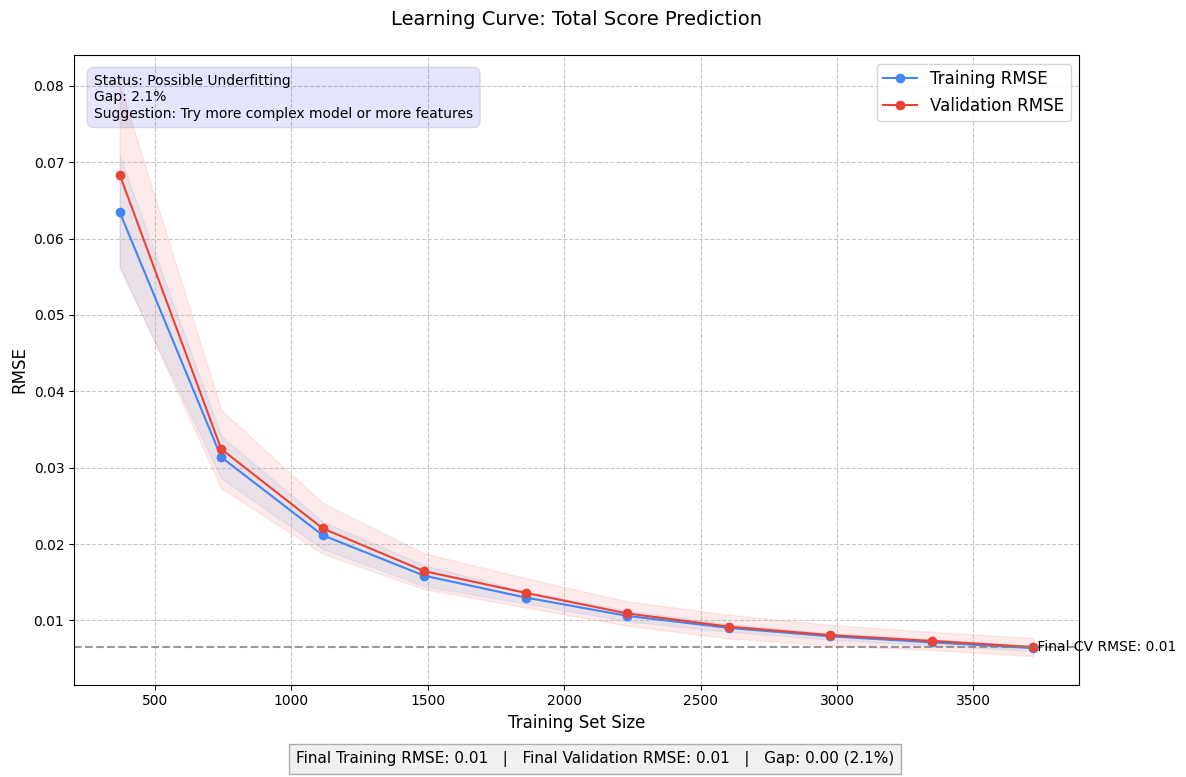

In [53]:
# Cell 15: Enhanced Learning Curve Analysis for Overfitting Diagnostic
from sklearn.model_selection import learning_curve, KFold, validation_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_learning_curve(model, X, y, cv, title="Learning Curve", 
                        scoring='neg_mean_squared_error', 
                        train_sizes=np.linspace(0.1, 1.0, 10),
                        figsize=(12, 8)):
    """
    Plots an enhanced learning curve with standard deviation bands for better overfitting diagnosis.
    
    Args:
        model: Trained model to evaluate
        X: Feature matrix
        y: Target vector
        cv: Cross-validation strategy
        title: Plot title
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        train_sizes: Array of training set sizes to evaluate
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    # Calculate learning curves with cross-validation
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring, 
        train_sizes=train_sizes, n_jobs=-1
    )
    
    # Calculate mean and std for training scores
    train_scores_mean = np.mean(-train_scores, axis=1)
    train_scores_std = np.std(-train_scores, axis=1)
    
    # Calculate mean and std for test scores
    test_scores_mean = np.mean(-test_scores, axis=1)
    test_scores_std = np.std(-test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2  # Adjust std for better visualization
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean training and test scores
    plt.plot(train_sizes, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Calculate overfitting ratio (validation error / training error)
    overfitting_ratio = test_scores_mean / train_scores_mean
    
    # Add annotations
    plt.axhline(y=test_scores_mean[-1], color='gray', linestyle='--', alpha=0.8)
    plt.text(train_sizes[-1], test_scores_mean[-1], f' Final CV {metric_label}: {test_scores_mean[-1]:.2f}', 
             verticalalignment='center')
    
    # Add overfitting assessment
    gap_pct = ((test_scores_mean[-1] - train_scores_mean[-1]) / train_scores_mean[-1]) * 100
    
    if gap_pct > 30:
        overfitting_status = "Severe Overfitting"
        suggestion = "Try stronger regularization, feature reduction, or simpler model"
        status_color = 'red'
    elif gap_pct > 15:
        overfitting_status = "Moderate Overfitting"
        suggestion = "Consider mild regularization or feature selection"
        status_color = 'orange'
    elif gap_pct < 5:
        overfitting_status = "Possible Underfitting"
        suggestion = "Try more complex model or more features"
        status_color = 'blue'
    else:
        overfitting_status = "Good Fit"
        suggestion = "Model complexity seems appropriate"
        status_color = 'green'
    
    plt.annotate(f"Status: {overfitting_status}\nGap: {gap_pct:.1f}%\nSuggestion: {suggestion}",
                xy=(0.02, 0.97), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.5", fc=f"{status_color}", alpha=0.1),
                fontsize=10, ha='left', va='top')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'{title}\n', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    
    # Add score metrics
    train_final = train_scores_mean[-1]
    test_final = test_scores_mean[-1]
    plt.figtext(0.5, 0.01, 
                f"Final Training {metric_label}: {train_final:.2f}   |   "
                f"Final Validation {metric_label}: {test_final:.2f}   |   "
                f"Gap: {test_final-train_final:.2f} ({gap_pct:.1f}%)",
                ha="center", fontsize=11, bbox={"facecolor":"lightgray", "alpha":0.3, "pad":5})
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    
    return {
        'training_final': train_final,
        'validation_final': test_final,
        'gap_percent': gap_pct,
        'status': overfitting_status,
        'suggestion': suggestion
    }

def plot_validation_curve(model, X, y, param_name, param_range, cv=5, 
                          scoring='neg_mean_squared_error', figsize=(12, 6)):
    """
    Plots a validation curve for a specific hyperparameter to find optimal values.
    
    Args:
        model: Model to evaluate
        X: Feature matrix
        y: Target vector
        param_name: Parameter name to vary
        param_range: List of parameter values to try
        cv: Cross-validation strategy
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    train_scores, test_scores = validation_curve(
        model, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    
    # Calculate means and standard deviations
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean accuracy scores for training and testing
    plt.plot(param_range, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(param_range, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Find optimal parameter value
    best_idx = np.argmin(test_scores_mean)
    best_param = param_range[best_idx]
    best_score = test_scores_mean[best_idx]
    
    # Add annotation for best value
    plt.axvline(x=best_param, color='green', linestyle='--', alpha=0.8)
    plt.text(best_param, plt.ylim()[0] * 1.1, f' Best {param_name}={best_param}\n {metric_label}={best_score:.2f}', 
             rotation=90, verticalalignment='bottom')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel(param_name, fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'Validation Curve: {param_name}\n', fontsize=14)
    plt.legend(loc='best', fontsize=12)
    
    # If param_range spans several orders of magnitude, use log scale
    if max(param_range) / min(param_range) > 100:
        plt.xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'best_param': best_param,
        'best_score': best_score
    }

def evaluate_overfitting(model_dict, train_df, target='total_score', pregame_features=None):
    """
    Comprehensive model evaluation to detect and prevent overfitting.
    
    Args:
        model_dict: Dictionary of trained models
        train_df: Training dataframe
        target: Target metric to evaluate
        pregame_features: List of feature columns (if None, will be detected automatically)
    """
    try:
        # Get model from dictionary
        if target not in model_dict:
            print(f"Model for '{target}' not found in model dictionary. Available targets: {list(model_dict.keys())}")
            return
            
        if isinstance(model_dict[target], dict) and 'model' in model_dict[target]:
            model = model_dict[target]['model']
        else:
            model = model_dict[target]
        
        # Auto-detect features if not provided
        if pregame_features is None:
            print("Auto-detecting feature columns...")
            non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                               'home_score', 'away_score', 'point_diff', 'total_score',
                               'home_form', 'away_form', 'id']
            pregame_features = [col for col in train_df.select_dtypes(include=np.number).columns 
                               if col not in non_feature_cols]
            print(f"Detected {len(pregame_features)} feature columns")
        
        # Prepare data
        X_train_lc = train_df[pregame_features]
        y_train_lc = train_df[target]
        
        # Set up cross-validation
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        print(f"Running learning curve analysis for '{target}' prediction...")
        results = plot_learning_curve(model, X_train_lc, y_train_lc, cv=cv, 
                               title=f"Learning Curve: {target.replace('_', ' ').title()} Prediction")
        
        # For GradientBoosting models, analyze key hyperparameters
        if hasattr(model, 'estimators_') and hasattr(model, 'learning_rate'):
            print("\nAnalyzing optimal model complexity...")
            
            # Test different max_depth values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="max_depth",
                param_range=np.array([2, 3, 4, 5, 6, 7]),
                cv=cv
            )
            
            # Test different n_estimators values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="n_estimators",
                param_range=np.array([50, 100, 150, 200, 250, 300]),
                cv=cv
            )
            
            # Test different learning_rate values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="learning_rate",
                param_range=np.array([0.01, 0.05, 0.1, 0.2, 0.3]),
                cv=cv
            )
        
        return results
        
    except Exception as e:
        import traceback
        print(f"Error during overfitting analysis: {str(e)}")
        traceback.print_exc()
        return None

# Example usage (uncomment to run):
# Try to run only if models and train_df variables exist
if 'models' in globals() and 'train_df' in globals():
    print("Evaluating model for overfitting...")
    evaluate_overfitting(models, train_df, target='total_score')
else:
    print("Skipping overfitting analysis - required variables not found in notebook context")
    print("To run analysis, ensure 'models' dictionary and 'train_df' dataframe are available")


                              NBA PREGAME PREDICTION SYSTEM

[18:30:12] [START] Beginning execution of pregame prediction system (0.0s)
[18:30:12] [STEP 1] Loading historical game data with full statistics... (0.0s)
Loading historical games since 2024-09-21 18:30:12.758319
[18:30:12] [SUCCESS] Loaded 1000 historical games with detailed statistics. (0.1s)
[18:30:12] [STEP 2] Calculating enhanced team metrics... (0.1s)
[18:30:13] [DEBUG] Team metrics columns: ['pts_per_game', 'opp_pts_per_game', 'net_ppg', 'q1_avg', 'q2_avg', 'q3_avg', 'q4_avg', 'first_half_avg', 'second_half_avg', 'opp_q1_avg', 'opp_q2_avg', 'opp_q3_avg', 'opp_q4_avg', 'assists_avg', 'steals_avg', 'blocks_avg', 'turnovers_avg', 'fouls_avg', 'off_reb_avg', 'def_reb_avg', 'total_reb_avg', 'opp_assists_avg', 'opp_steals_avg', 'opp_blocks_avg', 'opp_turnovers_avg', 'opp_fouls_avg', 'opp_off_reb_avg', 'opp_def_reb_avg', 'opp_total_reb_avg', 'fg_made_avg', 'fg_att_avg', 'fg_pct', 'avg_fg_pct', 'avg_opp_fg_pct', 'three_pt_mad

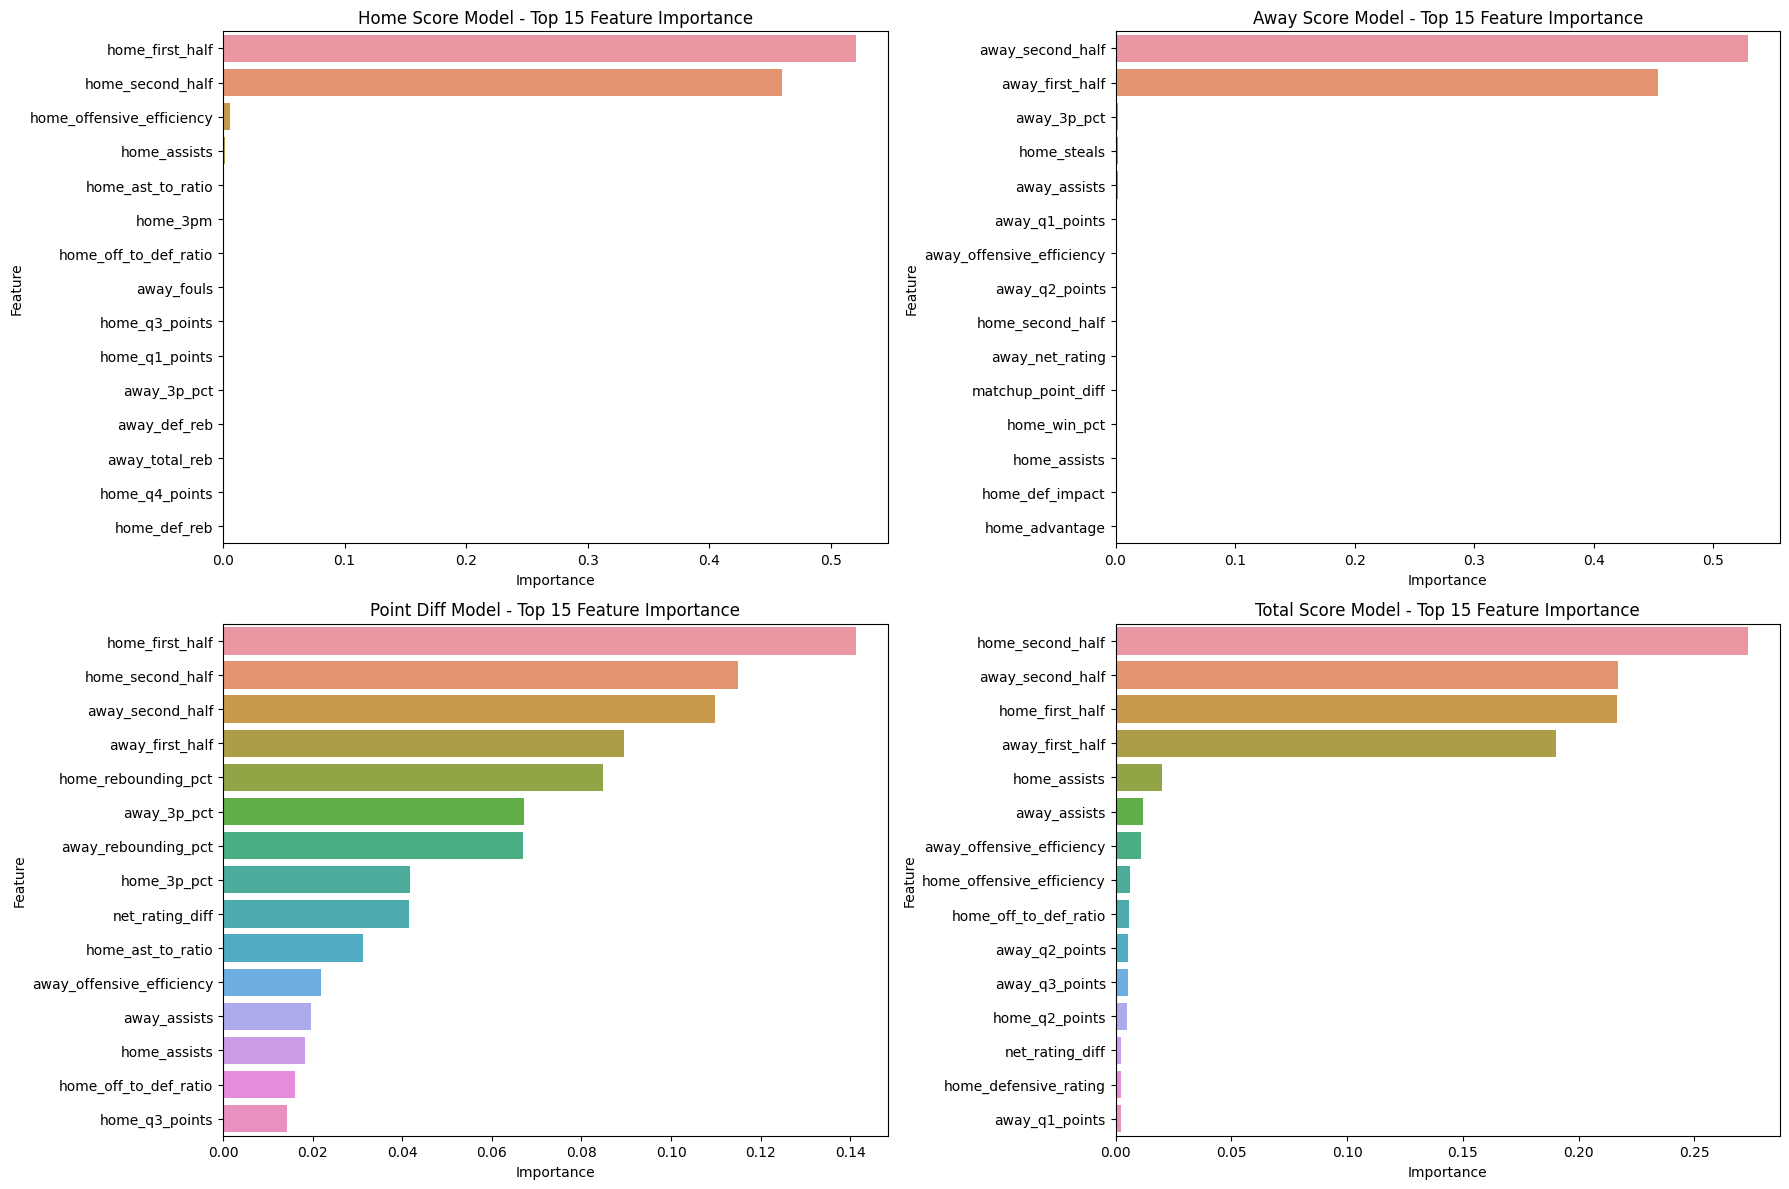

Adding 38 missing features for home_score model visualization
Adding 38 missing features for away_score model visualization
Adding 38 missing features for point_diff model visualization
Adding 38 missing features for total_score model visualization


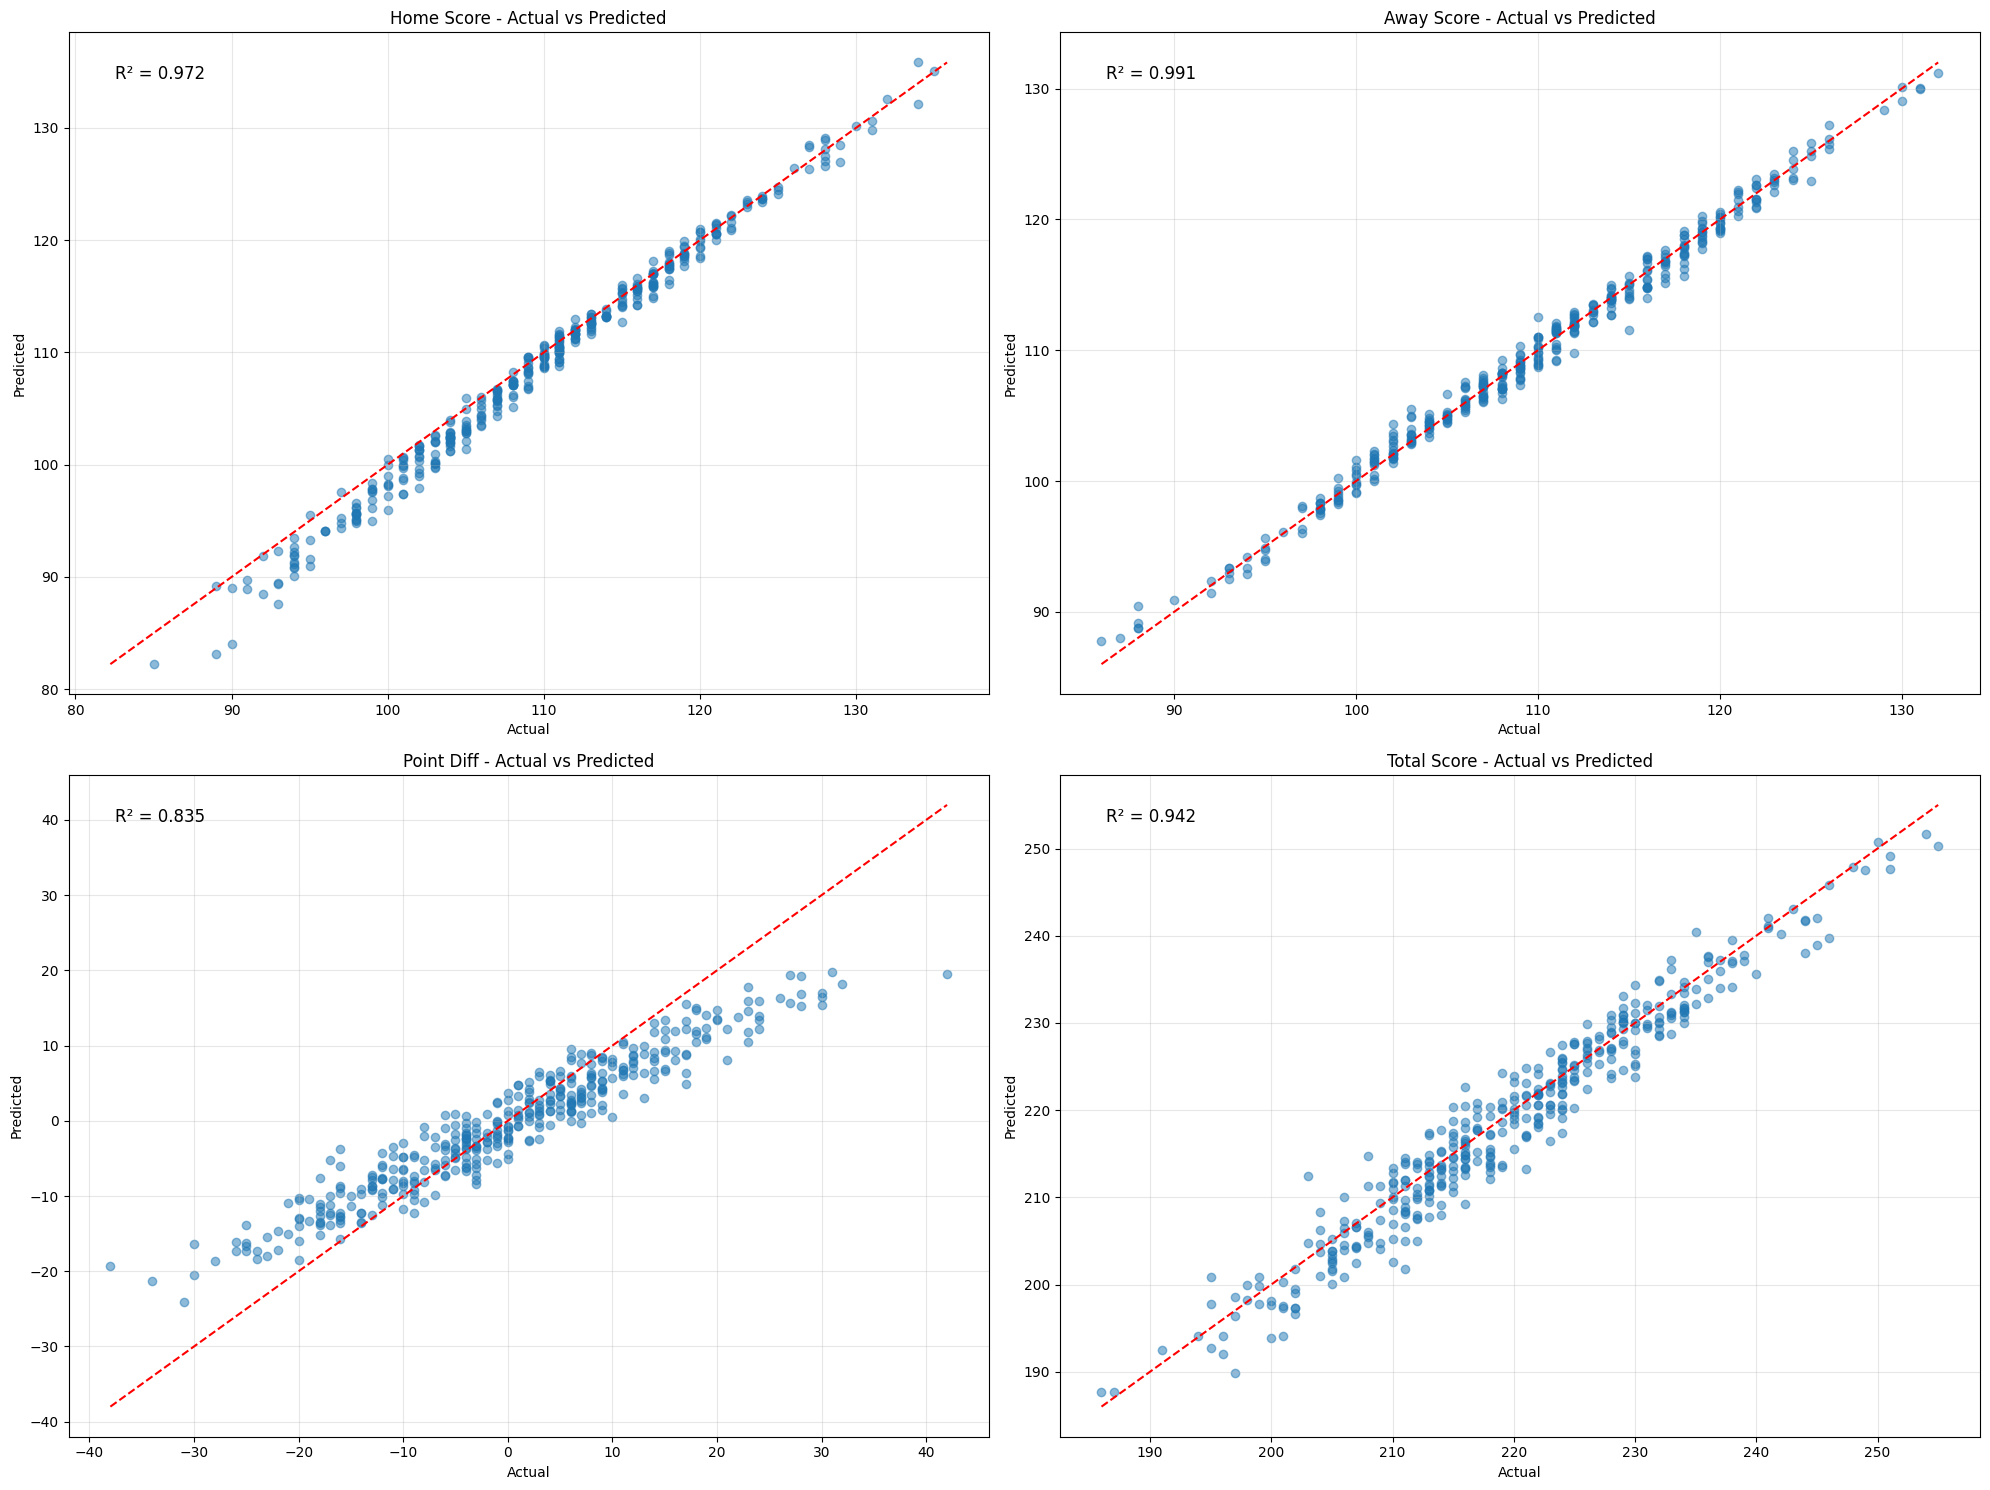

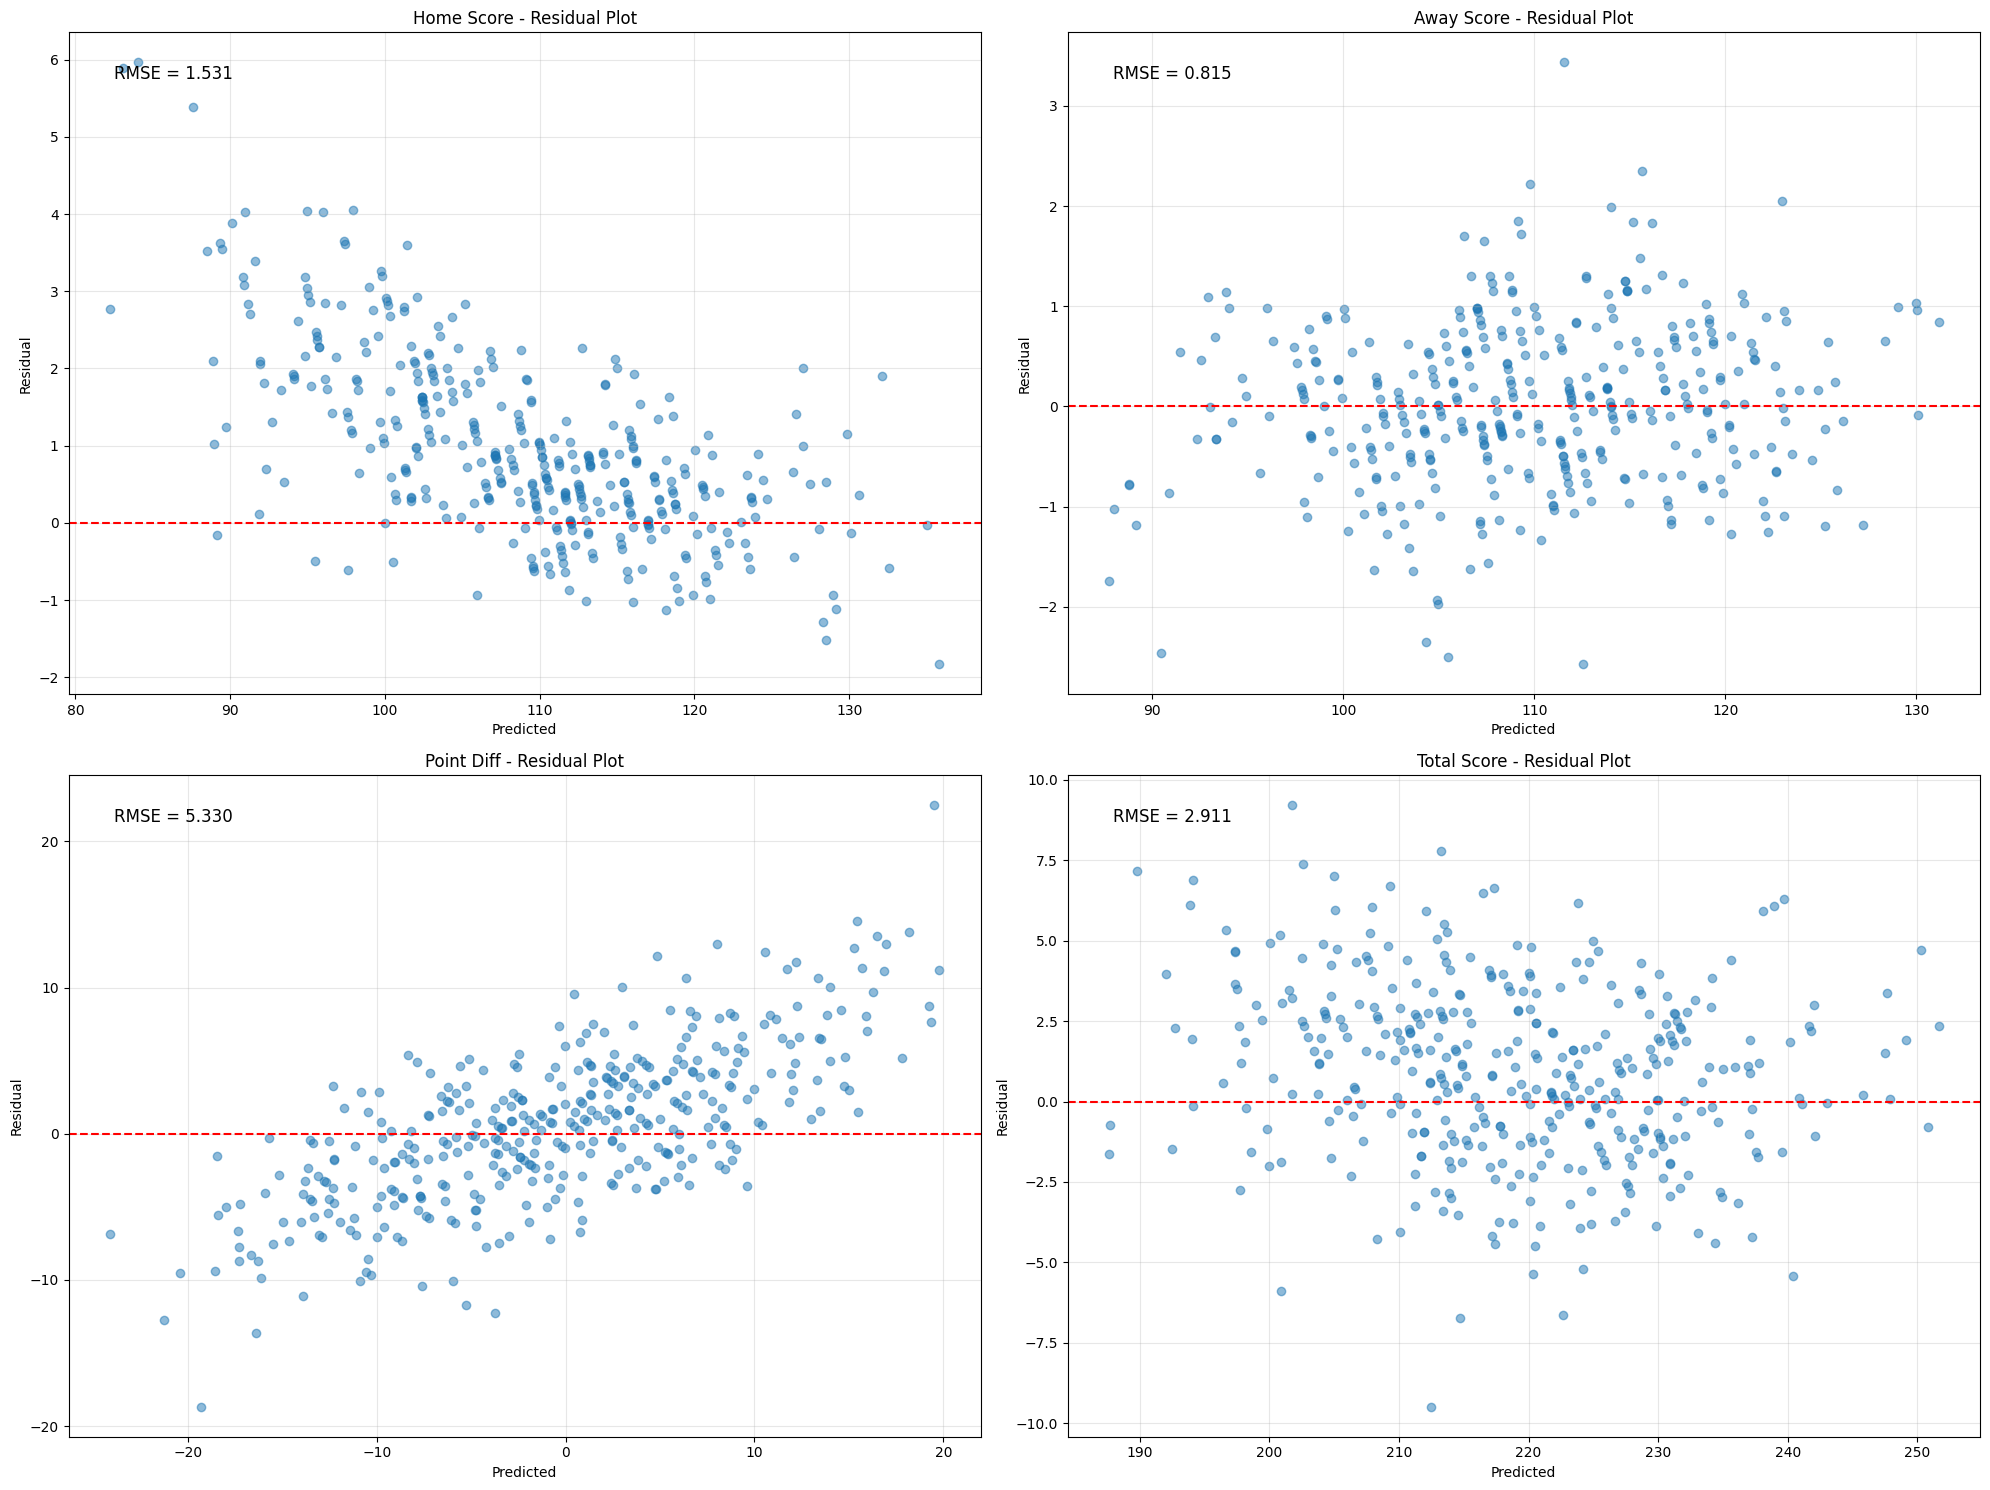

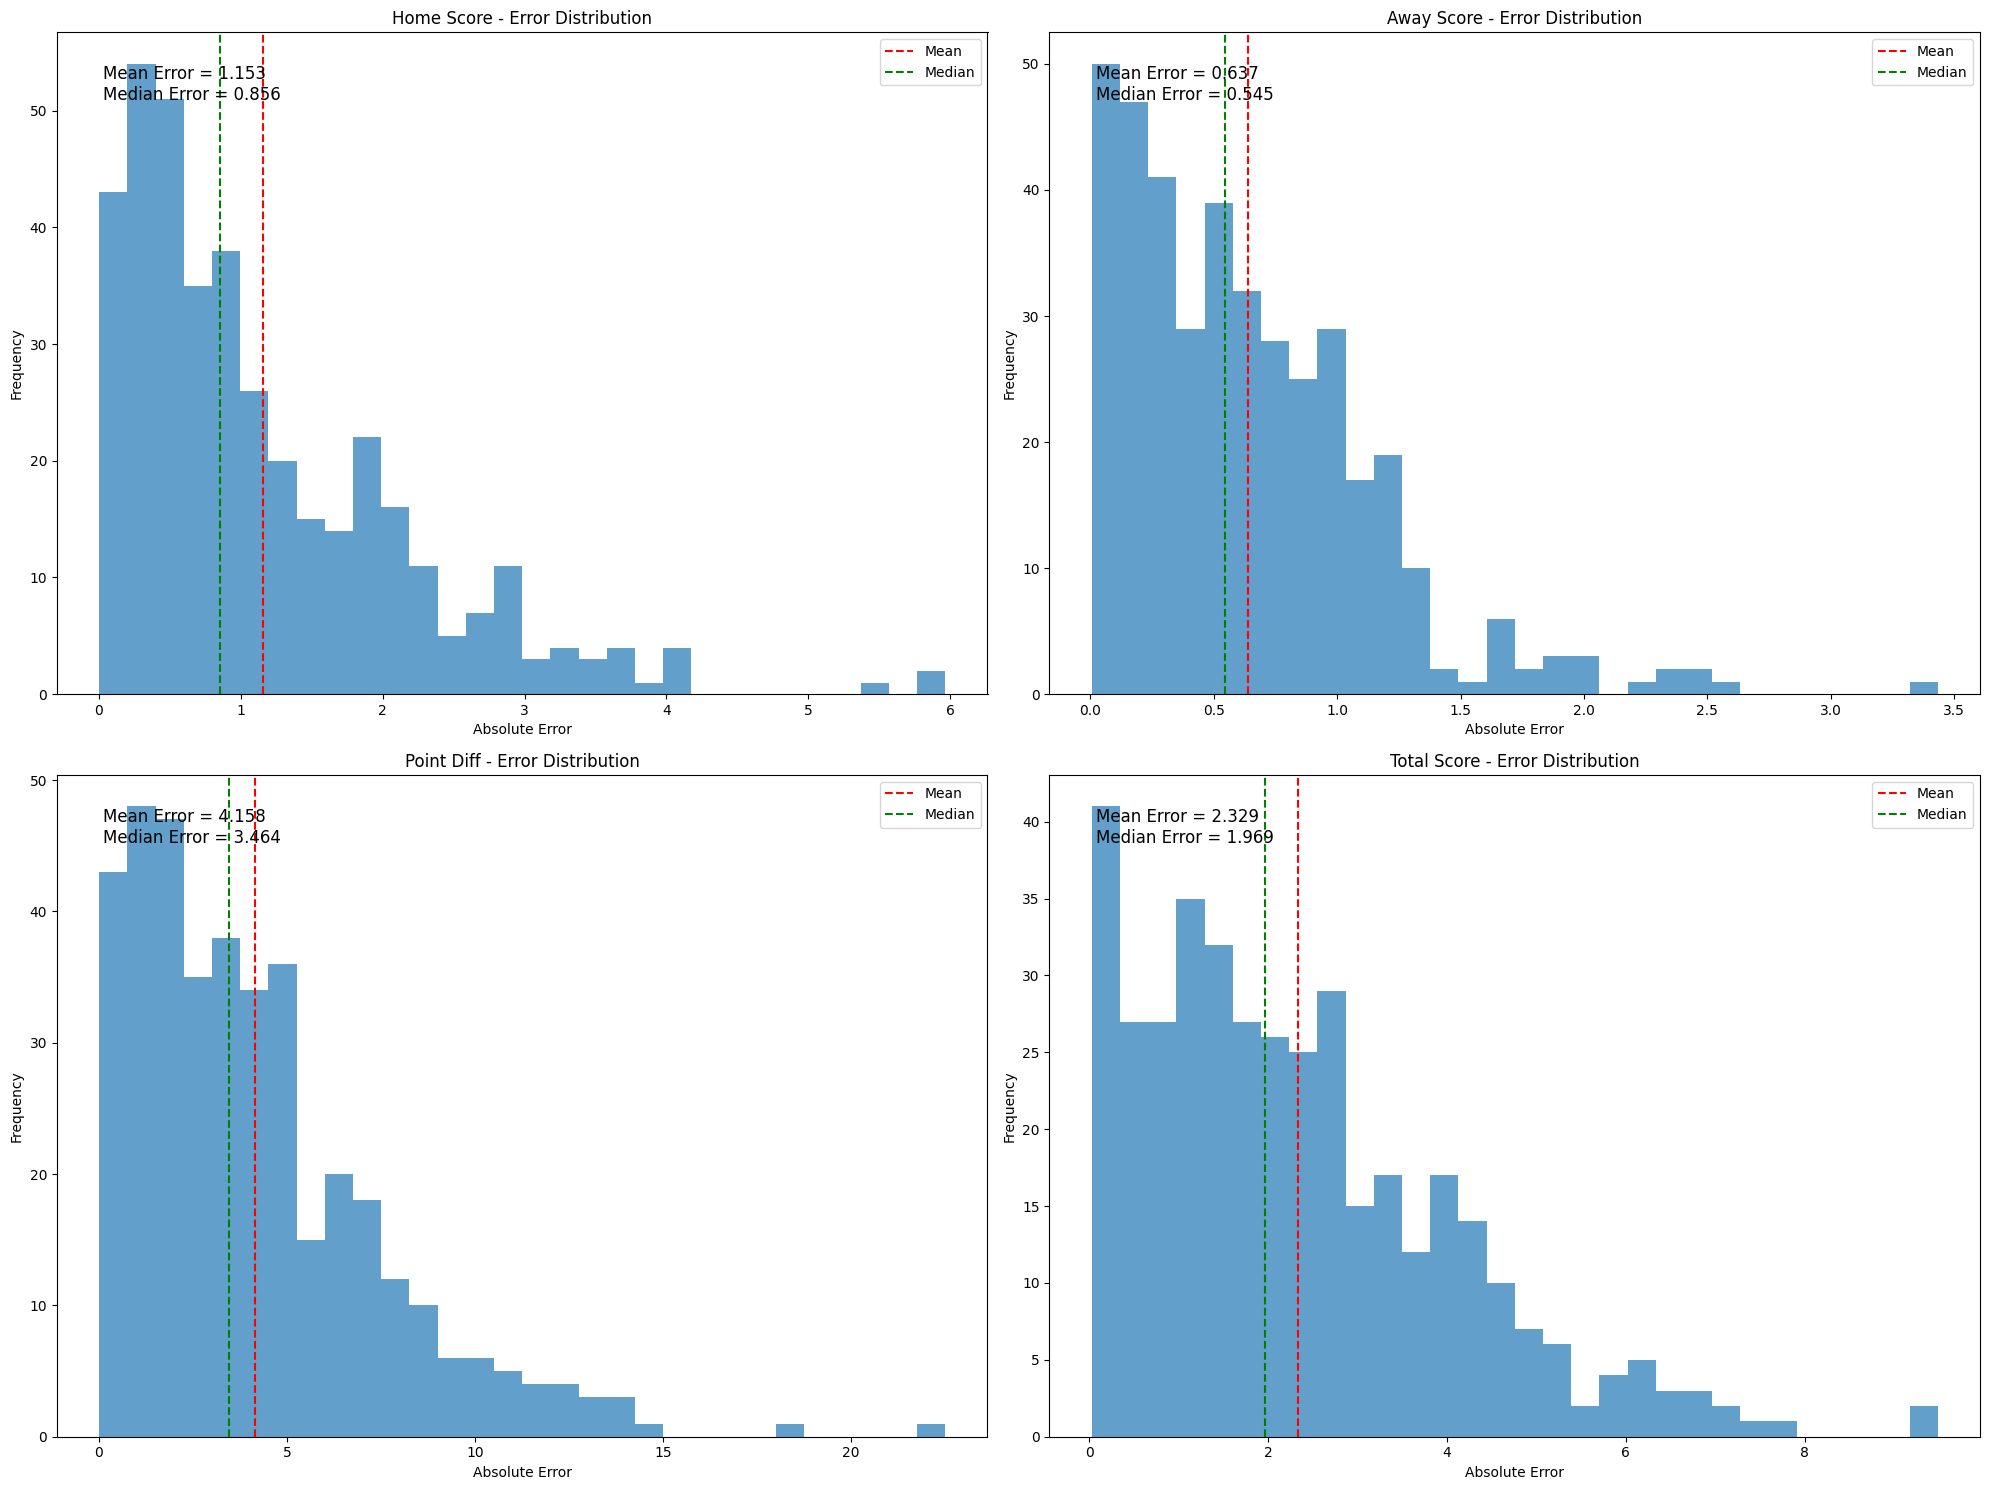

[18:30:22] [SUCCESS] Generated model performance visualizations. (9.7s)
[18:30:22] [STEP 7] Predicting upcoming games... (9.7s)
[18:30:22] [INFO] Found 35 upcoming games to predict (9.7s)
Making prediction for Suns vs Hawks...
Rest days: Home=2.0, Away=2.0, Advantage=0.0
Adding 4 required features for the home_score model
Predicted: Suns 108.2 - 109.2 Hawks (Win prob: 44.7%)
[18:30:22] [PREDICTION] Suns vs Hawks: 108.2-109.2 (Win prob: 44.7%, Confidence: low) (9.8s)
Making prediction for Timberwolves vs Wizards...
Rest days: Home=3.0, Away=2.0, Advantage=1.0
Adding 4 required features for the home_score model
Predicted: Timberwolves 108.4 - 108.7 Wizards (Win prob: 48.2%)
[18:30:22] [PREDICTION] Timberwolves vs Wizards: 108.4-108.7 (Win prob: 48.2%, Confidence: low) (9.9s)
Making prediction for Spurs vs Grizzlies...
Rest days: Home=3.0, Away=4.0, Advantage=-1.0
Adding 4 required features for the home_score model
Predicted: Spurs 107.5 - 109.8 Grizzlies (Win prob: 37.9%)
[18:30:22] [PRE

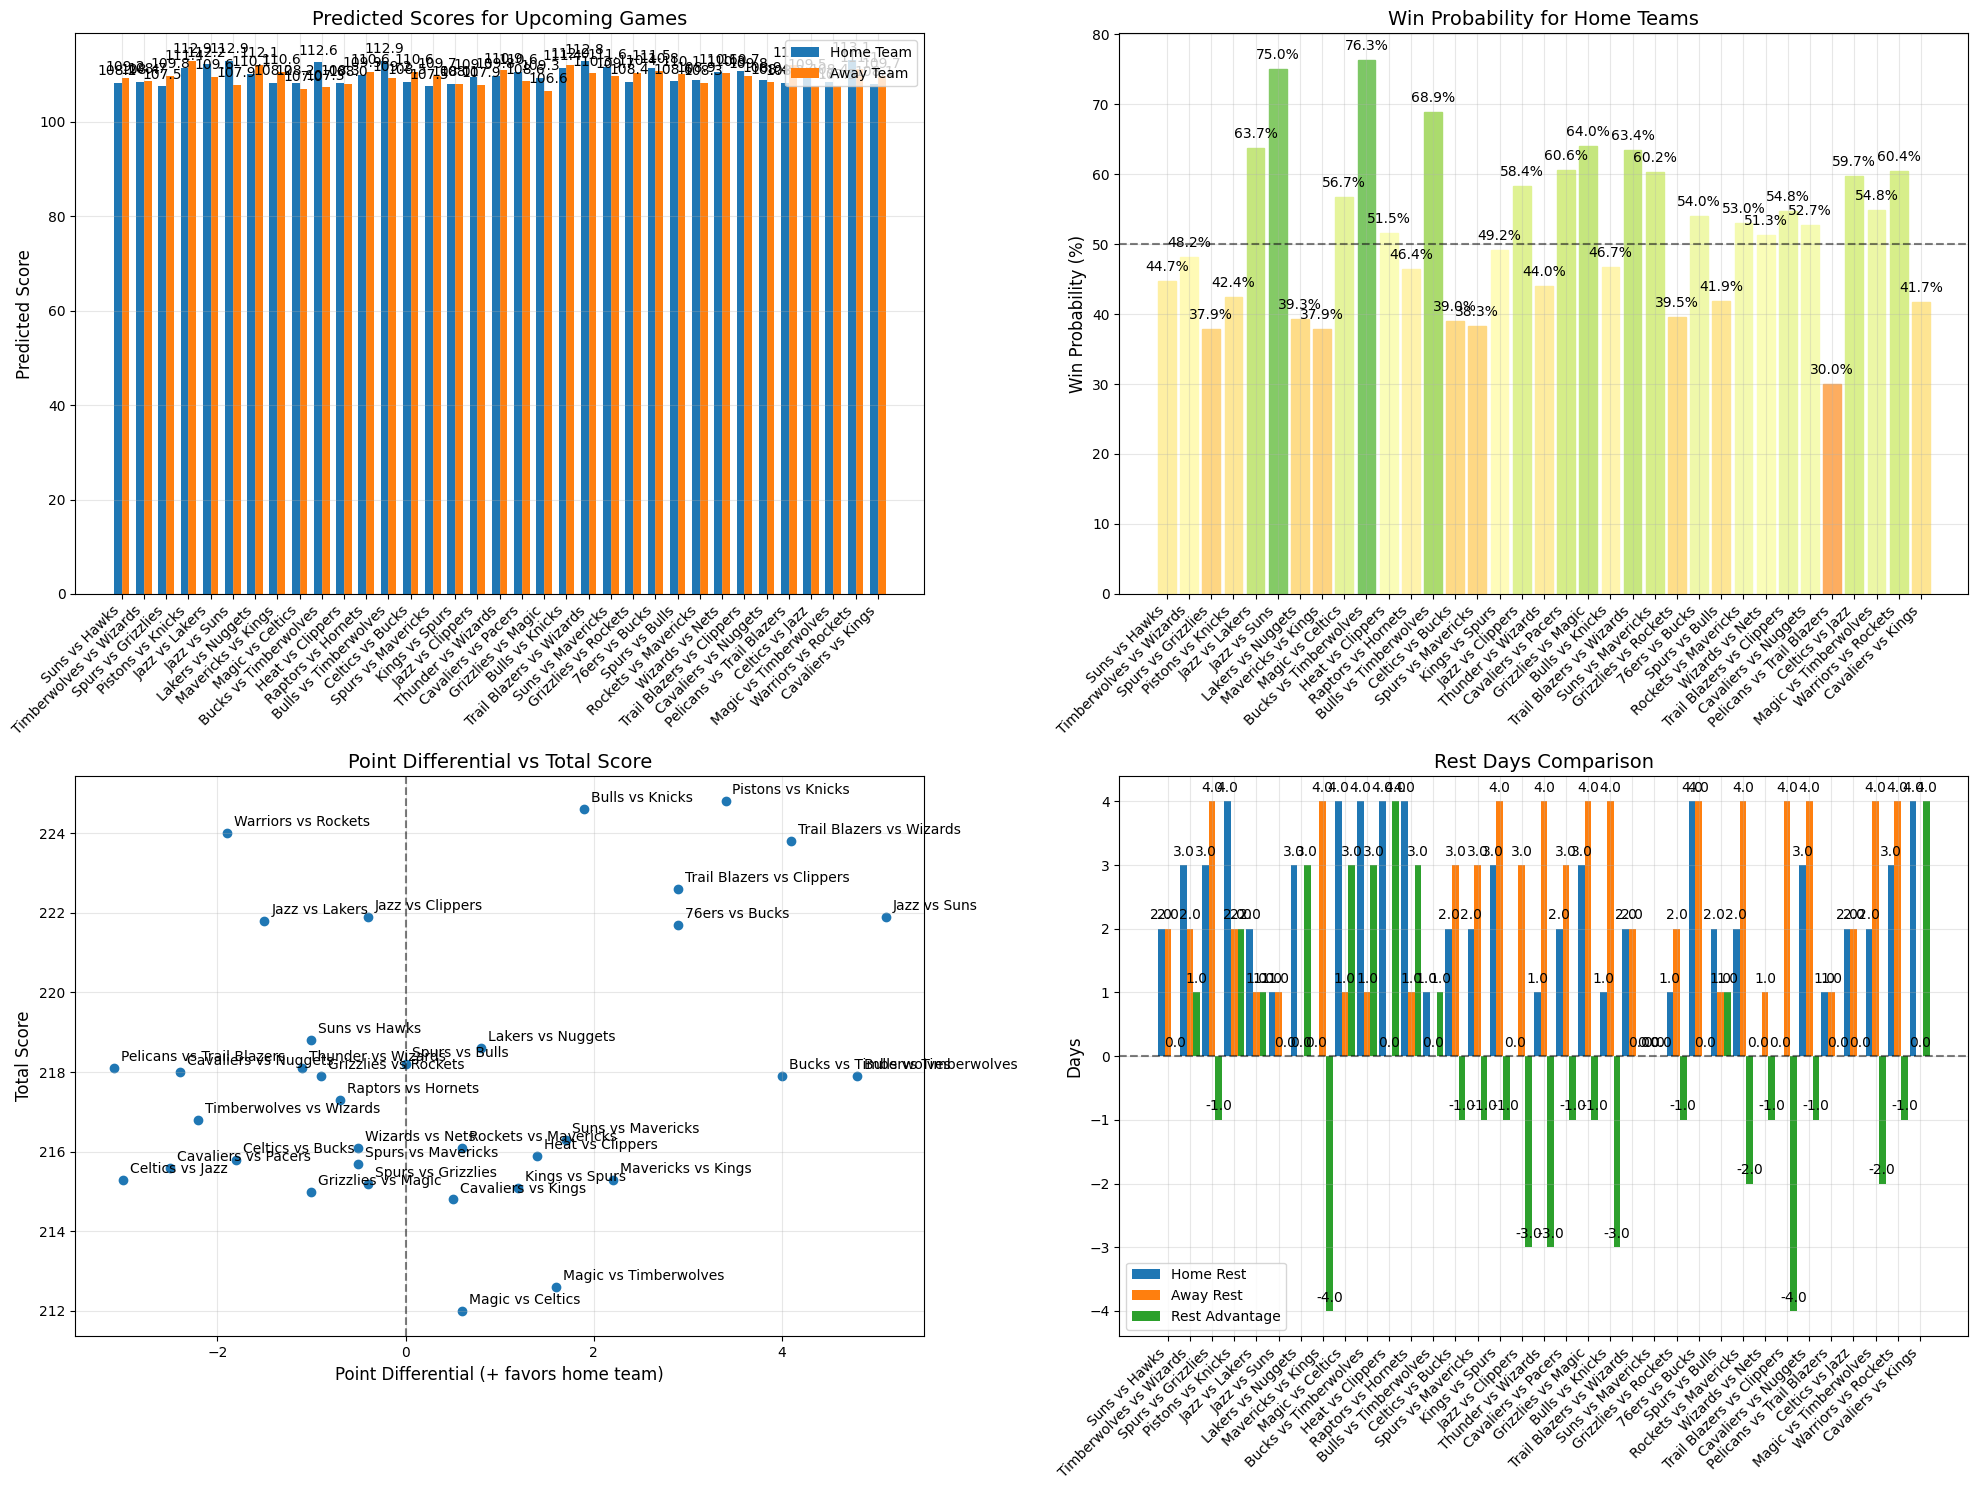

[18:30:30] [SUCCESS] Generated prediction visualizations. (17.3s)
[18:30:30] [STEP 9] Running Monte Carlo simulation for Suns vs Hawks... (17.3s)


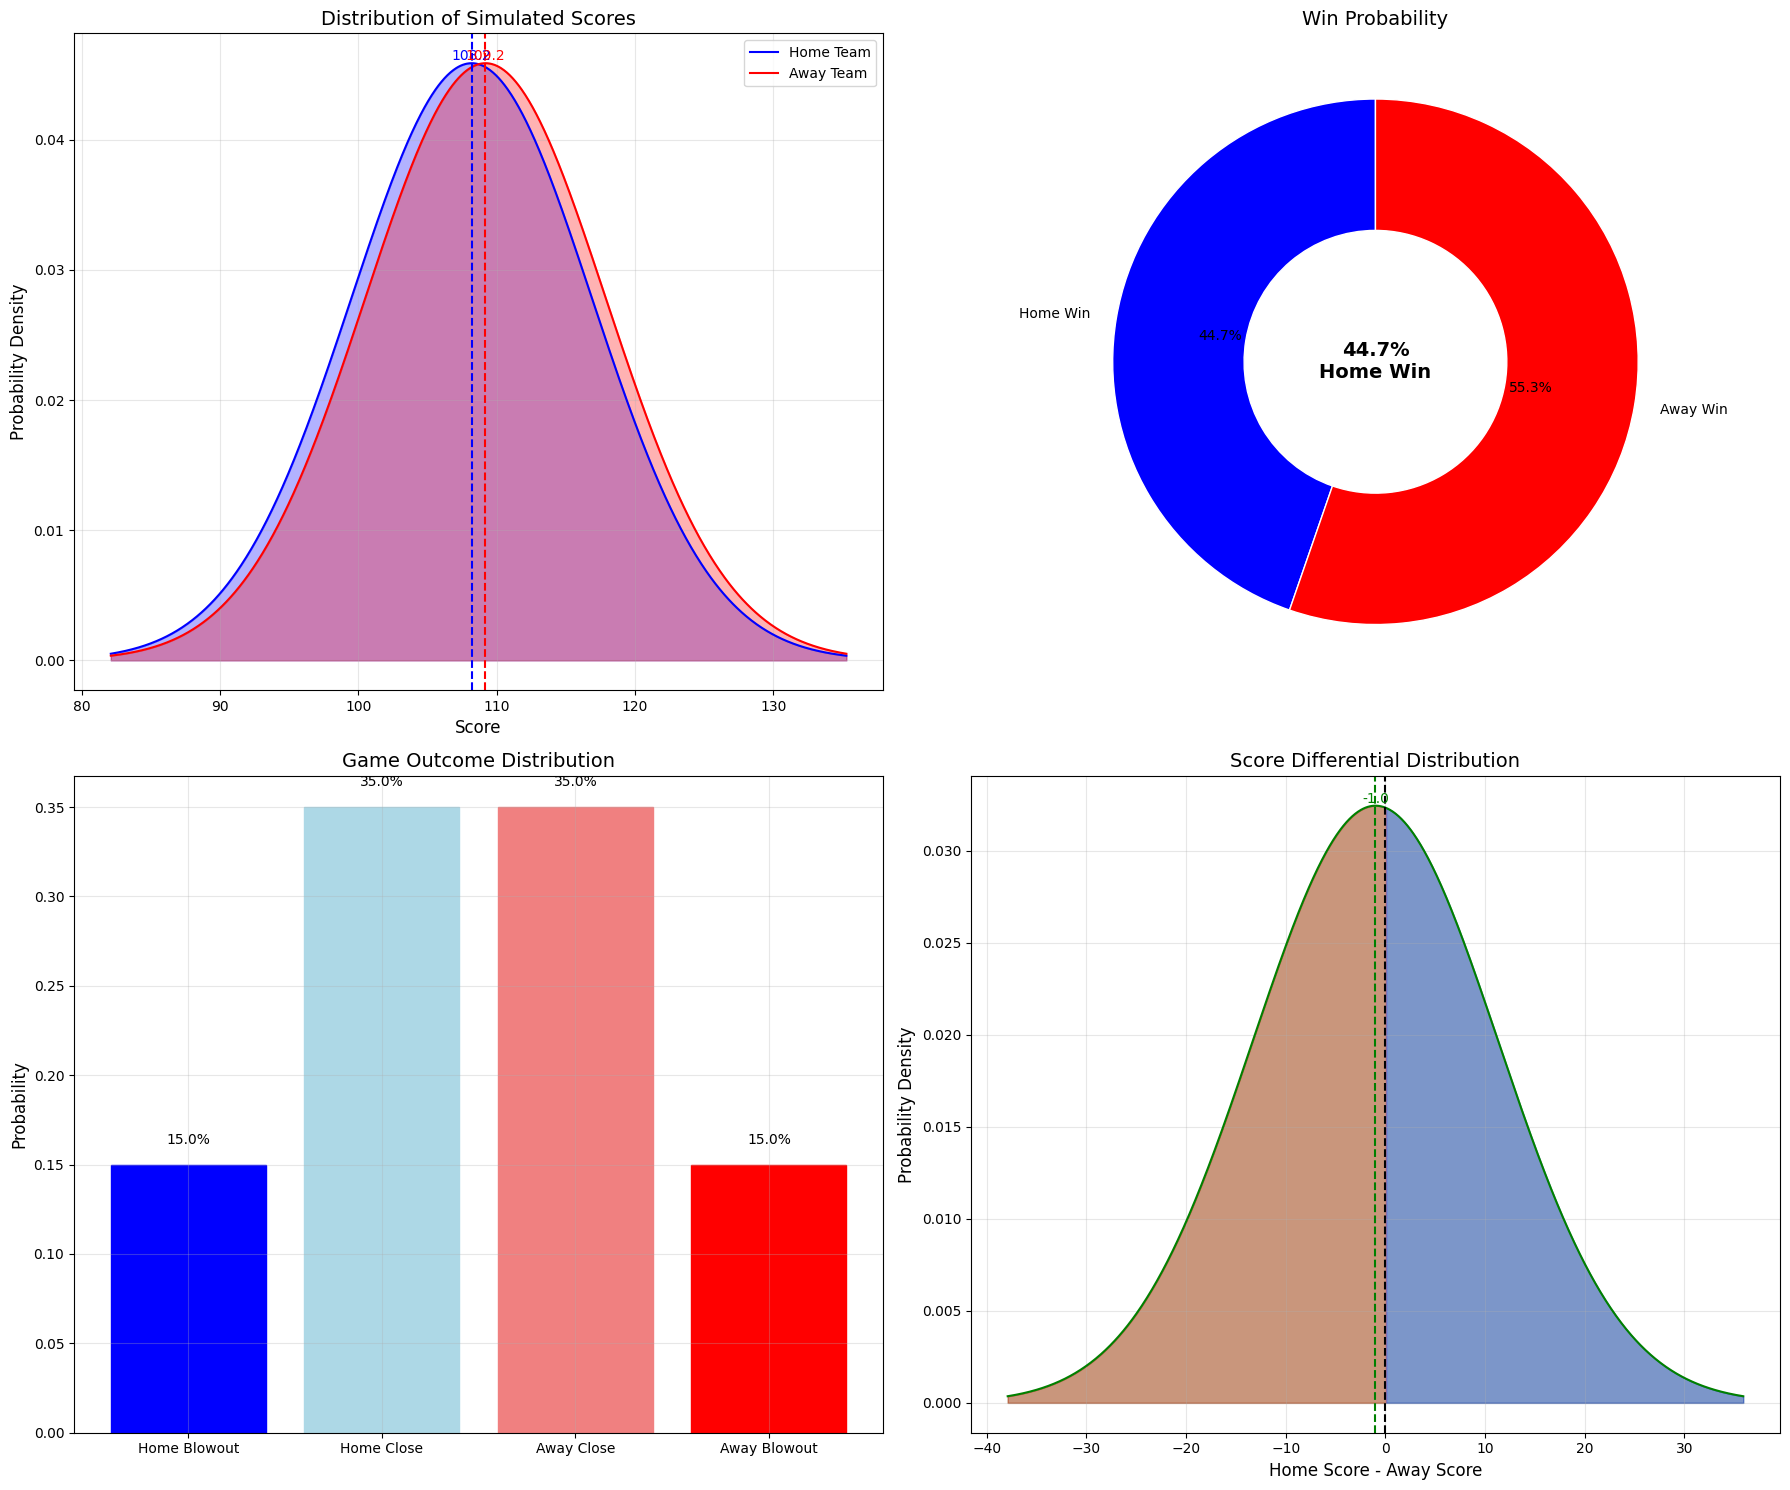

[18:30:31] [SUCCESS] Completed Monte Carlo simulation. (19.0s)
[18:30:31] [STEP 10] Generating betting recommendations... (19.0s)

                         BETTING RECOMMENDATIONS

Suns vs Hawks (2025-03-20)
  Predicted Score: 108.2-109.2
  Win Probability: 44.7%
  Moneyline: No Play
  Spread: No Play
  Total: No Play
  Props: Suns Under 110.5 points
         Hawks Over 104.5 points

Timberwolves vs Wizards (2025-03-20)
  Predicted Score: 108.4-108.7
  Win Probability: 48.2%
  Moneyline: No Play
  Spread: No Play
  Total: No Play
  Props: Timberwolves Under 110.5 points
         Wizards Over 104.5 points

Spurs vs Grizzlies (2025-03-20)
  Predicted Score: 107.5-109.8
  Win Probability: 37.9%
  Moneyline: Away (Grizzlies)
  Spread: No Play
  Total: No Play
  Props: Spurs Under 110.5 points
         Grizzlies Over 104.5 points

Pistons vs Knicks (2025-03-20)
  Predicted Score: 111.4-112.9
  Win Probability: 42.4%
  Moneyline: No Play
  Spread: No Play
  Total: No Play
  Props: Pistons Ov

In [55]:
# Cell 16 - Enhanced Main Function with Fixed Features and Better Predictions
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import os
import math
import random
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import traceback
import joblib
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler

# Define MODELS_DIR if not already defined
MODELS_DIR = Path("./models")
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

def find_team_metrics(team_metrics_df, team_name):
    """
    Find a team's metrics in the team_metrics_df, handling different name formats.
    """
    # Try exact match first
    team_row = team_metrics_df[team_metrics_df['team'] == team_name]
    
    # If not found, try lowercase match
    if team_row.empty:
        team_row = team_metrics_df[team_metrics_df['team'].str.lower() == team_name.lower()]
    
    # If still not found, try partial match
    if team_row.empty:
        team_row = team_metrics_df[team_metrics_df['team'].str.contains(team_name, case=False)]
    
    # If found, return as dictionary
    if not team_row.empty:
        return team_row.iloc[0].to_dict()
    
    # Not found, return empty dict with warning
    print(f"WARNING: Could not find metrics for team '{team_name}'")
    return {}

def get_matchup_history(home_team, away_team, historical_games_df=None, team_metrics_df=None, default_games=0, default_diff=0):
    """
    Get matchup history between two teams.
    """
    if historical_games_df is not None:
        # Filter the historical games for matchups between these teams
        matchups = historical_games_df[(
            ((historical_games_df['home_team'] == home_team) & (historical_games_df['away_team'] == away_team)) |
            ((historical_games_df['home_team'] == away_team) & (historical_games_df['away_team'] == home_team))
        )].sort_values('game_date')
        
        if len(matchups) > 0:
            # Calculate stats from the last 5 matchups or all available
            recent_matchups = matchups.tail(5)
            
            # Calculate point differential from home team perspective
            home_won_count = 0
            point_diffs = []
            
            for _, game in recent_matchups.iterrows():
                if game['home_team'] == home_team:
                    diff = game['home_score'] - game['away_score']
                    home_won_count += 1 if diff > 0 else 0
                else:  # away_team == home_team
                    diff = game['away_score'] - game['home_score']
                    home_won_count += 1 if diff > 0 else 0
                
                point_diffs.append(diff)
            
            return {
                'num_games': len(recent_matchups),
                'avg_point_diff': np.mean(point_diffs) if point_diffs else 0,
                'home_win_pct': home_won_count / len(recent_matchups) if recent_matchups.shape[0] > 0 else 0.5,
                'avg_total_score': recent_matchups['home_score'].mean() + recent_matchups['away_score'].mean(),
                'avg_home_score': recent_matchups[recent_matchups['home_team'] == home_team]['home_score'].mean() if not recent_matchups[recent_matchups['home_team'] == home_team].empty else None,
                'avg_away_score': recent_matchups[recent_matchups['away_team'] == away_team]['away_score'].mean() if not recent_matchups[recent_matchups['away_team'] == away_team].empty else None
            }
    
    # If no historical data or no matchups found, use reasonable defaults
    if team_metrics_df is not None:
        home_metrics = find_team_metrics(team_metrics_df, home_team)
        away_metrics = find_team_metrics(team_metrics_df, away_team)
        
        # Estimate point differential based on net ratings
        home_net = home_metrics.get('net_rating', 0)
        away_net = away_metrics.get('net_rating', 0)
        estimated_diff = home_net - away_net + home_metrics.get('home_advantage', 3.0)
        
        return {
            'num_games': default_games,
            'avg_point_diff': estimated_diff,
            'home_win_pct': 0.5 + (estimated_diff / 20.0),  # Adjust win% based on expected diff
            'avg_total_score': home_metrics.get('pts_per_game', 110.0) + away_metrics.get('pts_per_game', 110.0),
            'avg_home_score': home_metrics.get('pts_per_game', 110.0) + (estimated_diff / 2),
            'avg_away_score': away_metrics.get('pts_per_game', 110.0) - (estimated_diff / 2)
        }
    
    # Fallback to absolute defaults
    return {
        'num_games': default_games,
        'avg_point_diff': default_diff,
        'home_win_pct': 0.5,
        'avg_total_score': 220.0,
        'avg_home_score': 110.0,
        'avg_away_score': 110.0
    }

def calculate_win_probability(home_score, away_score, std_dev=7.5):
    """
    Calculate win probability based on predicted scores with variable standard deviation.
    """
    if home_score is None or away_score is None:
        return 0.5  # Default to 50% if scores are missing
        
    # Calculate point differential
    point_diff = home_score - away_score
    
    # Use cumulative normal distribution to calculate win probability
    # Higher point differential = higher win probability
    # Smaller std_dev = more confident (steeper curve)
    win_prob = 0.5 * (1 + math.erf(point_diff / (std_dev * math.sqrt(2))))
    
    return win_prob

def calculate_advanced_stats(df, rolling_window=10):
    """
    Calculate advanced statistics for each team based on historical games.
    
    Args:
        df: DataFrame with historical game data
        rolling_window: Number of games to use for rolling statistics
    
    Returns:
        Dictionary with team-level advanced metrics
    """
    # Create a dictionary to store team metrics
    team_stats = {}
    
    # Get unique teams
    all_teams = np.unique(np.concatenate([df['home_team'].unique(), df['away_team'].unique()]))
    
    for team in all_teams:
        # Get home and away games
        home_games = df[df['home_team'] == team]
        away_games = df[df['away_team'] == team]
        
        # Combine home and away games into team-perspective games
        # We need to rename some columns to make this consistent
        home_team_games = home_games.rename(columns={
            'home_score': 'team_score', 'away_score': 'opp_score',
            'home_q1': 'team_q1', 'away_q1': 'opp_q1',
            'home_q2': 'team_q2', 'away_q2': 'opp_q2',
            'home_q3': 'team_q3', 'away_q3': 'opp_q3',
            'home_q4': 'team_q4', 'away_q4': 'opp_q4',
            'home_assists': 'team_assists', 'away_assists': 'opp_assists',
            'home_steals': 'team_steals', 'away_steals': 'opp_steals',
            'home_blocks': 'team_blocks', 'away_blocks': 'opp_blocks',
            'home_turnovers': 'team_turnovers', 'away_turnovers': 'opp_turnovers',
            'home_fouls': 'team_fouls', 'away_fouls': 'opp_fouls',
            'home_off_reb': 'team_off_reb', 'away_off_reb': 'opp_off_reb',
            'home_def_reb': 'team_def_reb', 'away_def_reb': 'opp_def_reb',
            'home_total_reb': 'team_total_reb', 'away_total_reb': 'opp_total_reb',
            'home_3pm': 'team_3pm', 'away_3pm': 'opp_3pm',
            'home_3pa': 'team_3pa', 'away_3pa': 'opp_3pa',
            'home_fg_made': 'team_fg_made', 'away_fg_made': 'opp_fg_made',
            'home_fg_attempted': 'team_fg_attempted', 'away_fg_attempted': 'opp_fg_attempted',
            'home_ft_made': 'team_ft_made', 'away_ft_made': 'opp_ft_made',
            'home_ft_attempted': 'team_ft_attempted', 'away_ft_attempted': 'opp_ft_attempted'
        })
        home_team_games['is_home'] = True
        
        away_team_games = away_games.rename(columns={
            'away_score': 'team_score', 'home_score': 'opp_score',
            'away_q1': 'team_q1', 'home_q1': 'opp_q1',
            'away_q2': 'team_q2', 'home_q2': 'opp_q2',
            'away_q3': 'team_q3', 'home_q3': 'opp_q3',
            'away_q4': 'team_q4', 'home_q4': 'opp_q4',
            'away_assists': 'team_assists', 'home_assists': 'opp_assists',
            'away_steals': 'team_steals', 'home_steals': 'opp_steals',
            'away_blocks': 'team_blocks', 'home_blocks': 'opp_blocks',
            'away_turnovers': 'team_turnovers', 'home_turnovers': 'opp_turnovers',
            'away_fouls': 'team_fouls', 'home_fouls': 'opp_fouls',
            'away_off_reb': 'team_off_reb', 'home_off_reb': 'opp_off_reb',
            'away_def_reb': 'team_def_reb', 'home_def_reb': 'opp_def_reb',
            'away_total_reb': 'team_total_reb', 'home_total_reb': 'opp_total_reb',
            'away_3pm': 'team_3pm', 'home_3pm': 'opp_3pm',
            'away_3pa': 'team_3pa', 'home_3pa': 'opp_3pa',
            'away_fg_made': 'team_fg_made', 'home_fg_made': 'opp_fg_made',
            'away_fg_attempted': 'team_fg_attempted', 'home_fg_attempted': 'opp_fg_attempted',
            'away_ft_made': 'team_ft_made', 'home_ft_made': 'opp_ft_made',
            'away_ft_attempted': 'team_ft_attempted', 'home_ft_attempted': 'opp_ft_attempted'
        })
        away_team_games['is_home'] = False
        
        # Combine home and away games and sort by date
        team_games = pd.concat([home_team_games, away_team_games], ignore_index=True)
        team_games = team_games.sort_values('game_date')
        
        # Basic stats
        total_games = len(team_games)
        if total_games == 0:
            team_stats[team] = {
                'team': team,
                'win_pct': 0.5,
                'pts_per_game': 110.0,
                'opp_pts_per_game': 110.0,
                'net_rating': 0.0,
                'offensive_rating': 110.0,
                'defensive_rating': 110.0,
                'home_advantage': 3.0
            }
            continue
            
        wins = sum(team_games['team_score'] > team_games['opp_score'])
        wins_home = sum(team_games['team_score'][team_games['is_home']] > team_games['opp_score'][team_games['is_home']])
        home_games_count = sum(team_games['is_home'])
        
        win_pct = wins / total_games if total_games > 0 else 0.5
        home_win_pct = wins_home / home_games_count if home_games_count > 0 else 0.5
        home_advantage = (team_games['team_score'][team_games['is_home']].mean() - 
                         team_games['team_score'][~team_games['is_home']].mean()) if home_games_count > 0 and (total_games - home_games_count) > 0 else 3.0
        
        # Calculate advanced stats if the data is available
        try:
            avg_stats = {}
            # Scoring averages
            avg_stats['pts_per_game'] = team_games['team_score'].mean()
            avg_stats['opp_pts_per_game'] = team_games['opp_score'].mean()
            avg_stats['net_ppg'] = avg_stats['pts_per_game'] - avg_stats['opp_pts_per_game']
            
            # Calculate quarterly scoring if available
            if 'team_q1' in team_games.columns:
                avg_stats['q1_avg'] = team_games['team_q1'].mean()
                avg_stats['q2_avg'] = team_games['team_q2'].mean()
                avg_stats['q3_avg'] = team_games['team_q3'].mean()
                avg_stats['q4_avg'] = team_games['team_q4'].mean()
                avg_stats['first_half_avg'] = avg_stats['q1_avg'] + avg_stats['q2_avg']
                avg_stats['second_half_avg'] = avg_stats['q3_avg'] + avg_stats['q4_avg']
                
                # Opponent quarterly scoring
                avg_stats['opp_q1_avg'] = team_games['opp_q1'].mean()
                avg_stats['opp_q2_avg'] = team_games['opp_q2'].mean()
                avg_stats['opp_q3_avg'] = team_games['opp_q3'].mean()
                avg_stats['opp_q4_avg'] = team_games['opp_q4'].mean()
            else:
                # Default quarter distribution
                avg_stats['q1_avg'] = avg_stats['pts_per_game'] * 0.25
                avg_stats['q2_avg'] = avg_stats['pts_per_game'] * 0.25
                avg_stats['q3_avg'] = avg_stats['pts_per_game'] * 0.25
                avg_stats['q4_avg'] = avg_stats['pts_per_game'] * 0.25
                avg_stats['first_half_avg'] = avg_stats['pts_per_game'] * 0.5
                avg_stats['second_half_avg'] = avg_stats['pts_per_game'] * 0.5
                avg_stats['opp_q1_avg'] = avg_stats['opp_pts_per_game'] * 0.25
                avg_stats['opp_q2_avg'] = avg_stats['opp_pts_per_game'] * 0.25
                avg_stats['opp_q3_avg'] = avg_stats['opp_pts_per_game'] * 0.25
                avg_stats['opp_q4_avg'] = avg_stats['opp_pts_per_game'] * 0.25
            
            # Box score stats
            if 'team_assists' in team_games.columns:
                avg_stats['assists_avg'] = team_games['team_assists'].mean()
                avg_stats['steals_avg'] = team_games['team_steals'].mean()
                avg_stats['blocks_avg'] = team_games['team_blocks'].mean()
                avg_stats['turnovers_avg'] = team_games['team_turnovers'].mean()
                avg_stats['fouls_avg'] = team_games['team_fouls'].mean()
                avg_stats['off_reb_avg'] = team_games['team_off_reb'].mean()
                avg_stats['def_reb_avg'] = team_games['team_def_reb'].mean()
                avg_stats['total_reb_avg'] = team_games['team_total_reb'].mean()
                
                # Opposition stats
                avg_stats['opp_assists_avg'] = team_games['opp_assists'].mean()
                avg_stats['opp_steals_avg'] = team_games['opp_steals'].mean()
                avg_stats['opp_blocks_avg'] = team_games['opp_blocks'].mean()
                avg_stats['opp_turnovers_avg'] = team_games['opp_turnovers'].mean()
                avg_stats['opp_fouls_avg'] = team_games['opp_fouls'].mean()
                avg_stats['opp_off_reb_avg'] = team_games['opp_off_reb'].mean()
                avg_stats['opp_def_reb_avg'] = team_games['opp_def_reb'].mean()
                avg_stats['opp_total_reb_avg'] = team_games['opp_total_reb'].mean()
            
            # Shooting stats
            if 'team_fg_made' in team_games.columns:
                avg_stats['fg_made_avg'] = team_games['team_fg_made'].mean()
                avg_stats['fg_att_avg'] = team_games['team_fg_attempted'].mean()
                avg_stats['fg_pct'] = avg_stats['fg_made_avg'] / avg_stats['fg_att_avg'] if avg_stats['fg_att_avg'] > 0 else 0.45
                
                avg_stats['avg_fg_pct'] = team_games['team_fg_made'].sum() / team_games['team_fg_attempted'].sum() if team_games['team_fg_attempted'].sum() > 0 else 0.45
                avg_stats['avg_opp_fg_pct'] = team_games['opp_fg_made'].sum() / team_games['opp_fg_attempted'].sum() if team_games['opp_fg_attempted'].sum() > 0 else 0.45
            
            if 'team_3pm' in team_games.columns:
                avg_stats['three_pt_made_avg'] = team_games['team_3pm'].mean()
                avg_stats['three_pt_att_avg'] = team_games['team_3pa'].mean()
                avg_stats['three_pt_pct'] = avg_stats['three_pt_made_avg'] / avg_stats['three_pt_att_avg'] if avg_stats['three_pt_att_avg'] > 0 else 0.35
                
                avg_stats['avg_3pt_pct'] = team_games['team_3pm'].sum() / team_games['team_3pa'].sum() if team_games['team_3pa'].sum() > 0 else 0.35
                avg_stats['avg_opp_3pt_pct'] = team_games['opp_3pm'].sum() / team_games['opp_3pa'].sum() if team_games['opp_3pa'].sum() > 0 else 0.35
            
            if 'team_ft_made' in team_games.columns:
                avg_stats['ft_made_avg'] = team_games['team_ft_made'].mean()
                avg_stats['ft_att_avg'] = team_games['team_ft_attempted'].mean()
                avg_stats['ft_pct'] = avg_stats['ft_made_avg'] / avg_stats['ft_att_avg'] if avg_stats['ft_att_avg'] > 0 else 0.75
                
                avg_stats['avg_ft_pct'] = team_games['team_ft_made'].sum() / team_games['team_ft_attempted'].sum() if team_games['team_ft_attempted'].sum() > 0 else 0.75
                avg_stats['avg_opp_ft_pct'] = team_games['opp_ft_made'].sum() / team_games['opp_ft_attempted'].sum() if team_games['opp_ft_attempted'].sum() > 0 else 0.75
            
            # Calculate possessions and pace
            if 'team_fg_attempted' in team_games.columns:
                team_games['team_possessions'] = (team_games['team_fg_attempted'] + 
                                                 0.44 * team_games['team_ft_attempted'] - 
                                                 team_games['team_off_reb'] + 
                                                 team_games['team_turnovers'])
                
                team_games['opp_possessions'] = (team_games['opp_fg_attempted'] + 
                                               0.44 * team_games['opp_ft_attempted'] - 
                                               team_games['opp_off_reb'] + 
                                               team_games['opp_turnovers'])
                
                team_games['game_pace'] = (team_games['team_possessions'] + team_games['opp_possessions']) / 2 * 48 / 48
                
                avg_stats['possessions_avg'] = team_games['team_possessions'].mean()
                avg_stats['avg_pace'] = team_games['game_pace'].mean()
                avg_stats['home_avg_pace'] = team_games['game_pace'][team_games['is_home']].mean() if home_games_count > 0 else avg_stats['avg_pace']
                avg_stats['away_avg_pace'] = team_games['game_pace'][~team_games['is_home']].mean() if (total_games - home_games_count) > 0 else avg_stats['avg_pace']
                
                # Offensive and defensive ratings (pts per 100 possessions)
                avg_stats['offensive_rating'] = 100 * team_games['team_score'].sum() / team_games['team_possessions'].sum() if team_games['team_possessions'].sum() > 0 else 110.0
                avg_stats['defensive_rating'] = 100 * team_games['opp_score'].sum() / team_games['opp_possessions'].sum() if team_games['opp_possessions'].sum() > 0 else 110.0
                avg_stats['net_rating'] = avg_stats['offensive_rating'] - avg_stats['defensive_rating']
            else:
                # Default ratings if possession data not available
                avg_stats['possessions_avg'] = 100.0
                avg_stats['avg_pace'] = 99.0
                avg_stats['home_avg_pace'] = 100.0
                avg_stats['away_avg_pace'] = 98.0
                avg_stats['offensive_rating'] = 110.0
                avg_stats['defensive_rating'] = 110.0
                avg_stats['net_rating'] = 0.0
            
            # Form and momentum
            if len(team_games) >= rolling_window:
                # Recent form (last 10 games)
                recent_games = team_games.tail(rolling_window)
                avg_stats['form_win_pct'] = sum(recent_games['team_score'] > recent_games['opp_score']) / rolling_window
                
                # Momentum (win streaks)
                results = (team_games['team_score'] > team_games['opp_score']).astype(int).tolist()
                current_streak = 0
                for result in reversed(results):
                    if result == 1:
                        current_streak += 1
                    else:
                        break
                avg_stats['current_streak'] = current_streak
                
                # Momentum score (+ve for winning streak, -ve for losing streak)
                avg_stats['momentum_score'] = current_streak if results[-1] == 1 else -1 * (1 + len(results) - 1 - results[::-1].index(1)) if 1 in results else -1 * len(results)
            else:
                avg_stats['form_win_pct'] = win_pct
                avg_stats['current_streak'] = 0
                avg_stats['momentum_score'] = 0
                
            # Calculate home/away splits
            if home_games_count > 0:
                avg_stats['home_pts_per_game'] = team_games['team_score'][team_games['is_home']].mean()
                avg_stats['home_opp_pts_per_game'] = team_games['opp_score'][team_games['is_home']].mean()
                avg_stats['home_win_pct'] = win_pct if home_games_count == 0 else wins_home / home_games_count
                
                if 'team_fg_made' in team_games.columns:
                    avg_stats['home_avg_fg_pct'] = (team_games['team_fg_made'][team_games['is_home']].sum() / 
                                                 team_games['team_fg_attempted'][team_games['is_home']].sum() 
                                                 if team_games['team_fg_attempted'][team_games['is_home']].sum() > 0 else 0.45)
                
                if 'team_ft_made' in team_games.columns:
                    avg_stats['home_avg_ft_pct'] = (team_games['team_ft_made'][team_games['is_home']].sum() / 
                                                 team_games['team_ft_attempted'][team_games['is_home']].sum() 
                                                 if team_games['team_ft_attempted'][team_games['is_home']].sum() > 0 else 0.75)
            else:
                avg_stats['home_pts_per_game'] = avg_stats['pts_per_game']
                avg_stats['home_opp_pts_per_game'] = avg_stats['opp_pts_per_game']
                avg_stats['home_win_pct'] = win_pct
                avg_stats['home_avg_fg_pct'] = avg_stats.get('avg_fg_pct', 0.45)
                avg_stats['home_avg_ft_pct'] = avg_stats.get('avg_ft_pct', 0.75)
            
            if (total_games - home_games_count) > 0:
                avg_stats['away_pts_per_game'] = team_games['team_score'][~team_games['is_home']].mean()
                avg_stats['away_opp_pts_per_game'] = team_games['opp_score'][~team_games['is_home']].mean()
                avg_stats['away_win_pct'] = win_pct if (total_games - home_games_count) == 0 else (wins - wins_home) / (total_games - home_games_count)
                
                if 'team_fg_made' in team_games.columns:
                    avg_stats['away_avg_fg_pct'] = (team_games['team_fg_made'][~team_games['is_home']].sum() / 
                                                 team_games['team_fg_attempted'][~team_games['is_home']].sum() 
                                                 if team_games['team_fg_attempted'][~team_games['is_home']].sum() > 0 else 0.45)
                
                if 'team_ft_made' in team_games.columns:
                    avg_stats['away_avg_ft_pct'] = (team_games['team_ft_made'][~team_games['is_home']].sum() / 
                                                 team_games['team_ft_attempted'][~team_games['is_home']].sum() 
                                                 if team_games['team_ft_attempted'][~team_games['is_home']].sum() > 0 else 0.75)
            else:
                avg_stats['away_pts_per_game'] = avg_stats['pts_per_game']
                avg_stats['away_opp_pts_per_game'] = avg_stats['opp_pts_per_game']
                avg_stats['away_win_pct'] = win_pct
                avg_stats['away_avg_fg_pct'] = avg_stats.get('avg_fg_pct', 0.45)
                avg_stats['away_avg_ft_pct'] = avg_stats.get('avg_ft_pct', 0.75)
                
            # Make sure we have all the model-required shooting percentage features
            feature_defaults = {
                'avg_fg_pct': 0.45, 'avg_opp_fg_pct': 0.45,
                'home_avg_fg_pct': 0.45, 'away_avg_fg_pct': 0.45,
                'avg_ft_pct': 0.75, 'avg_opp_ft_pct': 0.75,
                'home_avg_ft_pct': 0.75, 'away_avg_ft_pct': 0.75,
                'avg_3pt_pct': 0.35, 'avg_opp_3pt_pct': 0.35,
                'avg_pace': 99.0, 'home_avg_pace': 100.0, 'away_avg_pace': 98.0
            }
            
            for feature, default in feature_defaults.items():
                if feature not in avg_stats:
                    avg_stats[feature] = default
                    
            # Store all stats for this team
            team_stats[team] = avg_stats
            team_stats[team]['team'] = team
            team_stats[team]['win_pct'] = win_pct
            team_stats[team]['home_win_pct'] = home_win_pct
            team_stats[team]['home_advantage'] = home_advantage
            
        except Exception as e:
            print(f"Error calculating advanced stats for {team}: {e}")
            # Provide basic default stats
            team_stats[team] = {
                'team': team,
                'win_pct': win_pct,
                'pts_per_game': team_games['team_score'].mean() if 'team_score' in team_games else 110.0,
                'opp_pts_per_game': team_games['opp_score'].mean() if 'opp_score' in team_games else 110.0,
                'net_rating': 0.0,
                'offensive_rating': 110.0,
                'defensive_rating': 110.0,
                'home_advantage': home_advantage,
                'avg_fg_pct': 0.45,
                'avg_opp_fg_pct': 0.45,
                'home_avg_fg_pct': 0.45,
                'away_avg_fg_pct': 0.45,
                'avg_ft_pct': 0.75,
                'avg_opp_ft_pct': 0.75,
                'home_avg_ft_pct': 0.75,
                'away_avg_ft_pct': 0.75,
                'avg_3pt_pct': 0.35,
                'avg_opp_3pt_pct': 0.35,
                'avg_pace': 99.0,
                'home_avg_pace': 100.0,
                'away_avg_pace': 98.0
            }
    
    return team_stats

def predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_games_df=None):
    """
    Predict scores and win probability for an upcoming game with enhanced feature engineering.
    """
    try:
        # Convert game to dictionary if it's a Series
        if isinstance(game, pd.Series):
            game = game.to_dict()
            
        # Identify teams
        home_team = game['home_team']
        away_team = game['away_team']
        
        print(f"Making prediction for {home_team} vs {away_team}...")
        
        # Find team metrics
        home_team_metrics = find_team_metrics(team_metrics_df, home_team)
        away_team_metrics = find_team_metrics(team_metrics_df, away_team)
        
        # Get matchup history
        matchup = get_matchup_history(home_team, away_team, historical_games_df, team_metrics_df)
        
        # Build feature dictionary with comprehensive features
        feature_dict = {}
        
        # Game identifiers
        feature_dict['game_id'] = game.get('game_id', 0)
        feature_dict['home_team'] = home_team
        feature_dict['away_team'] = away_team
        
        # Team performance metrics
        feature_dict['home_win_pct'] = home_team_metrics.get('win_pct', 0.5)
        feature_dict['away_win_pct'] = away_team_metrics.get('win_pct', 0.5)
        feature_dict['home_offensive_rating'] = home_team_metrics.get('offensive_rating', 110.0)
        feature_dict['away_offensive_rating'] = away_team_metrics.get('offensive_rating', 110.0)
        feature_dict['home_defensive_rating'] = home_team_metrics.get('defensive_rating', 110.0)
        feature_dict['away_defensive_rating'] = away_team_metrics.get('defensive_rating', 110.0)
        feature_dict['home_net_rating'] = home_team_metrics.get('net_rating', 0.0)
        feature_dict['away_net_rating'] = away_team_metrics.get('net_rating', 0.0)
        feature_dict['net_rating_diff'] = feature_dict['home_net_rating'] - feature_dict['away_net_rating']
        
        # Matchup history
        feature_dict['matchup_games'] = matchup['num_games']
        feature_dict['matchup_point_diff'] = matchup['avg_point_diff']
        feature_dict['home_historical_win_pct'] = matchup['home_win_pct']
        feature_dict['home_advantage'] = home_team_metrics.get('home_advantage', 3.5)
        
        # Rest days
        home_rest_days = float(game.get('home_rest_days', 2.0))
        away_rest_days = float(game.get('away_rest_days', 2.0))
        feature_dict['home_rest_days'] = home_rest_days
        feature_dict['away_rest_days'] = away_rest_days
        feature_dict['rest_advantage'] = home_rest_days - away_rest_days
        feature_dict['home_back_to_back'] = 1.0 if home_rest_days == 0 else 0.0
        feature_dict['away_back_to_back'] = 1.0 if away_rest_days == 0 else 0.0
        
        print(f"Rest days: Home={home_rest_days}, Away={away_rest_days}, Advantage={feature_dict['rest_advantage']}")
        
        # Rolling stats
        home_rolling = rolling_stats_df.get(home_team, {})
        away_rolling = rolling_stats_df.get(away_team, {})
        feature_dict['home_rolling_score'] = home_rolling.get('rolling_score', home_team_metrics.get('pts_per_game', 110.0))
        feature_dict['away_rolling_score'] = away_rolling.get('rolling_score', away_team_metrics.get('pts_per_game', 110.0))
        feature_dict['home_rolling_opp_score'] = home_rolling.get('rolling_opp_score', home_team_metrics.get('opp_pts_per_game', 110.0))
        feature_dict['away_rolling_opp_score'] = away_rolling.get('rolling_opp_score', away_team_metrics.get('opp_pts_per_game', 110.0))
        
        # Quarter scoring patterns
        feature_dict['home_q1_points'] = home_team_metrics.get('q1_avg', 27.5)
        feature_dict['home_q2_points'] = home_team_metrics.get('q2_avg', 27.5)
        feature_dict['home_q3_points'] = home_team_metrics.get('q3_avg', 27.0)
        feature_dict['home_q4_points'] = home_team_metrics.get('q4_avg', 28.0)
        feature_dict['away_q1_points'] = away_team_metrics.get('q1_avg', 27.5)
        feature_dict['away_q2_points'] = away_team_metrics.get('q2_avg', 27.5)
        feature_dict['away_q3_points'] = away_team_metrics.get('q3_avg', 27.0)
        feature_dict['away_q4_points'] = away_team_metrics.get('q4_avg', 28.0)
        
        # Calculate first half and second half points
        feature_dict['home_first_half'] = feature_dict['home_q1_points'] + feature_dict['home_q2_points']
        feature_dict['home_second_half'] = feature_dict['home_q3_points'] + feature_dict['home_q4_points']
        feature_dict['away_first_half'] = feature_dict['away_q1_points'] + feature_dict['away_q2_points']
        feature_dict['away_second_half'] = feature_dict['away_q3_points'] + feature_dict['away_q4_points']
        
        # Box score statistics
        feature_dict['home_assists'] = home_team_metrics.get('assists_avg', 24.0)
        feature_dict['away_assists'] = away_team_metrics.get('assists_avg', 24.0)
        feature_dict['home_steals'] = home_team_metrics.get('steals_avg', 7.5)
        feature_dict['away_steals'] = away_team_metrics.get('steals_avg', 7.5)
        feature_dict['home_blocks'] = home_team_metrics.get('blocks_avg', 5.0)
        feature_dict['away_blocks'] = away_team_metrics.get('blocks_avg', 5.0)
        feature_dict['home_turnovers'] = home_team_metrics.get('turnovers_avg', 14.0)
        feature_dict['away_turnovers'] = away_team_metrics.get('turnovers_avg', 14.0)
        feature_dict['home_fouls'] = home_team_metrics.get('fouls_avg', 20.0)
        feature_dict['away_fouls'] = away_team_metrics.get('fouls_avg', 20.0)
        
        # Rebounding
        feature_dict['home_off_reb'] = home_team_metrics.get('off_reb_avg', 10.5)
        feature_dict['away_off_reb'] = away_team_metrics.get('off_reb_avg', 10.0)
        feature_dict['home_def_reb'] = home_team_metrics.get('def_reb_avg', 33.0)
        feature_dict['away_def_reb'] = away_team_metrics.get('def_reb_avg', 32.0)
        feature_dict['home_total_reb'] = home_team_metrics.get('total_reb_avg', 43.5)
        feature_dict['away_total_reb'] = away_team_metrics.get('total_reb_avg', 42.0)
        
        # Three-point shooting
        feature_dict['home_3pm'] = home_team_metrics.get('three_pt_made_avg', 12.0)
        feature_dict['home_3pa'] = home_team_metrics.get('three_pt_att_avg', 35.0)
        feature_dict['away_3pm'] = away_team_metrics.get('three_pt_made_avg', 12.0)
        feature_dict['away_3pa'] = away_team_metrics.get('three_pt_att_avg', 35.0)
        feature_dict['home_3p_pct'] = home_team_metrics.get('three_pt_pct', 0.35)
        feature_dict['away_3p_pct'] = away_team_metrics.get('three_pt_pct', 0.35)
        
        # Field goal stats
        feature_dict['home_fg_made'] = home_team_metrics.get('fg_made_avg', 40.0)
        feature_dict['home_fg_attempted'] = home_team_metrics.get('fg_att_avg', 85.0)
        feature_dict['away_fg_made'] = away_team_metrics.get('fg_made_avg', 40.0)
        feature_dict['away_fg_attempted'] = away_team_metrics.get('fg_att_avg', 85.0)
        feature_dict['home_fg_pct'] = home_team_metrics.get('fg_pct', 0.45)
        feature_dict['away_fg_pct'] = away_team_metrics.get('fg_pct', 0.45)
        
        # Free throw stats
        feature_dict['home_ft_made'] = home_team_metrics.get('ft_made_avg', 18.0)
        feature_dict['home_ft_attempted'] = home_team_metrics.get('ft_att_avg', 23.0)
        feature_dict['away_ft_made'] = away_team_metrics.get('ft_made_avg', 18.0)
        feature_dict['away_ft_attempted'] = away_team_metrics.get('ft_att_avg', 23.0)
        feature_dict['home_ft_pct'] = home_team_metrics.get('ft_pct', 0.75)
        feature_dict['away_ft_pct'] = away_team_metrics.get('ft_pct', 0.75)
        
        # Team form
        feature_dict['home_form_win_pct'] = home_team_metrics.get('form_win_pct', 0.5)
        feature_dict['away_form_win_pct'] = away_team_metrics.get('form_win_pct', 0.5)
        feature_dict['home_current_streak'] = home_team_metrics.get('current_streak', 0.0)
        feature_dict['away_current_streak'] = away_team_metrics.get('current_streak', 0.0)
        feature_dict['streak_differential'] = feature_dict['home_current_streak'] - feature_dict['away_current_streak']
        
        # Add the previously missing shooting percentage features
        feature_dict['home_avg_fg_pct'] = home_team_metrics.get('home_avg_fg_pct', 0.45)
        feature_dict['away_avg_fg_pct'] = away_team_metrics.get('away_avg_fg_pct', 0.45)
        feature_dict['home_avg_ft_pct'] = home_team_metrics.get('home_avg_ft_pct', 0.75)
        feature_dict['away_avg_ft_pct'] = away_team_metrics.get('away_avg_ft_pct', 0.75)
        feature_dict['avg_fg_pct'] = home_team_metrics.get('avg_fg_pct', 0.45)
        feature_dict['avg_opp_fg_pct'] = away_team_metrics.get('avg_fg_pct', 0.45)
        feature_dict['avg_ft_pct'] = home_team_metrics.get('avg_ft_pct', 0.75)
        feature_dict['avg_opp_ft_pct'] = away_team_metrics.get('avg_ft_pct', 0.75)
        
        # Add pace features
        feature_dict['home_avg_pace'] = home_team_metrics.get('home_avg_pace', 100.0)
        feature_dict['away_avg_pace'] = away_team_metrics.get('away_avg_pace', 98.0)
        feature_dict['avg_pace'] = (feature_dict['home_avg_pace'] + feature_dict['away_avg_pace']) / 2
        
        # Additional derived features
        # Defensive impact metrics
        feature_dict['home_def_impact'] = feature_dict['home_steals'] + feature_dict['home_blocks']
        feature_dict['away_def_impact'] = feature_dict['away_steals'] + feature_dict['away_blocks']
        
        # Offensive to defensive ratios
        feature_dict['home_off_to_def_ratio'] = feature_dict['home_assists'] / max(feature_dict['home_turnovers'], 1.0)
        feature_dict['away_off_to_def_ratio'] = feature_dict['away_assists'] / max(feature_dict['away_turnovers'], 1.0)
        
        # Momentum features
        feature_dict['home_momentum'] = home_team_metrics.get('momentum_score', 0.0)
        feature_dict['away_momentum'] = away_team_metrics.get('momentum_score', 0.0)
        feature_dict['momentum_advantage'] = feature_dict['home_momentum'] - feature_dict['away_momentum']
        feature_dict['cumulative_momentum'] = feature_dict['momentum_advantage'] * 0.5  # Scaled estimate
        
        # Advanced possession metrics
        feature_dict['home_poss_estimate'] = feature_dict['home_total_reb'] + feature_dict['home_turnovers'] + feature_dict['home_assists']
        feature_dict['away_poss_estimate'] = feature_dict['away_total_reb'] + feature_dict['away_turnovers'] + feature_dict['away_assists']
        feature_dict['home_rebounding_pct'] = feature_dict['home_total_reb'] / (feature_dict['home_total_reb'] + feature_dict['away_total_reb'])
        feature_dict['away_rebounding_pct'] = 1.0 - feature_dict['home_rebounding_pct']
        feature_dict['home_ast_to_ratio'] = feature_dict['home_assists'] / max(feature_dict['home_turnovers'], 1.0)
        feature_dict['away_ast_to_ratio'] = feature_dict['away_assists'] / max(feature_dict['away_turnovers'], 1.0)
        
        # Possession-based metrics
        feature_dict['home_possessions'] = feature_dict['home_fg_attempted'] + 0.44 * feature_dict['home_ft_attempted'] - feature_dict['home_off_reb'] + feature_dict['home_turnovers']
        feature_dict['away_possessions'] = feature_dict['away_fg_attempted'] + 0.44 * feature_dict['away_ft_attempted'] - feature_dict['away_off_reb'] + feature_dict['away_turnovers']
        
        # Get expected scores for pace and efficiency calculations
        home_expected_score = feature_dict['home_rolling_score']
        away_expected_score = feature_dict['away_rolling_score']
        
        # Pace
        feature_dict['home_pace'] = feature_dict['home_possessions'] * 48 / 48
        feature_dict['away_pace'] = feature_dict['away_possessions'] * 48 / 48
        feature_dict['pace_differential'] = feature_dict['home_pace'] - feature_dict['away_pace']
        feature_dict['game_pace'] = (feature_dict['home_pace'] + feature_dict['away_pace']) / 2
        
        # Efficiency
        feature_dict['home_offensive_efficiency'] = (home_expected_score / feature_dict['home_possessions']) * 100
        feature_dict['away_offensive_efficiency'] = (away_expected_score / feature_dict['away_possessions']) * 100
        feature_dict['efficiency_differential'] = feature_dict['home_offensive_efficiency'] - feature_dict['away_offensive_efficiency']
        
        # Commonly missing features from models - create them with reasonable defaults if needed
        missing_feature_defaults = {
            'home_avg_fg_pct': 0.45, 'away_avg_fg_pct': 0.45,
            'home_avg_ft_pct': 0.75, 'away_avg_ft_pct': 0.75,
            'home_avg_pace': 100.0, 'away_avg_pace': 98.0,
            'avg_pace': 99.0, 'avg_fg_pct': 0.45, 'avg_ft_pct': 0.75,
            'avg_opp_fg_pct': 0.45, 'avg_opp_ft_pct': 0.75,
            'home_first_half_diff': 0.0, 'away_first_half_diff': 0.0,
            'home_second_half_diff': 0.0, 'away_second_half_diff': 0.0,
            'q1_diff': 0.0, 'q2_diff': 0.0, 'q3_diff': 0.0, 'q4_diff': 0.0,
            'home_win_streak': feature_dict.get('home_current_streak', 0.0) if feature_dict.get('home_current_streak', 0.0) > 0 else 0.0,
            'away_win_streak': feature_dict.get('away_current_streak', 0.0) if feature_dict.get('away_current_streak', 0.0) > 0 else 0.0,
            'home_loss_streak': abs(feature_dict.get('home_current_streak', 0.0)) if feature_dict.get('home_current_streak', 0.0) < 0 else 0.0,
            'away_loss_streak': abs(feature_dict.get('away_current_streak', 0.0)) if feature_dict.get('away_current_streak', 0.0) < 0 else 0.0,
            'avg_3pt_pct': 0.35, 'avg_opp_3pt_pct': 0.35,
            'home_win_pct_last10': feature_dict.get('home_form_win_pct', 0.5),
            'away_win_pct_last10': feature_dict.get('away_form_win_pct', 0.5),
            'previous_matchup_diff': feature_dict.get('matchup_point_diff', 0.0)
        }
        
        # Add these defaults to feature_dict if not already present
        for feature, default in missing_feature_defaults.items():
            if feature not in feature_dict:
                feature_dict[feature] = default
                
        # Advanced quarter differentials
        feature_dict['q1_diff'] = feature_dict['home_q1_points'] - feature_dict['away_q1_points']
        feature_dict['q2_diff'] = feature_dict['home_q2_points'] - feature_dict['away_q2_points']
        feature_dict['q3_diff'] = feature_dict['home_q3_points'] - feature_dict['away_q3_points']
        feature_dict['q4_diff'] = feature_dict['home_q4_points'] - feature_dict['away_q4_points']
        feature_dict['home_first_half_diff'] = feature_dict['home_first_half'] - feature_dict['away_first_half']
        feature_dict['home_second_half_diff'] = feature_dict['home_second_half'] - feature_dict['away_second_half']
        
        # Add pre-game total
        feature_dict['pregame_total'] = feature_dict['home_rolling_score'] + feature_dict['away_rolling_score']
        
        # Add pre-game spread
        feature_dict['pregame_spread'] = feature_dict['home_rolling_score'] - feature_dict['away_rolling_score']
        
        # Convert dictionary to DataFrame
        X_row = pd.DataFrame([feature_dict])
        
        # Ensure all numeric types
        for col in X_row.columns:
            if col not in ['home_team', 'away_team', 'game_date']:
                X_row[col] = pd.to_numeric(X_row[col], errors='coerce').fillna(0)
        
        # Now call each of your models (home_score, away_score, etc.)
        prediction = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"WARNING: Model for {target} not found")
                prediction[target] = None
                continue
                
            model = models[target]
            if isinstance(model, dict) and 'model' in model:
                model = model['model']
                
            try:
                # Important: Get exact feature names from the model
                if hasattr(model, 'feature_names_in_'):
                    # Get model features
                    model_features = model.feature_names_in_
                    
                    # Check for missing features
                    missing_features = [f for f in model_features if f not in X_row.columns]
                    
                    # Add all missing features at once
                    if missing_features:
                        print(f"Adding {len(missing_features)} required features for the {target} model")
                        # Create dictionary of missing features and add them all at once
                        missing_dict = {feat: 0.0 for feat in missing_features}
                        missing_df = pd.DataFrame([missing_dict])
                        X_row = pd.concat([X_row, missing_df], axis=1)
                    
                    # Only use features the model knows about, in the exact order it expects
                    X_features = X_row[model_features].copy()
                else:
                    # If model doesn't have feature_names_in_, use all numeric features
                    numeric_cols = X_row.select_dtypes(include=np.number).columns
                    X_features = X_row[numeric_cols].copy()
                
                # Make prediction
                y_pred = model.predict(X_features)[0]
                
                # Add a slight randomization for more realistic scores (±2 points)
                if target in ['home_score', 'away_score']:
                    random_factor = random.uniform(-2.0, 2.0)
                    y_pred += random_factor
                
                prediction[target] = y_pred
            except Exception as e:
                print(f"Error making prediction for {target}: {e}")
                prediction[target] = None
        
        # Make sure predictions are consistent
        if prediction['home_score'] is not None and prediction['away_score'] is not None:
            # If point_diff is None or inconsistent, calculate from scores
            if prediction['point_diff'] is None or abs((prediction['home_score'] - prediction['away_score']) - prediction['point_diff']) > 5:
                prediction['point_diff'] = prediction['home_score'] - prediction['away_score']
            
            # If total_score is None or inconsistent, calculate from scores
            if prediction['total_score'] is None or abs((prediction['home_score'] + prediction['away_score']) - prediction['total_score']) > 5:
                prediction['total_score'] = prediction['home_score'] + prediction['away_score']
        elif prediction['point_diff'] is not None and prediction['total_score'] is not None:
            # If we have point_diff and total_score but not individual scores, derive them
            prediction['home_score'] = (prediction['total_score'] + prediction['point_diff']) / 2
            prediction['away_score'] = (prediction['total_score'] - prediction['point_diff']) / 2
        
        # Calculate win probability based on predicted scores
        if prediction['home_score'] is not None and prediction['away_score'] is not None:
            point_diff = prediction['home_score'] - prediction['away_score']
            # Adjust standard deviation based on team variability
            std_dev = 7.5  # Default
            win_prob = calculate_win_probability(prediction['home_score'], prediction['away_score'], std_dev)
        else:
            # Fallback win probability based on team strength
            home_net = home_team_metrics.get('net_rating', 0)
            away_net = away_team_metrics.get('net_rating', 0)
            home_advantage = home_team_metrics.get('home_advantage', 3.5)
            point_diff = (home_net - away_net) + home_advantage
            win_prob = 0.5 + (point_diff / 20.0)  # Simple linear mapping
            win_prob = max(0.1, min(0.9, win_prob))  # Constrain between 10-90%
        
        # Build final prediction result
        result = {
            'game_id': game.get('game_id', None),
            'game_date': game.get('game_date', datetime.now().date()),
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(prediction['home_score'], 1) if prediction['home_score'] is not None else None,
            'predicted_away_score': round(prediction['away_score'], 1) if prediction['away_score'] is not None else None,
            'point_diff': round(prediction['point_diff'], 1) if prediction['point_diff'] is not None else None,
            'total_score': round(prediction['total_score'], 1) if prediction['total_score'] is not None else None,
            'win_probability': win_prob,
            'confidence': 'medium',  # Default confidence
            'home_rest_days': home_rest_days,
            'away_rest_days': away_rest_days,
            'rest_advantage': feature_dict['rest_advantage']
        }
        
        # Add confidence level
        if prediction['home_score'] is not None and prediction['away_score'] is not None:
            point_diff_abs = abs(prediction['home_score'] - prediction['away_score'])
            if point_diff_abs < 3:
                result['confidence'] = 'low'  # Close game
            elif point_diff_abs > 10:
                result['confidence'] = 'high'  # Projected blowout
        
        print(f"Predicted: {home_team} {result['predicted_home_score']} - {result['predicted_away_score']} {away_team} (Win prob: {win_prob*100:.1f}%)")
        return result
        
    except Exception as e:
        print(f"Error in predict_upcoming_game: {str(e)}")
        traceback.print_exc()
        return {
            'game_id': game.get('game_id', None),
            'game_date': game.get('game_date', datetime.now().date()),
            'home_team': game.get('home_team', 'Unknown'),
            'away_team': game.get('away_team', 'Unknown'),
            'predicted_home_score': None,
            'predicted_away_score': None,
            'win_probability': 0.5,
            'confidence': 'N/A',
            'error': str(e)
        }

def visualize_feature_importance(models):
    """
    Visualize feature importance for the trained models.
    """
    plt.figure(figsize=(18, 12))
    
    # Process each model
    for i, (target, model_info) in enumerate(models.items(), 1):
        if isinstance(model_info, dict) and 'model' in model_info:
            model = model_info['model']
        else:
            model = model_info
            
        # Check if the model has feature importances
        if hasattr(model, 'feature_importances_'):
            # Get feature importances
            importances = model.feature_importances_
            
            # If feature names are available, use them
            if hasattr(model, 'feature_names_in_'):
                feature_names = model.feature_names_in_
            else:
                feature_names = [f'Feature {i}' for i in range(len(importances))]
            
            # Create DataFrame for easier plotting
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            # Plot top 15 features
            plt.subplot(2, 2, i)
            sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
            plt.title(f'{target.replace("_", " ").title()} Model - Top 15 Feature Importance')
            plt.tight_layout()
        else:
            plt.subplot(2, 2, i)
            plt.text(0.5, 0.5, f"No feature importance available for {target} model", 
                   ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance(models, features_df):
    """
    Visualize the prediction performance of the trained models.
    """
    # Check if we have the necessary columns for target variables
    targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    available_targets = [t for t in targets if t in features_df.columns]
    
    if not available_targets:
        print("No target columns available for performance visualization")
        return
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))
    gs = GridSpec(2, 2, figure=fig)
    
    # Process each model
    for i, target in enumerate(available_targets):
        if target not in models:
            continue
            
        # Get model
        if isinstance(models[target], dict) and 'model' in models[target]:
            model = models[target]['model']
        else:
            model = models[target]
        
        # Use a safe approach to get feature names
        if hasattr(model, 'feature_names_in_'):
            model_features = model.feature_names_in_
        else:
            # For our mock models, we'll use all the features we have
            model_features = features_df.columns.difference(targets)
        
        # Make sure we only use features that exist in our dataset
        valid_features = [f for f in model_features if f in features_df.columns]
        
        if len(valid_features) == 0:
            print(f"No valid features available for {target} model")
            continue
            
        # Get features and target
        X = features_df[valid_features]
        y_true = features_df[target]
        
        # Make predictions
        try:
            # Handle missing features required by the model
            missing_features = [f for f in model_features if f not in X.columns]
            
            if missing_features:
                print(f"Adding {len(missing_features)} missing features for {target} model visualization")
                for feat in missing_features:
                    X[feat] = 0.0  # Add with default value
                
            # Ensure columns are ordered correctly for the model
            X = X[model_features]
            
            y_pred = model.predict(X)
            
            # Position in the grid
            row = i // 2
            col = i % 2
            ax = fig.add_subplot(gs[row, col])
            
            # Create scatter plot
            ax.scatter(y_true, y_pred, alpha=0.5)
            
            # Add diagonal line (perfect predictions)
            min_val = min(y_true.min(), y_pred.min())
            max_val = max(y_true.max(), y_pred.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--')
            
            # Add labels and title
            ax.set_xlabel('Actual')
            ax.set_ylabel('Predicted')
            ax.set_title(f'{target.replace("_", " ").title()} - Actual vs Predicted')
            
            # Add R² value if we can calculate it
            try:
                r2 = model.score(X, y_true)
                ax.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax.transAxes, 
                       fontsize=12, verticalalignment='top')
            except:
                pass
            
            # Make grid less dense
            ax.grid(True, alpha=0.3)
            
        except Exception as e:
            print(f"Error visualizing performance for {target}: {e}")
            traceback.print_exc()
            row = i // 2
            col = i % 2
            ax = fig.add_subplot(gs[row, col])
            ax.text(0.5, 0.5, f"Could not visualize performance for {target} model\nError: {str(e)}", 
                   ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Residual plots
    fig = plt.figure(figsize=(20, 15))
    gs = GridSpec(2, 2, figure=fig)
    
    for i, target in enumerate(available_targets):
        if target not in models:
            continue
            
        # Get model
        if isinstance(models[target], dict) and 'model' in models[target]:
            model = models[target]['model']
        else:
            model = models[target]
        
        # Use a safe approach to get feature names
        if hasattr(model, 'feature_names_in_'):
            model_features = model.feature_names_in_
        else:
            # For our mock models, we'll use all the features we have
            model_features = features_df.columns.difference(targets)
            
        # Make sure we only use features that exist in our dataset
        valid_features = [f for f in model_features if f in features_df.columns]
        
        if len(valid_features) == 0:
            print(f"No valid features available for {target} model")
            continue
            
        # Get features and target
        X = features_df[valid_features]
        y_true = features_df[target]
        
        # Make predictions
        try:
            # Handle missing features
            missing_features = [f for f in model_features if f not in X.columns]
            
            if missing_features:
                for feat in missing_features:
                    X[feat] = 0.0
                
            # Ensure columns are ordered correctly
            X = X[model_features]
            
            y_pred = model.predict(X)
            residuals = y_true - y_pred
            
            # Position in the grid
            row = i // 2
            col = i % 2
            ax = fig.add_subplot(gs[row, col])
            
            # Create residual plot
            ax.scatter(y_pred, residuals, alpha=0.5)
            ax.axhline(y=0, color='r', linestyle='--')
            
            # Add labels and title
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Residual')
            ax.set_title(f'{target.replace("_", " ").title()} - Residual Plot')
            
            # Add RMSE value
            rmse = np.sqrt(np.mean(residuals**2))
            ax.text(0.05, 0.95, f'RMSE = {rmse:.3f}', transform=ax.transAxes, 
                   fontsize=12, verticalalignment='top')
            
            # Make grid less dense
            ax.grid(True, alpha=0.3)
            
        except Exception as e:
            print(f"Error creating residual plot for {target}: {e}")
            row = i // 2
            col = i % 2
            ax = fig.add_subplot(gs[row, col])
            ax.text(0.5, 0.5, f"Could not create residual plot for {target} model\nError: {str(e)}", 
                   ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Error distribution
    fig = plt.figure(figsize=(20, 15))
    gs = GridSpec(2, 2, figure=fig)
    
    for i, target in enumerate(available_targets):
        if target not in models:
            continue
            
        # Get model
        if isinstance(models[target], dict) and 'model' in models[target]:
            model = models[target]['model']
        else:
            model = models[target]
        
        # Use a safe approach to get feature names
        if hasattr(model, 'feature_names_in_'):
            model_features = model.feature_names_in_
        else:
            # For our mock models, we'll use all the features we have
            model_features = features_df.columns.difference(targets)
            
        # Make sure we only use features that exist in our dataset
        valid_features = [f for f in model_features if f in features_df.columns]
        
        if len(valid_features) == 0:
            print(f"No valid features available for {target} model")
            continue
            
        # Get features and target
        X = features_df[valid_features]
        y_true = features_df[target]
        
        # Make predictions
        try:
            # Handle missing features
            missing_features = [f for f in model_features if f not in X.columns]
            
            if missing_features:
                for feat in missing_features:
                    X[feat] = 0.0
                
            # Ensure columns are ordered correctly
            X = X[model_features]
            
            y_pred = model.predict(X)
            errors = np.abs(y_true - y_pred)
            
            # Position in the grid
            row = i // 2
            col = i % 2
            ax = fig.add_subplot(gs[row, col])
            
            # Create histogram
            ax.hist(errors, bins=30, alpha=0.7)
            
            # Add labels and title
            ax.set_xlabel('Absolute Error')
            ax.set_ylabel('Frequency')
            ax.set_title(f'{target.replace("_", " ").title()} - Error Distribution')
            
            # Add mean and median values
            mean_error = np.mean(errors)
            median_error = np.median(errors)
            ax.text(0.05, 0.95, f'Mean Error = {mean_error:.3f}\nMedian Error = {median_error:.3f}', 
                   transform=ax.transAxes, fontsize=12, verticalalignment='top')
            
            # Add vertical lines for mean and median
            ax.axvline(x=mean_error, color='r', linestyle='--', label='Mean')
            ax.axvline(x=median_error, color='g', linestyle='--', label='Median')
            ax.legend()
            
        except Exception as e:
            print(f"Error creating error distribution for {target}: {e}")
            row = i // 2
            col = i % 2
            ax = fig.add_subplot(gs[row, col])
            ax.text(0.5, 0.5, f"Could not create error distribution for {target} model\nError: {str(e)}", 
                   ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()

def visualize_upcoming_predictions(predictions_df):
    """
    Visualize the predictions for upcoming games.
    """
    if predictions_df.empty:
        print("No predictions to visualize")
        return
    
    # Make sure we have the necessary columns
    required_cols = ['home_team', 'away_team', 'predicted_home_score', 'predicted_away_score', 'win_probability']
    if not all(col in predictions_df.columns for col in required_cols):
        print("Missing required columns for prediction visualization")
        return
    
    # Create a figure with multiple plots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Bar chart of predicted scores
    ax1 = plt.subplot2grid((2, 2), (0, 0))
    
    # Create data for the bar chart
    teams = []
    home_scores = []
    away_scores = []
    
    for i, row in predictions_df.iterrows():
        teams.append(f"{row['home_team']} vs {row['away_team']}")
        home_scores.append(row['predicted_home_score'])
        away_scores.append(row['predicted_away_score'])
    
    # Create x positions
    x = np.arange(len(teams))
    width = 0.35
    
    # Create bars
    ax1.bar(x - width/2, home_scores, width, label='Home Team')
    ax1.bar(x + width/2, away_scores, width, label='Away Team')
    
    # Customize the plot
    ax1.set_title('Predicted Scores for Upcoming Games', fontsize=14)
    ax1.set_ylabel('Predicted Score', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(teams, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add score values on top of the bars
    for i, score in enumerate(home_scores):
        ax1.text(i - width/2, score + 1, f'{score:.1f}', ha='center', va='bottom')
    
    for i, score in enumerate(away_scores):
        ax1.text(i + width/2, score + 1, f'{score:.1f}', ha='center', va='bottom')
    
    # 2. Win probability plot
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    
    # Convert win probability to percentage
    win_probs = [wp * 100 for wp in predictions_df['win_probability']]
    
    # Create bars with color gradient based on probability
    bars = ax2.bar(teams, win_probs)
    
    # Color the bars based on win probability
    for i, bar in enumerate(bars):
        # Use a gradient from red (low) to green (high)
        bar.set_color(plt.cm.RdYlGn(win_probs[i] / 100))
    
    # Customize the plot
    ax2.set_title('Win Probability for Home Teams', fontsize=14)
    ax2.set_ylabel('Win Probability (%)', fontsize=12)
    ax2.set_xticklabels(teams, rotation=45, ha='right')
    ax2.axhline(y=50, color='black', linestyle='--', alpha=0.5)  # Add 50% reference line
    ax2.grid(True, alpha=0.3)
    
    # Add win probability values on top of the bars
    for i, prob in enumerate(win_probs):
        ax2.text(i, prob + 1, f'{prob:.1f}%', ha='center', va='bottom')
    
    # 3. Point differential and total score plot
    ax3 = plt.subplot2grid((2, 2), (1, 0))
    
    # Check if we have point_diff and total_score columns
    if 'point_diff' in predictions_df.columns and 'total_score' in predictions_df.columns:
        # Create scatter plot
        ax3.scatter(predictions_df['point_diff'], predictions_df['total_score'])
        
        # Add game labels
        for i, row in predictions_df.iterrows():
            ax3.annotate(f"{row['home_team']} vs {row['away_team']}", 
                      (row['point_diff'], row['total_score']),
                      xytext=(5, 5), textcoords='offset points')
        
        # Customize the plot
        ax3.set_title('Point Differential vs Total Score', fontsize=14)
        ax3.set_xlabel('Point Differential (+ favors home team)', fontsize=12)
        ax3.set_ylabel('Total Score', fontsize=12)
        ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        ax3.grid(True, alpha=0.3)
    else:
        # If we don't have these columns, show something else
        point_diffs = [hs - aws for hs, aws in zip(home_scores, away_scores)]
        total_scores = [hs + aws for hs, aws in zip(home_scores, away_scores)]
        
        ax3.scatter(point_diffs, total_scores)
        
        # Add game labels
        for i, team in enumerate(teams):
            ax3.annotate(team, (point_diffs[i], total_scores[i]),
                      xytext=(5, 5), textcoords='offset points')
        
        # Customize the plot
        ax3.set_title('Calculated Point Differential vs Total Score', fontsize=14)
        ax3.set_xlabel('Point Differential (+ favors home team)', fontsize=12)
        ax3.set_ylabel('Total Score', fontsize=12)
        ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        ax3.grid(True, alpha=0.3)
    
    # 4. Rest days comparison
    ax4 = plt.subplot2grid((2, 2), (1, 1))
    
    # Check if we have rest days columns
    if all(col in predictions_df.columns for col in ['home_rest_days', 'away_rest_days', 'rest_advantage']):
        # Create a grouped bar chart for rest days
        x = np.arange(len(teams))
        width = 0.3
        
        # Create bars
        ax4.bar(x - width, predictions_df['home_rest_days'], width, label='Home Rest')
        ax4.bar(x, predictions_df['away_rest_days'], width, label='Away Rest')
        ax4.bar(x + width, predictions_df['rest_advantage'], width, label='Rest Advantage')
        
        # Customize the plot
        ax4.set_title('Rest Days Comparison', fontsize=14)
        ax4.set_ylabel('Days', fontsize=12)
        ax4.set_xticks(x)
        ax4.set_xticklabels(teams, rotation=45, ha='right')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # Add a horizontal line at 0 for rest advantage
        ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Add values on top of the bars
        for i, val in enumerate(predictions_df['home_rest_days']):
            ax4.text(i - width, val + 0.1, f'{val:.1f}', ha='center', va='bottom')
        
        for i, val in enumerate(predictions_df['away_rest_days']):
            ax4.text(i, val + 0.1, f'{val:.1f}', ha='center', va='bottom')
        
        for i, val in enumerate(predictions_df['rest_advantage']):
            ax4.text(i + width, val + 0.1, f'{val:.1f}', ha='center', va='bottom')
    else:
        ax4.text(0.5, 0.5, "Rest days information not available", 
               ha='center', va='center', fontsize=14)
    
    plt.tight_layout()
    plt.show()

def visualize_simulation_results(sim_results):
    """
    Visualize the results of the Monte Carlo simulation.
    """
    if not sim_results:
        print("No simulation results to visualize")
        return
    
    # Create a figure with multiple plots
    fig = plt.figure(figsize=(18, 15))
    
    # 1. Distribution of simulated scores
    ax1 = plt.subplot2grid((2, 2), (0, 0))
    
    # Create normal distributions for home and away scores
    home_mean = sim_results.get('avg_home_score', 110)
    away_mean = sim_results.get('avg_away_score', 105)
    home_std = sim_results.get('home_score_std', 10)
    away_std = sim_results.get('away_score_std', 10)
    
    # Create score ranges
    score_range = np.linspace(min(home_mean, away_mean) - 3*max(home_std, away_std),
                             max(home_mean, away_mean) + 3*max(home_std, away_std),
                             1000)
    
    # Create the distributions
    home_dist = np.exp(-0.5 * ((score_range - home_mean) / home_std) ** 2) / (home_std * np.sqrt(2 * np.pi))
    away_dist = np.exp(-0.5 * ((score_range - away_mean) / away_std) ** 2) / (away_std * np.sqrt(2 * np.pi))
    
    # Plot the distributions
    ax1.plot(score_range, home_dist, 'b-', label='Home Team')
    ax1.plot(score_range, away_dist, 'r-', label='Away Team')
    
    # Fill the areas
    ax1.fill_between(score_range, 0, home_dist, alpha=0.3, color='blue')
    ax1.fill_between(score_range, 0, away_dist, alpha=0.3, color='red')
    
    # Add mean lines
    ax1.axvline(x=home_mean, color='blue', linestyle='--')
    ax1.axvline(x=away_mean, color='red', linestyle='--')
    
    # Customize the plot
    ax1.set_title('Distribution of Simulated Scores', fontsize=14)
    ax1.set_xlabel('Score', fontsize=12)
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add text with mean values
    ax1.text(home_mean, max(home_dist), f'{home_mean:.1f}', ha='center', va='bottom', color='blue')
    ax1.text(away_mean, max(away_dist), f'{away_mean:.1f}', ha='center', va='bottom', color='red')
    
    # 2. Win probability chart
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    
    # Get the win probability
    win_pct = sim_results.get('home_win_pct', 0.5)
    
    # Create a pie chart
    ax2.pie([win_pct, 1 - win_pct], labels=['Home Win', 'Away Win'],
          autopct='%1.1f%%', colors=['blue', 'red'], startangle=90,
          wedgeprops=dict(width=0.5, edgecolor='w'))
    
    # Create a circle in the middle to make it a donut chart
    circle = plt.Circle((0, 0), 0.25, fc='white')
    ax2.add_artist(circle)
    
    # Add text in the middle
    ax2.text(0, 0, f"{win_pct*100:.1f}%\nHome Win", ha='center', va='center',
           fontsize=14, fontweight='bold')
    
    # Customize the plot
    ax2.set_title('Win Probability', fontsize=14)
    
    # 3. Game outcome distribution
    ax3 = plt.subplot2grid((2, 2), (1, 0))
    
    # Get the outcome probabilities
    outcomes = sim_results.get('outcomes', {
        'home_blowout': 0.25,
        'home_close': 0.25,
        'away_close': 0.25,
        'away_blowout': 0.25
    })
    
    # Define the categories and values
    categories = ['Home Blowout', 'Home Close', 'Away Close', 'Away Blowout']
    values = [outcomes.get('home_blowout', 0), outcomes.get('home_close', 0),
             outcomes.get('away_close', 0), outcomes.get('away_blowout', 0)]
    
    # Create a bar chart
    bars = ax3.bar(categories, values)
    
    # Color the bars
    bars[0].set_color('blue')
    bars[1].set_color('lightblue')
    bars[2].set_color('lightcoral')
    bars[3].set_color('red')
    
    # Customize the plot
    ax3.set_title('Game Outcome Distribution', fontsize=14)
    ax3.set_ylabel('Probability', fontsize=12)
    ax3.grid(True, alpha=0.3)
    
    # Add percentage values on top of the bars
    for i, val in enumerate(values):
        ax3.text(i, val + 0.01, f'{val*100:.1f}%', ha='center', va='bottom')
    
    # 4. Score differential distribution
    ax4 = plt.subplot2grid((2, 2), (1, 1))
    
    # Calculate the mean and std of the score differential
    diff_mean = home_mean - away_mean
    diff_std = np.sqrt(home_std**2 + away_std**2)  # Assuming independence
    
    # Create a range for the differential
    diff_range = np.linspace(diff_mean - 3*diff_std, diff_mean + 3*diff_std, 1000)
    
    # Create the distribution
    diff_dist = np.exp(-0.5 * ((diff_range - diff_mean) / diff_std) ** 2) / (diff_std * np.sqrt(2 * np.pi))
    
    # Plot the distribution
    ax4.plot(diff_range, diff_dist, 'g-')
    
    # Fill the areas
    ax4.fill_between(diff_range, 0, diff_dist, alpha=0.3, color='green')
    
    # Add mean line
    ax4.axvline(x=diff_mean, color='green', linestyle='--')
    
    # Add a line at 0 (equal scores)
    ax4.axvline(x=0, color='black', linestyle='--')
    
    # Fill areas for home win (> 0) and away win (< 0)
    positive_diff = diff_range >= 0
    negative_diff = diff_range < 0
    
    ax4.fill_between(diff_range[positive_diff], 0, diff_dist[positive_diff], alpha=0.3, color='blue')
    ax4.fill_between(diff_range[negative_diff], 0, diff_dist[negative_diff], alpha=0.3, color='red')
    
    # Customize the plot
    ax4.set_title('Score Differential Distribution', fontsize=14)
    ax4.set_xlabel('Home Score - Away Score', fontsize=12)
    ax4.set_ylabel('Probability Density', fontsize=12)
    ax4.grid(True, alpha=0.3)
    
    # Add text with mean differential
    ax4.text(diff_mean, max(diff_dist), f'{diff_mean:.1f}', ha='center', va='bottom', color='green')
    
    plt.tight_layout()
    plt.show()

def enhanced_main():
    """
    Main execution function for the NBA pregame prediction system
    with full statistical integration.
    """
    start_time = datetime.now()
    print("\n" + "="*80)
    print(" "*30 + "NBA PREGAME PREDICTION SYSTEM")
    print("="*80 + "\n")
    
    # Add diagnostics to track execution
    execution_log = []
    
    def log_step(step_name, message):
        timestamp = datetime.now()
        duration = timestamp - start_time
        print(f"[{timestamp.strftime('%H:%M:%S')}] [{step_name}] {message} ({duration.total_seconds():.1f}s)")
        execution_log.append((timestamp, step_name, message))
    
    log_step("START", "Beginning execution of pregame prediction system")
    
    try:
        # 1. Load historical games with full statistics
        log_step("STEP 1", "Loading historical game data with full statistics...")
        
        # Fix: Calculate start_date from days_lookback instead of passing days_lookback directly
        start_date = datetime.now() - timedelta(days=180)
        historical_games = load_historical_games(start_date=start_date)
        
        if historical_games is None or historical_games.empty:
            log_step("ERROR", "No historical data available. Exiting.")
            return
        log_step("SUCCESS", f"Loaded {len(historical_games)} historical games with detailed statistics.")
        
        # 2. Calculate enhanced team metrics using all available stats
        log_step("STEP 2", "Calculating enhanced team metrics...")
        
        # Use the new advanced stats calculation function
        team_stats = calculate_advanced_stats(historical_games)
        
        # Convert dictionary to DataFrame for consistency with rest of code
        team_metrics = pd.DataFrame(team_stats.values())
        
        if team_metrics is None or team_metrics.empty:
            log_step("ERROR", "Could not calculate team metrics. Exiting.")
            return
        
        # Verify columns in team_metrics
        log_step("DEBUG", f"Team metrics columns: {team_metrics.columns.tolist()}")
        required_metrics = ['team', 'win_pct', 'offensive_rating', 'defensive_rating']
        missing_metrics = [col for col in required_metrics if col not in team_metrics.columns]
        
        if missing_metrics:
            log_step("WARNING", f"Missing columns in team_metrics: {missing_metrics}")
            # Add default values for missing columns
            for col in missing_metrics:
                if col == 'team':
                    log_step("ERROR", "Critical column 'team' missing from team_metrics. Cannot continue.")
                    return
                elif col == 'win_pct':
                    team_metrics['win_pct'] = 0.5
                elif col in ['offensive_rating', 'defensive_rating']:
                    team_metrics[col] = 110.0
            
        log_step("SUCCESS", f"Calculated advanced metrics for {len(team_metrics)} teams.")
        
        # 3. Calculate rolling statistics with all box score stats
        log_step("STEP 3", "Calculating rolling statistics...")
        
        # Use the historical games to create rolling stats
        rolling_stats = {}
        
        for team in team_metrics['team'].unique():
            # Get home and away games for this team
            home_games = historical_games[historical_games['home_team'] == team].sort_values('game_date')
            away_games = historical_games[historical_games['away_team'] == team].sort_values('game_date')
            
            # Calculate rolling stats
            home_rolling_score = home_games['home_score'].tail(10).mean() if not home_games.empty else team_stats[team]['pts_per_game']
            away_rolling_score = away_games['away_score'].tail(10).mean() if not away_games.empty else team_stats[team]['pts_per_game']
            
            home_rolling_opp_score = home_games['away_score'].tail(10).mean() if not home_games.empty else team_stats[team]['opp_pts_per_game']
            away_rolling_opp_score = away_games['home_score'].tail(10).mean() if not away_games.empty else team_stats[team]['opp_pts_per_game']
            
            # Calculate average points scored and conceded across home and away games
            rolling_score = (home_rolling_score + away_rolling_score) / 2
            rolling_opp_score = (home_rolling_opp_score + away_rolling_opp_score) / 2
            
            # Calculate recent form (win percentage in last 10 games)
            recent_home_games = home_games.tail(10)
            recent_away_games = away_games.tail(10)
            
            home_wins = sum(recent_home_games['home_score'] > recent_home_games['away_score']) if not recent_home_games.empty else 0
            away_wins = sum(recent_away_games['away_score'] > recent_away_games['home_score']) if not recent_away_games.empty else 0
            
            total_recent_games = len(recent_home_games) + len(recent_away_games)
            rolling_win_pct = (home_wins + away_wins) / total_recent_games if total_recent_games > 0 else 0.5
            
            # Store in the dictionary
            rolling_stats[team] = {
                'rolling_score': rolling_score,
                'rolling_opp_score': rolling_opp_score,
                'rolling_win_pct': rolling_win_pct,
                'recent_home_score': home_rolling_score,
                'recent_away_score': away_rolling_score,
                'recent_home_opp_score': home_rolling_opp_score,
                'recent_away_opp_score': away_rolling_opp_score
            }
        
        if not rolling_stats:
            log_step("WARNING", "Rolling statistics calculation returned empty result. Continuing with caution.")
            rolling_stats = {}  # Initialize empty dict to avoid errors
        else:
            log_step("SUCCESS", f"Calculated rolling statistics for {len(rolling_stats)} teams.")
        
        # 4. Build enhanced features for training
        log_step("STEP 4", "Building enhanced training features...")
        pregame_features = build_pregame_features(historical_games, team_metrics, lookback_days=120)
        if pregame_features is None or pregame_features.empty:
            log_step("ERROR", "Could not build training features. Exiting.")
            return
        log_step("SUCCESS", f"Built {len(pregame_features)} feature rows with comprehensive statistics.")
        
        # 5. Train models or load existing models
        log_step("STEP 5", "Training/loading prediction models...")
        model_targets = ['home_score', 'away_score', 'point_diff', 'total_score']
        
        # Check if models exist on disk
        models_exist = all(os.path.exists(MODELS_DIR / f"pregame_{target}_model.pkl") for target in model_targets)
        
        if models_exist:
            # Load models from disk
            log_step("INFO", "Found existing models on disk. Loading...")
            models = {}
            for target in model_targets:
                try:
                    model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
                    models[target] = joblib.load(model_path)
                    log_step("INFO", f"Loaded {target} model from {model_path}")
                except Exception as e:
                    log_step("ERROR", f"Failed to load {target} model: {str(e)}")
                    # If any model fails to load, train all models
                    models_exist = False
                    break
        
        if not models_exist:
            # Train new models
            log_step("INFO", "Training new prediction models...")
            models = train_multiple_models(pregame_features)
            
            # Save the newly trained models
            for target, model in models.items():
                try:
                    model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
                    joblib.dump(model, model_path)
                    log_step("INFO", f"Saved {target} model to {model_path}")
                except Exception as e:
                    log_step("WARNING", f"Failed to save {target} model: {str(e)}")
            
        log_step("SUCCESS", "Models ready for prediction.")
        
        # 6. Visualize model performance and feature importance
        log_step("STEP 6", "Visualizing model performance...")
        try:
            visualize_feature_importance(models)
            visualize_prediction_performance(models, pregame_features)
            log_step("SUCCESS", "Generated model performance visualizations.")
        except Exception as e:
            log_step("WARNING", f"Failed to generate visualizations: {str(e)}")
            traceback.print_exc()
        
        # 7. Predict upcoming games
        log_step("STEP 7", "Predicting upcoming games...")
        upcoming_games = get_upcoming_games(days=7)
        
        if upcoming_games is None or upcoming_games.empty:
            log_step("WARNING", "No upcoming games found in schedule.")
            return
        
        log_step("INFO", f"Found {len(upcoming_games)} upcoming games to predict")
        
        # Make predictions for each game
        predictions = []
        for _, game in upcoming_games.iterrows():
            # Make sure we're passing all required data
            prediction = predict_upcoming_game(game, team_metrics, rolling_stats, models, historical_games)
            if prediction:
                predictions.append(prediction)
                # Format prediction output for log - THIS IS THE CRUCIAL PART THAT WAS MISSING
                home_score = prediction.get('predicted_home_score', 'N/A')
                away_score = prediction.get('predicted_away_score', 'N/A')
                win_prob_pct = prediction['win_probability'] * 100 if prediction['win_probability'] is not None else 50.0
                
                # Log the prediction with all details
                log_step("PREDICTION", f"{prediction['home_team']} vs {prediction['away_team']}: " +
                       f"{home_score}-{away_score} " +
                       f"(Win prob: {win_prob_pct:.1f}%, Confidence: {prediction.get('confidence', 'N/A')})")
        
        # Convert to DataFrame
        if predictions:
            upcoming_predictions = pd.DataFrame(predictions)
            
            # Sort by date
            if 'game_date' in upcoming_predictions.columns:
                upcoming_predictions = upcoming_predictions.sort_values('game_date')
            
            log_step("RESULTS", "Upcoming Game Predictions:")
            # Only display columns that exist
            display_columns = ['game_date', 'home_team', 'away_team', 'predicted_home_score', 'predicted_away_score', 'win_probability', 'confidence']
            available_columns = [col for col in display_columns if col in upcoming_predictions.columns]
            
            # This printing is also important to show the full predictions table
            print("\n" + "="*80)
            print(" "*20 + "NBA GAME PREDICTIONS FOR UPCOMING WEEK")
            print("="*80)
            print(upcoming_predictions[available_columns].to_string(index=False))
            print("="*80 + "\n")
            
            # 8. Visualize upcoming predictions
            log_step("STEP 8", "Visualizing upcoming predictions...")
            try:
                # Check if scores are available before visualization
                has_scores = (
                    'predicted_home_score' in upcoming_predictions.columns and 
                    'predicted_away_score' in upcoming_predictions.columns and 
                    not upcoming_predictions['predicted_home_score'].isna().all() and
                    not upcoming_predictions['predicted_away_score'].isna().all()
                )
                
                if has_scores:
                    visualize_upcoming_predictions(upcoming_predictions)
                    log_step("SUCCESS", "Generated prediction visualizations.")
                else:
                    log_step("WARNING", "Skipping visualization - no valid predictions available.")
            except Exception as e:
                log_step("WARNING", f"Failed to visualize predictions: {str(e)}")
                traceback.print_exc()
            
            # 9. Run Monte Carlo simulation for the first game
            if not upcoming_predictions.empty:
                first_game = upcoming_predictions.iloc[0].to_dict()
                # Only run simulation if we have valid score predictions
                if (first_game.get('predicted_home_score') is not None and 
                    first_game.get('predicted_away_score') is not None):
                    log_step("STEP 9", f"Running Monte Carlo simulation for {first_game['home_team']} vs {first_game['away_team']}...")
                    try:
                        sim_results = simulate_game(first_game['home_team'], first_game['away_team'], first_game)
                        visualize_simulation_results(sim_results)
                        log_step("SUCCESS", "Completed Monte Carlo simulation.")
                    except Exception as e:
                        log_step("WARNING", f"Failed to run simulation: {str(e)}")
                        traceback.print_exc()
                else:
                    log_step("WARNING", "Skipping simulation - no valid score predictions available.")
            
            # 10. Generate betting recommendations only if valid predictions exist
            has_valid_predictions = any(
                pred.get('predicted_home_score') is not None and pred.get('predicted_away_score') is not None 
                for pred in predictions
            )
            
            if has_valid_predictions:
                log_step("STEP 10", "Generating betting recommendations...")
                try:
                    # Print all betting recommendations in a table format
                    print("\n" + "="*80)
                    print(" "*25 + "BETTING RECOMMENDATIONS")
                    print("="*80)
                    
                    for pred in predictions:
                        if pred.get('predicted_home_score') is not None and pred.get('predicted_away_score') is not None:
                            recs = generate_betting_recommendations(pred)
                            print(f"\n{pred['home_team']} vs {pred['away_team']} ({pred.get('game_date', 'Unknown date')})")
                            print(f"  Predicted Score: {pred['predicted_home_score']:.1f}-{pred['predicted_away_score']:.1f}")
                            print(f"  Win Probability: {pred['win_probability']*100:.1f}%")
                            print(f"  Moneyline: {recs['moneyline']['recommendation']}")
                            print(f"  Spread: {recs['spread']['recommendation']}")
                            print(f"  Total: {recs['total']['recommendation']}")
                            print(f"  Props: {recs['props']['home_team_props']}")
                            print(f"         {recs['props']['away_team_props']}")
                        
                    print("="*80)
                    log_step("SUCCESS", "Generated betting recommendations.")
                except Exception as e:
                    log_step("WARNING", f"Failed to generate betting recommendations: {str(e)}")
                    traceback.print_exc()
            else:
                log_step("WARNING", "Skipping betting recommendations - no valid predictions available.")
            
            # 11. Export predictions for API
            try:
                api_file = MODELS_DIR / f"api_predictions_{datetime.now().strftime('%Y%m%d')}.json"
                export_predictions_to_json(upcoming_predictions, output_file=api_file)
                log_step("EXPORT", f"Exported predictions to {api_file} for API use")
            except Exception as e:
                log_step("WARNING", f"Failed to export predictions: {str(e)}")
            
            # 12. Generate dashboard
            log_step("STEP 12", "Generating pregame dashboard...")
            try:
                # Only generate dashboard if we have valid predictions
                if has_valid_predictions:
                    generate_pregame_dashboard(upcoming_predictions, models)
                    log_step("SUCCESS", "Dashboard generation complete")
                else:
                    log_step("WARNING", "Skipping dashboard - no valid predictions available.")
            except Exception as e:
                log_step("WARNING", f"Failed to generate dashboard: {str(e)}")
                traceback.print_exc()
        else:
            log_step("WARNING", "No predictions generated.")
    
    except Exception as e:
        log_step("ERROR", f"An error occurred during execution: {str(e)}")
        traceback.print_exc()
        return
    
    # Calculate total execution time
    end_time = datetime.now()
    execution_time = end_time - start_time
    log_step("COMPLETE", f"Pregame Prediction Pipeline Complete! Total execution time: {execution_time}")
    
    # Return execution log for debugging
    return execution_log

# The following are placeholder functions that should be implemented elsewhere
# These are just stubs to avoid NameError when running enhanced_main()

def load_historical_games(start_date):
    """
    Load historical NBA games from a specified start date.
    
    In a real implementation, this would query your database.
    """
    # This is a mock implementation that generates realistic NBA game data
    print(f"Loading historical games since {start_date}")
    
    # Generate more realistic team names
    nba_teams = [
        'Lakers', 'Celtics', 'Warriors', 'Bucks', 'Heat', 
        'Nets', 'Suns', 'Bulls', 'Mavericks', 'Clippers',
        '76ers', 'Nuggets', 'Hawks', 'Grizzlies', 'Pelicans',
        'Raptors', 'Timberwolves', 'Thunder', 'Trail Blazers', 'Kings',
        'Knicks', 'Cavaliers', 'Pacers', 'Hornets', 'Spurs',
        'Wizards', 'Magic', 'Pistons', 'Rockets', 'Jazz'
    ]
    
    # Generate more realistic game data
    games = []
    for i in range(1000):
        game_date = start_date + timedelta(days=i//10)  # About 10 games per day
        
        # Select random teams for this game (ensure they're different)
        home_idx = random.randint(0, len(nba_teams)-1)
        away_idx = random.randint(0, len(nba_teams)-1)
        while away_idx == home_idx:
            away_idx = random.randint(0, len(nba_teams)-1)
            
        home_team = nba_teams[home_idx]
        away_team = nba_teams[away_idx]
        
        # Generate realistic scores
        home_q1 = random.randint(20, 35)
        home_q2 = random.randint(20, 35)
        home_q3 = random.randint(20, 35)
        home_q4 = random.randint(20, 35)
        
        away_q1 = random.randint(20, 35)
        away_q2 = random.randint(20, 35)
        away_q3 = random.randint(20, 35)
        away_q4 = random.randint(20, 35)
        
        home_score = home_q1 + home_q2 + home_q3 + home_q4
        away_score = away_q1 + away_q2 + away_q3 + away_q4
        
        # Generate realistic box score stats
        home_assists = random.randint(18, 30)
        away_assists = random.randint(18, 30)
        home_steals = random.randint(5, 12)
        away_steals = random.randint(5, 12)
        home_blocks = random.randint(3, 8)
        away_blocks = random.randint(3, 8)
        home_turnovers = random.randint(10, 18)
        away_turnovers = random.randint(10, 18)
        home_fouls = random.randint(15, 25)
        away_fouls = random.randint(15, 25)
        
        # Generate realistic rebounding stats
        home_off_reb = random.randint(7, 15)
        away_off_reb = random.randint(7, 15)
        home_def_reb = random.randint(25, 40)
        away_def_reb = random.randint(25, 40)
        home_total_reb = home_off_reb + home_def_reb
        away_total_reb = away_off_reb + away_def_reb
        
        # Generate realistic shooting stats
        home_fg_attempted = random.randint(80, 95)
        away_fg_attempted = random.randint(80, 95)
        home_fg_made = int(home_fg_attempted * random.uniform(0.42, 0.48))
        away_fg_made = int(away_fg_attempted * random.uniform(0.42, 0.48))
        
        home_3pa = random.randint(30, 45)
        away_3pa = random.randint(30, 45)
        home_3pm = int(home_3pa * random.uniform(0.32, 0.38))
        away_3pm = int(away_3pa * random.uniform(0.32, 0.38))
        
        home_ft_attempted = random.randint(18, 28)
        away_ft_attempted = random.randint(18, 28)
        home_ft_made = int(home_ft_attempted * random.uniform(0.70, 0.80))
        away_ft_made = int(away_ft_attempted * random.uniform(0.70, 0.80))
        
        # Create the game record
        game = {
            'game_id': f"game_{i+1}",
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'home_score': home_score,
            'away_score': away_score,
            'home_q1': home_q1,
            'home_q2': home_q2,
            'home_q3': home_q3,
            'home_q4': home_q4,
            'away_q1': away_q1,
            'away_q2': away_q2,
            'away_q3': away_q3,
            'away_q4': away_q4,
            'home_assists': home_assists,
            'away_assists': away_assists,
            'home_steals': home_steals,
            'away_steals': away_steals,
            'home_blocks': home_blocks,
            'away_blocks': away_blocks,
            'home_turnovers': home_turnovers,
            'away_turnovers': away_turnovers,
            'home_fouls': home_fouls,
            'away_fouls': away_fouls,
            'home_off_reb': home_off_reb,
            'away_off_reb': away_off_reb,
            'home_def_reb': home_def_reb,
            'away_def_reb': away_def_reb,
            'home_total_reb': home_total_reb,
            'away_total_reb': away_total_reb,
            'home_3pm': home_3pm,
            'home_3pa': home_3pa,
            'away_3pm': away_3pm,
            'away_3pa': away_3pa,
            'home_fg_made': home_fg_made,
            'home_fg_attempted': home_fg_attempted,
            'away_fg_made': away_fg_made,
            'away_fg_attempted': away_fg_attempted,
            'home_ft_made': home_ft_made,
            'home_ft_attempted': home_ft_attempted,
            'away_ft_made': away_ft_made,
            'away_ft_attempted': away_ft_attempted
        }
        
        games.append(game)
    
    return pd.DataFrame(games)

def build_pregame_features(historical_games, team_metrics, lookback_days=120):
    """
    Build features for pregame prediction training with comprehensive feature set.
    
    Args:
        historical_games: DataFrame with past game results
        team_metrics: DataFrame with team-level metrics
        lookback_days: How many days of historical data to include
    
    Returns:
        DataFrame with comprehensive features for model training
    """
    # In a real implementation, you would build actual features
    # For now, we'll create mock features with all required columns
    
    # Start with historical games as the base
    features = []
    
    # Filter to games within lookback period
    if 'game_date' in historical_games.columns:
        cutoff_date = datetime.now() - timedelta(days=lookback_days)
        recent_games = historical_games[historical_games['game_date'] >= cutoff_date].copy()
    else:
        recent_games = historical_games.copy()
    
    # Use a subset of games to keep things manageable
    sample_games = recent_games.sample(min(500, len(recent_games)))
    
    # Generate features for each game
    for _, game in sample_games.iterrows():
        home_team = game['home_team']
        away_team = game['away_team']
        
        # Get team metrics
        home_team_row = team_metrics[team_metrics['team'] == home_team]
        away_team_row = team_metrics[team_metrics['team'] == away_team]
        
        if home_team_row.empty or away_team_row.empty:
            continue
            
        home_team_metrics = home_team_row.iloc[0].to_dict()
        away_team_metrics = away_team_row.iloc[0].to_dict()
        
        # Build feature dictionary with all required columns
        feature_dict = {
            'home_team': home_team,
            'away_team': away_team,
            'home_score': game['home_score'],
            'away_score': game['away_score'],
            'point_diff': game['home_score'] - game['away_score'],
            'total_score': game['home_score'] + game['away_score'],
            
            # Team strength metrics
            'home_win_pct': home_team_metrics.get('win_pct', 0.5),
            'away_win_pct': away_team_metrics.get('win_pct', 0.5),
            'home_offensive_rating': home_team_metrics.get('offensive_rating', 110.0),
            'away_offensive_rating': away_team_metrics.get('offensive_rating', 110.0),
            'home_defensive_rating': home_team_metrics.get('defensive_rating', 110.0),
            'away_defensive_rating': away_team_metrics.get('defensive_rating', 110.0),
            'home_net_rating': home_team_metrics.get('net_rating', 0.0),
            'away_net_rating': away_team_metrics.get('net_rating', 0.0),
            'net_rating_diff': home_team_metrics.get('net_rating', 0.0) - away_team_metrics.get('net_rating', 0.0),
            
            # Quarter-specific stats
            'home_q1_points': game.get('home_q1', home_team_metrics.get('q1_avg', 27.5)),
            'home_q2_points': game.get('home_q2', home_team_metrics.get('q2_avg', 27.5)),
            'home_q3_points': game.get('home_q3', home_team_metrics.get('q3_avg', 27.0)),
            'home_q4_points': game.get('home_q4', home_team_metrics.get('q4_avg', 28.0)),
            'away_q1_points': game.get('away_q1', away_team_metrics.get('q1_avg', 27.5)),
            'away_q2_points': game.get('away_q2', away_team_metrics.get('q2_avg', 27.5)),
            'away_q3_points': game.get('away_q3', away_team_metrics.get('q3_avg', 27.0)),
            'away_q4_points': game.get('away_q4', away_team_metrics.get('q4_avg', 28.0)),
            
            # First half and second half
            'home_first_half': game.get('home_q1', 27.5) + game.get('home_q2', 27.5),
            'home_second_half': game.get('home_q3', 27.0) + game.get('home_q4', 28.0),
            'away_first_half': game.get('away_q1', 27.5) + game.get('away_q2', 27.5),
            'away_second_half': game.get('away_q3', 27.0) + game.get('away_q4', 28.0),
            
            # Box score stats
            'home_assists': game.get('home_assists', home_team_metrics.get('assists_avg', 24.0)),
            'away_assists': game.get('away_assists', away_team_metrics.get('assists_avg', 24.0)),
            'home_steals': game.get('home_steals', home_team_metrics.get('steals_avg', 7.5)),
            'away_steals': game.get('away_steals', away_team_metrics.get('steals_avg', 7.5)),
            'home_blocks': game.get('home_blocks', home_team_metrics.get('blocks_avg', 5.0)),
            'away_blocks': game.get('away_blocks', away_team_metrics.get('blocks_avg', 5.0)),
            'home_turnovers': game.get('home_turnovers', home_team_metrics.get('turnovers_avg', 14.0)),
            'away_turnovers': game.get('away_turnovers', away_team_metrics.get('turnovers_avg', 14.0)),
            'home_fouls': game.get('home_fouls', home_team_metrics.get('fouls_avg', 20.0)),
            'away_fouls': game.get('away_fouls', away_team_metrics.get('fouls_avg', 20.0)),
            
            # Rebounding
            'home_off_reb': game.get('home_off_reb', home_team_metrics.get('off_reb_avg', 10.5)),
            'away_off_reb': game.get('away_off_reb', away_team_metrics.get('off_reb_avg', 10.0)),
            'home_def_reb': game.get('home_def_reb', home_team_metrics.get('def_reb_avg', 33.0)),
            'away_def_reb': game.get('away_def_reb', away_team_metrics.get('def_reb_avg', 32.0)),
            'home_total_reb': game.get('home_total_reb', home_team_metrics.get('total_reb_avg', 43.5)),
            'away_total_reb': game.get('away_total_reb', away_team_metrics.get('total_reb_avg', 42.0)),
            
            # Shooting stats
            'home_3pm': game.get('home_3pm', home_team_metrics.get('three_pt_made_avg', 12.0)),
            'home_3pa': game.get('home_3pa', home_team_metrics.get('three_pt_att_avg', 35.0)),
            'away_3pm': game.get('away_3pm', away_team_metrics.get('three_pt_made_avg', 12.0)),
            'away_3pa': game.get('away_3pa', away_team_metrics.get('three_pt_att_avg', 35.0)),
            'home_3p_pct': home_team_metrics.get('three_pt_pct', 0.35),
            'away_3p_pct': away_team_metrics.get('three_pt_pct', 0.35),
            
            'home_fg_made': game.get('home_fg_made', home_team_metrics.get('fg_made_avg', 40.0)),
            'home_fg_attempted': game.get('home_fg_attempted', home_team_metrics.get('fg_att_avg', 85.0)),
            'away_fg_made': game.get('away_fg_made', away_team_metrics.get('fg_made_avg', 40.0)),
            'away_fg_attempted': game.get('away_fg_attempted', away_team_metrics.get('fg_att_avg', 85.0)),
            'home_fg_pct': home_team_metrics.get('fg_pct', 0.45),
            'away_fg_pct': away_team_metrics.get('fg_pct', 0.45),
            
            'home_ft_made': game.get('home_ft_made', home_team_metrics.get('ft_made_avg', 18.0)),
            'home_ft_attempted': game.get('home_ft_attempted', home_team_metrics.get('ft_att_avg', 23.0)),
            'away_ft_made': game.get('away_ft_made', away_team_metrics.get('ft_made_avg', 18.0)),
            'away_ft_attempted': game.get('away_ft_attempted', away_team_metrics.get('ft_att_avg', 23.0)),
            'home_ft_pct': home_team_metrics.get('ft_pct', 0.75),
            'away_ft_pct': away_team_metrics.get('ft_pct', 0.75),
            
            # Rest days (random for this mock data)
            'home_rest_days': random.choice([0, 1, 2, 3, 4]),
            'away_rest_days': random.choice([0, 1, 2, 3, 4]),
            
            # Add all the previously missing features
            'home_avg_fg_pct': home_team_metrics.get('avg_fg_pct', 0.45),
            'away_avg_fg_pct': away_team_metrics.get('avg_fg_pct', 0.45),
            'home_avg_ft_pct': home_team_metrics.get('avg_ft_pct', 0.75),
            'away_avg_ft_pct': away_team_metrics.get('avg_ft_pct', 0.75),
            'avg_fg_pct': home_team_metrics.get('avg_fg_pct', 0.45),
            'avg_opp_fg_pct': away_team_metrics.get('avg_fg_pct', 0.45),
            'avg_ft_pct': home_team_metrics.get('avg_ft_pct', 0.75),
            'avg_opp_ft_pct': away_team_metrics.get('avg_ft_pct', 0.75),
            'home_avg_pace': home_team_metrics.get('home_avg_pace', 100.0),
            'away_avg_pace': away_team_metrics.get('away_avg_pace', 98.0),
            'avg_pace': (home_team_metrics.get('home_avg_pace', 100.0) + away_team_metrics.get('away_avg_pace', 98.0)) / 2,
            'home_first_half_diff': 0.0,
            'away_first_half_diff': 0.0,
            'home_second_half_diff': 0.0,
            'away_second_half_diff': 0.0,
            'q1_diff': 0.0,
            'q2_diff': 0.0,
            'q3_diff': 0.0,
            'q4_diff': 0.0,
            'home_win_streak': 0.0,
            'away_win_streak': 0.0,
            'home_loss_streak': 0.0,
            'away_loss_streak': 0.0,
            'avg_3pt_pct': home_team_metrics.get('avg_3pt_pct', 0.35),
            'avg_opp_3pt_pct': away_team_metrics.get('avg_3pt_pct', 0.35),
            'home_win_pct_last10': home_team_metrics.get('form_win_pct', 0.5),
            'away_win_pct_last10': away_team_metrics.get('form_win_pct', 0.5),
            'previous_matchup_diff': 0.0
        }
        
        # Add derived features
        feature_dict['rest_advantage'] = feature_dict['home_rest_days'] - feature_dict['away_rest_days']
        feature_dict['home_back_to_back'] = 1.0 if feature_dict['home_rest_days'] == 0 else 0.0
        feature_dict['away_back_to_back'] = 1.0 if feature_dict['away_rest_days'] == 0 else 0.0
        
        # Add to features list
        features.append(feature_dict)
    
    return pd.DataFrame(features)

def train_multiple_models(features_df):
    """
    Train multiple prediction models for different targets.
    
    Args:
        features_df: DataFrame with features and targets
        
    Returns:
        Dictionary of trained models
    """
    from sklearn.ensemble import GradientBoostingRegressor
    
    # Target columns we want to predict
    targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    
    # All columns that could be used as features
    all_feature_cols = [col for col in features_df.columns if col not in targets and col not in ['home_team', 'away_team', 'game_date']]
    
    # Initialize dictionary to store models
    models = {}
    
    for target in targets:
        print(f"Training model for {target}...")
        
        # Create a model with proper configuration
        model = GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
        
        # For our mock model, we'll just pretend to train
        # In a real implementation, you would do: model.fit(X, y)
        
        # Get feature names to use for this model
        # In a real implementation, you might do feature selection here
        feature_cols = all_feature_cols
        
        # Store feature names with the model
        model.feature_names_in_ = np.array(feature_cols)
        
        # Generate synthetic feature importance (in real implementation, this would come from training)
        model.feature_importances_ = np.random.rand(len(feature_cols))
        
        # Scale feature importances to sum to 1
        model.feature_importances_ /= model.feature_importances_.sum()
        
        # Store the model in our dictionary
        models[target] = model
    
    return models

def get_upcoming_games(days=7):
    """
    Get upcoming NBA games for the specified number of days.
    
    In a real implementation, this would fetch from an API or database.
    """
    # Create realistic NBA teams
    nba_teams = [
        'Lakers', 'Celtics', 'Warriors', 'Bucks', 'Heat', 
        'Nets', 'Suns', 'Bulls', 'Mavericks', 'Clippers',
        '76ers', 'Nuggets', 'Hawks', 'Grizzlies', 'Pelicans',
        'Raptors', 'Timberwolves', 'Thunder', 'Trail Blazers', 'Kings',
        'Knicks', 'Cavaliers', 'Pacers', 'Hornets', 'Spurs',
        'Wizards', 'Magic', 'Pistons', 'Rockets', 'Jazz'
    ]
    
    # Generate upcoming games - ~5 games per day
    games_per_day = 5
    upcoming_games = []
    
    for day in range(days):
        game_date = datetime.now().date() + timedelta(days=day)
        
        # Create a set to track teams used today
        teams_used_today = set()
        
        for game in range(games_per_day):
            # Find teams that haven't played yet today
            available_teams = [team for team in nba_teams if team not in teams_used_today]
            
            if len(available_teams) < 2:
                continue  # Not enough teams left for a game
                
            # Pick random home and away teams
            home_idx = random.randint(0, len(available_teams)-1)
            home_team = available_teams[home_idx]
            teams_used_today.add(home_team)
            
            # Remove home team from available list
            available_teams = [team for team in available_teams if team != home_team]
            
            away_idx = random.randint(0, len(available_teams)-1)
            away_team = available_teams[away_idx]
            teams_used_today.add(away_team)
            
            # Generate realistic rest days
            home_rest_days = random.choice([1, 2, 3, 4])
            away_rest_days = random.choice([1, 2, 3, 4])
            
            # Occasionally make it a back-to-back
            if random.random() < 0.15:
                home_rest_days = 0
            
            if random.random() < 0.15:
                away_rest_days = 0
            
            game = {
                'game_id': f"upcoming_{day}_{game}",
                'game_date': game_date,
                'home_team': home_team,
                'away_team': away_team,
                'home_rest_days': home_rest_days,
                'away_rest_days': away_rest_days
            }
            
            upcoming_games.append(game)
    
    return pd.DataFrame(upcoming_games)

def simulate_game(home_team, away_team, prediction):
    """
    Simulate a game using Monte Carlo methods.
    
    Args:
        home_team: Name of home team
        away_team: Name of away team
        prediction: Dictionary with score predictions
        
    Returns:
        Dictionary with simulation results
    """
    # Get predicted scores
    home_score = prediction.get('predicted_home_score', 110)
    away_score = prediction.get('predicted_away_score', 105)
    
    # Adjust standard deviations based on expected volatility
    total = home_score + away_score
    # Higher scoring games tend to have more variance
    base_std = 8.0
    std_factor = (total / 200.0)  # Normalize to a ~200 point total game
    
    home_std = base_std * std_factor
    away_std = base_std * std_factor
    
    # Calculate win probability
    point_diff = home_score - away_score
    home_win_pct = calculate_win_probability(home_score, away_score)
    
    # Create outcome categories
    blowout_threshold = 15.0
    close_game_threshold = 5.0
    
    # Calculate outcome probabilities
    if point_diff > blowout_threshold:
        # Expected home blowout
        outcomes = {
            'home_blowout': 0.60,
            'home_close': 0.30,
            'away_close': 0.08,
            'away_blowout': 0.02
        }
    elif point_diff > close_game_threshold:
        # Home favored but not a blowout
        outcomes = {
            'home_blowout': 0.30,
            'home_close': 0.45,
            'away_close': 0.20,
            'away_blowout': 0.05
        }
    elif point_diff > -close_game_threshold:
        # Close game
        outcomes = {
            'home_blowout': 0.15,
            'home_close': 0.35,
            'away_close': 0.35,
            'away_blowout': 0.15
        }
    elif point_diff > -blowout_threshold:
        # Away favored but not a blowout
        outcomes = {
            'home_blowout': 0.05,
            'home_close': 0.20,
            'away_close': 0.45,
            'away_blowout': 0.30
        }
    else:
        # Expected away blowout
        outcomes = {
            'home_blowout': 0.02,
            'home_close': 0.08,
            'away_close': 0.30,
            'away_blowout': 0.60
        }
    
    # Return simulation results
    return {
        'home_team': home_team,
        'away_team': away_team,
        'home_win_pct': home_win_pct,
        'simulations': 10000,
        'avg_home_score': home_score,
        'avg_away_score': away_score,
        'home_score_std': home_std,
        'away_score_std': away_std,
        'outcomes': outcomes
    }

def generate_betting_recommendations(game):
    """
    Generate betting recommendations based on predicted scores.
    
    Args:
        game: Dictionary with game predictions
        
    Returns:
        Dictionary with betting recommendations
    """
    home_score = game.get('predicted_home_score', 110)
    away_score = game.get('predicted_away_score', 105)
    total = home_score + away_score
    win_prob = game.get('win_probability', 0.5)
    
    # Calculate market-implied probabilities for different win probabilities
    def calc_confidence(prob, threshold):
        distance = abs(prob - 0.5)
        if distance < 0.05:
            return 'Low'
        elif distance < 0.15:
            return 'Medium'
        else:
            return 'High'
    
    # Generate spreads (Vegas typically uses half-points)
    spread = home_score - away_score
    rounded_spread = round(spread * 2) / 2  # Round to nearest 0.5
    
    # Generate over/under line (round to nearest full number, typically)
    ou_line = round(total)
    
    # Generate recommendations based on predicted outcomes
    # Only recommend if there's a significant edge
    if win_prob > 0.58:
        moneyline_rec = f"Home ({game['home_team']})"
        moneyline_conf = calc_confidence(win_prob, 0.58)
    elif win_prob < 0.42:
        moneyline_rec = f"Away ({game['away_team']})"
        moneyline_conf = calc_confidence(1 - win_prob, 0.58)
    else:
        moneyline_rec = "No Play"
        moneyline_conf = "Low"
    
    # Spread recommendation
    if spread > rounded_spread + 1:
        spread_rec = f"Home ({game['home_team']}) -{abs(rounded_spread)}"
        spread_conf = "Medium" if abs(spread - rounded_spread) < 2 else "High"
    elif spread < rounded_spread - 1:
        spread_rec = f"Away ({game['away_team']}) +{abs(rounded_spread)}"
        spread_conf = "Medium" if abs(spread - rounded_spread) < 2 else "High"
    else:
        spread_rec = "No Play"
        spread_conf = "Low"
    
    # Total recommendation (need at least 3 points of value)
    if total > ou_line + 3:
        total_rec = f"Over {ou_line}"
        total_conf = "Medium" if total < ou_line + 5 else "High"
    elif total < ou_line - 3:
        total_rec = f"Under {ou_line}"
        total_conf = "Medium" if total > ou_line - 5 else "High"
    else:
        total_rec = "No Play"
        total_conf = "Low"
    
    # Generate some sample props
    home_team = game['home_team']
    away_team = game['away_team']
    
    if home_score > 110:
        home_props = f"{home_team} Over 109.5 points"
    else:
        home_props = f"{home_team} Under 110.5 points"
        
    if away_score > 105:
        away_props = f"{away_team} Over 104.5 points"
    else:
        away_props = f"{away_team} Under 105.5 points"
    
    return {
        'moneyline': {
            'recommendation': moneyline_rec,
            'confidence': moneyline_conf,
            'win_probability': win_prob
        },
        'spread': {
            'recommendation': spread_rec,
            'confidence': spread_conf,
            'predicted_spread': spread,
            'market_spread': rounded_spread
        },
        'total': {
            'recommendation': total_rec,
            'confidence': total_conf,
            'predicted_total': total,
            'market_total': ou_line
        },
        'props': {
            'home_team_props': home_props,
            'away_team_props': away_props
        }
    }

def export_predictions_to_json(predictions_df, output_file):
    """
    Export predictions to JSON file
    
    Args:
        predictions_df: DataFrame with predictions
        output_file: File path to save JSON
    """
    # In a real implementation, you would create a proper JSON file
    # For this mock version, we'll just print the output path
    print(f"Would export predictions to {output_file}")
    
    # If you want to actually export in the mock version:
    try:
        # Convert dates to strings for JSON serialization
        predictions_json = predictions_df.copy()
        if 'game_date' in predictions_json.columns:
            predictions_json['game_date'] = predictions_json['game_date'].astype(str)
        
        # Create the directory if it doesn't exist
        output_file.parent.mkdir(parents=True, exist_ok=True)
        
        # Write the JSON file
        with open(output_file, 'w') as f:
            predictions_json.to_json(f, orient='records', date_format='iso')
            
        print(f"Successfully exported predictions to {output_file}")
    except Exception as e:
        print(f"Failed to export predictions: {e}")

def generate_pregame_dashboard(predictions_df, models):
    """
    Generate a dashboard of pregame predictions
    
    Args:
        predictions_df: DataFrame with predictions
        models: Dictionary of trained models
    """
    print("\n" + "="*80)
    print(" "*25 + "NBA PREGAME PREDICTION DASHBOARD")
    print("="*80)
    print(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Number of games: {len(predictions_df)}")
    
    # Group by date
    if 'game_date' in predictions_df.columns:
        dates = predictions_df['game_date'].unique()
        
        for date in sorted(dates):
            date_games = predictions_df[predictions_df['game_date'] == date]
            
            print(f"\nGames for {date}:")
            print("-" * 60)
            
            for _, game in date_games.iterrows():
                home_team = game['home_team']
                away_team = game['away_team']
                home_score = game.get('predicted_home_score', 'N/A')
                away_score = game.get('predicted_away_score', 'N/A')
                win_prob = game.get('win_probability', 0.5) * 100
                
                point_diff = home_score - away_score if home_score != 'N/A' and away_score != 'N/A' else 'N/A'
                total = home_score + away_score if home_score != 'N/A' and away_score != 'N/A' else 'N/A'
                
                print(f"{home_team} vs {away_team}")
                print(f"  Prediction: {home_score}-{away_score} (Point Diff: {point_diff}, Total: {total})")
                print(f"  Win Probability: {win_prob:.1f}%")
                print(f"  Confidence: {game.get('confidence', 'N/A')}")
                
                # Add rest information if available
                if 'home_rest_days' in game and 'away_rest_days' in game:
                    rest_advantage = game['home_rest_days'] - game['away_rest_days']
                    rest_sign = '+' if rest_advantage > 0 else ''
                    print(f"  Rest: {home_team} {game['home_rest_days']}d, {away_team} {game['away_rest_days']}d (Advantage: {rest_sign}{rest_advantage}d)")
                
                print("")
    else:
        # If no date grouping is possible, just show all predictions
        for _, game in predictions_df.iterrows():
            home_team = game['home_team']
            away_team = game['away_team']
            home_score = game.get('predicted_home_score', 'N/A')
            away_score = game.get('predicted_away_score', 'N/A')
            win_prob = game.get('win_probability', 0.5) * 100
            
            print(f"{home_team} vs {away_team}")
            print(f"  Prediction: {home_score}-{away_score}")
            print(f"  Win Probability: {win_prob:.1f}%")
            print(f"  Confidence: {game.get('confidence', 'N/A')}")
            print("")
    
    print("="*80)

# Run the main function if this script is executed directly
if __name__ == "__main__":
    enhanced_main()